In [1]:
import jax
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro import plate
from numpyro.distributions import constraints

In [2]:
import numpy as np
from itertools import product, accumulate
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange
from typing import List, Dict, Any, Tuple
import copy
import time

In [3]:
def select_most_diverse(samples: jnp.ndarray, num_select: int = 3):
    """
    samples: (N, D)
    returns: python list of selected indices
    """
    N = samples.shape[0]
    selected = [0]

    # pairwise Euclidean distances
    diff = samples[:, None, :] - samples[None, :, :]   # (N, N, D)
    dist_matrix = jnp.linalg.norm(diff, axis=-1)      # (N, N)

    for _ in range(num_select - 1):
        dist_to_selected = dist_matrix[jnp.array(selected), :]  # (len(selected), N)
        min_dist = dist_to_selected.min(axis=0)                # (N,)

        # Set already selected indices to -1 so they won't be picked
        min_dist = min_dist.at[jnp.array(selected)].set(-1.0)
        next_idx = int(jnp.argmax(min_dist))
        selected.append(next_idx)

    return selected

def generate_distinct_distributions(key, N, V, concent=0.8):
    """
    Draw N samples from Dirichlet(alpha).
    - If concent is scalar → alpha = concent * ones(V)
    - If concent is vector of shape (V,) → use directly
    Returns: (N, V)
    """
    if jnp.ndim(concent) == 0:  # scalar
        alpha = jnp.ones((V,), dtype=jnp.float32) * float(concent)
    else:  # vector
        alpha = jnp.array(concent, dtype=jnp.float32)
        assert alpha.shape[0] == V, f"alpha length {alpha.shape[0]} != V={V}"

    alpha = jnp.clip(alpha, a_min=1e-6)
    keys = random.split(key, N)
    samples = jnp.stack([random.dirichlet(k, alpha) for k in keys], axis=0)
    return samples

def generate_distinct_components(key, K, V, peak_strength=5.0, base_concent=0.1):
    """
    Create K component-word distributions (K, V) with a 'peak' at index k * V // K
    """
    comps = []
    keys = random.split(key, K)
    for k in range(K):
        alpha = jnp.ones((V,), dtype=jnp.float32) * base_concent
        alpha = alpha.at[(k * V) // K].set(peak_strength)
        comps.append(random.dirichlet(keys[k], alpha))
    return jnp.stack(comps, axis=0)  # (K, V)

def generate_hierarchical_mixture_data_jax(
    struct_upbd,
    N_per_base: int = 20,
    M: int = 200,
    V: int = 100,
    seed: int = 42,
):
    """
    Returns a dict similar to your PyTorch version, using JAX arrays.
    """
    key = random.PRNGKey(seed)
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base

    # y means and stds
    y_means = jnp.linspace(-num_features / 4, num_features / 4, num=num_features)
    key, sub = random.split(key)
    y_stds = 0.1 + 0.1 * random.uniform(sub, shape=(num_features,))

    alpha_1 = 0.8
    assert num_features >= num_base_per_super * num_super
    super_window = int(num_features / num_super)

    # generate super_core: shape (num_super, super_window)
    key, sub = random.split(key)
    super_core = generate_distinct_distributions(sub, num_super, super_window, concent=alpha_1)

    # build super_prototypes (num_super, num_features)
    blocks = int(num_features / super_window)
    super_prototypes = jnp.zeros((num_super, num_features))
    for i in range(blocks):
        mask = (jnp.arange(num_super) % blocks) == i  # (num_super,)
        mask = mask.astype(jnp.float32)[:, None]      # (num_super, 1)
        block_vals = super_core * mask
        super_prototypes = super_prototypes.at[:, i * super_window:(i + 1) * super_window].set(block_vals)

    # normalize
    super_prototypes = super_prototypes / super_prototypes.sum(axis=-1, keepdims=True)

    # alpha_2 cycling
    alpha_2 = [6, 8] * ((num_super + 1) // 2)
    alpha_2 = alpha_2[:num_super]

    # base prototypes
    base_prototypes_list = []
    for super_id in range(num_super):
        key, sub = random.split(key)
        candids = generate_distinct_distributions(
            sub, num_base_per_super * 5, num_features,
            concent=alpha_2[super_id] * super_prototypes[super_id]
        )
        sel = select_most_diverse(candids, num_select=num_base_per_super)
        chosen = candids[jnp.array(sel), :]
        base_prototypes_list.append(chosen)

    base_prototypes = jnp.stack(base_prototypes_list, axis=0)  # (num_super, num_base_per_super, num_features)

    # word components
    key, sub = random.split(key)
    word_dists = generate_distinct_components(sub, num_features, V, peak_strength=1.0, base_concent=0.1)

    # apply overlapping mask scheme
    word_block = int(V / (num_super * num_base_per_super))
    overlap = int(word_block / 2) if word_block >= 2 else 0
    masks = jnp.zeros_like(word_dists)
    for i in range(num_features):
        if i < int(num_features / 2):
            idxs = jnp.arange(i * overlap, i * overlap + word_block)
        else:
            idxs = jnp.arange(-(i * overlap + word_block) - 1, -i * overlap - 1)
        idxs = (idxs % V).astype(int)
        mask = jnp.zeros((V,), dtype=jnp.bool_)
        mask = mask.at[idxs].set(True)
        masks = masks.at[i].set(mask.astype(jnp.float32))

    word_dists = word_dists * masks
    row_sums = word_dists.sum(axis=-1, keepdims=True)
    word_dists = word_dists / (row_sums + 1e-12)

    # generate documents
    X_list, y_list, labels_base, labels_super, labels_x, labels_y = [], [], [], [], [], []

    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            base_proto = base_prototypes[super_id, base_offset]

            for _ in range(samples_per_base):
                doc_words = []
                docs_labels = []
                for _w in range(M):
                    key, sub = random.split(key)
                    comp_logits = jnp.log(base_proto + 1e-12)
                    comp_id = int(random.categorical(sub, comp_logits))
                    docs_labels.append(comp_id)
                    key, sub = random.split(key)
                    word_logits = jnp.log(word_dists[comp_id] + 1e-12)
                    word_idx = int(random.categorical(sub, word_logits))
                    doc_words.append(jax.nn.one_hot(word_idx, V))
                doc = jnp.stack(doc_words, axis=0)
                doc_z = jnp.array(docs_labels)
                X_list.append(doc)
                labels_x.append(doc_z)

                key, sub = random.split(key)
                comp_for_y = int(random.categorical(sub, jnp.log(base_proto + 1e-12)))
                labels_y.append(comp_for_y)
                key, sub = random.split(key)
                y_val = y_means[comp_for_y] + y_stds[comp_for_y] * random.normal(sub, shape=())
                y_list.append(y_val)
                labels_base.append(base_id)
                labels_super.append(super_id)

    X_data = jnp.stack(X_list, axis=0)
    y_data = jnp.stack(y_list, axis=0)
    labels_base = jnp.array(labels_base)
    labels_super = jnp.array(labels_super)
    labels_x = jnp.array(labels_x)
    labels_y = jnp.array(labels_y)

    return {
        "x": X_data,
        "y": y_data,
        "super_labels": labels_super,
        "base_labels": labels_base,
        "x_labels": labels_x,
        "y_labels": labels_y,
        "word_dists": word_dists,
        "reg_means": y_means,
        "reg_std": y_stds,
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes,
    }


In [4]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data_jax(struct_upbd)

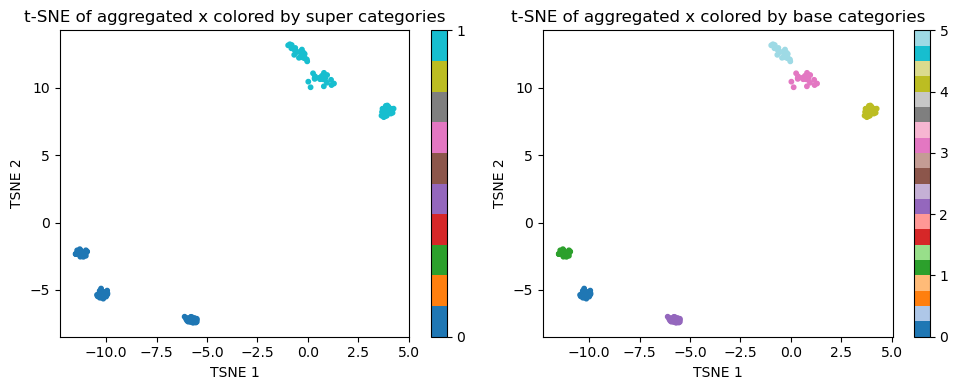

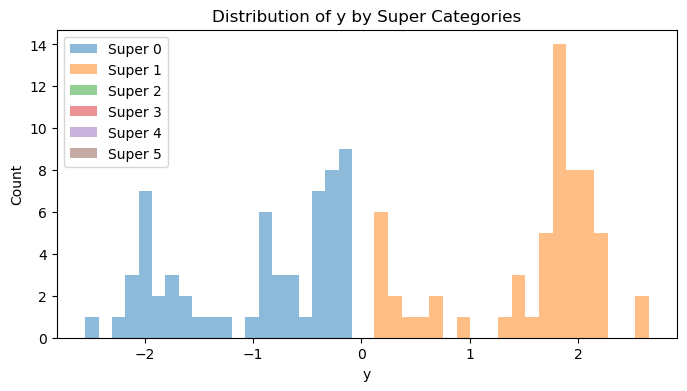

In [5]:
def tsne_visualization(data):
    x_agg = data["x"].sum(axis=1)
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    x_embedded = tsne.fit_transform(x_agg)

    # Plot t-SNE colored by super categories
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
    plt.colorbar(scatter, ticks=range(6))
    plt.title("t-SNE of aggregated x colored by super categories")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")

    # Plot t-SNE colored by base categories
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
    plt.colorbar(scatter, ticks=range(18))
    plt.title("t-SNE of aggregated x colored by base categories")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")

    plt.tight_layout()
    plt.show()

    # Plot distribution of y by super categories
    plt.figure(figsize=(8, 4))
    for super_id in range(6):
        y_vals = data["y"][data["super_labels"] == super_id]
        plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

    plt.title("Distribution of y by Super Categories")
    plt.xlabel("y")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

tsne_visualization(data)

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


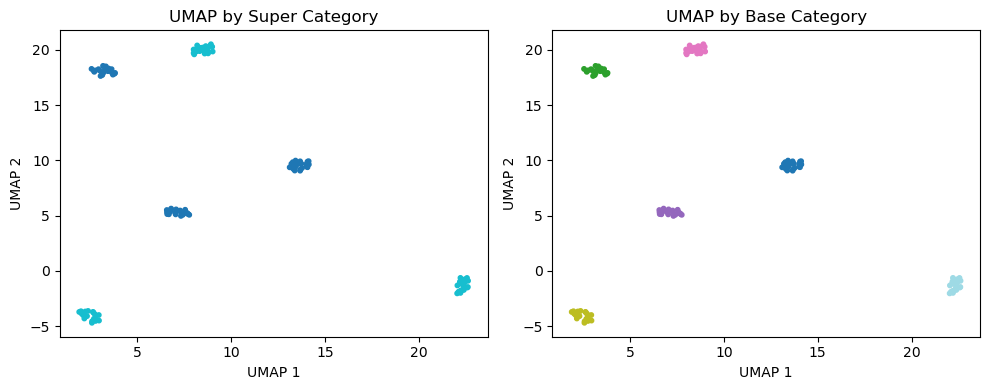

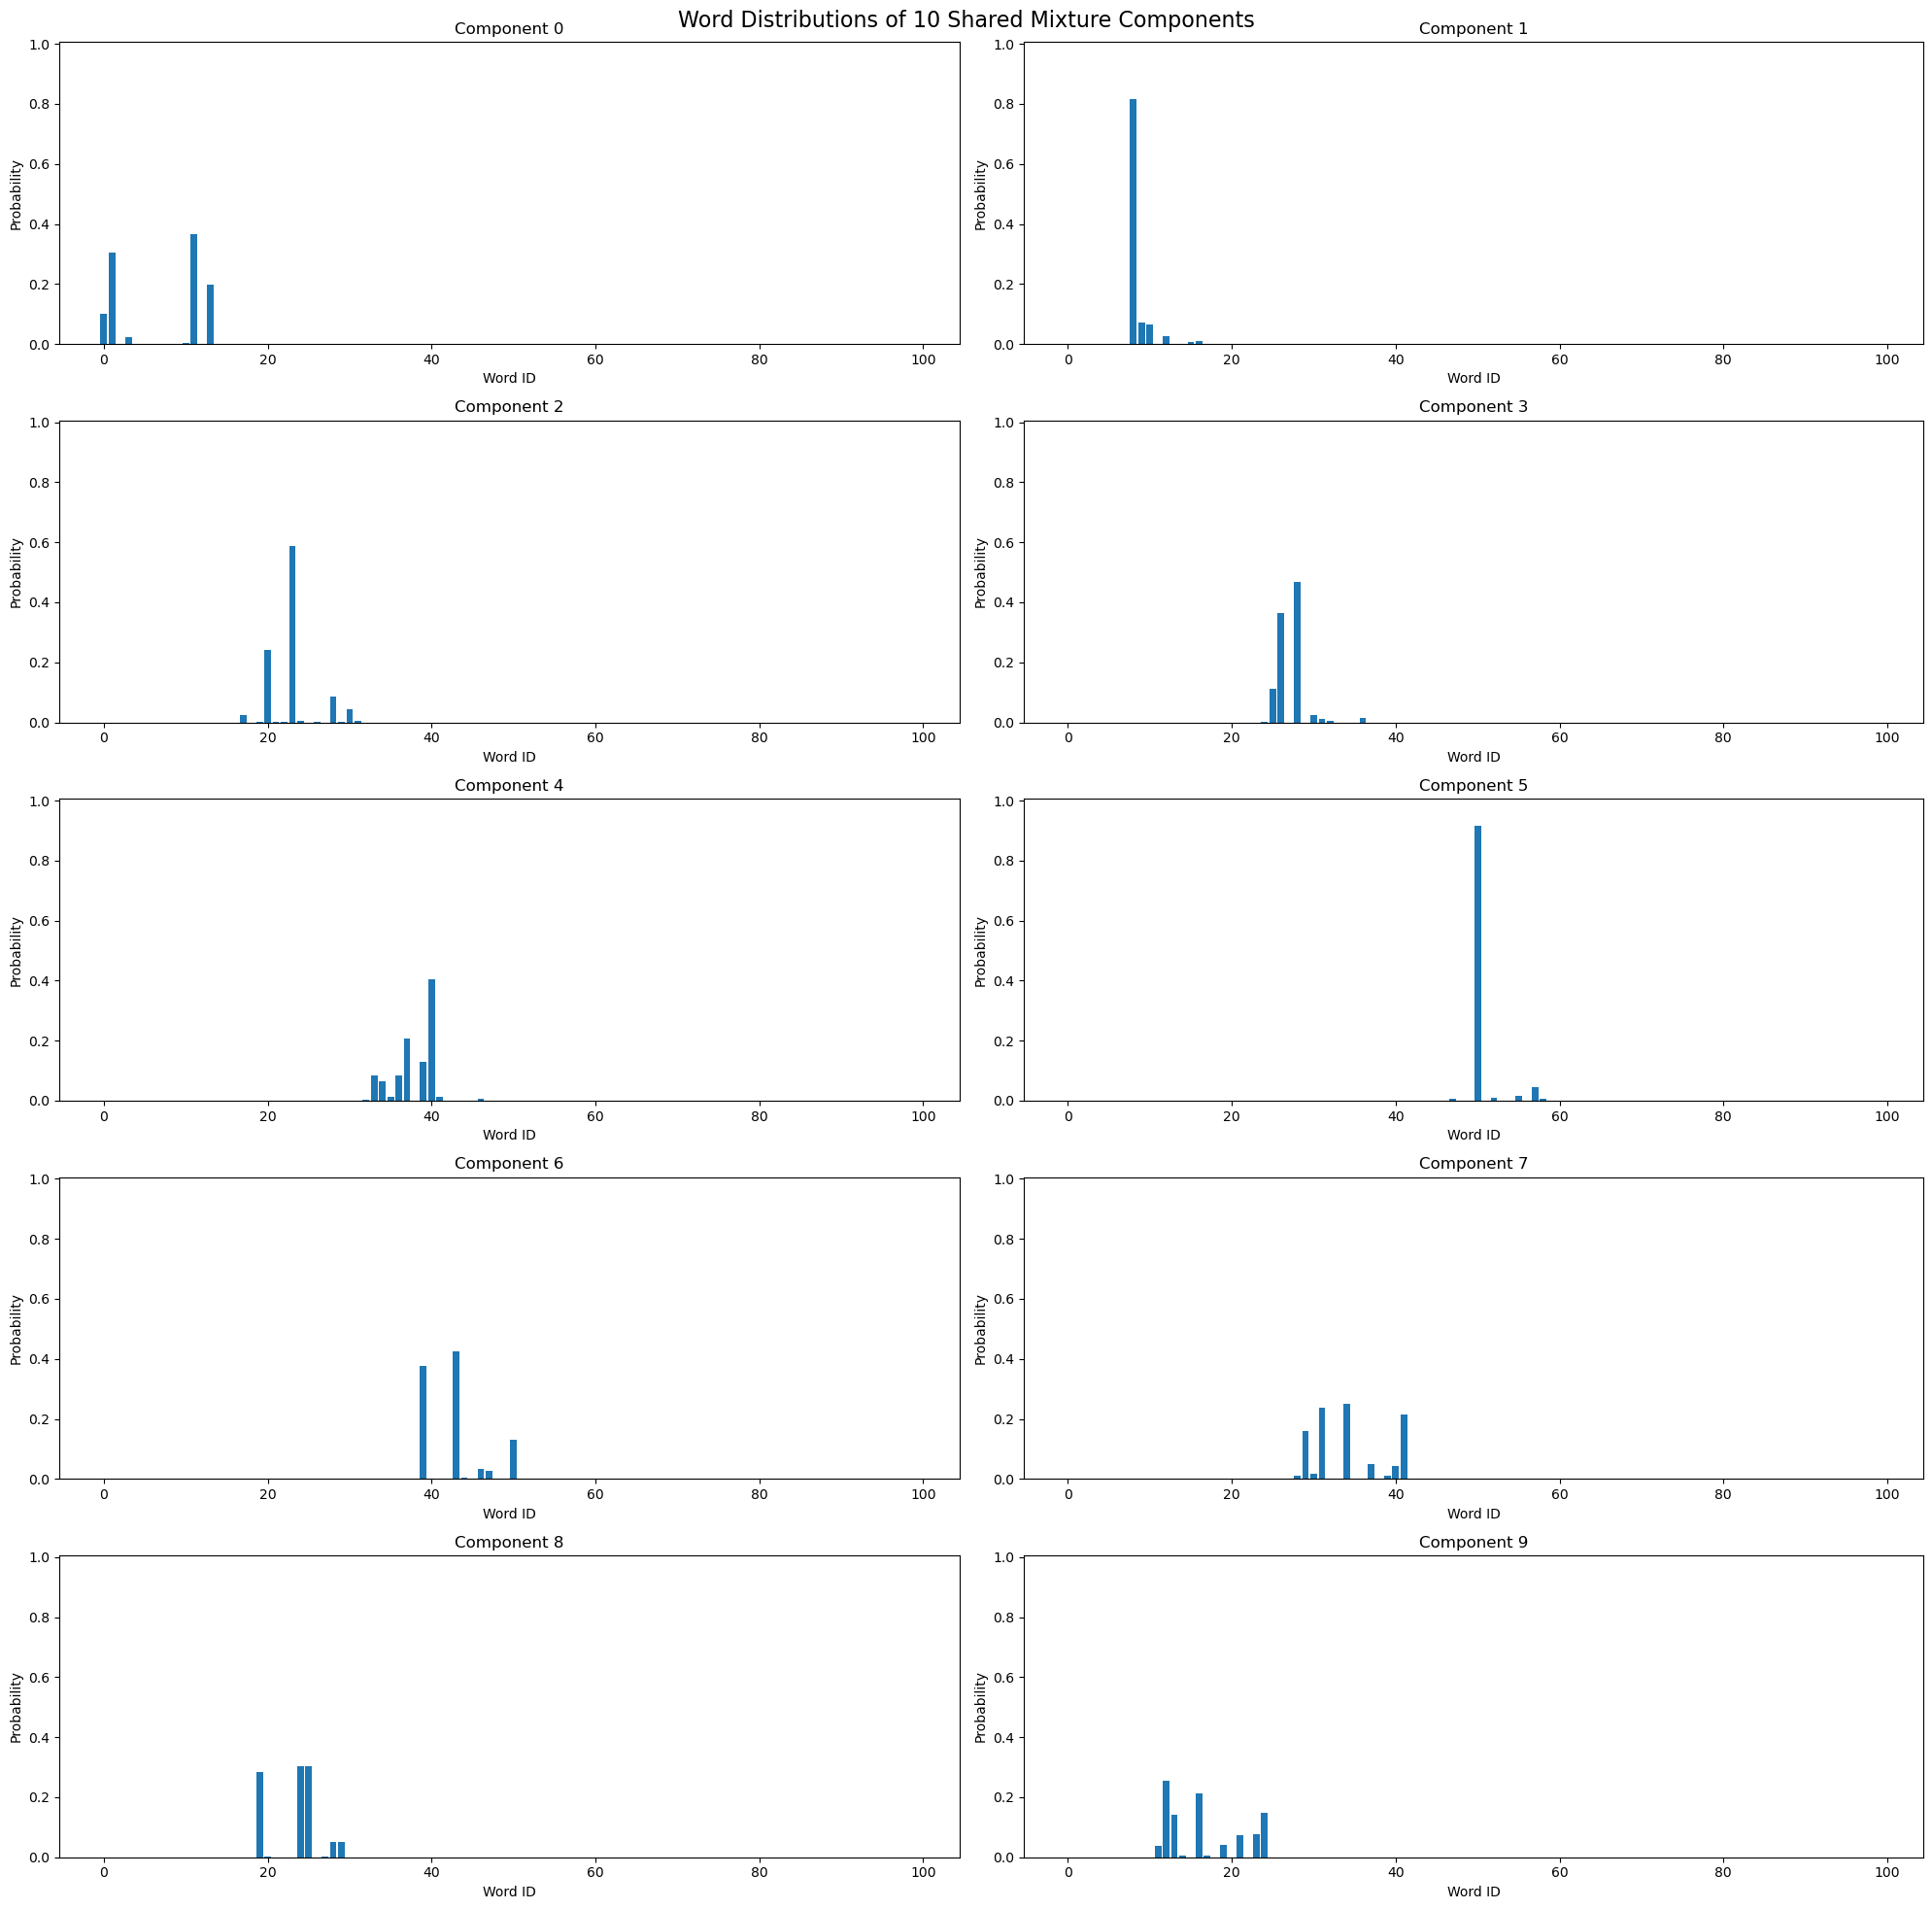

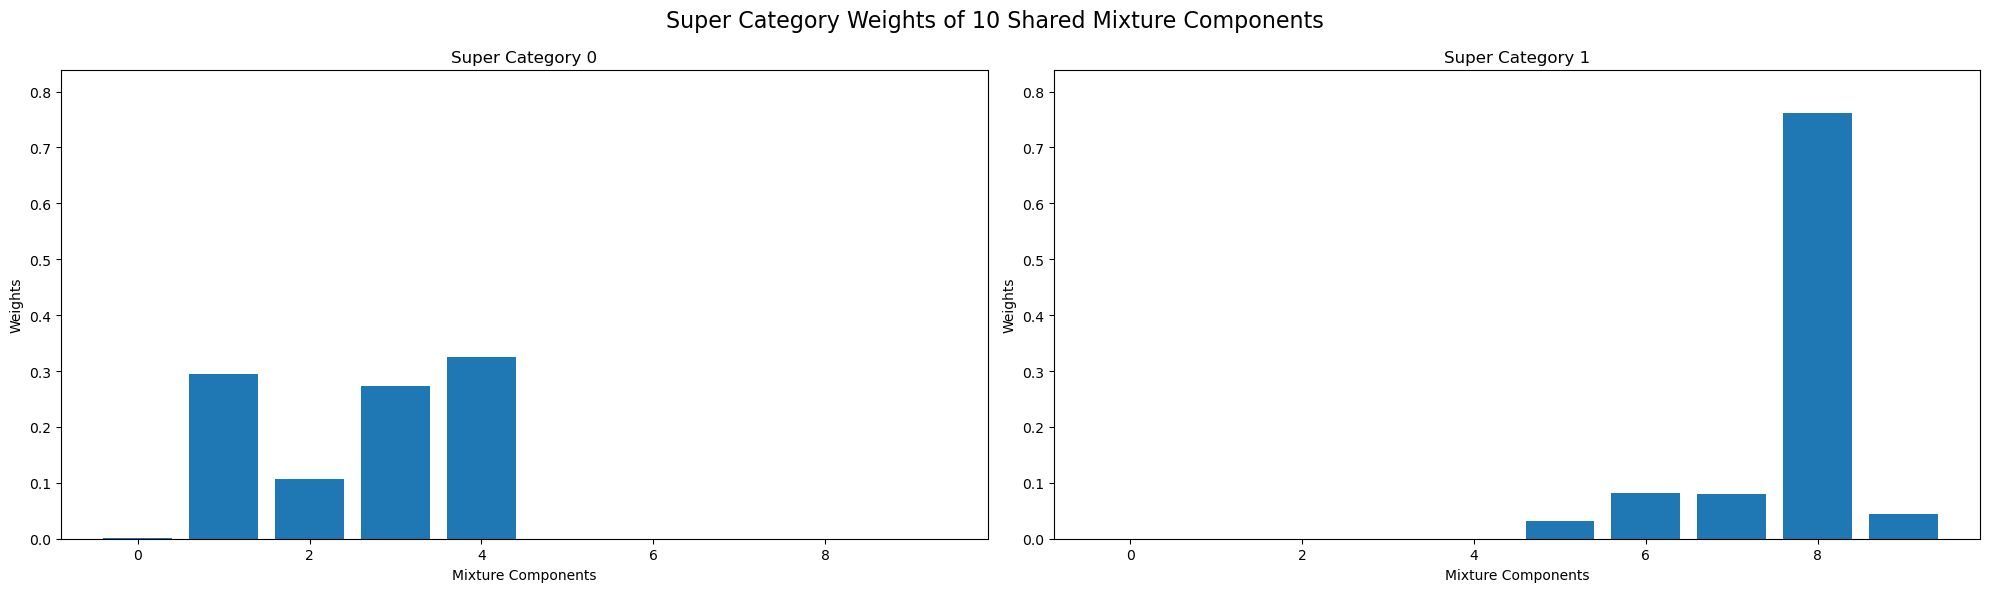

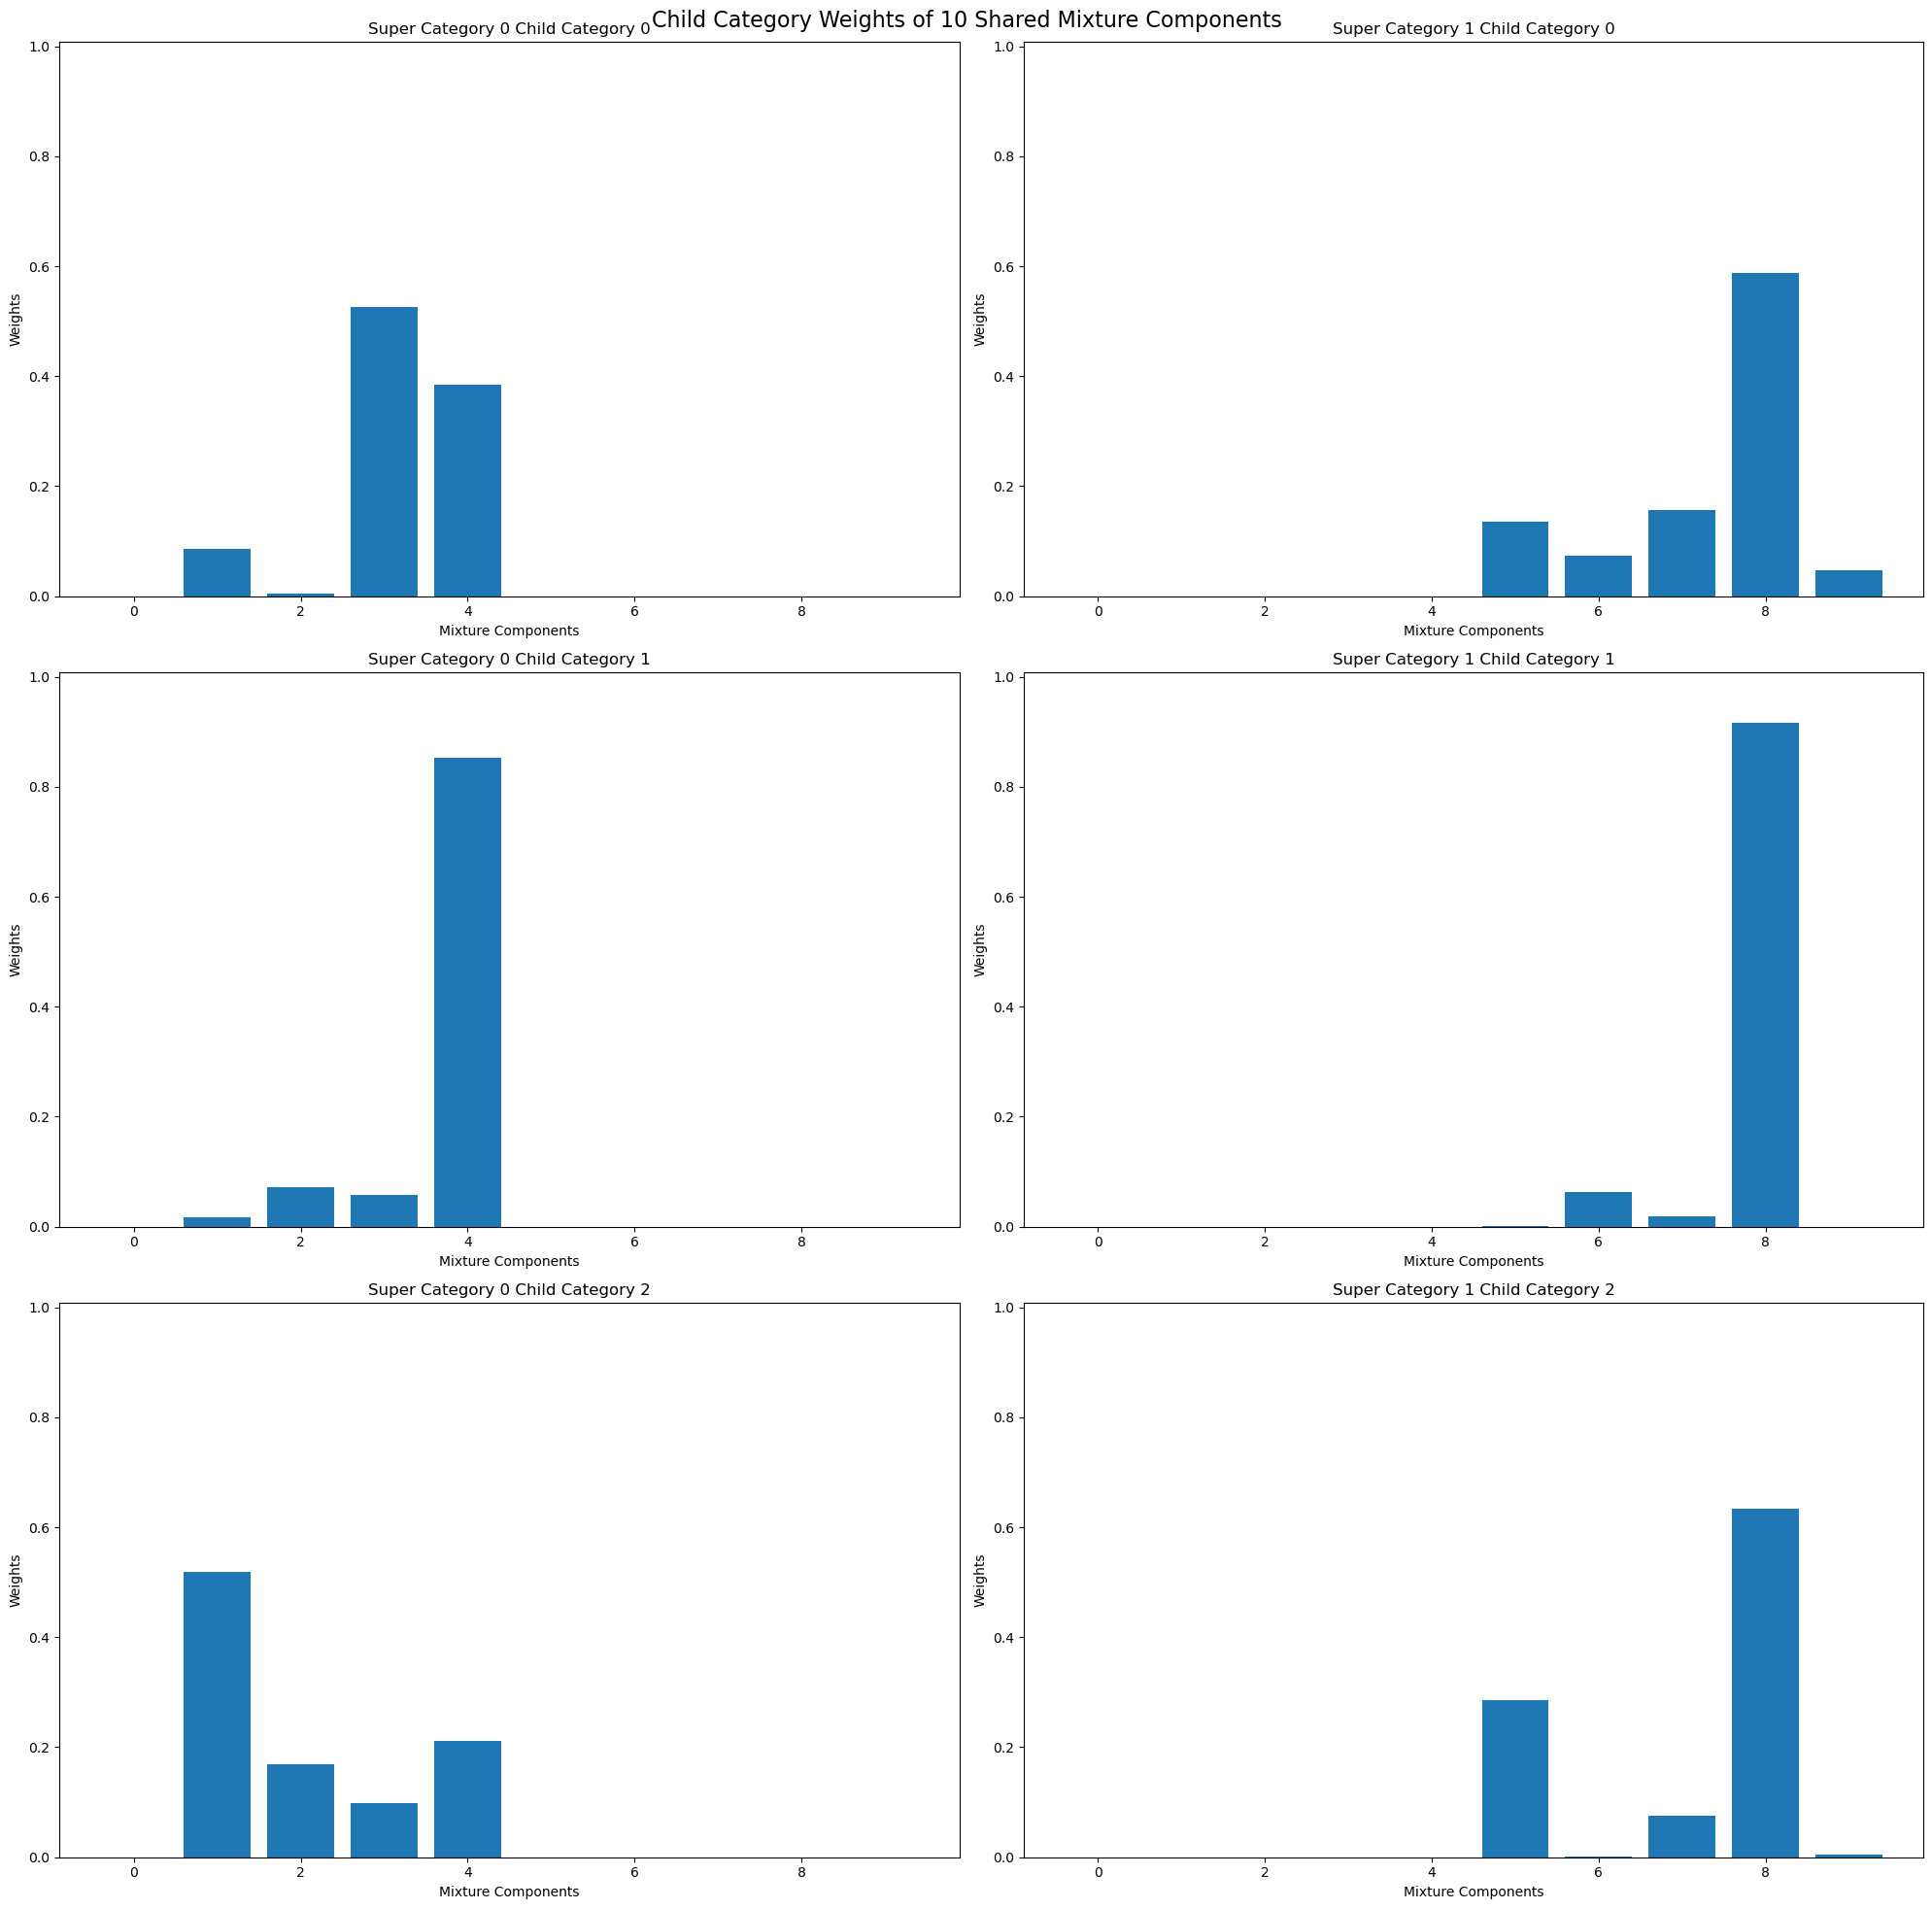

In [6]:
def umap_visualization(data):
    x_agg = data["x"].sum(axis=1)
    # === UMAP projection ===
    reducer = umap.UMAP(random_state=0)
    x_umap = reducer.fit_transform(x_agg)


    # === UMAP Plots ===
    plt.figure(figsize=(10, 4))

    # Super category coloring
    plt.subplot(1, 2, 1)
    plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
    plt.title("UMAP by Super Category")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    # Base category coloring
    plt.subplot(1, 2, 2)
    plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
    plt.title("UMAP by Base Category")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.tight_layout()
    plt.show()

    # === Mixture Component Word Distributions ===
    num_components = 10
    V = data["x"].shape[-1]
    word_dists = data["word_dists"]
    super_mix_weights = data["super_mix_weights"]
    child_mix_weights = data["child_mix_weights"]

    # Bar plots for each component
    fig, axs = plt.subplots(5, 2, figsize=(20, 20))
    for i in range(num_components):
        ax = axs[i // 2, i % 2]
        ax.bar(range(V), word_dists[i])
        ax.set_title(f"Component {i}")
        ax.set_xlabel("Word ID")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, word_dists.max().item() * 1.1)

    fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Bar plots for each component
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    for i in range(2):
        ax = axs[i]
        ax.bar(range(10), super_mix_weights[i])
        ax.set_title(f"Super Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

    fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Bar plots for each component
    fig, axs = plt.subplots(3, 2, figsize=(20, 20))
    for i in range(3):
        for j in range(2):
            ax = axs[i, j]
            ax.bar(range(10), child_mix_weights[j][i])
            ax.set_title(f"Super Category {j} Child Category {i}")
            ax.set_xlabel("Mixture Components")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

    fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
    plt.tight_layout()
    plt.show()

umap_visualization(data)

In [7]:
@jax.jit
def mix_weights(beta, axis=-1):
    """
    Compute mixture weights from stick-breaking proportions beta.
    beta: (..., K) where K is the number of sticks/components
    axis: axis along which to perform stick-breaking
    Returns: weights of same shape as beta
    """
    # Compute cumulative product of (1-v)
    remaining = jnp.cumprod(1 - beta + 1e-10, axis=axis)

    # Shift along axis: prepend ones, drop last element
    ones_shape = list(remaining.shape)
    ones_shape[axis] = 1
    ones = jnp.ones(ones_shape, dtype=remaining.dtype)
    remaining = jnp.concatenate([ones, remaining[..., :-1]], axis=axis)

    # Stick weights
    weights = beta * remaining
    return weights

In [8]:
def assign_groups_evenly_vectorized(key, a, m):
    # unique values
    unique_vals = jnp.unique(a)
    k = unique_vals.shape[0]

    # shuffle unique values
    key, subkey = jax.random.split(key)
    shuffled = jax.random.permutation(subkey, unique_vals)

    # assign groups evenly
    group_labels = jnp.repeat(jnp.arange(m), repeats=(k + m - 1)//m)[:k]

    # build a mapping from unique_vals → group_labels
    # we use jnp.searchsorted to vectorize the lookup
    # sorted shuffled values for searchsorted
    sorted_shuffled = jnp.sort(shuffled)
    # indices of a in shuffled
    idx_in_shuffled = jnp.searchsorted(sorted_shuffled, a)
    # sort shuffled -> group_labels must be sorted the same way
    sorted_group_labels = group_labels[jnp.argsort(shuffled)]
    # vectorized mapping
    g = sorted_group_labels[idx_in_shuffled]

    return g, (sorted_shuffled, sorted_group_labels)

In [9]:
def transfer_data_labels_to_hierarchy(super_labels, base_labels, level_dims):
    N = super_labels.shape[0]
    L = len(level_dims)
    local_cats = jnp.zeros((N, L), dtype=jnp.int32)
    data_labels = jnp.stack([super_labels, base_labels], axis=1)

    for level in range(L):
        if level == 0:
            uniq_s = jnp.unique(data_labels[:, level])
            if uniq_s.shape[0] > level_dims[level]:
                raise ValueError(f"Exceed category upperbound in level {level}")
            # direct assignment
            local_cats = local_cats.at[:, level].set(data_labels[:, level])
        else:
            parents = jnp.unique(data_labels[:, level-1])
            for p in parents:
                mask = data_labels[:, level-1] == p
                children = jnp.unique(data_labels[mask, level])
                if children.shape[0] > level_dims[level]:
                    raise ValueError(f"Exceed category upperbound in level {level}")
                # build child index mapping (vectorized, no dict)
                children_sorted = jnp.sort(children)
                # broadcast compare to assign local indices
                child_ids = data_labels[mask, level]
                mapped = jnp.searchsorted(children_sorted, child_ids)
                local_cats = local_cats.at[mask, level].set(mapped)

    return local_cats


In [10]:
def transfer_hierarchy_to_data_labels(local_cats: jnp.ndarray, level_dims: list[int]) -> jnp.ndarray:
    """
    Reverse of transfer_data_labels_to_hierarchy.
    Given local_cats and cluster sizes per level, reconstruct absolute labels.

    Args:
        local_cats: (N, L) array of local indices
        level_dims: list of ints, max cluster size per level

    Returns:
        data_labels: (N, L) array of absolute indices per level
    """
    N, L = local_cats.shape
    data_labels = jnp.zeros((N, L), dtype=jnp.int32)

    # level 0: absolute = local (super labels)
    data_labels = data_labels.at[:, 0].set(local_cats[:, 0])

    # deeper levels: absolute id = parent_abs * K[level] + local_id
    for level in range(1, L):
        parent_abs = data_labels[:, level - 1]
        data_labels = data_labels.at[:, level].set(parent_abs * level_dims[level] + local_cats[:, level])
    
    labels_per_level = [data_labels[:, i] for i in range(L)]

    return labels_per_level


In [11]:
@jax.jit
def suffix_sum(x: jnp.ndarray) -> jnp.ndarray:
    """
    Compute suffix sums along the last dimension of a tensor.
    Each entry is the sum of all elements to its right.
    The last element along that dimension is always 0.
    
    Example:
        x = jnp.array([1,2,3])
        suffix_sum(x) -> [5,3,0]
        
        x = jnp.array([[1,2,3],[4,5,6]])
        suffix_sum(x) -> [[5,3,0],
                           [11,6,0]]
    """
    # Flip along the last dimension
    rev = jnp.flip(x, axis=-1)
    # Cumulative sum on the flipped tensor
    rev_cumsum = jnp.cumsum(rev, axis=-1)
    # Flip back
    suffix = jnp.flip(rev_cumsum, axis=-1)
    # Subtract original to exclude current element
    suffix = suffix - x
    return jnp.clip(suffix, a_min=1e-10)

In [12]:
def gen_next_level_prior(G_parent, alpha_param):
    param_alpha = alpha_param * G_parent
    param_beta = suffix_sum(param_alpha)

    return [param_alpha, param_beta]

In [13]:
def model(data, struct_upbd, vocab_size, seed, known_base=False, known_super=False, gen_mixture=None, device=None):
    """
    Args:
      data: (feature, label), where
            feature: (N, M, vocab_size) one-hot words per position (or None for prior)
            label:   (N,) regression targets (or None for prior)
      struct_upbd: dict like {"G0": K0, "G1": K1, ...} (top level is G0)
      vocab_size: int
      device: unused (kept for API parity)
    """
    key = random.PRNGKey(seed)
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    cluster_dims = param_dims[:-1]  # no G0
    cluster_dims.reverse()

    # -----------------------
    # Data handling
    # -----------------------
    feature = data[0]          # expected shape (N, M, vocab_size)
    N = feature.shape[0]
    M = feature.shape[1]
    label = data[1] 

    # ------------------------
    # Global/structural params
    # ------------------------
    struct_params = {}
    struct_params["gamma"]      = numpyro.param("model_gamma",      jnp.asarray([N/10.]), constraint=constraints.positive)
    struct_params["dir_alpha"]  = numpyro.param("model_dir_alpha",  jnp.asarray([1./vocab_size]), constraint=constraints.positive)
    struct_params["nig_mu"]     = numpyro.param("model_nig_mu",     jnp.asarray([0.0]))
    struct_params["nig_kappa"]  = numpyro.param("model_nig_kappa",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_alpha"]  = numpyro.param("model_nig_alpha",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_beta"]   = numpyro.param("model_nig_beta",   jnp.asarray([1.0]), constraint=constraints.positive)

    # alpha/eta tensors across hierarchy
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  

        base = numpyro.param(
            f"model_alpha{parent_level}",
            jnp.ones(tuple(param_dims[-child_level:-1])),
            constraint=constraints.positive,
        )
        struct_params[f"alpha{parent_level}"] = jnp.expand_dims(base, -1) * jnp.ones(tuple(param_dims[-child_level:]))
        assert struct_params[f"alpha{parent_level}"].shape == tuple(param_dims[-child_level:])

        struct_params[f"eta{parent_level}"] = numpyro.param(
            f"model_eta{parent_level}",
            jnp.ones(tuple(cluster_dims[:child_level])),
            constraint=constraints.positive,
        )

    # Last level alpha (no eta)
    last_idx = len(struct_upbd) - 1
    base_last = numpyro.param(
        f"model_alpha{last_idx}",
        jnp.ones(tuple(param_dims[:-1])),
        constraint=constraints.positive,
    )
    struct_params[f"alpha{last_idx}"] = jnp.expand_dims(base_last, -1) * jnp.ones(tuple(param_dims))
    assert struct_params[f"alpha{last_idx}"].shape == tuple(param_dims)

    # ---------------
    # Stick-breaking
    # ---------------
    struct_values = {}

    # Top-level Beta sticks B0 -> G0 weights
    K0 = param_dims[-1]
    B0_a = jnp.ones((K0,))  # shape (K0,)
    B0_b = jnp.broadcast_to(struct_params["gamma"], (K0,))
    key, sub = random.split(key)
    beta_0 = dist.Beta(B0_a, B0_b).sample(sub)
    beta_0 = beta_0.at[-1].set(1.0)  # last stick is always 1
    struct_values["P0"] = [B0_a, B0_b]
    struct_values["Prior0"] = copy.deepcopy(struct_values["P0"])
    struct_values["B0"] = beta_0
    struct_values["G0"] = mix_weights(beta_0)  # (K0,)
    struct_values["S0"] = (K0,)
    assert struct_values["G0"].shape == (K0,)
    

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  # number of dims for this plate

        # shapes like in your code:
        # alpha * G_parent and alpha * (1 - cumsum(G_parent))
        G_parent = struct_values[f"G{parent_level}"]  # shape param_dims[-(parent_level+1):]
        alpha_param = struct_params[f"alpha{parent_level}"]  # shape param_dims[-child_level:]
        shape_needed = tuple(param_dims[-full_dim:])

        param_alpha = alpha_param * G_parent
        param_beta = suffix_sum(param_alpha)

        a = jnp.broadcast_to(jnp.expand_dims(param_alpha, 0), shape_needed)
        b = jnp.broadcast_to(jnp.expand_dims(param_beta, 0), shape_needed)

        key, sub = random.split(key)
        beta = dist.Beta(a, b).sample(sub)
        beta = beta.at[..., -1].set(1.0)  # last stick is always 1
        struct_values[f"P{child_level}"] = [a, b]
        struct_values[f"Prior{child_level}"] = copy.deepcopy(struct_values[f"P{child_level}"])
        struct_values[f"S{child_level}"] = shape_needed
        struct_values[f"B{child_level}"] = beta
        struct_values[f"G{child_level}"] = mix_weights(beta)
        assert struct_values[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][0].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][1].shape == tuple(param_dims[-full_dim:])

    # ---------------
    # Cluster weights
    # ---------------
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1
        eta = struct_params[f"eta{parent_level}"]  # shape param_dims[-full_dim:-1]

        key, sub = random.split(key)
        a = jnp.ones_like(eta)
        b = eta
        beta = dist.Beta(a, b).sample(sub)
        beta = beta.at[-1].set(1.0)  # last stick is always 1
        assert beta.shape == tuple(cluster_dims[:child_level])
        struct_values[f"LP{parent_level}"] = [a, b]
        struct_values[f"LPrior{parent_level}"] = copy.deepcopy(struct_values[f"LP{parent_level}"])
        struct_values[f"LS{parent_level}"] = tuple(cluster_dims[:child_level])
        struct_values[f"LB{parent_level}"] = beta
        struct_values[f"LG{parent_level}"] = mix_weights(beta)  # categorical probs over next level
        assert struct_values[f"LG{parent_level}"].shape == tuple(cluster_dims[:child_level])

    # -----------------------
    # Mixture components
    # -----------------------
    # Topics over vocab
    G0_size = struct_upbd["G0"]
    mixture_components = {}
    if gen_mixture is not None:
        assert gen_mixture.shape == (G0_size, vocab_size)
        mixture_components["generation"] = gen_mixture
    else:
        key, sub = random.split(key)
        mixture_components["generation"] = dist.Dirichlet(
                struct_params["dir_alpha"]
                * jnp.ones((vocab_size))
            ).sample(sub, sample_shape=(G0_size,))
        assert mixture_components["generation"].shape == (G0_size, vocab_size)
    # Regression components via NIG prior
    key, sub = random.split(key)
    sigma = dist.InverseGamma(
            jnp.broadcast_to(struct_params["nig_alpha"], (G0_size,)),
            jnp.broadcast_to(struct_params["nig_beta"],  (G0_size,))
        ).sample(sub)
    assert sigma.shape == (G0_size,)
    key, sub = random.split(key)
    mu = dist.Normal(
            jnp.broadcast_to(struct_params["nig_mu"], (G0_size,)),
            jnp.sqrt(sigma / jnp.broadcast_to(struct_params["nig_kappa"], (G0_size,)))
        ).sample(sub)
    assert mu.shape == (G0_size,)
    mixture_components["regression_sigma"] = sigma
    mixture_components["regression_mu"] = mu

    # # ---------------------------------
    # # Per-document hierarchical routing
    # # ---------------------------------
    if (known_base):
        base_category = data[2]
        doc_values = {}
        
        # nodes_per_level: number of nodes at each *tree* level
        # level 0 = root (1 node), level 1 = K[0], level 2 = K[0]*K[1], ...
        nodes_per_level = [1]
        for k in cluster_dims:
            nodes_per_level.append(nodes_per_level[-1] * k)

        # --- sampling walk (per-batch) ---
        key, subkey = jax.random.split(key)
        if (known_super):
            super_cat = data[3]
        else:
            super_cat, _ = assign_groups_evenly_vectorized(subkey, base_category, struct_upbd["G1"])
        local_category_assignments = transfer_data_labels_to_hierarchy(super_cat, base_category, cluster_dims)

        assigned_local = [local_category_assignments[:, i] for i in range(local_category_assignments.shape[1])]
        # reverse to align with your later indexing usage
        assigned_local = assigned_local[::-1]
    else:
        if known_super:
            raise NotImplementedError("known_super without known_base not implemented")
        doc_values = {}
        # --- prepare sizes / offsets ---
        L = len(struct_upbd) - 1  # number of LG levels you iterate over (same as your code)
        
        # nodes_per_level: number of nodes at each *tree* level
        # level 0 = root (1 node), level 1 = K[0], level 2 = K[0]*K[1], ...
        nodes_per_level = [1]
        for k in cluster_dims:
            nodes_per_level.append(nodes_per_level[-1] * k)

        # --- sampling walk (per-batch) ---
        assigned_local = [jnp.zeros((N,), dtype=jnp.int32)]  # local indices used to index the structured params (for advanced indexing)

        for level in range(L):
            # W shape: (... parent dims ..., K[level])
            W = struct_values[f"LG{level}"][None, ...]    # keep your original broadcasting if needed

            # build index tuple out of local indices (same as your original approach)
            index_tuple = tuple(assigned_local[:])       # these are local indices of parents
            param = W[index_tuple]                       # -> (N, K[level])
            assert param.shape == (N, cluster_dims[level])

            key, sub = random.split(key)
            z_local = dist.Categorical(probs=param).sample(sub)  # local index under its parent (0..K[level]-1)
            assert jnp.unique(z_local).size <= cluster_dims[level]

            # append for next iterations / for output
            assigned_local.append(z_local)   # keep local indices for advanced indexing of next level's W

        cat_zs = assigned_local[1:]  # skip the root level
        local_category_assignments = jnp.stack(cat_zs, axis=1) if len(cat_zs) > 0 else jnp.zeros((N, 0), dtype=jnp.int32)
        # reverse to align with your later indexing usage
        assigned_local = cat_zs[::-1]

    # Document-level stick-breaking at bottom: construct Beta params using G_{L} and alpha_{L}
    bottom_G = struct_values[f"G{len(struct_upbd)-1}"][None, ...]  # shape (K0,) broadcastable with per-doc gather
    bottom_alpha = struct_params[f"alpha{len(struct_upbd)-1}"][None, ...]

    # Gather per-doc parent path for alpha and weights_prior
    # For G_{L} (topic base weights), use parent indices in assigned_zs[:-1]
    idx_tuple_weights = tuple(assigned_local)
    batch_idx = jnp.arange(N)
    indices = (batch_idx, *idx_tuple_weights)  

    weights_prior = bottom_G[indices + (slice(None),)]  # (N, G0)
    assert weights_prior.shape == (N, G0_size)
    concentrate = bottom_alpha[indices + (slice(None),)]  # (N, G0)
    assert concentrate.shape == (N, G0_size)

    param_alpha = concentrate * weights_prior
    param_beta = suffix_sum(param_alpha)

    key, sub = random.split(key)
    beta_doc = dist.Beta(param_alpha, param_beta).sample(sub)  # (N, G0)
    beta_doc = beta_doc.at[:, -1].set(1.0)  # last stick is always 1
    doc_values["P"] = [param_alpha, param_beta]
    doc_values["Prior"] = copy.deepcopy(doc_values["P"])
    doc_values["B"] = beta_doc

    topic_dist = mix_weights(beta_doc)  # (N, G0)
    doc_values["G"] = topic_dist
    assert topic_dist.shape == (N, G0_size)

    # ----- Words -----
    # Per-token topic → per-token word dist, then one-hot word obs via Multinomial(1, .)
    topic_over_docs = jnp.broadcast_to(jnp.expand_dims(topic_dist, axis=1), (N, M, G0_size))
    key, sub = random.split(key)
    z_gen = dist.Categorical(probs=topic_over_docs).sample(sub)  # (N, M)
    obs = feature

    # ----- Regression -----
    key, sub = random.split(key)
    z_reg = dist.Categorical(probs=topic_dist).sample(sub)  
    reg = label

    return {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": mixture_components,
        "local_category_assignments": local_category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }


In [14]:
# @jax.jit
def compute_log_joint_prob(state, struct_upbd):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    eps = 1e-8
    # Unpack state
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    local_category_assignments = state["local_category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    doc_values = state["doc_values"]

    # ---------------
    # Joint log-probability
    # ---------------
    log_prob = 0.0

    # Top-level Beta sticks B0 -> G0 weights
    B0_a, B0_b  = struct_values["P0"]
    B0_a = jnp.clip(B0_a, a_min=eps)
    B0_b = jnp.clip(B0_b, a_min=eps)
    rv = jnp.clip(struct_values["B0"], a_min=eps, a_max=1-eps)
    beta_logp = jnp.sum(dist.Beta(B0_a[..., :-1], B0_b[..., :-1]).log_prob(rv[..., :-1]))
    if (jnp.any(jnp.isinf(beta_logp)) or jnp.any(jnp.isnan(beta_logp))):
        print("B0_a:", B0_a)
        print("B0_b:", B0_b)
        print("struct_values[B0]:", struct_values["B0"])
        raise ValueError("Numerical issue in top-level Beta log-prob computation.")
    log_prob += beta_logp

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        a, b = struct_values[f"P{child_level}"]
        a = jnp.clip(a, a_min=eps)  
        b = jnp.clip(b, a_min=eps)
        rv = jnp.clip(struct_values[f"B{child_level}"], a_min=eps, a_max=1-eps)
        beta_logp = jnp.sum(dist.Beta(a[..., :-1], b[..., :-1]).log_prob(rv[..., :-1]))
        if (jnp.any(jnp.isinf(beta_logp)) or jnp.any(jnp.isnan(beta_logp))):
            print(f"P{child_level} a:", a)
            print(f"P{child_level} b:", b)
            print(f"struct_values[B{child_level}]:", struct_values[f"B{child_level}"])
            raise ValueError(f"Numerical issue in level {child_level} Beta log-prob computation.")
        log_prob += beta_logp

    # Cluster weights
    for parent_level in range(len(struct_upbd) - 1):
        a, b = struct_values[f"LP{parent_level}"]
        a = jnp.clip(a, a_min=eps)
        b = jnp.clip(b, a_min=eps)
        rv = jnp.clip(struct_values[f"LB{parent_level}"], a_min=eps, a_max=1-eps)
        cluster_logp = jnp.sum(dist.Beta(a[..., :-1], b[..., :-1]).log_prob(rv[..., :-1]))
        if (jnp.any(jnp.isinf(cluster_logp)) or jnp.any(jnp.isnan(cluster_logp))):
            print(f"LP{parent_level} a:", a)
            print(f"LP{parent_level} b:", b)
            print(f"struct_values[LB{parent_level}]:", struct_values[f"LB{parent_level}"])
            raise ValueError(f"Numerical issue in level {parent_level} cluster Beta log-prob computation.")
        log_prob += cluster_logp

    # Document-level
    param_alpha, param_beta = doc_values["P"]
    param_alpha = jnp.clip(param_alpha, a_min=eps)
    param_beta = jnp.clip(param_beta, a_min=eps)
    rv = jnp.clip(doc_values["B"], a_min=eps, a_max=1-eps)
    doc_cat_logp = jnp.sum(dist.Beta(param_alpha[..., :-1], param_beta[..., :-1]).log_prob(rv[..., :-1]))
    if (jnp.any(jnp.isinf(doc_cat_logp)) or jnp.any(jnp.isnan(doc_cat_logp))):
        print("param_alpha:", param_alpha)
        print("param_beta:", param_beta)
        print("doc_values[B]:", doc_values["B"])
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    log_prob += doc_cat_logp

    topic_prob = jnp.take_along_axis(doc_values["G"], z_gen, axis=1)
    if (jnp.any(jnp.isinf(topic_prob)) or jnp.any(jnp.isnan(topic_prob))):
        print("doc_values[G]:", doc_values["G"])
        print("z_gen:", z_gen)
        raise ValueError("Numerical issue in topic probability computation.")
    log_prob += jnp.sum(jnp.log(topic_prob + 1e-12))

    for parent_level in range(len(struct_upbd) - 1):
        idx_split = local_category_assignments[:, :parent_level + 1] 
        cluster_prob = struct_values[f"LG{parent_level}"][tuple(idx_split.T)]
        if (jnp.any(jnp.isinf(cluster_prob)) or jnp.any(jnp.isnan(cluster_prob))):
            print(f"struct_values[LG{parent_level}]:", struct_values[f"LG{parent_level}"])
            print("idx_split:", idx_split)
            raise ValueError(f"Numerical issue in cluster probability computation at level {parent_level}.")
        log_prob += jnp.sum(jnp.log(cluster_prob + 1e-12))

    gen_param = generation_components[z_gen]  # (N, M, V)
    gen_param = jnp.clip(gen_param, 1e-12, 1.0)
    gen_param = gen_param / gen_param.sum(-1, keepdims=True)  #
    word_prob = dist.Multinomial(total_count=1, probs=gen_param).log_prob(obs)

    if (jnp.any(jnp.isnan(word_prob)) or jnp.any(jnp.isinf(word_prob))):
        print("gen_param:", gen_param)
        print("obs:", obs)
        raise ValueError("Numerical issue in word probability computation.")
    log_prob += jnp.sum(word_prob)
   

    reg_prob = dist.Normal(loc=regression_mu[z_reg], scale=regression_sigma[z_reg]).log_prob(reg)
    if (jnp.any(jnp.isnan(reg_prob)) or jnp.any(jnp.isinf(reg_prob))):
        print("regression_mu:", regression_mu)
        print("regression_sigma:", regression_sigma)
        print("reg:", reg)
        raise ValueError("Numerical issue in regression probability computation.")
    log_prob += jnp.sum(reg_prob)

    return log_prob


In [15]:
# @jax.jit
def compute_log_likelihood(state):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    # ---------------
    # Joint log-probability
    # ---------------
    log_prob = 0.0

    gen_param = generation_components[z_gen]  # (N, M, V)
    gen_param = jnp.clip(gen_param, 1e-12, 1.0)
    gen_param = gen_param / gen_param.sum(-1, keepdims=True)  #
    word_prob = dist.Multinomial(total_count=1, probs=gen_param).log_prob(obs)

    if (jnp.any(jnp.isnan(word_prob)) or jnp.any(jnp.isinf(word_prob))):
        print("gen_param:", gen_param)
        print("obs:", obs)
        raise ValueError("Numerical issue in word probability computation.")
    log_prob += jnp.sum(word_prob)
   

    reg_prob = dist.Normal(loc=regression_mu[z_reg], scale=regression_sigma[z_reg]).log_prob(reg)
    if (jnp.any(jnp.isnan(reg_prob)) or jnp.any(jnp.isinf(reg_prob))):
        print("regression_mu:", regression_mu)
        print("regression_sigma:", regression_sigma)
        print("reg:", reg)
        raise ValueError("Numerical issue in regression probability computation.")
    log_prob += jnp.sum(reg_prob)

    return log_prob


In [16]:
@jax.jit
def cat_weight_conditional(key, nu, params, word_cats, reg_cats):
    """
    Sample category-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu: (K,) current category-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """ 
    K = 10

    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]

    assert new_params[0].shape == (K,)
    assert new_params[1].shape == (K,)
    return new_params, key

In [17]:
@jax.jit
def reg_category_conditional(key, score, weight, components):
    """
    Sample category assignment for a single regression score given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        score: float, regression score
        weight: (K,) mixture weights for the document
        components: (K, 2) component regression parameters (mean, variance)
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """
    reg_dist = dist.Normal(loc=components[0], scale=jnp.sqrt(components[1]))
    log_probs = reg_dist.log_prob(score)
    log_probs = jnp.clip(log_probs, a_min=-1e12)
    un_normalized = log_probs + jnp.log(weight + 1e-12)

    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key

In [18]:
def reg_category_infer(key, score, components):
    """
    Sample category assignment for a single regression score given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        score: float, regression score
        weight: (K,) mixture weights for the document
        components: (K, 2) component regression parameters (mean, variance)
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """
    reg_dist = dist.Normal(loc=components[0], scale=jnp.sqrt(components[1]))
    log_probs = reg_dist.log_prob(score)
    log_probs = jnp.clip(log_probs, a_min=-1e12)
    un_normalized = log_probs 

    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    sample = jnp.argmax(cat_prob)
    # print(f"raw value is {un_normalized}, reg log-prob is {log_probs}, mixture weight is {weight}, final prob is {cat_prob}, selected category is {sample}" )
    return sample, key

In [19]:
@jax.jit
def word_category_conditional(key, word, weight, components):
    """
    Sample category assignment for a single word given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        word: (V,) one-hot vector of the word
        weight: (K,) mixture weights for the document
        components: (K, V) component-word distributions 
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """

    gen_dist = dist.Multinomial(total_count=1, probs=components)
    log_probs = gen_dist.log_prob(word)
    log_probs = jnp.clip(log_probs, a_min=-1e12)
    un_normalized = log_probs + jnp.log(weight + 1e-12)
    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key


In [20]:

def word_category_infer(key, word, components):
    """
    Sample category assignment for a single word given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        word: (V,) one-hot vector of the word
        weight: (K,) mixture weights for the document
        components: (K, V) component-word distributions 
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """

    gen_dist = dist.Multinomial(total_count=1, probs=components)
    log_probs = gen_dist.log_prob(word)
    log_probs = jnp.clip(log_probs, a_min=-1e12)
    un_normalized = log_probs 
    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    sample = jnp.argmax(cat_prob)
    # print(f"raw value is {un_normalized}, word log-prob is {log_probs}, mixture weight is {weight}, final prob is {cat_prob}, selected category is {sample}")
    return sample, key


In [21]:
@jax.jit
def doc_weight_conditional(key, nu_doc, params, word_cats, reg_cats):
    """
    Sample document-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_doc: (K,) current document-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    K = 10
    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu_doc, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key


In [22]:
def doc_weight_infer(key, word_cats, reg_cats):
    """
    Sample document-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_doc: (K,) current document-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    K = 10
    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros((K,), dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [alpha_bias, beta_bias]
    return new_params, key

In [23]:
@jax.jit
def super_cluster_weight_conditional(key, nu_cluster, params, local_cluster_cats):
    """
    Sample super-cluster-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_cluster: (S,) current super-cluster-level stick-breaking weights
        params: list of two (S,) arrays, Beta parameters [alpha, beta]
        cluster_cats: (N_cluster,) array of super-cluster category assignments
    Returns:
        new_params: list of two (S,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    S = 2
    cat_count = jnp.bincount(local_cluster_cats.ravel(), length=S)
    cat_idx = jnp.arange(S)

    alpha_bias = jnp.zeros_like(nu_cluster, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key

In [24]:
@jax.jit
def base_cluster_weight_conditional(key, nu_cluster, params, local_cluster_cats):
    """
    Sample base-cluster-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_cluster: (C,) current base-cluster-level stick-breaking weights
        params: list of two (C,) arrays, Beta parameters [alpha, beta]
        cluster_cats: (N_cluster,) array of base-cluster category assignments under one super-cluster
    Returns:
        new_params: list of two (C,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    C = 3
    cat_count = jnp.bincount(local_cluster_cats.ravel(), length=C)
    cat_idx = jnp.arange(C)

    alpha_bias = jnp.zeros_like(nu_cluster, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key

In [25]:
@jax.jit
def reg_component_conditional(key, obs, params):
    """
    Sample regression component parameters given assigned observations and Normal-Inverse-Gamma prior.
    Args:
        key: JAX PRNGKey
        obs: (N_obs,) array of assigned regression observations
        params: list of four scalars [mu, kappa, alpha, beta] for the NIG prior
    Returns:
        new_params: list of two scalars [new_mu, new_sigma] for the sampled regression component
        new_key: updated JAX PRNGKey
    """
    count = float(obs.size)
    mean = jnp.mean(obs)
    sum_var = jnp.sum((obs - mean) ** 2, keepdims=True)
    kappa = params[1] + count
    mu = (params[1] * params[0] + count * mean) / kappa
    alpha = params[2] + count / 2
    beta = params[3] + 0.5 * sum_var + (params[1] * count * (mean - params[0]) ** 2) / (2 * kappa)

    key, sub = random.split(key)
    new_sigma = dist.InverseGamma(alpha, beta).sample(sub)
    key, sub = random.split(key)
    new_mu = dist.Normal(mu, jnp.sqrt(new_sigma / kappa)).sample(sub)
    return [jnp.squeeze(new_mu), jnp.squeeze(new_sigma)], key

In [26]:
@jax.jit
def gen_component_conditional(key, obs, params):
    """
    Sample generation component parameters given assigned observations and Dirichlet prior.
    Args:
        key: JAX PRNGKey
        obs: (N_obs, V) array of assigned one-hot word observations
        params: (V,) array of Dirichlet prior parameters
    Returns:
        sample: (V,) array of sampled generation component parameters
        new_key: updated JAX PRNGKey
    """
    value = jnp.sum(obs, axis=0)

    new_params = params + value

    key, sub = random.split(key)
    sample = dist.Dirichlet(new_params).sample(sub)
    return sample, key

In [27]:
def reverse_stick_breaking(pi, eps=1e-12):
    """
    Batched reverse stick-breaking transform (numerically stable).
    
    Args:
        pi: jnp.ndarray with shape (..., K)
            Last dimension is categorical distribution weights, should sum to ~1.
    Returns:
        v: jnp.ndarray with shape (..., K), stick-breaking variables.
    """
    K = pi.shape[-1]

    # normalize to avoid drift
    pi = pi / (jnp.sum(pi, axis=-1, keepdims=True) + eps)

    def body_fun(carry, pi_k):
        remaining = jnp.clip(carry, a_min=eps)   # avoid 0 or negative
        v_k = pi_k / remaining
        remaining = remaining - pi_k
        return remaining, v_k

    remaining0 = jnp.ones(pi.shape[:-1])
    _, v_part = jax.lax.scan(body_fun, remaining0, jnp.moveaxis(pi[..., :-1], -1, 0))
    v_part = jnp.moveaxis(v_part, 0, -1)

    # last entry: set to 1.0 explicitly
    last = jnp.ones_like(v_part[..., :1])
    v = jnp.concatenate([v_part, last], axis=-1)
    return v


In [28]:
def beta_moments_estimate(x, var0=1e-2, eps=1e-6):
    """
    Method-of-moments estimate for Beta(alpha, beta) when each batch element has only 1 sample.
    Assumes a fixed small variance var0.

    Args:
        x: jnp.ndarray with shape (...,), samples in (0,1), each element is a separate distribution.
        var0: float, assumed variance for all distributions.
        eps: float, numerical stability.

    Returns:
        a, b: jnp.ndarray with shape (...,), estimated alpha and beta.
    """
    x = jnp.asarray(x)
    x = jnp.clip(x, eps, 1 - eps)

    # Compute pseudo-term using fixed variance
    term = (x * (1 - x) / var0) - 1.0
    term = jnp.maximum(term, 1e-6)

    a = jnp.maximum(x * term, 1e-8)
    b = jnp.maximum((1 - x) * term, 1e-8)

    return a, b


In [29]:
def row_counts(x, K):
    """
    Args:
        x: jnp.ndarray of shape (n, m), entries in 0..K-1
        K: number of categories

    Returns:
        counts: jnp.ndarray of shape (n, K), counts per row
    """
    return jax.vmap(lambda row: jnp.bincount(row, length=K))(x)

In [30]:
def transfer_ground_truth_to_state(post_state, struct_upbd, data):
    """
    Given the ground truth mixture components and category assignments,
    transfer them to the HDMM state format for initializing the Gibbs sampler.

    Args:
        post_state: dict, the HDMM state returned by the model function.
        struct_upbd: dict, structure upper bounds.
        data: dict, containing 'word_dists' and 'category_assignments'.
    Returns:
        new_state: dict, HDMM state with ground truth components and assignments.
    """
    eps = 1e-3
    N, M, V = data["x"].shape
    K = struct_upbd["G0"]
    S = struct_upbd["G1"]
    C = struct_upbd["G2"]
    ground_truth_state = {"struct_values": {}, "mixture_components": {}, "local_category_assignments": None, "doc_values": {}, "words": {}}

    # Transfer generation components
    ground_truth_state["mixture_components"]["generation"] = data["word_dists"]
    ground_truth_state["mixture_components"]["generation"] = jnp.clip(ground_truth_state["mixture_components"]["generation"], eps, 1.0-eps)
    assert ground_truth_state["mixture_components"]["generation"].shape == (K, V)

    ground_truth_state["mixture_components"]["regression_mu"] = data["reg_means"]
    ground_truth_state["mixture_components"]["regression_sigma"] = data["reg_std"]
    assert ground_truth_state["mixture_components"]["regression_mu"].shape == (K,)
    assert ground_truth_state["mixture_components"]["regression_sigma"].shape == (K,)
    assert ground_truth_state["mixture_components"]["generation"].shape == (K, V)

    # Transfer category assignments
    ground_truth_state["local_category_assignments"] = transfer_data_labels_to_hierarchy(data["super_labels"], data["base_labels"], [S, C])
    assert ground_truth_state["local_category_assignments"].shape == (N, 2)

    # Transfer document-level stick-breaking weights
    ground_truth_state["words"]["z_gen"] = data["x_labels"]  # (N, M)
    ground_truth_state["words"]["z_reg"] = data["y_labels"]  # (N,)
    ground_truth_state["words"]["obs"] = data["x"]  # (N, M, V)
    ground_truth_state["words"]["reg"] = data["y"]  # (N,)
    assert ground_truth_state["words"]["z_gen"].shape == (N, M)
    assert ground_truth_state["words"]["z_reg"].shape == (N,)
    assert ground_truth_state["words"]["obs"].shape == (N, M, V)
    assert ground_truth_state["words"]["reg"].shape == (N,)


    ground_truth_state["struct_values"]["G0"] = post_state["struct_values"]["G0"]
    # make sure values are safe
    ground_truth_state["struct_values"]["G0"] = jnp.clip(ground_truth_state["struct_values"]["G0"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["struct_values"]["G0"] = ground_truth_state["struct_values"]["G0"] / jnp.sum(ground_truth_state["struct_values"]["G0"], axis=-1, keepdims=True)
    ground_truth_state["struct_values"]["B0"] = post_state["struct_values"]["B0"]
    # make sure values are safe
    ground_truth_state["struct_values"]["B0"] = jnp.clip(ground_truth_state["struct_values"]["B0"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["P0"] = post_state["struct_values"]["P0"]
    assert jnp.all(ground_truth_state["struct_values"]["P0"][0] > 0)
    assert jnp.all(ground_truth_state["struct_values"]["P0"][1] > 0)
    assert ground_truth_state["struct_values"]["G0"].shape == (K,)
    assert ground_truth_state["struct_values"]["B0"].shape == (K,)
    assert ground_truth_state["struct_values"]["P0"][0].shape == (K,)
    assert ground_truth_state["struct_values"]["P0"][1].shape == (K,)

    sb_w = reverse_stick_breaking(data["super_mix_weights"])
    ground_truth_state["struct_values"]["B1"] = sb_w  # (S, K)
    ground_truth_state["struct_values"]["B1"] = jnp.clip(ground_truth_state["struct_values"]["B1"], eps, 1.0-eps)
    
    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["B1"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["P1"] = [a, b]  # (2, S)

    ground_truth_state["struct_values"]["G1"] = data["super_mix_weights"] # (S, K)
    ground_truth_state["struct_values"]["G1"] = jnp.clip(ground_truth_state["struct_values"]["G1"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["G1"] = ground_truth_state["struct_values"]["G1"] / jnp.sum(ground_truth_state["struct_values"]["G1"], axis=-1, keepdims=True)

    sb_w = reverse_stick_breaking(data["child_mix_weights"])
    ground_truth_state["struct_values"]["B2"] = jnp.transpose(sb_w, (1, 0, 2))  # (C, S, K)
    ground_truth_state["struct_values"]["B2"] = jnp.clip(ground_truth_state["struct_values"]["B2"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["B2"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["P2"] = [a, b]  # (2, C, S)

    ground_truth_state["struct_values"]["G2"] = jnp.transpose(data["child_mix_weights"], (1, 0, 2))  # (C, S, K)
    ground_truth_state["struct_values"]["G2"] = jnp.clip(ground_truth_state["struct_values"]["G2"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["G2"] = ground_truth_state["struct_values"]["G2"] / jnp.sum(ground_truth_state["struct_values"]["G2"], axis=-1, keepdims=True)

    doc_weight = row_counts(data["x_labels"], K)
    ground_truth_state["doc_values"]["G"] = doc_weight / jnp.sum(doc_weight, axis=-1, keepdims=True)
    # make sure values are safe
    ground_truth_state["doc_values"]["G"] = jnp.clip(ground_truth_state["doc_values"]["G"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["doc_values"]["G"] = ground_truth_state["doc_values"]["G"] / jnp.sum(ground_truth_state["doc_values"]["G"], axis=-1, keepdims=True)
    # assert no nans
    assert not jnp.any(jnp.isnan(ground_truth_state["doc_values"]["G"]))
    assert ground_truth_state["doc_values"]["G"].shape == (N, K)

    a, b = beta_moments_estimate(ground_truth_state["doc_values"]["G"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["doc_values"]["P"] = [a, b]
    assert ground_truth_state["doc_values"]["P"][0].shape == (N, K)
    assert ground_truth_state["doc_values"]["P"][1].shape == (N, K)

    ground_truth_state["doc_values"]["B"] = reverse_stick_breaking(ground_truth_state["doc_values"]["G"])
    ground_truth_state["doc_values"]["B"] = jnp.clip(ground_truth_state["doc_values"]["B"], eps, 1.0-eps)
    assert  ground_truth_state["doc_values"]["B"].shape == (N, K)

    lg_count= jnp.bincount(ground_truth_state["local_category_assignments"][:, 0].ravel(), length=struct_upbd["G1"])
    ground_truth_state["struct_values"]["LG0"] = lg_count / jnp.sum(lg_count)
    # make sure values are safe
    ground_truth_state["struct_values"]["LG0"] = jnp.clip(ground_truth_state["struct_values"]["LG0"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["struct_values"]["LG0"] = ground_truth_state["struct_values"]["LG0"] / jnp.sum(ground_truth_state["struct_values"]["LG0"], axis=-1, keepdims=True)
    # assert no nans
    assert not jnp.any(jnp.isnan(ground_truth_state["struct_values"]["LG0"]))

    ground_truth_state["struct_values"]["LB0"] = reverse_stick_breaking(ground_truth_state["struct_values"]["LG0"])
    ground_truth_state["struct_values"]["LB0"] = jnp.clip(ground_truth_state["struct_values"]["LB0"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["LB0"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["LP0"] = [a, b]
    assert ground_truth_state["struct_values"]["LP0"][0].shape == (struct_upbd["G1"],)
    assert ground_truth_state["struct_values"]["LP0"][1].shape == (struct_upbd["G1"],)

    per_base_counts = []
    for s in range(S):
        mask = (ground_truth_state["local_category_assignments"][:, 0] == s)
        counts = jnp.bincount(ground_truth_state["local_category_assignments"][:, 1][mask].ravel(), length=struct_upbd["G2"])
        counts = counts + eps  # avoid all-zero
        per_base_counts.append(counts)
    per_base_counts = jnp.stack(per_base_counts, axis=0)  # (S, C)
    ground_truth_state["struct_values"]["LG1"] = per_base_counts / jnp.sum(per_base_counts, axis=-1, keepdims=True)
    ground_truth_state["struct_values"]["LG1"] = jnp.clip(ground_truth_state["struct_values"]["LG1"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["LG1"] = ground_truth_state["struct_values"]["LG1"] / jnp.sum(ground_truth_state["struct_values"]["LG1"], axis=-1, keepdims=True)
    assert not jnp.any(jnp.isnan(ground_truth_state["struct_values"]["LG1"]))
    
    ground_truth_state["struct_values"]["LB1"] = reverse_stick_breaking(ground_truth_state["struct_values"]["LG1"])
    ground_truth_state["struct_values"]["LB1"] = jnp.clip(ground_truth_state["struct_values"]["LB1"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["LB1"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["LP1"] = [a, b]
    assert ground_truth_state["struct_values"]["LP1"][0].shape == (struct_upbd["G1"], struct_upbd["G2"])
    assert ground_truth_state["struct_values"]["LP1"][1].shape == (struct_upbd["G1"], struct_upbd["G2"])
    return ground_truth_state

In [31]:
def transfer_state_to_data(state, struct_upbd):
    """
    Given the HDMM state, extract the mixture components and category assignments
    in a format similar to the ground truth data for evaluation.

    Args:
        state: dict, the HDMM state returned by the model function or Gibbs sampler.
        struct_upbd: dict, structure upper bounds.
    Returns:
        data: dict, containing 'word_dists' and 'category_assignments'.
    """
    N = state["words"]["obs"].shape[0]
    data = {}
    data["word_dists"] = state["mixture_components"]["generation"]
    data["reg_means"] = state["mixture_components"]["regression_mu"]
    data["reg_std"] = state["mixture_components"]["regression_sigma"]
    data["super_labels"], data["base_labels"] = transfer_hierarchy_to_data_labels(state["local_category_assignments"], [struct_upbd["G1"], struct_upbd["G2"]])
    data["x_labels"] = state["words"]["z_gen"]
    data["y_labels"] = state["words"]["z_reg"]
    data["x"] = state["words"]["obs"]
    data["y"] = state["words"]["reg"]

    # Extract super-cluster mixture weights
    G1 = struct_upbd["G1"]
    G2 = struct_upbd["G2"]
    S = G1
    C = G2

    super_weights = state["struct_values"]["G1"]
    assert super_weights.shape == (S, state["struct_values"]["G0"].shape[0])
    data["super_mix_weights"] = super_weights

    base_weights = jnp.transpose(state["struct_values"]["G2"], (1, 0, 2))  # (S, C, K)
    assert base_weights.shape == (S, C, state["struct_values"]["G0"].shape[0])
    data["child_mix_weights"] = base_weights

    return data

In [32]:
def replace_duplicates(pair_ref, data_pairs, prob_ref=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    N = len(pair_ref)
    pair_ref_set = {tuple(p) for p in pair_ref}
    
    seen = set()
    unused = pair_ref_set.copy()
    prob_record = {}
    
    result = []
    for row, prob in zip(data_pairs, prob_ref):
        tup = tuple(row)
        if tup not in seen:
            # keep it
            result.append(tuple(row))
            seen.add(tup)
            unused.discard(tup)
            prob_record[tup] = prob
        else:
            # duplicate → replace with random unused pair
            new_tup = rng.choice(list(unused))
            new_tup = tuple(new_tup.tolist())
            old_prob = max(prob_record[tup])
            new_prob = max(prob)
            if new_prob <= old_prob:
                result.append(new_tup)
                prob_record[new_tup] = prob
            else:
                rep_idx = result.index(tup)
                result[rep_idx] = new_tup
                prev_prob = prob_record[tup]
                prob_record[new_tup] = prev_prob
                result.append(tup)
                prob_record[tup] = prob
            seen.add(new_tup)
            unused.remove(new_tup)
            # print(f"Replaced duplicate {tup} with {new_tup}, prob {prob_record[new_tup]},  {prob_record[tup]}")

    return result


In [33]:
def doc_base_cat_conditional(key, doc_nu, base_cat_param, base_cat_nu, super_cat_param, cluster_prob):
    """
    Sample document base-cluster category assignment given stick-breaking weights and cluster probabilities.
    Args:
        key: JAX PRNGKey
        doc_nu: (C,) document-level stick-breaking weights
        base_cat_param: list of two (C,) arrays, Beta parameters [alpha, beta]
        base_cat_nu: (C,) base-cluster-level stick-breaking weights
        super_car_param: (C,) cluster probabilities
    Returns:
        new_cat: int, sampled category index from 0 to C-1
        new_key: updated JAX PRNGKey
    """
    doc_alpha = base_cat_param[0]
    doc_beta = base_cat_param[1]
    doc_alpha = jnp.clip(doc_alpha, a_min=1e-8)
    doc_beta = jnp.clip(doc_beta, a_min=1e-8)
    doc_nu = jnp.clip(doc_nu, a_min=1e-8, a_max=1-1e-8)
    doc_nu_cat_log_prob = dist.Beta(doc_alpha[..., :-1], doc_beta[..., :-1]).log_prob(doc_nu[..., :-1])
    if (jnp.any(jnp.isinf(doc_nu_cat_log_prob)) or jnp.any(jnp.isnan(doc_nu_cat_log_prob))):
        print("doc_alpha:", doc_alpha)
        print("doc_beta:", doc_beta)
        print("doc_nu:", doc_nu)
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    doc_nu_cat_log_prob = jnp.sum(doc_nu_cat_log_prob, axis=-1)  # (C,)
    # doc_nu_cat_log_prob = jax.log(jax.nn.softmax(doc_nu_cat_log_prob.reshape(-1)))

    super_alpha = super_cat_param[0]
    super_beta = super_cat_param[1]
    super_alpha = jnp.clip(super_alpha, a_min=1e-8)
    super_beta = jnp.clip(super_beta, a_min=1e-8)
    base_cat_nu = jnp.clip(base_cat_nu, a_min=1e-8, a_max=1-1e-8)
    base_cat_log_prob = dist.Beta(super_alpha[..., :-1], super_beta[..., :-1]).log_prob(base_cat_nu[..., :-1])
    if (jnp.any(jnp.isinf(base_cat_log_prob)) or jnp.any(jnp.isnan(base_cat_log_prob))):
        print("base_cat_param[0]:", base_cat_param[0])
        print("base_cat_param[1]:", base_cat_param[1])
        print("base_cat_nu:", base_cat_nu)
        raise ValueError("Numerical issue in base-cluster-level Beta log-prob computation.")
    base_cat_log_prob = jnp.sum(base_cat_log_prob, axis=-1)  # (C,)
    # base_cat_log_prob = jax.log(jax.nn.softmax(base_cat_log_prob.reshape(-1)))

    un_normalized = doc_nu_cat_log_prob + base_cat_log_prob + jnp.log(cluster_prob + 1e-12)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    key, sub = random.split(key)
    new_cat = dist.Categorical(probs=prob).sample(sub)
    print(f"base category prob is {prob}, select category {new_cat}")
    return new_cat, key

In [34]:
def doc_base_cat_infer(key, doc_nu, base_cat_param, base_cat_nu, super_cat_param, cluster_prob):
    """
    Sample document base-cluster category assignment given stick-breaking weights and cluster probabilities.
    Args:
        key: JAX PRNGKey
        doc_nu: (C,) document-level stick-breaking weights
        base_cat_param: list of two (C,) arrays, Beta parameters [alpha, beta]
        base_cat_nu: (C,) base-cluster-level stick-breaking weights
        super_car_param: (C,) cluster probabilities
    Returns:
        new_cat: int, sampled category index from 0 to C-1
        new_key: updated JAX PRNGKey
    """
    print("Infer base category:")
    doc_alpha = base_cat_param[0]
    doc_beta = base_cat_param[1]
    doc_alpha = jnp.clip(doc_alpha, a_min=1e-8)
    doc_beta = jnp.clip(doc_beta, a_min=1e-8)
    doc_nu = jnp.clip(doc_nu, a_min=1e-8, a_max=1-1e-8)
    doc_nu_cat_log_prob = dist.Beta(doc_alpha[..., :-1], doc_beta[..., :-1]).log_prob(doc_nu[..., :-1])
    if (jnp.any(jnp.isinf(doc_nu_cat_log_prob)) or jnp.any(jnp.isnan(doc_nu_cat_log_prob))):
        print("doc_alpha:", doc_alpha)
        print("doc_beta:", doc_beta)
        print("doc_nu:", doc_nu)
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    doc_nu_cat_log_prob = jnp.sum(doc_nu_cat_log_prob, axis=-1)  # (C,)
    print("generate doc log prob:", doc_nu_cat_log_prob)
    # doc_nu_cat_log_prob = jax.log(jax.nn.softmax(doc_nu_cat_log_prob.reshape(-1)))

    super_alpha = super_cat_param[0]
    super_beta = super_cat_param[1]
    super_alpha = jnp.clip(super_alpha, a_min=1e-8)
    super_beta = jnp.clip(super_beta, a_min=1e-8)
    base_cat_nu = jnp.clip(base_cat_nu, a_min=1e-8, a_max=1-1e-8)
    base_cat_log_prob = dist.Beta(super_alpha[..., :-1], super_beta[..., :-1]).log_prob(base_cat_nu[..., :-1])
    if (jnp.any(jnp.isinf(base_cat_log_prob)) or jnp.any(jnp.isnan(base_cat_log_prob))):
        print("base_cat_param[0]:", base_cat_param[0])
        print("base_cat_param[1]:", base_cat_param[1])
        print("base_cat_nu:", base_cat_nu)
        raise ValueError("Numerical issue in base-cluster-level Beta log-prob computation.")
    base_cat_log_prob = jnp.sum(base_cat_log_prob, axis=-1)  # (C,)
    print("generate base log prob:", base_cat_log_prob)
    print("cluster log prob:",jnp.log(cluster_prob + 1e-12))
    # base_cat_log_prob = jax.log(jax.nn.softmax(base_cat_log_prob.reshape(-1)))

    un_normalized = doc_nu_cat_log_prob
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    new_cat = jnp.argmax(prob)
    print(f"raw value is {un_normalized}, base category prob is {prob}, choose base category {new_cat}")
    return new_cat, key

In [97]:
import jax.numpy as jnp
from jax.scipy.special import gammaln

def log_dirichlet_multinomial(n, alpha):
    n = n.astype(jnp.float32)
    alpha0 = jnp.sum(alpha, axis=-1)
    N = jnp.sum(n, axis=-1)
    return (
        gammaln(alpha0) - gammaln(N + alpha0)
        + jnp.sum(gammaln(n + alpha) - gammaln(alpha), axis=-1)
    )

def kl_doc_mean(w, alpha, eps=1e-3):
    w = jnp.clip(w, eps, 1.0)
    mean = alpha / jnp.sum(alpha, axis=-1, keepdims=True)  # (..., K)
    mean = jnp.clip(mean, eps, 1.0)
    return jnp.sum(w * (jnp.log(w) - jnp.log(mean)), axis=-1)  # (...,)

In [92]:
def doc_cat_infer_kl(key, doc_w, cat_weight, cat_param):
    """
    Sample document category assignment for regression given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        doc_w: (K,) one-hot vector of the word
        cat_weight: (K,) mixture weights for the document
        cat_param: list of two (K,) arrays, Beta parameters [alpha, beta]
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """
    doc_nu_cat_log_prob = kl_doc_mean(doc_w, cat_weight*cat_param)

    un_normalized = doc_nu_cat_log_prob
    flat_idx = jnp.argmax(un_normalized)
    row_idx, col_idx = jnp.unravel_index(flat_idx, un_normalized.shape)
    max_val = jnp.max(un_normalized)
    # print("max value:", max_val)
    assert max_val == un_normalized[row_idx, col_idx]
    new_cat = (col_idx, row_idx)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    # print(f"raw value is {un_normalized}, base category prob is {prob}, choose base category {new_cat}")
    return new_cat, key

In [89]:
def doc_cat_infer_new(key, word_cats, reg_cats, cat_weight, cat_param):
    """
    Sample document base-cluster category assignment given stick-breaking weights and cluster probabilities.
    Args:
        key: JAX PRNGKey
        doc_nu: (C,) document-level stick-breaking weights
        base_cat_param: list of two (C,) arrays, Beta parameters [alpha, beta]
        base_cat_nu: (C,) base-cluster-level stick-breaking weights
        super_car_param: (C,) cluster probabilities
    Returns:
        new_cat: int, sampled category index from 0 to C-1
        new_key: updated JAX PRNGKey
    """
    K = 10
    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count
    doc_nu_cat_log_prob = log_dirichlet_multinomial(cat_count, cat_param*cat_weight)
    

    un_normalized = doc_nu_cat_log_prob
    flat_idx = jnp.argmax(un_normalized)
    row_idx, col_idx = jnp.unravel_index(flat_idx, un_normalized.shape)
    max_val = jnp.max(un_normalized)
    # print("max value:", max_val)
    assert max_val == un_normalized[row_idx, col_idx]
    new_cat = (col_idx, row_idx)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    # print(f"raw value is {un_normalized}, base category prob is {prob}, choose base category {new_cat}")
    return new_cat, key

In [ ]:
def doc_cat_infer(key, doc_nu, cat_param):
    """
    Sample document base-cluster category assignment given stick-breaking weights and cluster probabilities.
    Args:
        key: JAX PRNGKey
        doc_nu: (C,) document-level stick-breaking weights
        base_cat_param: list of two (C,) arrays, Beta parameters [alpha, beta]
        base_cat_nu: (C,) base-cluster-level stick-breaking weights
        super_car_param: (C,) cluster probabilities
    Returns:
        new_cat: int, sampled category index from 0 to C-1
        new_key: updated JAX PRNGKey
    """
    # print("Infer base category:")
    non_trivial_thres=1e-3
    doc_alpha = cat_param[0]
    doc_beta = cat_param[1]
    doc_alpha = jnp.clip(doc_alpha, a_min=1e-8)
    doc_beta = jnp.clip(doc_beta, a_min=1e-8)
    doc_nu = jnp.clip(doc_nu, a_min=1e-8, a_max=1-1e-8)
    # for c in range(cat_param[0].shape[0]):
    #     for s in range(cat_param[0].shape[1]):
    #         key, sub = random.split(key)
    #         g = dist.Beta(doc_alpha[c, s], doc_beta[c, s]).sample(sub)
    #         w = mix_weights(g)
    #         fig, ax = plt.subplots()
    #         ax.bar(jnp.arange(len(w)), w, capsize=5, alpha=0.7, color="orange", edgecolor="black")
    #         ax.set_title(f"Category ({s}, {c}) weights")
    #         plt.show()
    #         fig, ax = plt.subplots()
    #         ax.bar(jnp.arange(len(w)), mix_weights(doc_nu), capsize=5, alpha=0.7, color="orange", edgecolor="black")
    #         ax.set_title(f"Document weights")
    #         plt.show()
    #         lp = dist.Beta(doc_alpha[c, s][:-1], doc_beta[c, s][:-1]).log_prob(doc_nu[..., :-1])
    #         non_zero_index = jnp.where(doc_nu[:-1] > 1e-3)[0]
    #         adjusted_lp = lp[non_zero_index]
    #         print("alpha:", doc_alpha[c, s])
    #         print("beta:", doc_beta[c, s])
    #         print(lp)
    #         print("adjusted_lp:", adjusted_lp)
    #         print(jnp.sum(lp))
    #         print("adjusted_lp", jnp.sum(adjusted_lp))
    # non_trivial_indices = jnp.where((doc_nu[..., :-1] > non_trivial_thres) & (doc_nu[..., :-1] < 1 - non_trivial_thres))[0]
    doc_nu_cat_log_prob = dist.Beta(doc_alpha[..., :-1], doc_beta[..., :-1]).log_prob(doc_nu[..., :-1])
    if (jnp.any(jnp.isinf(doc_nu_cat_log_prob)) or jnp.any(jnp.isnan(doc_nu_cat_log_prob))):
        print("doc_alpha:", doc_alpha)
        print("doc_beta:", doc_beta)
        print("doc_nu:", doc_nu)
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    # print("over all doc log prob:", doc_nu_cat_log_prob.shape)
    print("doc_alpha:", doc_alpha)
    print("doc_beta:", doc_beta)
    print("doc_nu:", doc_nu)
    print("before adjustment doc log prob:", doc_nu_cat_log_prob.shape)
    print(doc_nu_cat_log_prob)
    # adjusted_doc_nu_cat_log_prob = doc_nu_cat_log_prob[..., non_trivial_indices]
    # print("after adjustment doc log prob:", adjusted_doc_nu_cat_log_prob.shape)
    # print(adjusted_doc_nu_cat_log_prob)
    doc_nu_cat_log_prob = jnp.sum(doc_nu_cat_log_prob, axis=-1)  # (C, S)
    print(doc_nu_cat_log_prob.shape)
    assert doc_nu_cat_log_prob.shape == (cat_param[0].shape[0], cat_param[0].shape[1])
    # doc_nu_cat_log_prob = jax.log(jax.nn.softmax(doc_nu_cat_log_prob.reshape(-1)))
    print("raw doc log prob:", doc_nu_cat_log_prob)

    un_normalized = doc_nu_cat_log_prob
    flat_idx = jnp.argmax(un_normalized)
    row_idx, col_idx = jnp.unravel_index(flat_idx, un_normalized.shape)
    max_val = jnp.max(un_normalized)
    # print("max value:", max_val)
    assert max_val == un_normalized[row_idx, col_idx]
    new_cat = (col_idx, row_idx)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    # print(f"raw value is {un_normalized}, base category prob is {prob}, choose base category {new_cat}")
    return new_cat, key

In [36]:
def super_cat_conditional(key, nu_base_cat, super_cat_param, super_cat_nu, global_param, cluster_prob):
    alpha = super_cat_param[0]
    beta = super_cat_param[1]
    alpha = jnp.clip(alpha, a_min=1e-8)
    beta = jnp.clip(beta, a_min=1e-8)
    nu_base_cat = jnp.clip(nu_base_cat, a_min=1e-8, a_max=1-1e-8)
    nu_base_log_prob = dist.Beta(alpha[..., :-1], beta[..., :-1]).log_prob(nu_base_cat[..., :-1])
    if (jnp.any(jnp.isinf(nu_base_log_prob)) or jnp.any(jnp.isnan(nu_base_log_prob))):
        print("alpha:", alpha)
        print("beta:", beta)
        print("nu_base_cat:", nu_base_cat)
        raise ValueError("Numerical issue in super-cluster-level Beta log-prob computation.")
    nu_base_log_prob = jnp.sum(nu_base_log_prob, axis=-1)
    # nu_base_log_prob = jax.log(jax.nn.softmax(nu_base_log_prob.reshape(-1)))

    global_alpha = global_param[0]
    global_beta = global_param[1]
    global_alpha = jnp.clip(global_alpha, a_min=1e-8)
    global_beta = jnp.clip(global_beta, a_min=1e-8)
    super_cat_nu = jnp.clip(super_cat_nu, a_min=1e-8, a_max=1-1e-8)
    nu_super_log_prob = dist.Beta(global_alpha[..., :-1], global_beta[..., :-1]).log_prob(super_cat_nu[..., :-1])
    if (jnp.any(jnp.isinf(nu_super_log_prob)) or jnp.any(jnp.isnan(nu_super_log_prob))):
        print("global_alpha:", global_alpha)
        print("global_beta:", global_beta)
        print("super_cat_nu:", super_cat_nu)
        raise ValueError("Numerical issue in super-cluster-level Beta log-prob computation.")
    nu_super_log_prob = jnp.sum(nu_super_log_prob, axis=-1)
    # nu_super_log_prob = jax.log(jax.nn.softmax(nu_super_log_prob.reshape(-1)))
    
    cat_params = nu_base_log_prob + nu_super_log_prob + jnp.log(cluster_prob + 1e-12)
    un_normalized = jnp.array(cat_params)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    key, sub = random.split(key)
    new_cat = dist.Categorical(probs=prob).sample(sub)
    print(f"super category prob is {prob}, choose {new_cat}")
    return new_cat, prob

In [37]:
def super_cat_infer(key, nu_base_cat, super_cat_param, super_cat_nu, global_param, cluster_prob):
    print("Infer super category:")
    alpha = super_cat_param[0]
    beta = super_cat_param[1]
    alpha = jnp.clip(alpha, a_min=1e-8)
    beta = jnp.clip(beta, a_min=1e-8)
    nu_base_cat = jnp.clip(nu_base_cat, a_min=1e-8, a_max=1-1e-8)
    nu_base_log_prob = dist.Beta(alpha[..., :-1], beta[..., :-1]).log_prob(nu_base_cat[..., :-1])
    if (jnp.any(jnp.isinf(nu_base_log_prob)) or jnp.any(jnp.isnan(nu_base_log_prob))):
        print("alpha:", alpha)
        print("beta:", beta)
        print("nu_base_cat:", nu_base_cat)
        raise ValueError("Numerical issue in super-cluster-level Beta log-prob computation.")
    nu_base_log_prob = jnp.sum(nu_base_log_prob, axis=-1)
    print("generate base log prob:", nu_base_log_prob)
    # nu_base_log_prob = jax.log(jax.nn.softmax(nu_base_log_prob.reshape(-1)))

    global_alpha = global_param[0]
    global_beta = global_param[1]
    global_alpha = jnp.clip(global_alpha, a_min=1e-8)
    global_beta = jnp.clip(global_beta, a_min=1e-8)
    super_cat_nu = jnp.clip(super_cat_nu, a_min=1e-8, a_max=1-1e-8)
    nu_super_log_prob = dist.Beta(global_alpha[..., :-1], global_beta[..., :-1]).log_prob(super_cat_nu[..., :-1])
    if (jnp.any(jnp.isinf(nu_super_log_prob)) or jnp.any(jnp.isnan(nu_super_log_prob))):
        print("global_alpha:", global_alpha)
        print("global_beta:", global_beta)
        print("super_cat_nu:", super_cat_nu)
        raise ValueError("Numerical issue in super-cluster-level Beta log-prob computation.")
    nu_super_log_prob = jnp.sum(nu_super_log_prob, axis=-1)
    print("generate super log prob:", nu_super_log_prob)
    print("cluster log prob:", jnp.log(cluster_prob + 1e-12))
    # nu_super_log_prob = jax.log(jax.nn.softmax(nu_super_log_prob.reshape(-1)))
    
    cat_params = nu_base_log_prob
    un_normalized = jnp.array(cat_params)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    new_cat = jnp.argmax(prob)
    print(f"raw value is {un_normalized}, super category prob is {prob}, choose super category {new_cat}")

    return new_cat, prob

In [38]:
def gibbs_sampler(key, state, struct_upbd, vocab_size, num_iters, gt, known_base=False, known_super=False, markov_chain=None, gen_ground_truth=False):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    cluster_dims = list(struct_upbd.values())[1:]
    K = int(struct_upbd["G0"])
    S = int(struct_upbd["G1"])
    C = int(struct_upbd["G2"])
    struct_params = state["struct_params"]
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    local_category_assignments = state["local_category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]

    post_state = {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": {
            "generation": generation_components,
            "regression_mu": regression_mu,
            "regression_sigma": regression_sigma,
        },
        "local_category_assignments": local_category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }
    if (markov_chain is None):
        markov_chain = {}
        markov_chain["generation_components"] = []
        markov_chain["regression_mu"] = []
        markov_chain["regression_sigma"] = []
        markov_chain["G0"] = []
        markov_chain["G1"] = []
        markov_chain["G2"] = []
        markov_chain["B0"] = []
        markov_chain["B1"] = []
        markov_chain["B2"] = []
    log_prob = []
    ground_truth = []

    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    N, M, _ = obs.shape
    key, sub = random.split(key)

    unique_pairs = []
    for s in range(S):
        for c in range(C):
            unique_pairs.append((s, c))

    pbar = trange(num_iters + 1, desc="Gibbs Sampling")
    for it in pbar:
        # ------------------------
        # Sample generation components
        # ------------------------
        if (not gen_ground_truth):
            for k in range(K):
                word_idx = jnp.where(z_gen == k)
                if word_idx[0].size > 0:
                    key, sub = random.split(key)
                    obs_k = obs[word_idx]
                    generation_components_k, key = gen_component_conditional(sub, obs_k, struct_params["dir_alpha"] * jnp.ones((vocab_size,)))
                    # update gibbs state
                    generation_components = generation_components.at[k].set(generation_components_k)

        # ------------------------
        # Sample regression components
        # ------------------------
        for k in range(K):
            reg_idx = jnp.where(z_reg == k)
            if reg_idx[0].size > 0:
                key, sub = random.split(key)
                reg_k = reg[reg_idx]
                (new_mu, new_sigma), key = reg_component_conditional(
                    sub, reg_k, (
                        struct_params["nig_mu"],
                        struct_params["nig_kappa"],
                        struct_params["nig_alpha"],
                        struct_params["nig_beta"]
                    )
                )
                # update gibbs state
                regression_mu = regression_mu.at[k].set(new_mu)
                regression_sigma = regression_sigma.at[k].set(new_sigma)
        
        # ------------------------
        # Sample document-level weights and word/regression categories
        # ------------------------
        for n in range(N):

            # Sample word-level categories
            for m in range(M):
                key, sub = random.split(key)
                sample, key = word_category_conditional(sub, obs[n, m], doc_values["G"][n], generation_components)
                # update gibbs state
                z_gen = z_gen.at[n, m].set(sample)

            # Sample regression category
            key, sub = random.split(key)
            sample, key = reg_category_conditional(sub, reg[n], doc_values["G"][n], (regression_mu, regression_sigma))
            # update gibbs state
            z_reg = z_reg.at[n].set(sample)

            # Sample doc-level weights
            key, sub = random.split(key)
            new_params, key = doc_weight_conditional(
                sub,
                doc_values["B"][n],
                [doc_values["Prior"][0][n], doc_values["Prior"][1][n]],
                z_gen[n], 
                z_reg[n]
            )

            # update gibbs state
            doc_values["P"][0] = doc_values["P"][0].at[n].set(new_params[0])
            doc_values["P"][1] = doc_values["P"][1].at[n].set(new_params[1])

            key, sub = random.split(key)
            beta = dist.Beta(doc_values["P"][0][n], doc_values["P"][1][n]).sample(sub)
            beta = beta.at[..., -1].set(1.0)  # last entry is always 1

            doc_values["B"] = doc_values["B"].at[n].set(beta)
            assert doc_values["B"].shape == (N, K)
            doc_values["G"] = doc_values["G"].at[n].set(mix_weights(doc_values["B"][n]))      
            
            if not known_base:
                key, sub = random.split(key)
                s_idx = int(local_category_assignments[n, 0])
                
                doc_alpha, doc_beta = gen_next_level_prior(struct_values["G2"][:, s_idx], struct_params["alpha2"][:, s_idx])
                new_cat, key = doc_base_cat_conditional(sub, doc_values["B"][n], [doc_alpha, doc_beta], struct_values["B2"][:, s_idx], [struct_values["Prior2"][0][:, s_idx], struct_values["Prior2"][1][:, s_idx]], struct_values["LG1"][s_idx])
                # update gibbs state
                local_category_assignments = local_category_assignments.at[n, 1].set(new_cat)
                # update doc-level prior
                new_prior_alpha, new_prior_beta = gen_next_level_prior(struct_values["G2"][int(new_cat), s_idx], struct_params["alpha2"][int(new_cat), s_idx])
                doc_values["Prior"][0] = doc_values["Prior"][0].at[n].set(new_prior_alpha)
                doc_values["Prior"][1] = doc_values["Prior"][1].at[n].set(new_prior_beta)

        # ------------------------
        # Sample document category assignments
        # ------------------------
        if not known_super:
            cats = []
            rows = []
            probs = []
            for s in range(S):
                for c in range(C):
                    # print(f"Sampling category for super {s} base {c}")
                    base_cat_nu = struct_values["B2"][c, s]
                    key, sub = random.split(key)
                    parent_cat_alpha = jnp.mean(struct_values["Prior2"][0], axis=0)
                    parent_cat_beta = jnp.mean(struct_values["Prior2"][1], axis=0)
                    assert base_cat_nu.shape == (K,)
                    assert parent_cat_alpha.shape == (S, K)
                    assert parent_cat_beta.shape == (S, K)
                    new_cat, prob = super_cat_conditional(sub, base_cat_nu, [parent_cat_alpha, parent_cat_beta], struct_values["B1"], struct_values["Prior1"], struct_values["LG0"])
                    cats.append([int(new_cat), int(c)])
                    probs.append(prob)

                    row_idx = jnp.where((local_category_assignments[:, 0] == s) & (local_category_assignments[:, 1] == c))[0]
                    rows.append(row_idx)

            balanced_cats = replace_duplicates(unique_pairs, cats, probs, rng=np.random.default_rng(it*13))
            for row, new_indices in zip(rows, balanced_cats):
                local_category_assignments = local_category_assignments.at[row].set(jnp.array(new_indices))
        
        # ------------------------
        # Sample structural weights
        # ------------------------
        for s in range(S):
            # Second-level
            for c in range(C):
                mask = (local_category_assignments[:, 1] == c) & (local_category_assignments[:, 0] == s)
                row_idx = jnp.where(mask)[0]
                if (row_idx.size == 0):
                    continue
                else:
                    key, sub = random.split(key)
                    new_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["Prior2"][0][c, s], struct_values["Prior2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
                    # original_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
                    # print(f"Super {s} Base {c} original params: alpha {original_params[0]}, beta {original_params[1]}")
                    # print(f"Super {s} Base {c} new params: alpha {new_params[0]}, beta {new_params[1]}")
                    # update gibbs state
                    struct_values["P2"][0] = struct_values["P2"][0].at[(c, s)].set(new_params[0])
                    struct_values["P2"][1] = struct_values["P2"][1].at[(c, s)].set(new_params[1])
                    key, sub = random.split(key)
                    beta = dist.Beta(struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]).sample(sub)
                    beta = beta.at[..., -1].set(1.0)  # last entry is always 1
                    struct_values["B2"] = struct_values["B2"].at[(c, s)].set(beta)
                    struct_values["G2"] = struct_values["G2"].at[(c, s)].set(mix_weights(struct_values["B2"][c, s]))
                    # update next level (doc level) weights
                    a, b = gen_next_level_prior(struct_values["G2"][c, s], struct_params["alpha2"][c, s])
                    doc_values["Prior"][0] = doc_values["Prior"][0].at[row_idx].set(a)
                    doc_values["Prior"][1] = doc_values["Prior"][1].at[row_idx].set(b)

            # First-level
            row_idx = jnp.where(local_category_assignments[:, 0] == s)[0]
            if (row_idx.size == 0):
                continue
            else:
                key, sub = random.split(key)
                new_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["Prior1"][0][s], struct_values["Prior1"][1][s]], z_gen[row_idx], z_reg[row_idx])
                 # update gibbs state
                struct_values["P1"][0] = struct_values["P1"][0].at[s].set(new_params[0])
                struct_values["P1"][1] = struct_values["P1"][1].at[s].set(new_params[1])
                key, sub = random.split(key)
                beta = dist.Beta(struct_values["P1"][0][s], struct_values["P1"][1][s]).sample(sub)
                beta = beta.at[..., -1].set(1.0)  # last entry is always 1

                struct_values["B1"] = struct_values["B1"].at[s].set(beta)
                struct_values["G1"] = struct_values["G1"].at[s].set(mix_weights(struct_values["B1"][s]))

                key, sub = random.split(key)
                new_params, key = base_cluster_weight_conditional(sub, struct_values["LB1"][s], [struct_values["LPrior1"][0][s], struct_values["LPrior1"][1][s]], local_category_assignments[:, 1][row_idx])
                 # update gibbs state
                key, sub = random.split(key)
                # update gibbs state
                beta = dist.Beta(new_params[0], new_params[1]).sample(sub)
                beta = beta.at[..., -1].set(1.0)  # last entry is always 1
                struct_values["LB1"] = struct_values["LB1"].at[s].set(beta)
                struct_values["LP1"][0] = struct_values["LP1"][0].at[s].set(new_params[0])
                struct_values["LP1"][1] = struct_values["LP1"][1].at[s].set(new_params[1])
                struct_values["LG1"] = struct_values["LG1"].at[s].set(mix_weights(struct_values["LB1"][s]))
            # update next level (base level) weights
            prior_alpha, prior_beta = gen_next_level_prior(struct_values["G1"][s], struct_params["alpha1"][s])
            struct_values["Prior2"][0] = struct_values["Prior2"][0].at[:, s].set(prior_alpha)
            struct_values["Prior2"][1] = struct_values["Prior2"][1].at[:, s].set(prior_beta)

        # Top-level
        key, sub = random.split(key)
        new_params, key = cat_weight_conditional(sub, struct_values["B0"], struct_values["Prior0"], z_gen, z_reg)
        # update gibbs state
        struct_values["P0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        beta = dist.Beta(struct_values["P0"][0], struct_values["P0"][1]).sample(sub)
        beta = beta.at[..., -1].set(1.0)  # last entry is always 1
        struct_values["B0"] = beta
        struct_values["G0"] = mix_weights(struct_values["B0"])
        # update next level (super level) weights
        prior_alpha, prior_beta = gen_next_level_prior(struct_values["G0"], struct_params["alpha0"])
        struct_values["Prior1"][0] = struct_values["Prior1"][0].at[:].set(prior_alpha)
        struct_values["Prior1"][1] = struct_values["Prior1"][1].at[:].set(prior_beta)

        key, sub = random.split(key)
        new_params, key = super_cluster_weight_conditional(sub, struct_values["LB0"], struct_values["LPrior0"], local_category_assignments[:, 0])
        # update gibbs state
        struct_values["LP0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        beta = dist.Beta(struct_values["LP0"][0], struct_values["LP0"][1]).sample(sub)
        beta = beta.at[..., -1].set(1.0)  # last entry
        struct_values["LB0"] = beta
        struct_values["LG0"] = mix_weights(struct_values["LB0"]) 

        post_state = {
            "struct_params": struct_params,
            "struct_values": struct_values,
            "mixture_components": {
                "generation": generation_components,
                "regression_mu": regression_mu,
                "regression_sigma": regression_sigma,
            },
            "local_category_assignments": local_category_assignments,
            "doc_values": doc_values,
            "words": {
                "z_gen": z_gen,
                "z_reg": z_reg,
                "obs": obs,
                "reg": reg,
            },
        }

        log_prob.append(compute_log_likelihood(post_state))
        gt_state = transfer_ground_truth_to_state(post_state, struct_upbd, gt)
        ground_truth.append(compute_log_likelihood(gt_state))

        # if (it % 3 == 2):
        markov_chain["generation_components"].append(generation_components)
        markov_chain["regression_mu"].append(regression_mu)
        markov_chain["regression_sigma"].append(regression_sigma)
        markov_chain["G0"].append(struct_values["G0"])
        markov_chain["G1"].append(struct_values["G1"])
        markov_chain["G2"].append(struct_values["G2"])
        markov_chain["B0"].append(struct_values["B0"])
        markov_chain["B1"].append(struct_values["B1"])
        markov_chain["B2"].append(struct_values["B2"])

        if (len(markov_chain["generation_components"]) > 20):
            markov_chain["generation_components"].pop(0)
            markov_chain["regression_mu"].pop(0)
            markov_chain["regression_sigma"].pop(0)
            markov_chain["G0"].pop(0)
            markov_chain["G1"].pop(0)
            markov_chain["G2"].pop(0)
            markov_chain["B0"].pop(0)
            markov_chain["B1"].pop(0)
            markov_chain["B2"].pop(0)
        
        pbar.set_description(f"Gibbs Sampling (Iter {it}) LogProb {log_prob[-1]:.2f}")

    plt.plot(log_prob, marker='o', label='Model Log Likelihood')
    plt.plot(ground_truth, marker='x', color ='red', linestyle='--', label='Ground Truth Log Likelihood')
    plt.title("Log Likelihood over Iterations")
    plt.xlabel("Index")
    plt.ylabel("Log Likelihood")
    plt.legend()
    plt.show()

    word_dists_mean = jnp.mean(jnp.stack(markov_chain["generation_components"]), axis=0)
    word_dists_var = jnp.var(jnp.stack(markov_chain["generation_components"]), axis=0)
    word_dists_std = jnp.sqrt(word_dists_var)
    # Bar plots for each component
    fig, axs = plt.subplots(5, 2, figsize=(20, 20))
    for i in range(struct_upbd["G0"]):
        ax = axs[i // 2, i % 2]
        ax.bar(range(vocab_size), word_dists_mean[i], yerr=word_dists_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        ax.set_title(f"Component {i} with mean ± std")
        ax.set_xlabel("Word ID")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, word_dists_mean.max().item() * 1.1)

    fig.suptitle(f"Word Distributions of 10 Shared Mixture Components of iteration {it}", fontsize=16)
    plt.tight_layout()
    plt.show()

    super_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G1"]), axis=0)
    super_mix_weights_var = jnp.var(jnp.stack(markov_chain["G1"]), axis=0)
    super_mix_weights_std = jnp.sqrt(super_mix_weights_var)
    # Bar plots for each component
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    for i in range(S):
        ax = axs[i]
        ax.bar(range(K), super_mix_weights_mean[i], yerr=super_mix_weights_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        ax.set_title(f"Super Category {i} with mean ± std")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

    fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
    plt.tight_layout()
    plt.show()

    child_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G2"]), axis=0)
    child_mix_weights_var = jnp.var(jnp.stack(markov_chain["G2"]), axis=0)
    child_mix_weights_std = jnp.sqrt(child_mix_weights_var)
    # Bar plots for each component
    fig, axs = plt.subplots(3, 2, figsize=(20, 20))
    for i in range(C):
        for j in range(S):
            ax = axs[i, j]
            ax.bar(range(K), child_mix_weights_mean[i][j], yerr=child_mix_weights_std[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
            ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
            ax.set_xlabel("Mixture Components")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

    fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
    plt.tight_layout()
    plt.show()
    learnt_model = {}
    learnt_model["generation_components"] = jnp.mean(jnp.stack(markov_chain["generation_components"]), axis=0)
    learnt_model["regression_mu"] = jnp.mean(jnp.stack(markov_chain["regression_mu"]), axis=0)
    learnt_model["regression_sigma"] = jnp.mean(jnp.stack(markov_chain["regression_sigma"]), axis=0)
    learnt_model["G0"] = jnp.mean(jnp.stack(markov_chain["G0"]), axis=0)
    learnt_model["G1"] = jnp.mean(jnp.stack(markov_chain["G1"]), axis=0)
    learnt_model["G2"] = jnp.mean(jnp.stack(markov_chain["G2"]), axis=0)
    learnt_model["B0"] = jnp.mean(jnp.stack(markov_chain["B0"]), axis=0)
    learnt_model["B1"] = jnp.mean(jnp.stack(markov_chain["B1"]), axis=0)
    learnt_model["B2"] = jnp.mean(jnp.stack(markov_chain["B2"]), axis=0)
    learnt_model["struct_params"] = struct_params

            
    return post_state, markov_chain, learnt_model

In [99]:
def infer(key, learnt_model, data, struct_upbd, vocab_size, num_iters, gt):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    cluster_dims = list(struct_upbd.values())[1:]
    K = int(struct_upbd["G0"])
    S = int(struct_upbd["G1"])
    C = int(struct_upbd["G2"])
    struct_params = learnt_model["struct_params"]
    generation_components = learnt_model["generation_components"]
    regression_mu = learnt_model["regression_mu"]
    regression_sigma = learnt_model["regression_sigma"]
    obs = data[0]
    reg = data[1]
    doc_values = {
        "P": [jnp.ones((obs.shape[0], K)), jnp.ones((obs.shape[0], K))],
        "B": jnp.ones((obs.shape[0], K)),
        "G": jnp.ones((obs.shape[0], K)),
        "Prior": [jnp.ones((obs.shape[0], K)), jnp.ones((obs.shape[0], K))],
    }

    local_category_assignments = jnp.zeros((obs.shape[0], 2), dtype=jnp.int32)
    z_gen = jnp.zeros(obs.shape[:2], dtype=jnp.int32)
    z_reg = jnp.zeros((obs.shape[0],), dtype=jnp.int32)

    log_prob = []
    ground_truth = []

    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    N, M, _ = obs.shape
    key, sub = random.split(key)

    unique_pairs = []
    for s in range(S):
        for c in range(C):
            unique_pairs.append((s, c))
    struct_values = {
        "B0": learnt_model["B0"],
        "G0": learnt_model["G0"],
        "B1": learnt_model["B1"],
        "G1": learnt_model["G1"],
        "B2": learnt_model["B2"],
        "G2": learnt_model["G2"],
    }

    post_state = {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": {
            "generation": generation_components,
            "regression_mu": regression_mu,
            "regression_sigma": regression_sigma,
        },
        "local_category_assignments": local_category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }
    pbar = trange(num_iters + 1, desc="Post Gibbs Sampling")
    for it in pbar:
        
        # ------------------------
        # Sample document-level weights and word/regression categories
        # ------------------------
        for n in range(N):

            # Sample word-level categories
            for m in range(M):
                key, sub = random.split(key)
                sample, key = word_category_infer(sub, obs[n, m], generation_components)
                # update gibbs state
                z_gen = z_gen.at[n, m].set(sample)

            # Sample regression category
            key, sub = random.split(key)
            sample, key = reg_category_infer(sub, reg[n], (regression_mu, regression_sigma))
            # update gibbs state
            z_reg = z_reg.at[n].set(sample)

            # Sample doc-level weights
            key, sub = random.split(key)
            new_params, key = doc_weight_infer(
                sub,
                z_gen[n], 
                z_reg[n]
            )

            # update gibbs state
            doc_values["P"][0] = doc_values["P"][0].at[n].set(new_params[0])
            doc_values["P"][1] = doc_values["P"][1].at[n].set(new_params[1])

            # ------------------------
            # Update base category assignment
            # ------------------------
            key, sub = random.split(key)
            beta = dist.Beta(doc_values["P"][0][n], doc_values["P"][1][n]).sample(sub)
            beta = beta.at[..., -1].set(1.0)  # last entry is always 1

            doc_values["B"] = doc_values["B"].at[n].set(beta)
            print(f"Doc {n} beta:", doc_values["B"][n])
            assert doc_values["B"].shape == (N, K)
            doc_values["G"] = doc_values["G"].at[n].set(mix_weights(doc_values["B"][n]))    
            print(f"Doc {n} weights:", doc_values["G"][n])  
            
            key, sub = random.split(key)
            doc_alphas = []
            doc_betas = []
            for c in range(C):
                doc_per_base_alpha = []
                doc_per_base_beta = []
                for s in range(S):
                    doc_alpha, doc_beta = gen_next_level_prior(learnt_model["G2"][c, s], struct_params["alpha2"][c, s])
                    doc_per_base_alpha.append(doc_alpha)
                    doc_per_base_beta.append(doc_beta)
                doc_alpha = jnp.array(doc_per_base_alpha)
                doc_beta = jnp.array(doc_per_base_beta)
                doc_alphas.append(doc_alpha)
                doc_betas.append(doc_beta)
            doc_alpha = jnp.array(doc_alphas)
            doc_beta = jnp.array(doc_betas)
            # print(f"doc_{n}:")
            assert doc_alpha.shape == (C, S, K)
            fig, ax = plt.subplots()

            ax.bar(range(K), doc_values["G"][n], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
            ax.set_title(f"Doc {n}")
            ax.set_xlabel("Word ID")
            ax.set_ylabel("Probability")
            ax.set_ylim(0, doc_values["G"][n].max().item() * 1.1)

            fig.suptitle(f"Word Distributions of doc {n}", fontsize=16)
            plt.tight_layout()
            plt.show()
            # for c in range(C):
            #     for s in range(S):
            #         fig, ax = plt.subplots()
            #         ax.bar(range(K), learnt_model["G2"][c, s], capsize=5, alpha=0.7, color="red", edgecolor="black")
            #         ax.set_title(f"Doc {n} Super Cat {s} Base Cat {c} reference")
            #         ax.set_xlabel("Word ID")
            #         ax.set_ylabel("Probability")
            #         ax.set_ylim(0, learnt_model["G2"][c, s].max().item() * 1.1)
            #         plt.tight_layout()
            #         plt.show()
            # new_cat, key = doc_cat_infer(sub, doc_values["B"][n], [doc_alpha, doc_beta])
            new_cat, key = doc_cat_infer_new(sub, z_gen[n], z_reg[n], learnt_model["G2"], struct_params["alpha2"])
            # new_cat, key = doc_cat_infer_kl(sub, doc_values["G"][n], learnt_model["G2"], struct_params["alpha2"])
            # update gibbs state
            local_category_assignments = local_category_assignments.at[n, 1].set(new_cat[1])
            local_category_assignments = local_category_assignments.at[n, 0].set(new_cat[0])
            fig, ax = plt.subplots()

            ax.bar(range(K), learnt_model["G2"][new_cat[1], new_cat[0]], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
            ax.set_title(f"Doc {n}")
            ax.set_xlabel("Word ID")
            ax.set_ylabel("Probability")
            ax.set_ylim(0, learnt_model["G2"][new_cat[1], new_cat[0]].max().item() * 1.1)

            fig.suptitle(f"category of doc {n}", fontsize=16)
            plt.tight_layout()
            plt.show()
        post_state["local_category_assignments"] = local_category_assignments
        post_state["doc_values"] = doc_values
        post_state["words"]["z_gen"] = z_gen
        post_state["words"]["z_reg"] = z_reg
        
        pbar.set_description(f"Make Prediction Gibbs Sampling (Iter {it})")
            
    return post_state

In [40]:
def data_summary(model_return, data, struct_upbd):
    N = data["x"].shape[0]
    # for i in range(N):
    #     print(data["super_labels"][i], data["base_labels"][i], model_return[0]["local_category_assignments"][i])
    
    model_data = transfer_state_to_data(model_return[0], struct_upbd)
    tsne_visualization(model_data)
    umap_visualization(model_data)
    # diff_mask = data["super_labels"] != model_data["super_labels"]
    # num_diff = jnp.sum(diff_mask)
    # print(num_diff, "out of", data["super_labels"].shape[0], "super category labels are different from ground truth.")
    # diff_mask = data["base_labels"] != model_data["base_labels"]
    # num_diff = jnp.sum(diff_mask)
    # print(num_diff, "out of", data["base_labels"].shape[0], "base category labels are different from ground truth.")
    

Gibbs Sampling (Iter 20) LogProb -32626.85: 100%|██████████| 21/21 [19:48<00:00, 56.58s/it]


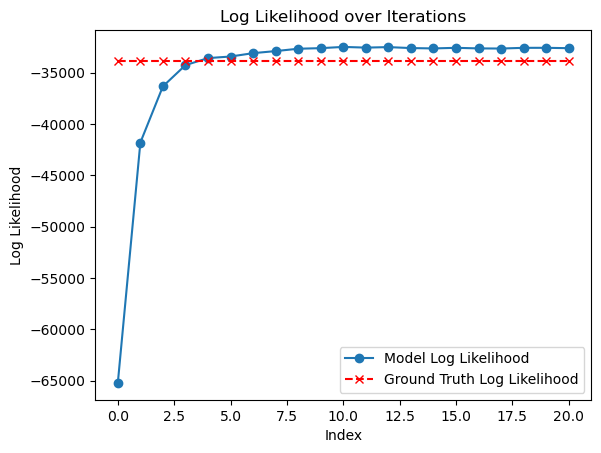

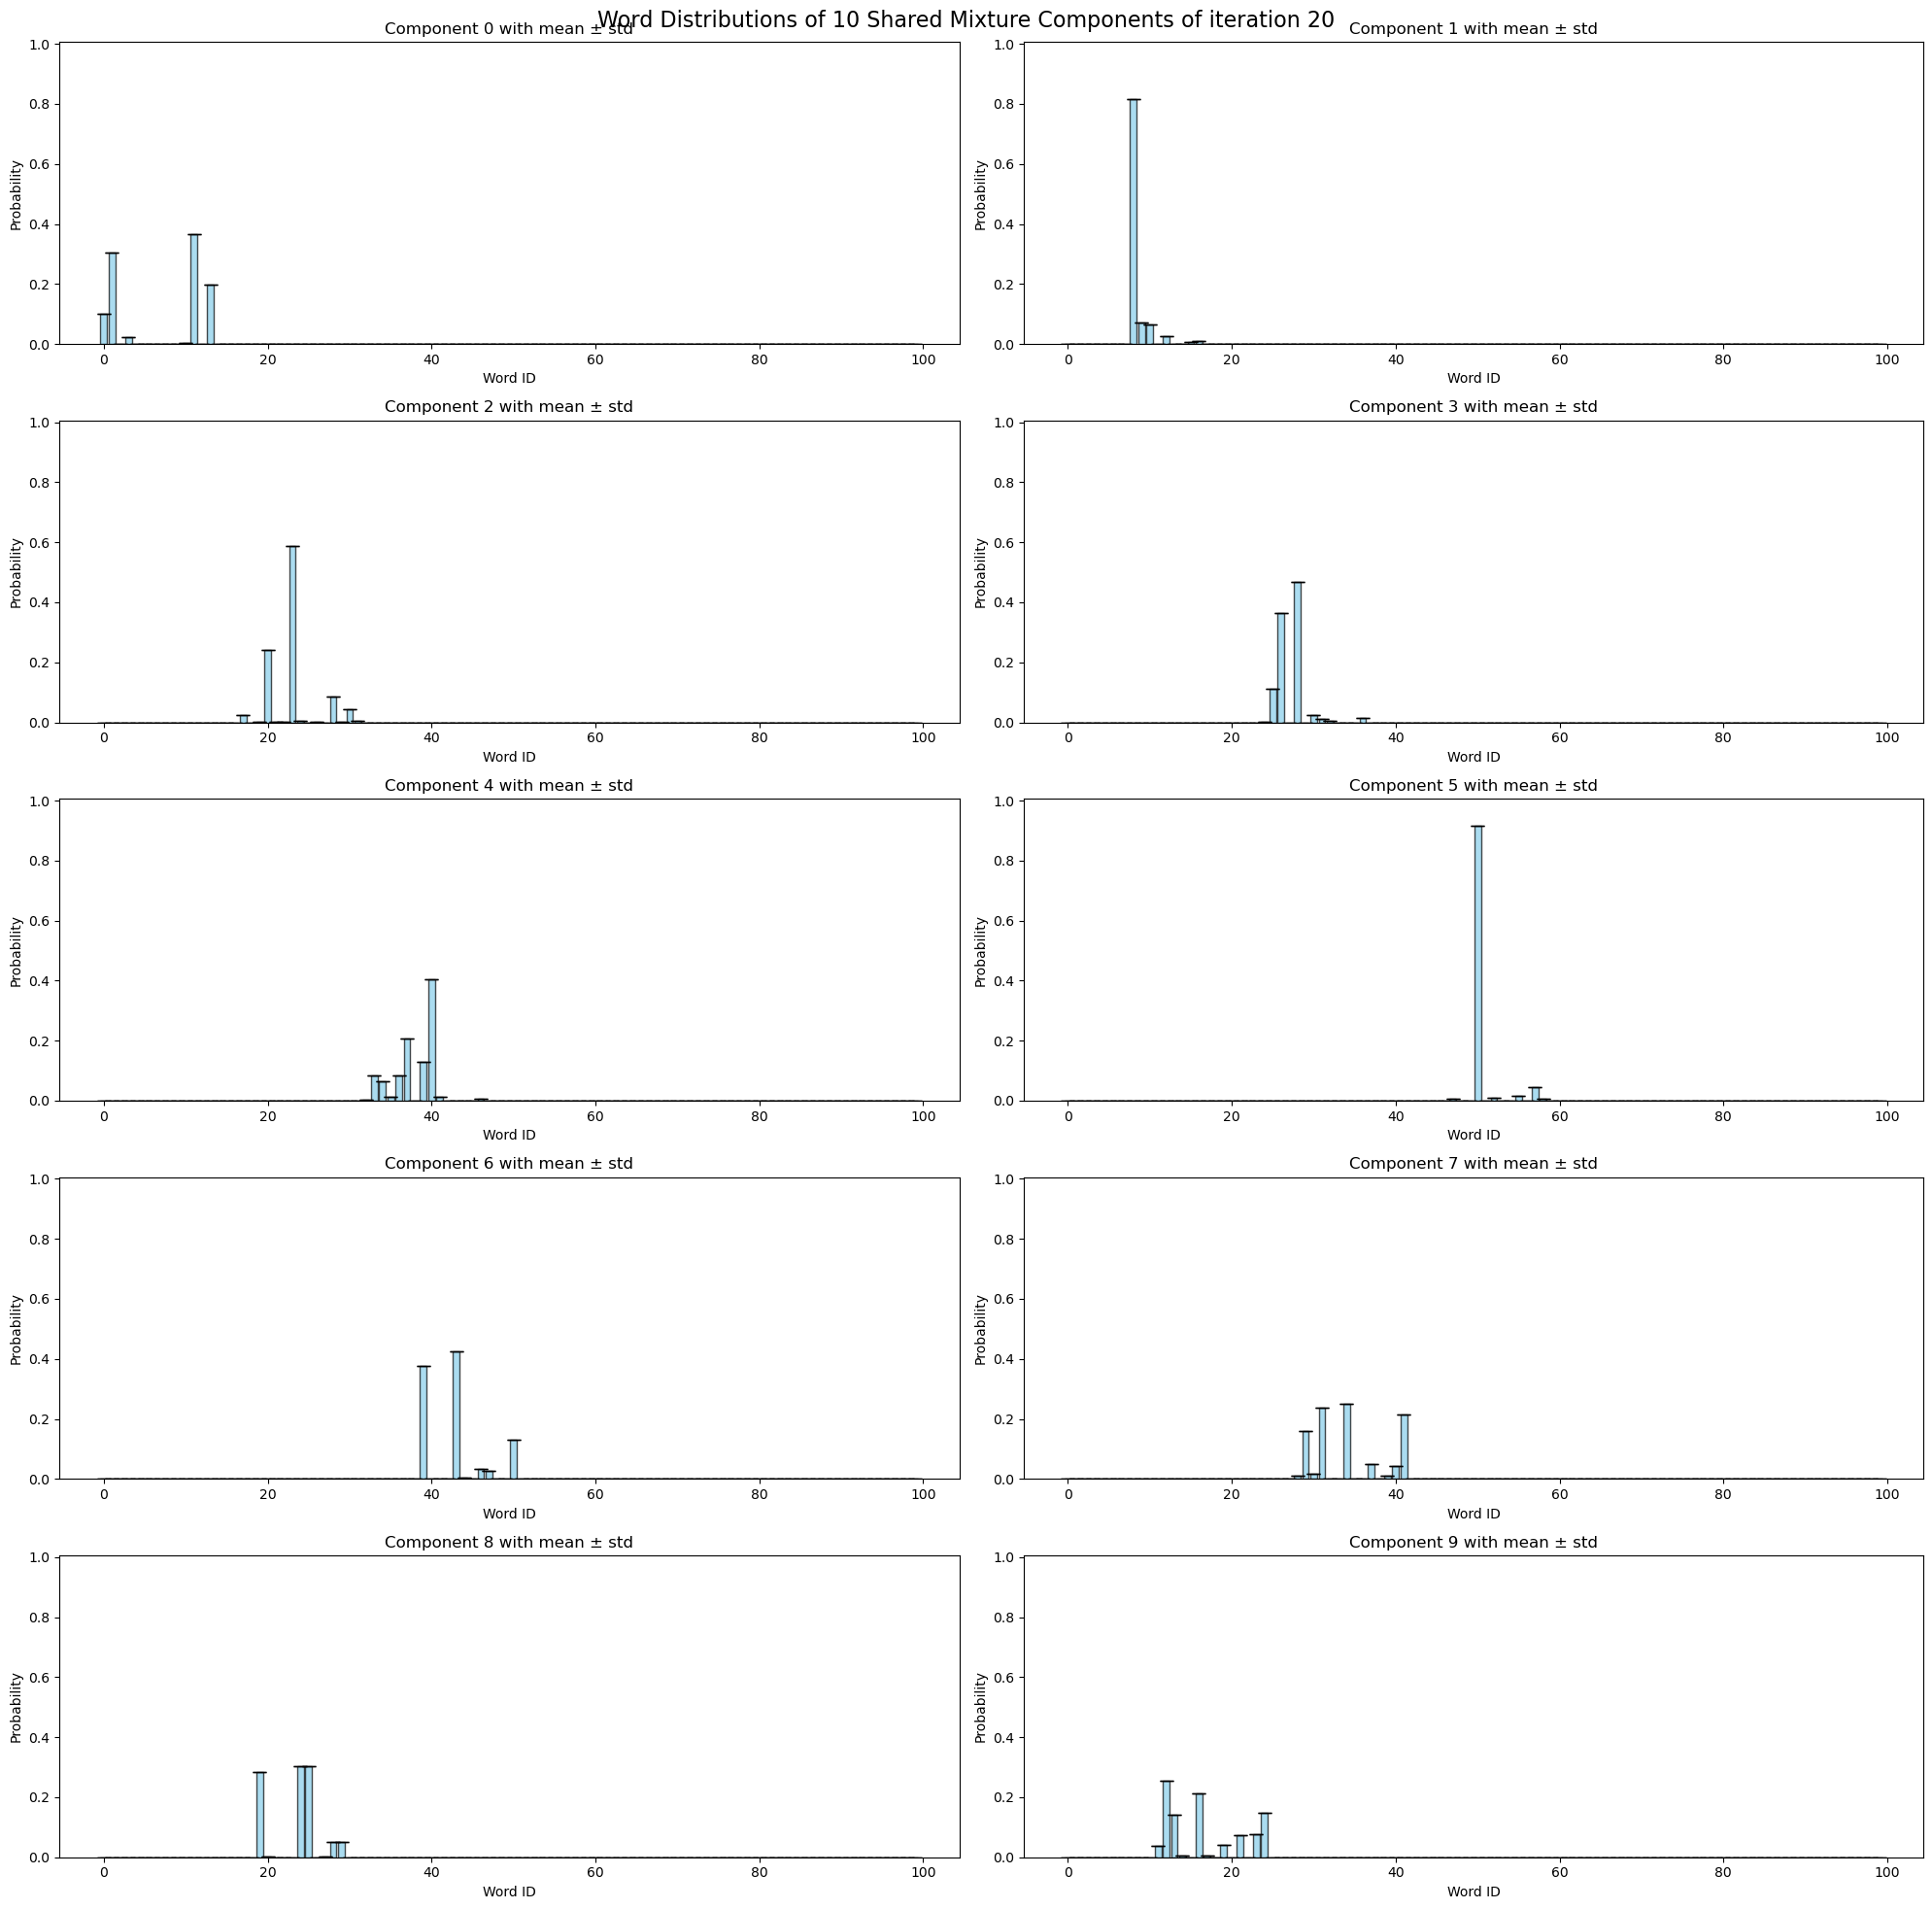

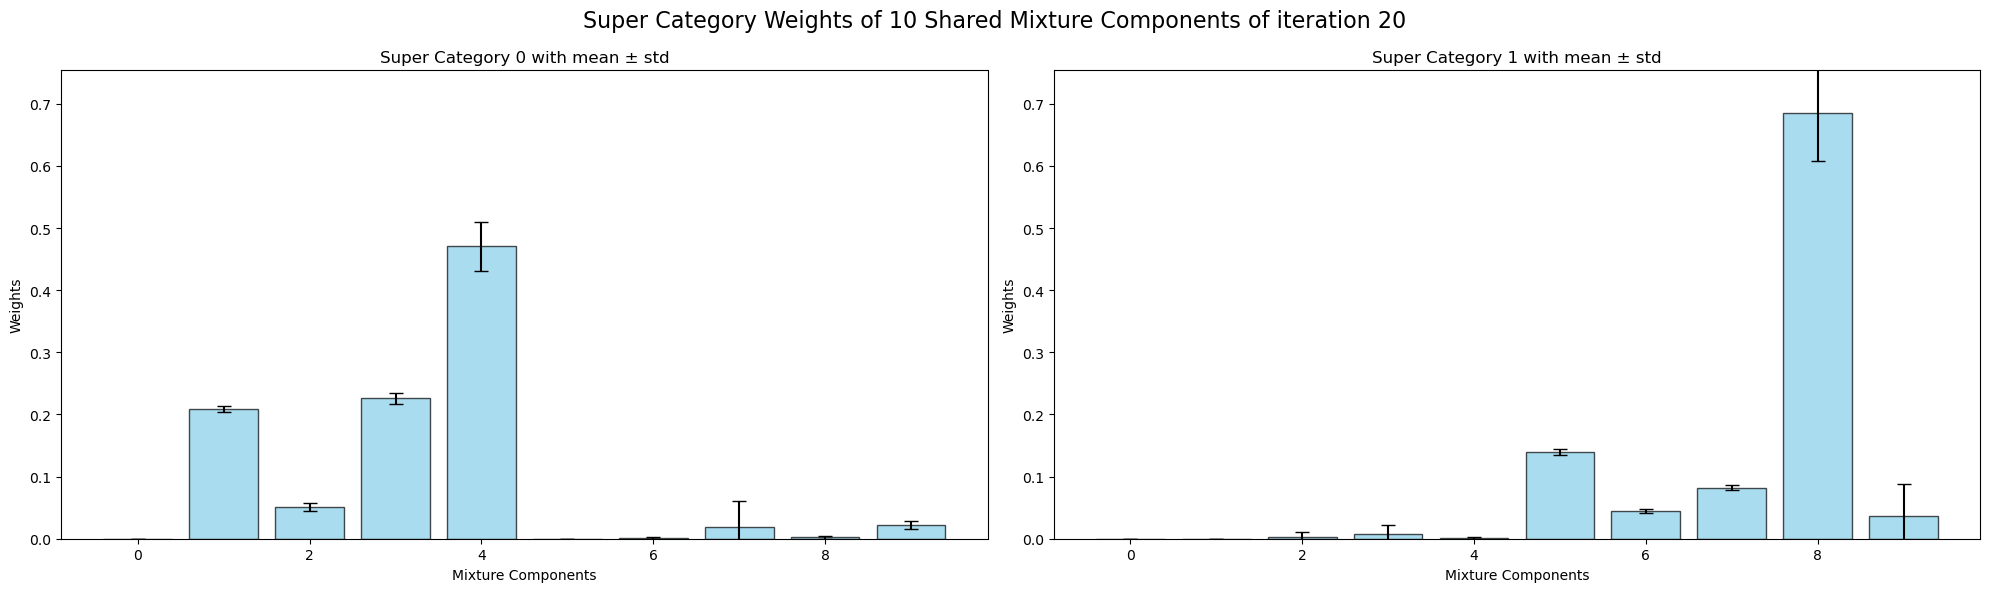

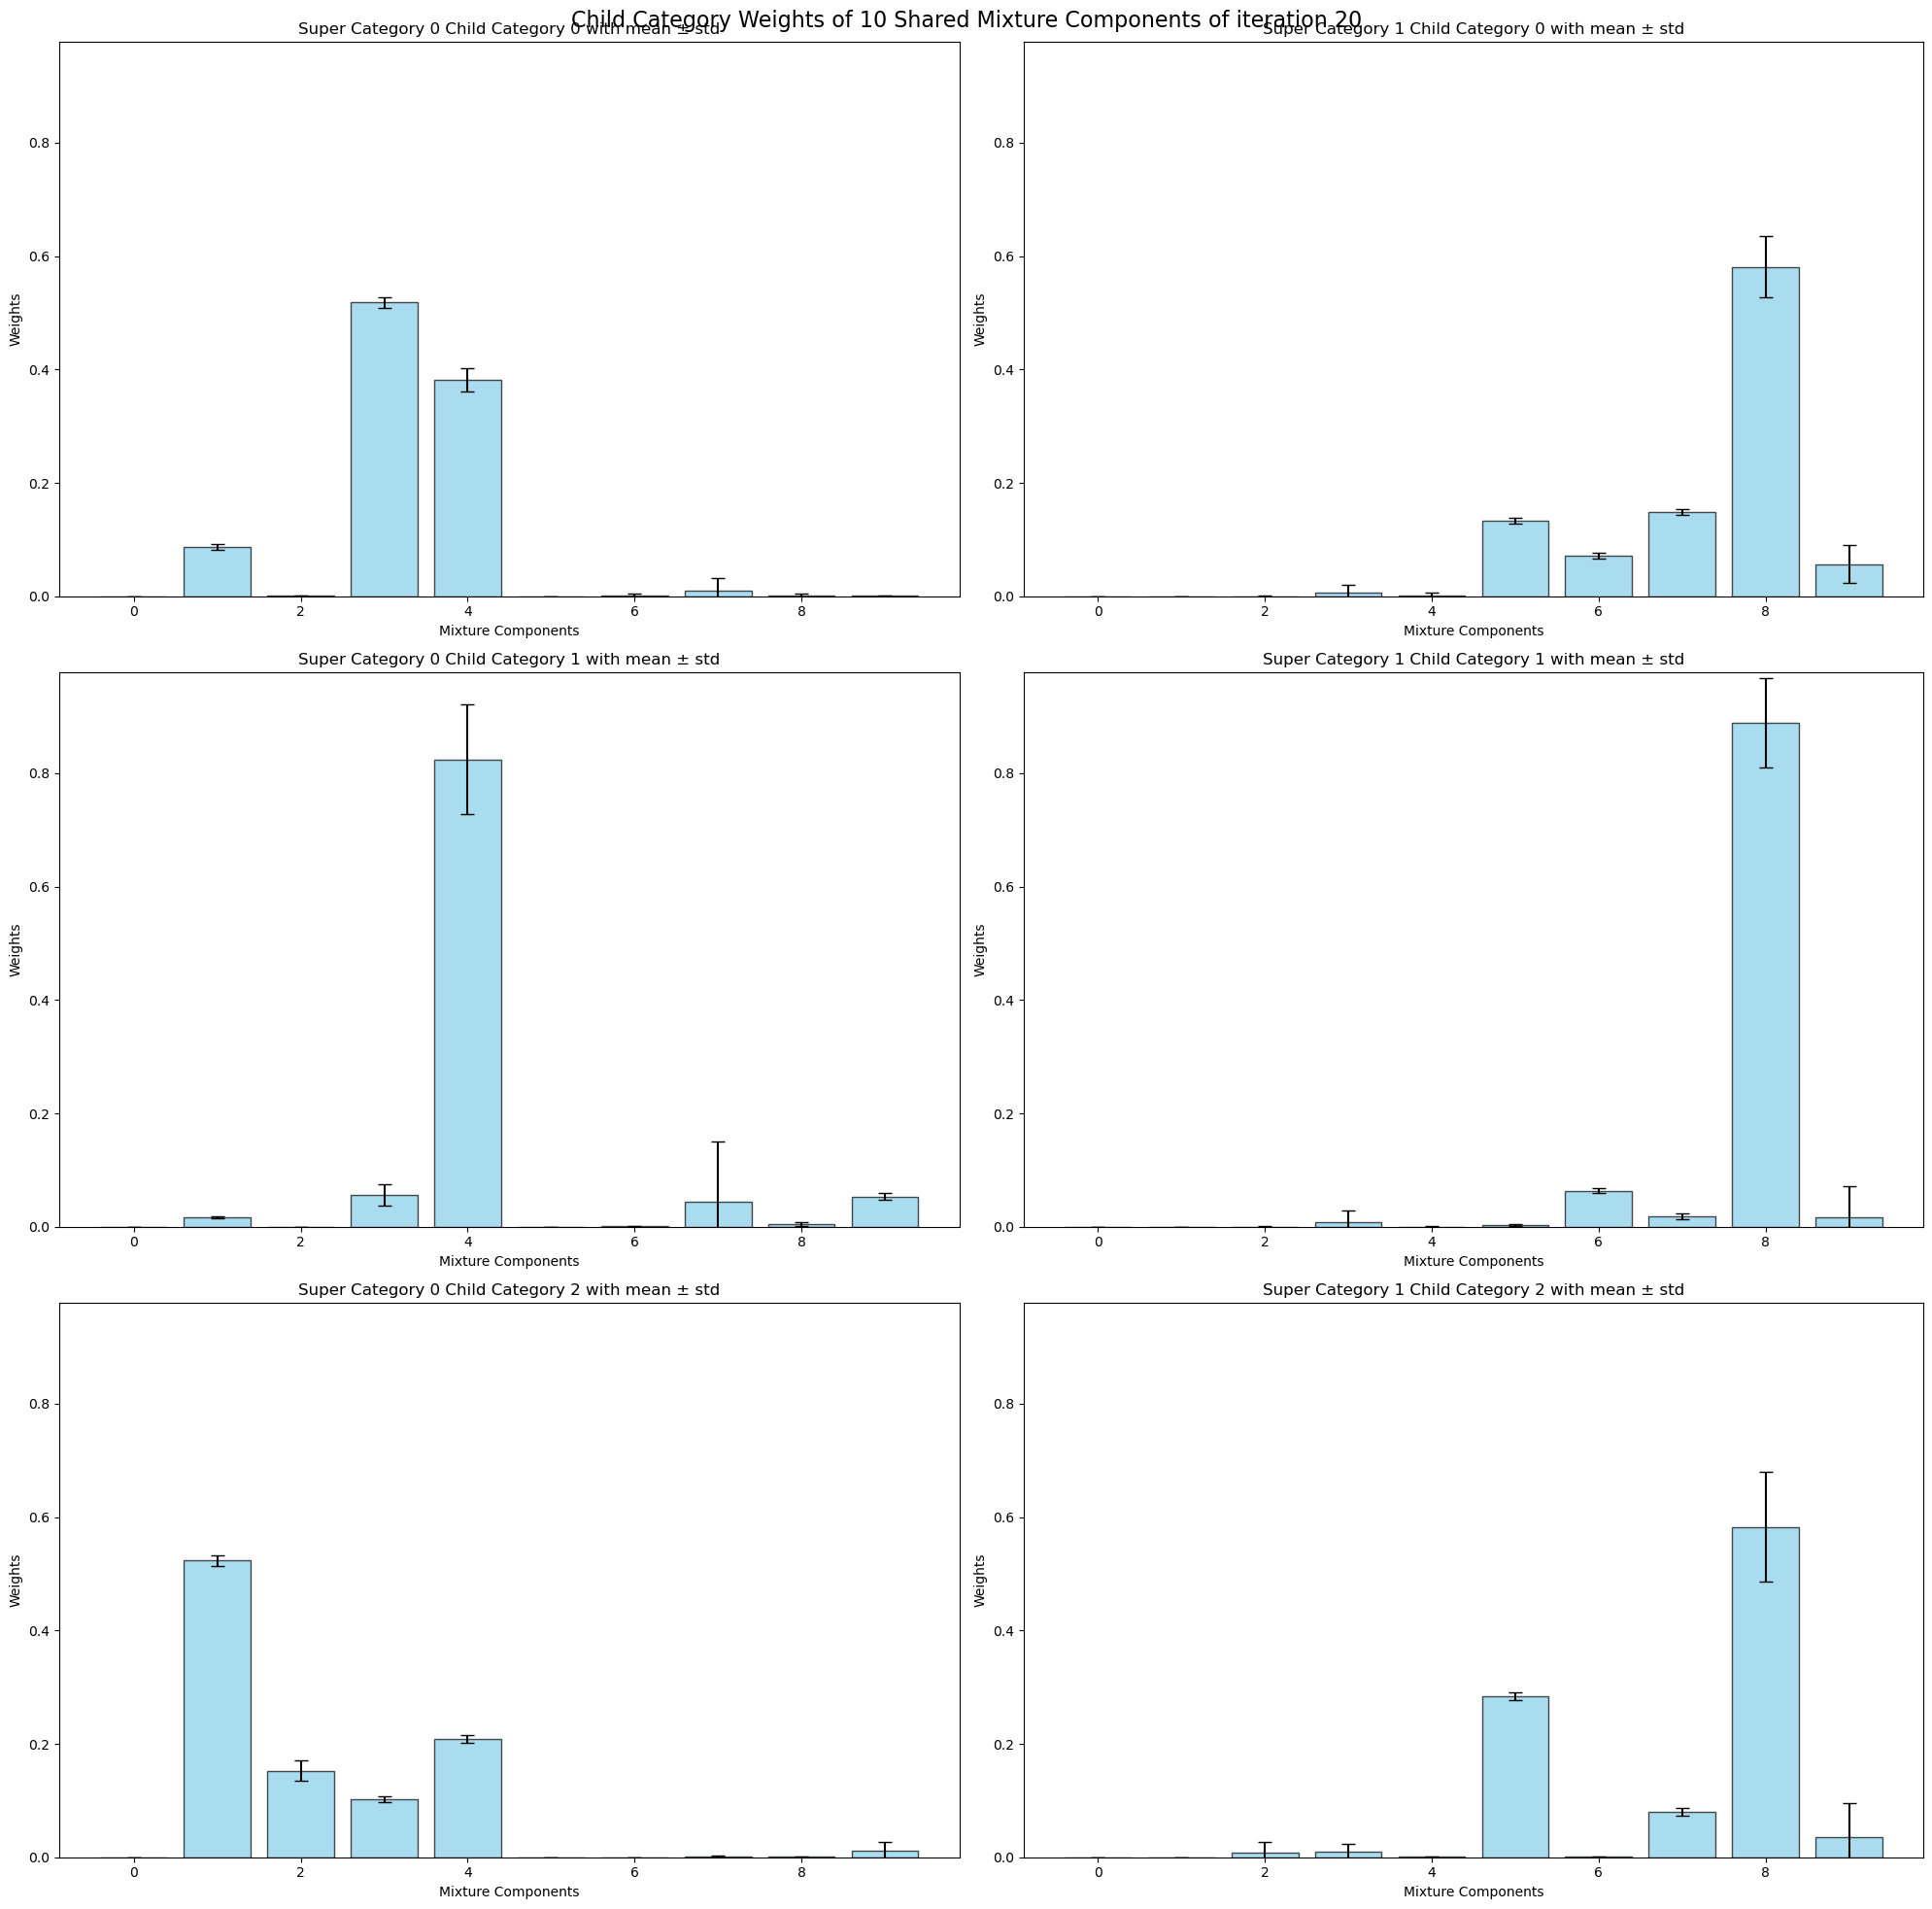

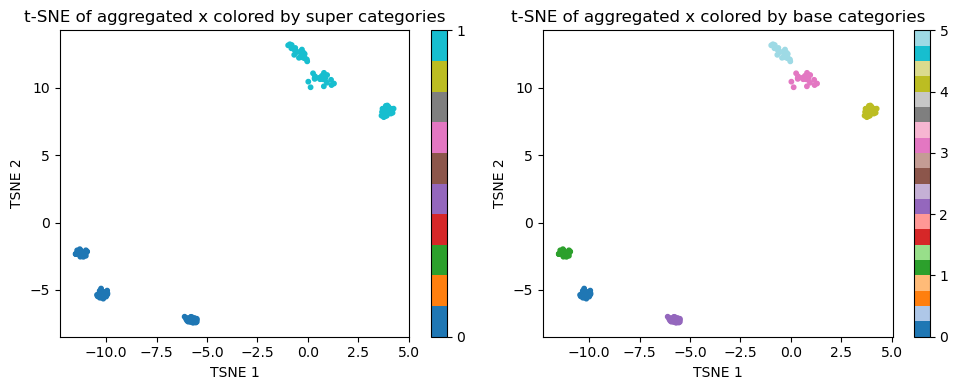

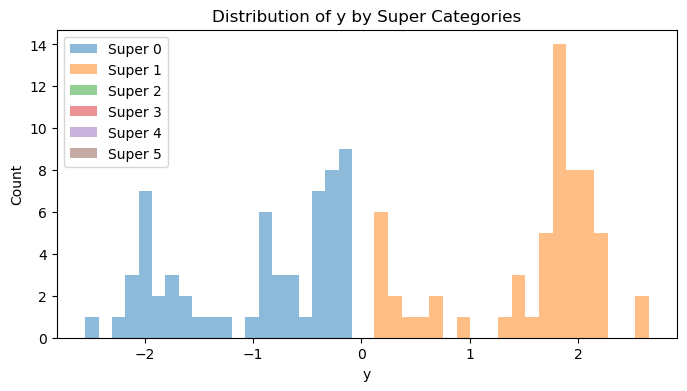

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


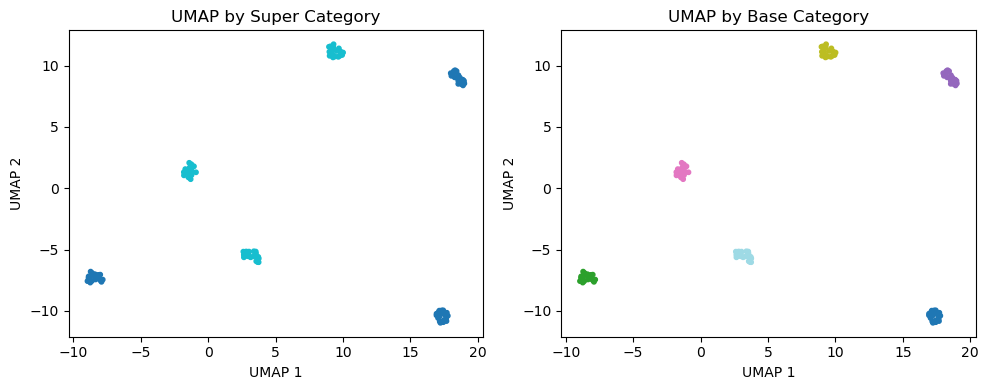

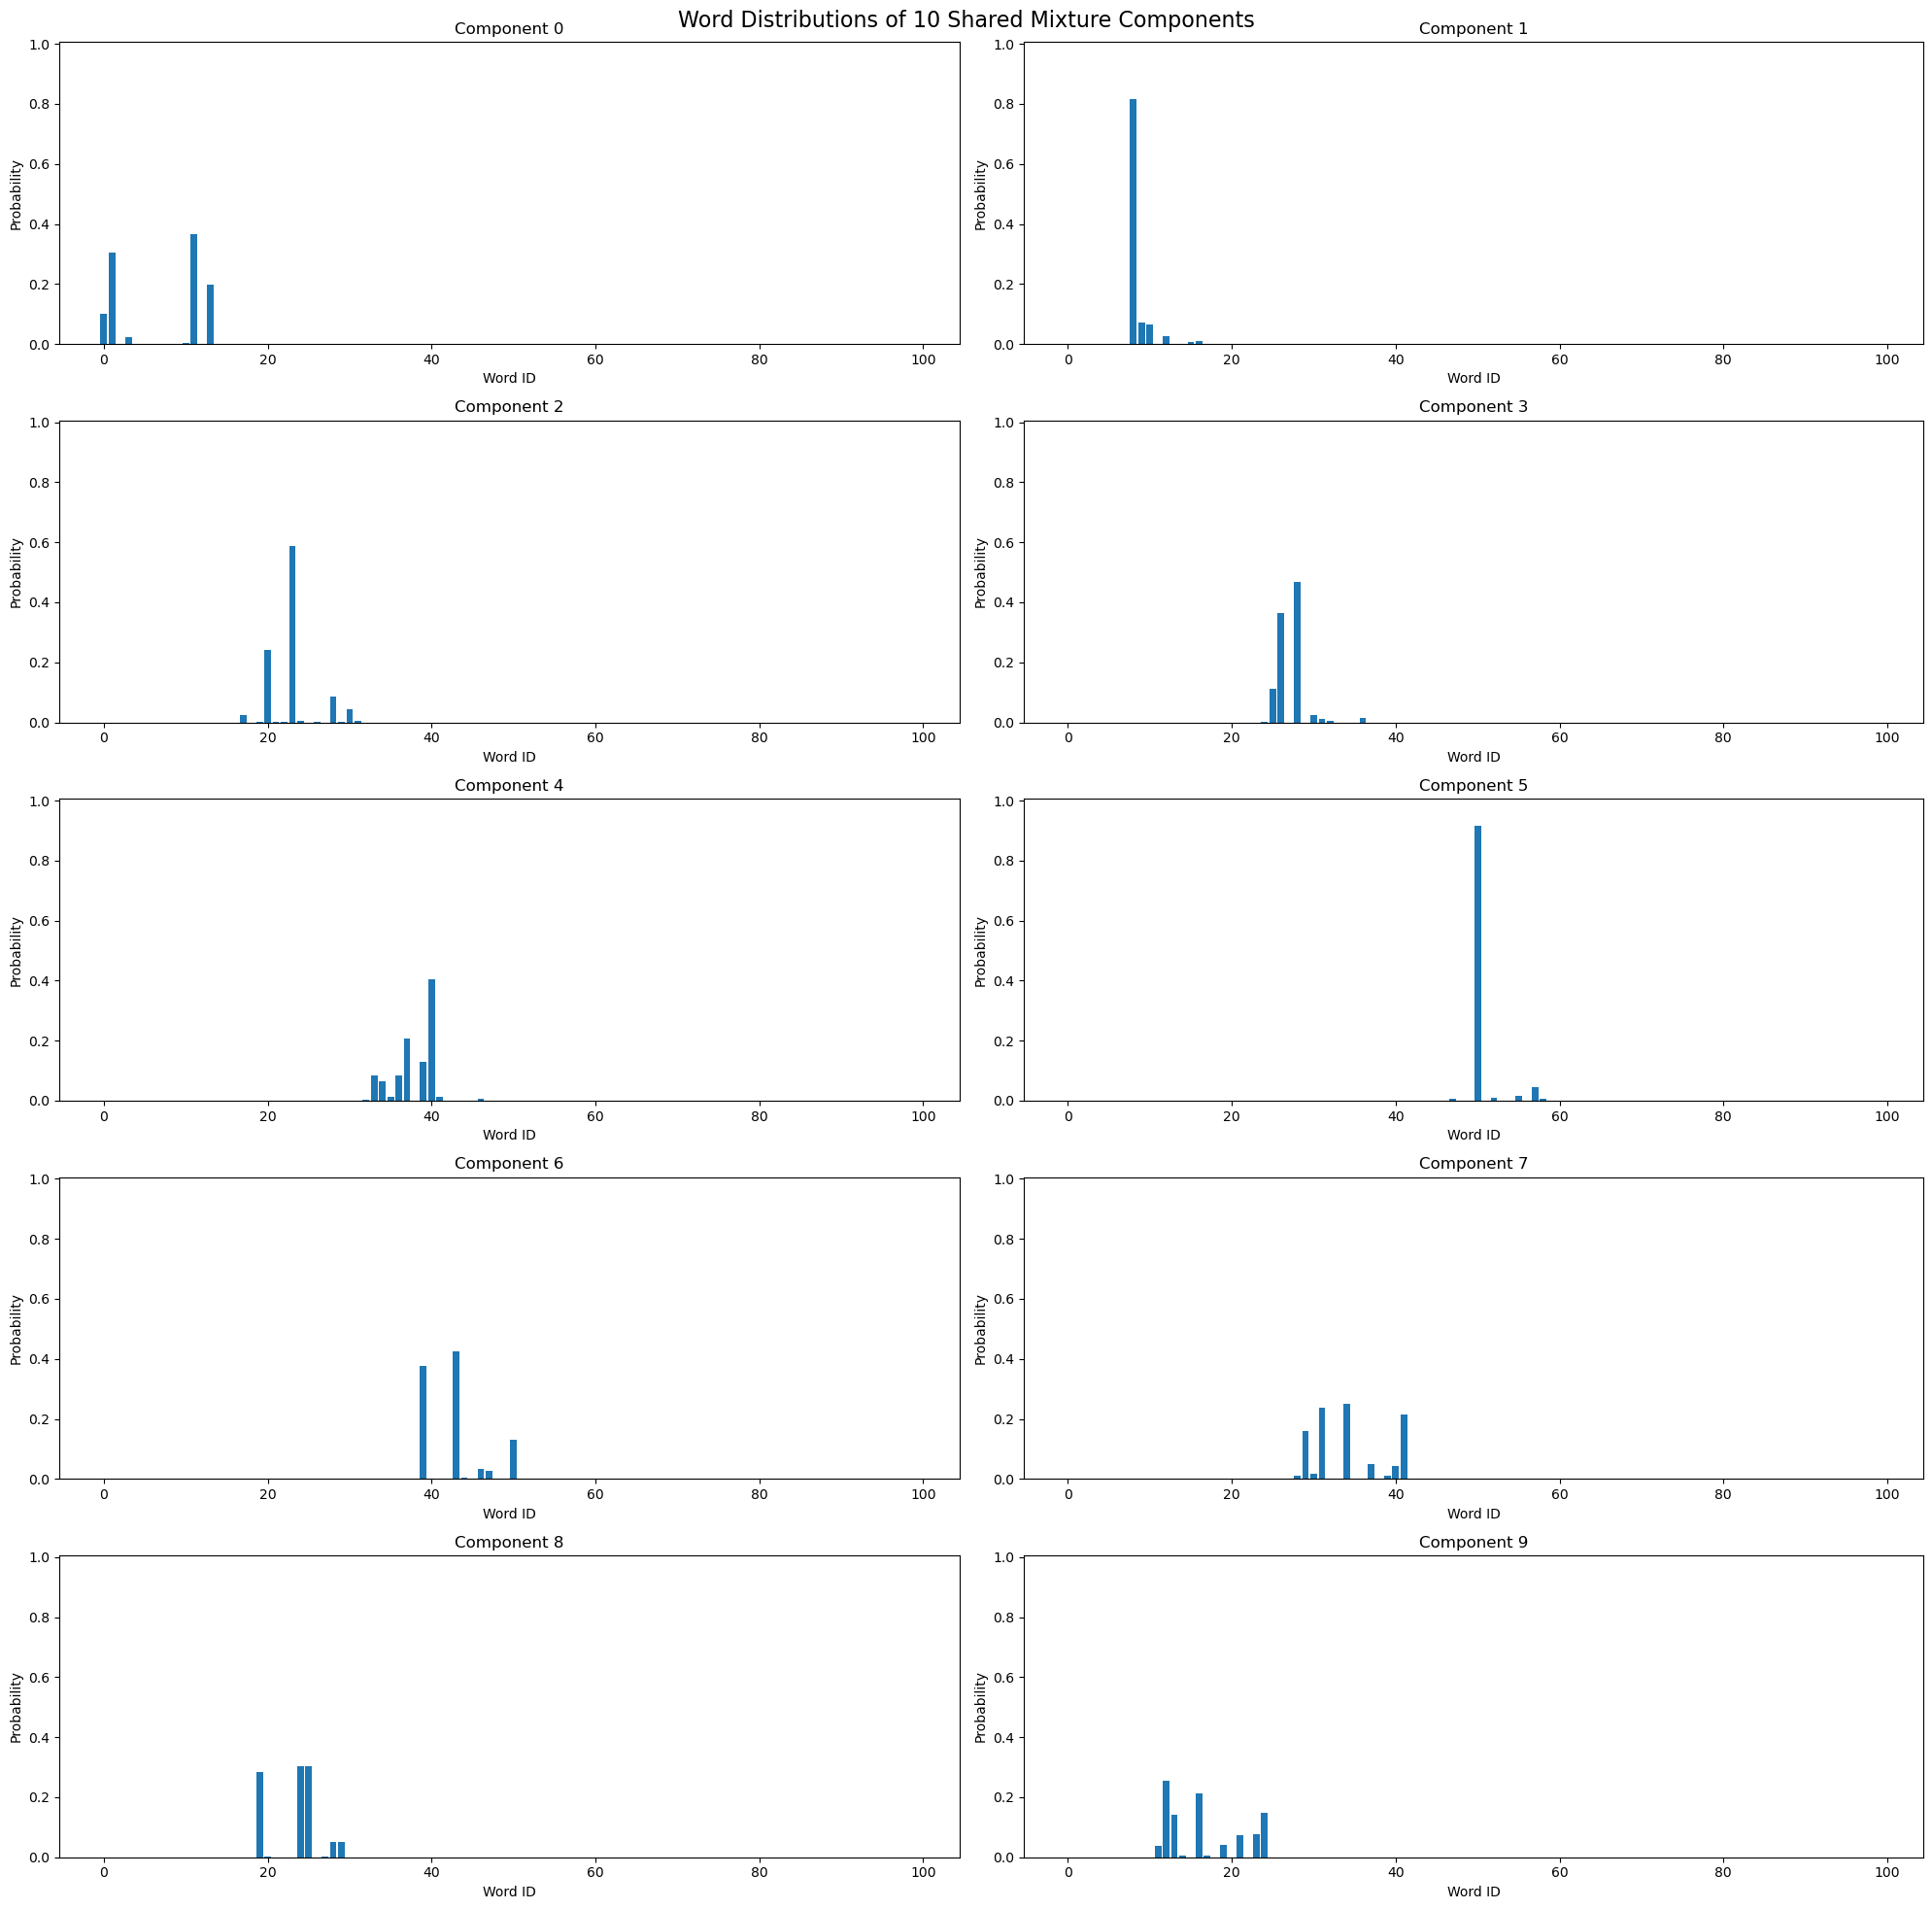

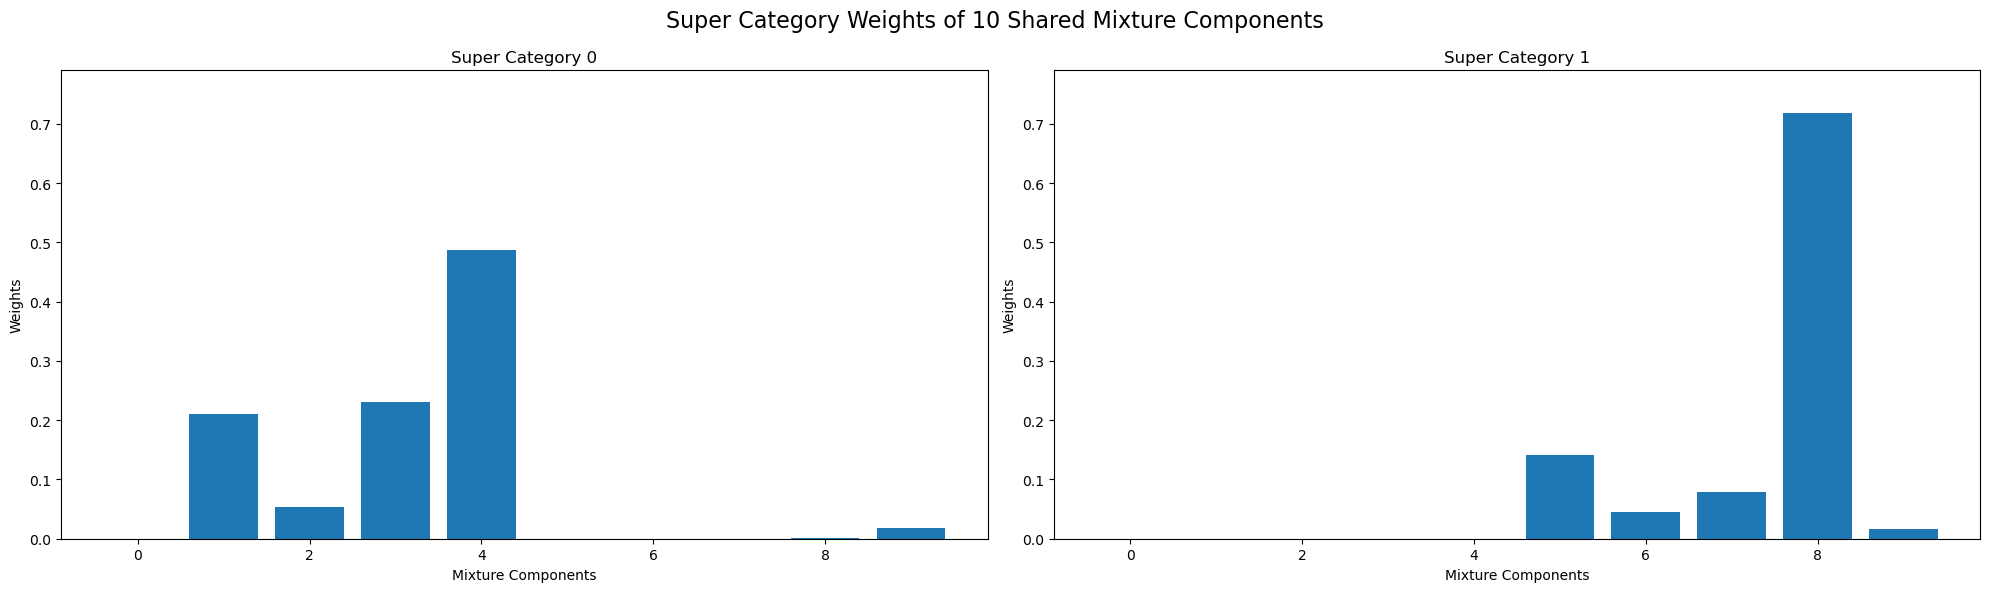

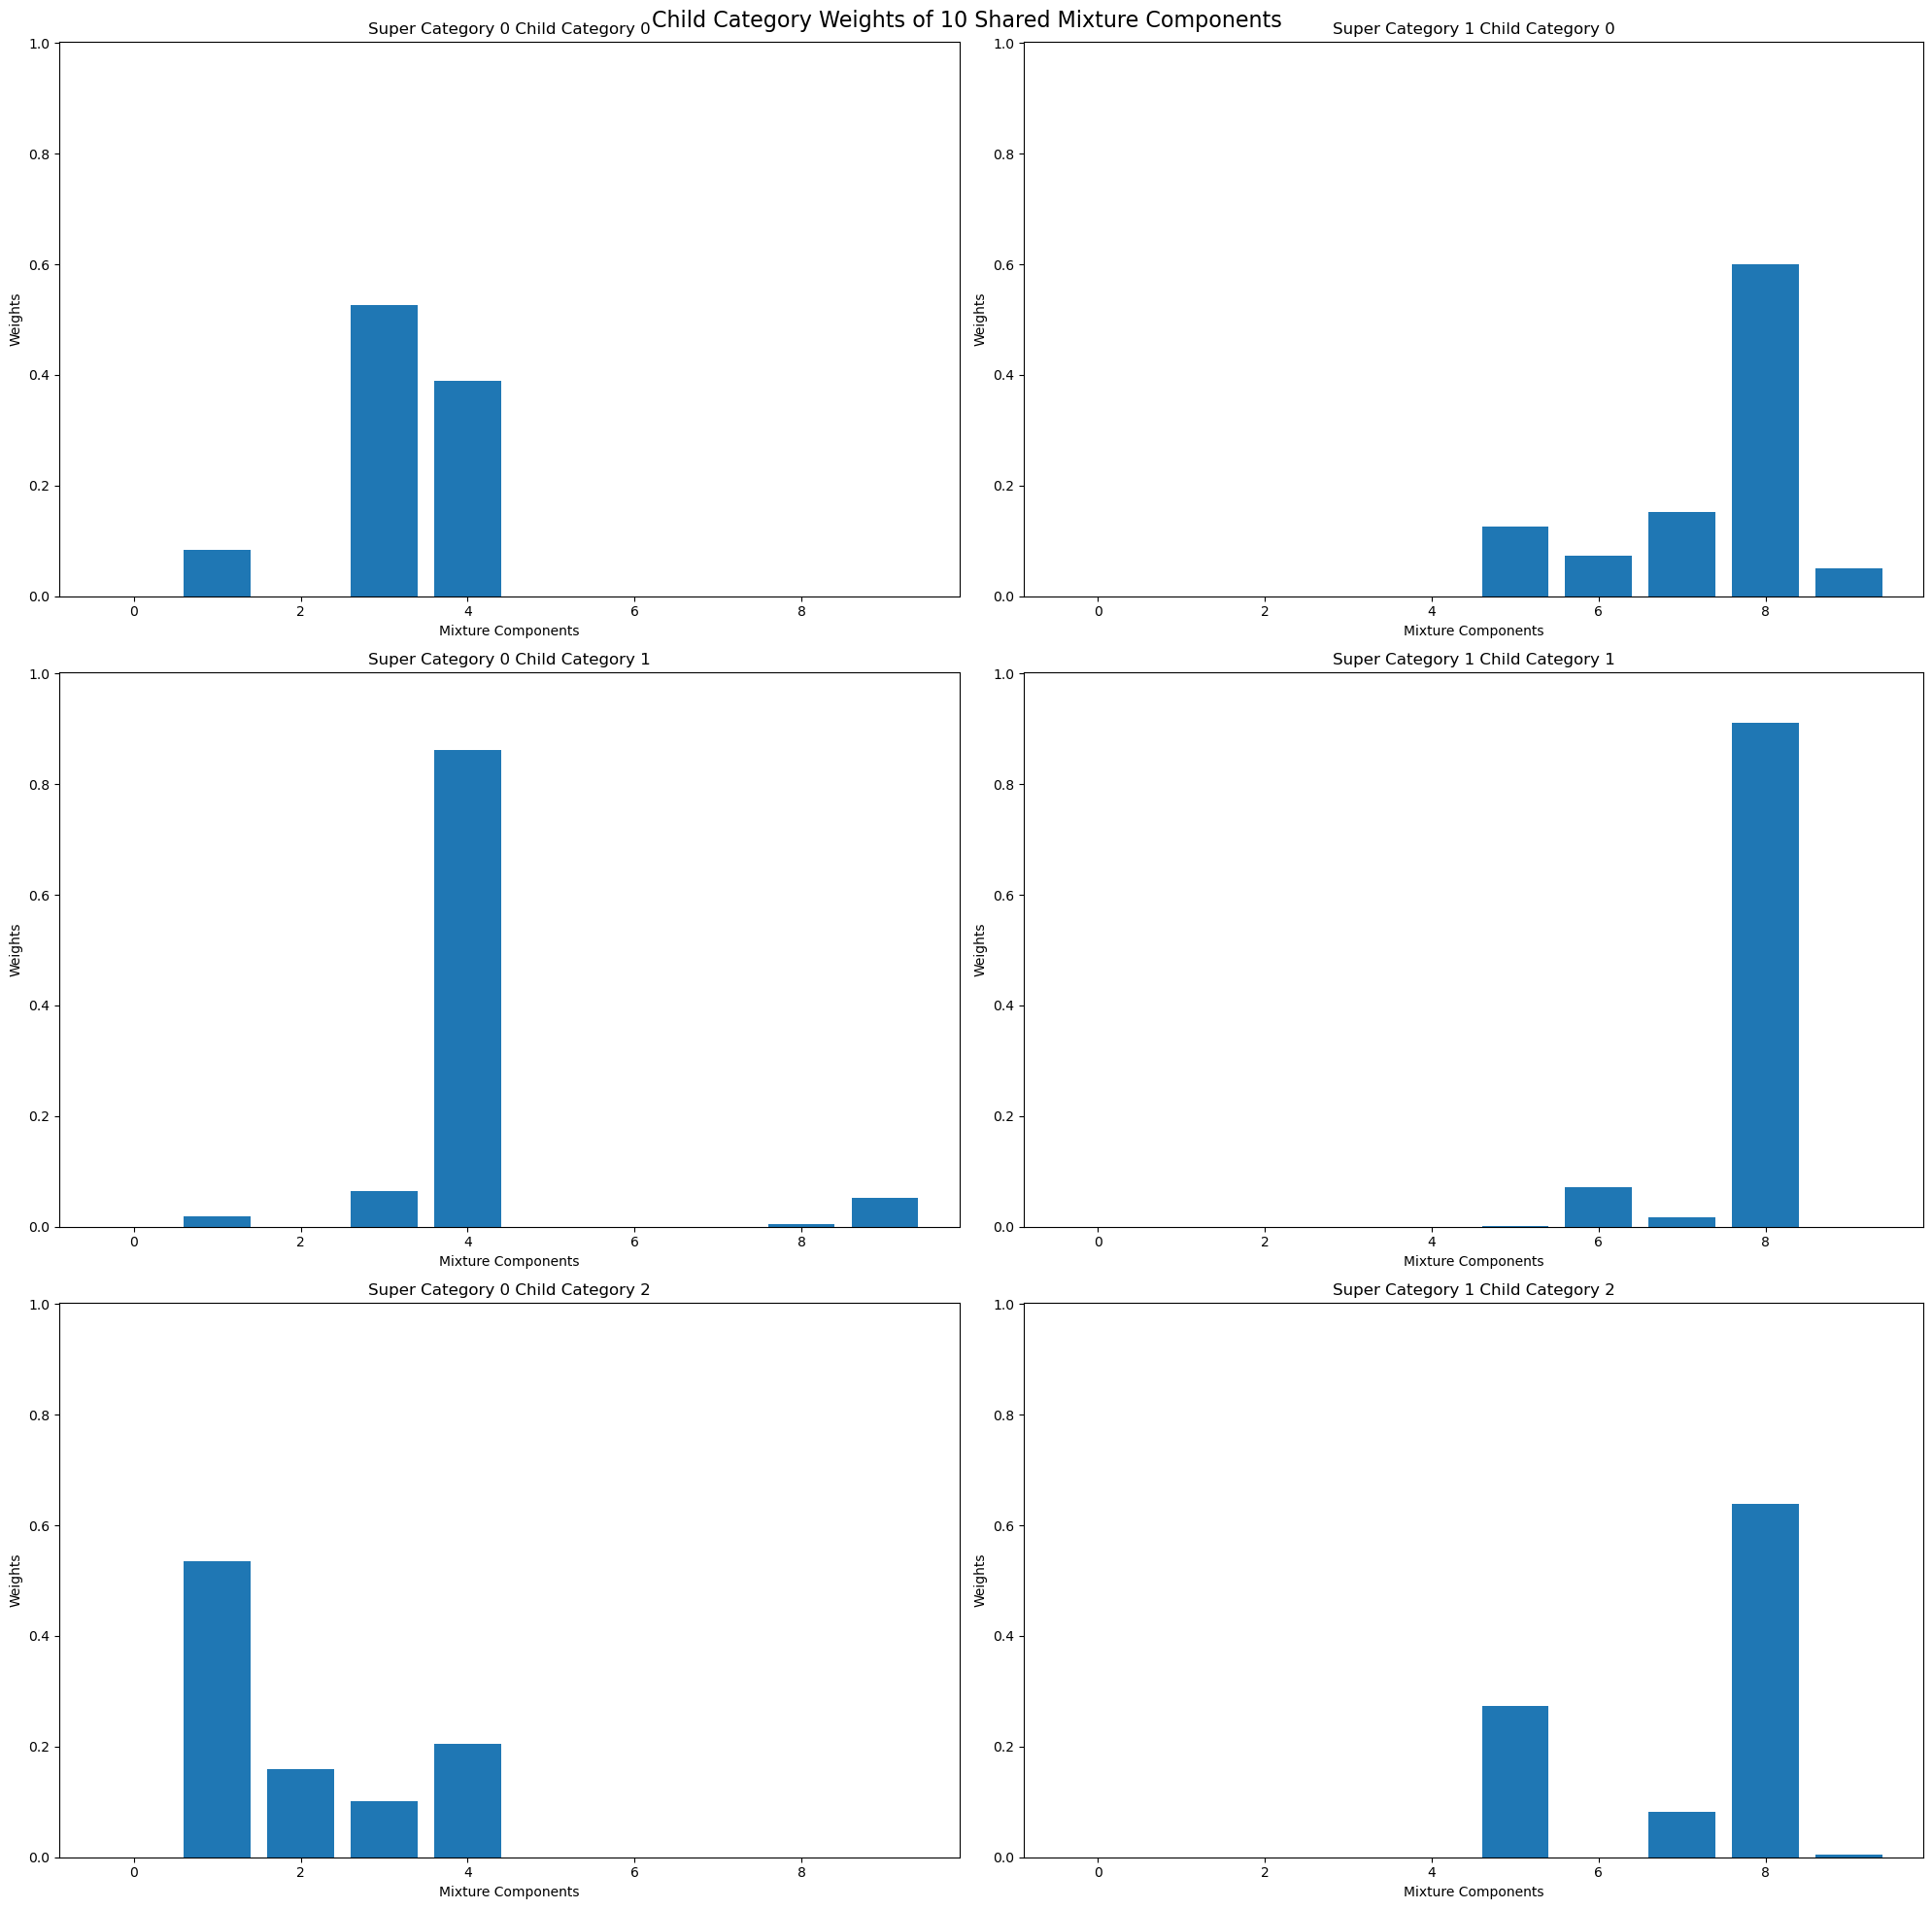

In [41]:
dataset = (data["x"], data["y"], data["base_labels"], data["super_labels"])
vocab_size = data["x"].shape[-1]
hdmm1 = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, known_base=True, known_super=True, gen_mixture=data["word_dists"], device="cpu")
model_return1 = gibbs_sampler(jax.random.PRNGKey(0), hdmm1, struct_upbd, vocab_size, num_iters=20, gt=data, known_base=True, known_super=True, gen_ground_truth=True)
data_summary(model_return1, data, struct_upbd)

Post Gibbs Sampling:   0%|          | 0/2 [00:00<?, ?it/s]

Doc 0 beta: [1.1754944e-38 9.7785883e-02 1.7471652e-02 4.2630687e-01 7.1914244e-01
 1.1754944e-38 3.1446934e-01 3.1743723e-01 9.9999988e-01 1.0000000e+00]
Doc 0 weights: [1.1754944e-38 9.7785883e-02 1.5763171e-02 3.7790012e-01 3.6572048e-01
 1.6789630e-39 4.4915762e-02 3.1081732e-02 6.6832840e-02 7.9670963e-09]


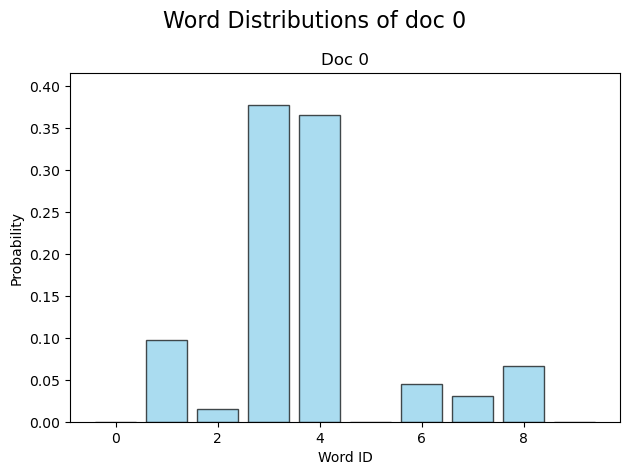

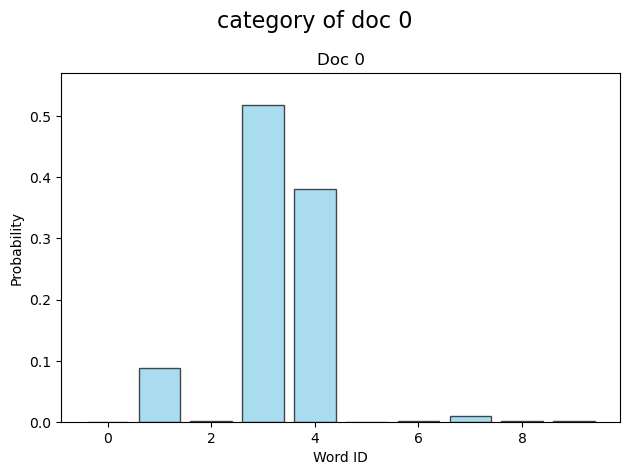

Doc 1 beta: [1.1754944e-38 8.9891732e-02 3.5492893e-02 4.4465840e-01 6.0622501e-01
 1.1754944e-38 1.3750078e-01 5.2191615e-01 9.9999988e-01 1.0000000e+00]
Doc 1 weights: [1.1754944e-38 8.9891732e-02 3.2302376e-02 3.9032376e-01 2.9552385e-01
 2.2564591e-39 2.6394410e-02 8.6410448e-02 7.9153396e-02 9.4358210e-09]


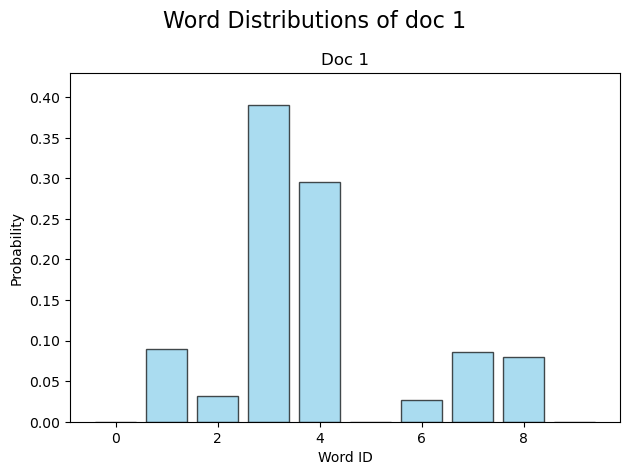

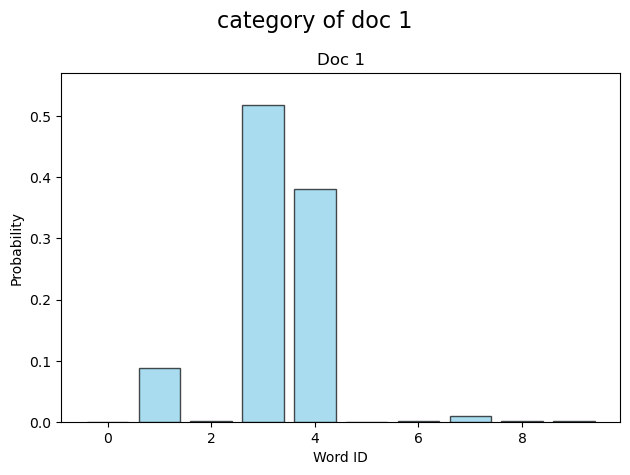

Doc 2 beta: [1.1754944e-38 1.0476677e-01 3.5669602e-02 4.8678118e-01 6.7248738e-01
 1.1754944e-38 3.6700472e-01 1.2706967e-01 9.9999988e-01 1.0000000e+00]
Doc 2 weights: [1.1754944e-38 1.0476677e-01 3.1932611e-02 4.2023847e-01 2.9795367e-01
 1.7057418e-39 5.3255480e-02 1.1671724e-02 8.0181219e-02 9.5583470e-09]


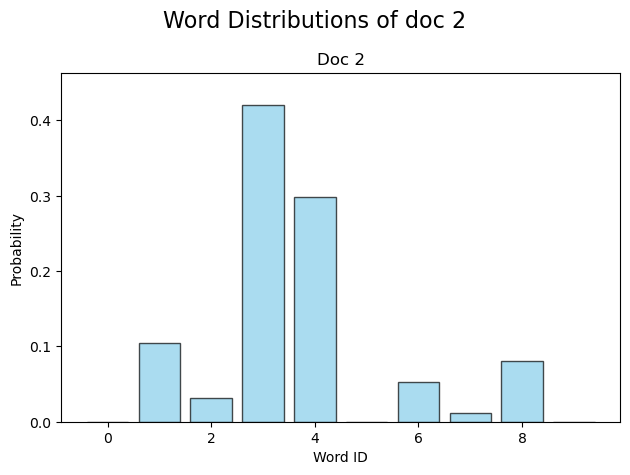

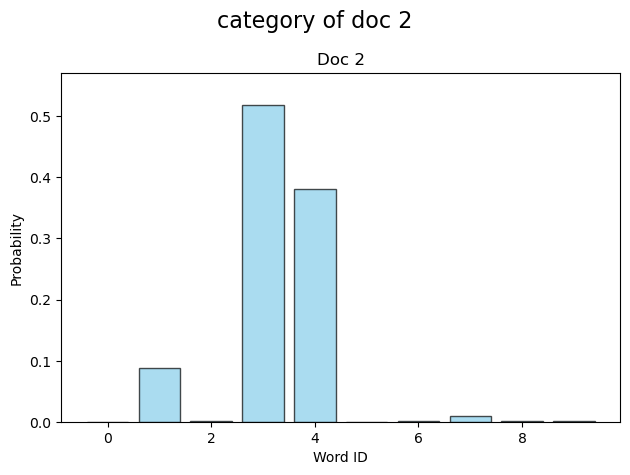

Doc 3 beta: [1.17549435e-38 1.02790765e-01 1.69714051e-03 4.37467545e-01
 6.68621540e-01 1.17549435e-38 1.88581675e-01 2.11672276e-01
 9.99999881e-01 1.00000000e+00]
Doc 3 weights: [1.17549435e-38 1.02790765e-01 1.52269017e-03 3.91833812e-01
 3.36886793e-01 1.96267544e-39 3.14867161e-02 2.86771972e-02
 1.06802009e-01 1.27317934e-08]


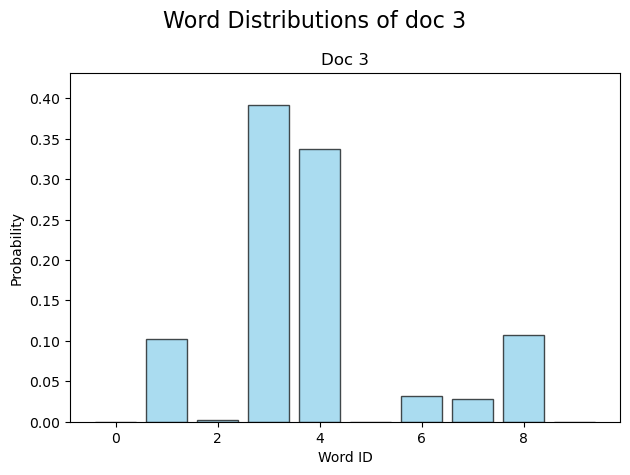

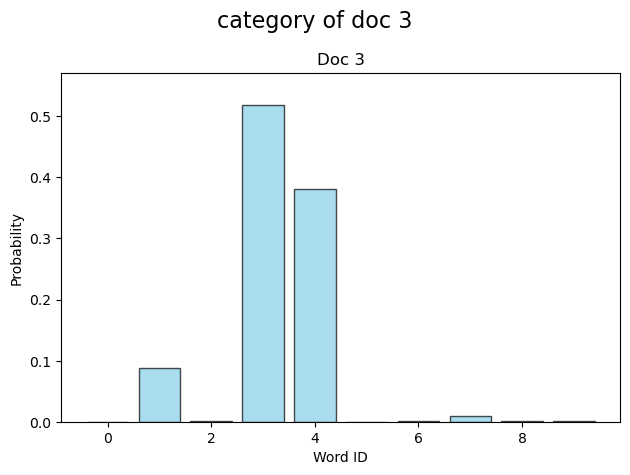

Doc 4 beta: [1.1754944e-38 9.1120854e-02 2.4114810e-03 4.1724136e-01 7.2909826e-01
 1.1754944e-38 2.8560334e-01 4.7613347e-01 9.8662728e-01 1.0000000e+00]
Doc 4 weights: [1.1754944e-38 9.1120854e-02 2.1917447e-03 3.7830749e-01 3.8524091e-01
 1.6825909e-39 4.0880993e-02 4.8688482e-02 5.2853204e-02 7.1637088e-04]


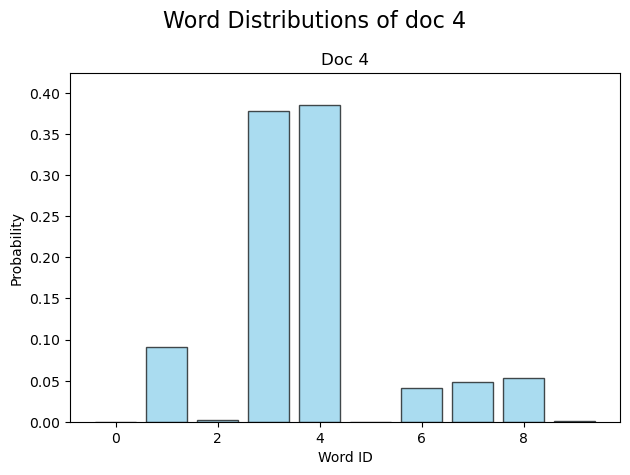

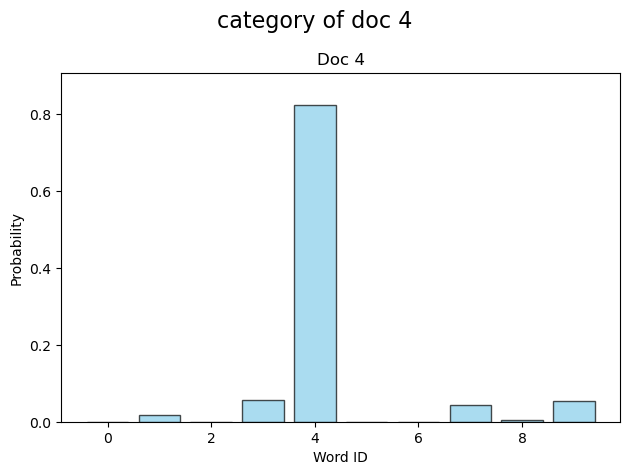

Doc 5 beta: [1.1754944e-38 6.2707134e-02 1.5880946e-02 4.7308379e-01 7.1955878e-01
 1.1754944e-38 2.2497325e-01 1.0269585e-01 9.2199302e-01 1.0000000e+00]
Doc 5 weights: [1.1754944e-38 6.2707134e-02 1.4885098e-02 4.3637618e-01 3.4972832e-01
 1.6022377e-39 3.0664597e-02 1.0848657e-02 8.7395765e-02 7.3942859e-03]


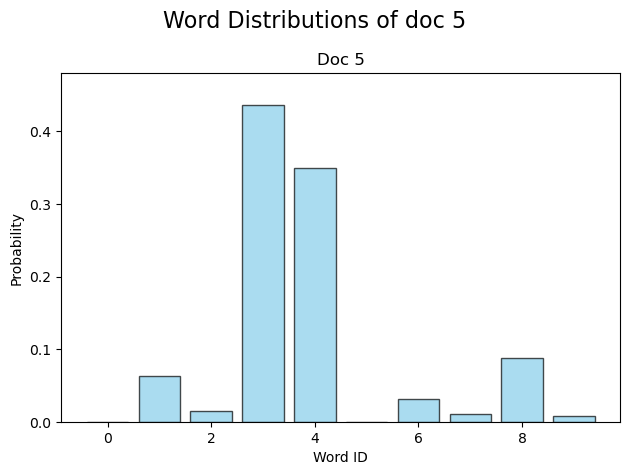

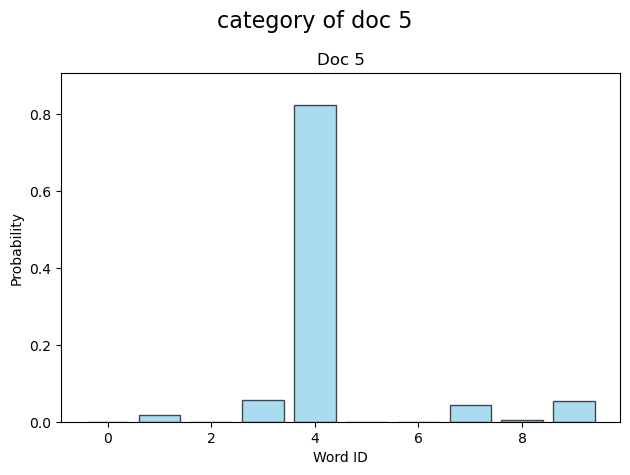

Doc 6 beta: [1.1754944e-38 1.5227868e-01 1.3685789e-02 4.9236146e-01 6.9804066e-01
 1.1754944e-38 3.6059019e-01 4.1660866e-01 9.3471605e-01 1.0000000e+00]
Doc 6 weights: [1.1754944e-38 1.5227868e-01 1.1601735e-02 4.1167310e-01 2.9628098e-01
 1.5065794e-39 4.6215259e-02 3.4141220e-02 4.4687945e-02 3.1211679e-03]


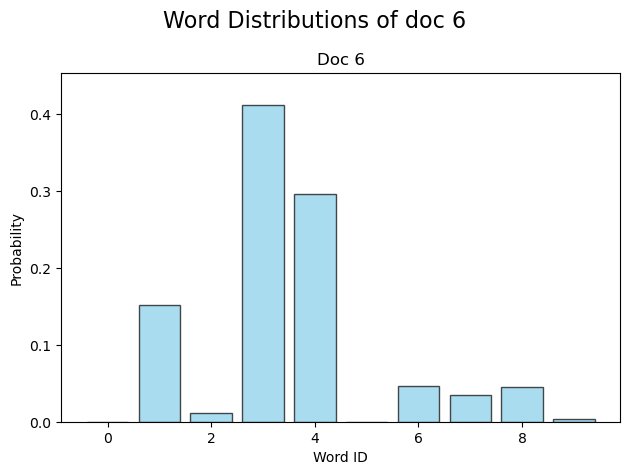

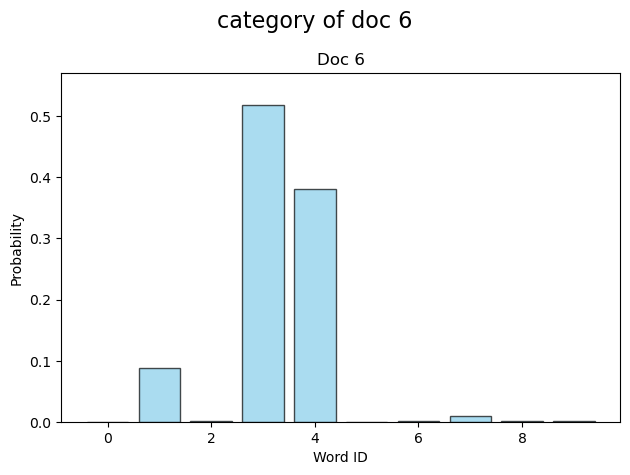

Doc 7 beta: [1.1754944e-38 9.9878743e-02 2.9331449e-02 4.9168059e-01 7.0636123e-01
 1.1754944e-38 2.9930723e-01 2.2696534e-01 9.9999988e-01 1.0000000e+00]
Doc 7 weights: [1.1754944e-38 9.9878743e-02 2.6401861e-02 4.2959088e-01 3.1371516e-01
 1.5330009e-39 3.9033659e-02 2.0740023e-02 7.0639670e-02 8.4209058e-09]


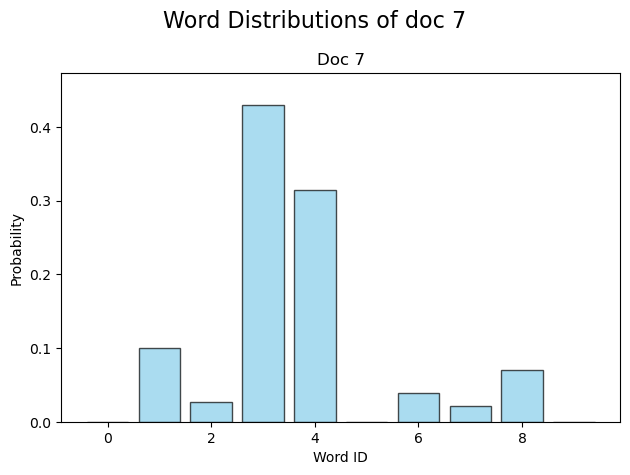

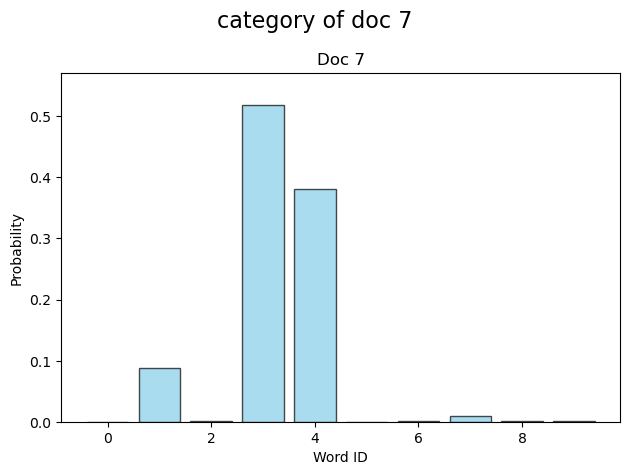

Doc 8 beta: [1.1754944e-38 1.2929825e-01 3.5120554e-02 4.7630027e-01 7.2587514e-01
 1.1754944e-38 2.3674254e-01 2.1688762e-01 9.9999988e-01 1.0000000e+00]
Doc 8 weights: [1.1754944e-38 1.2929825e-01 3.0579528e-02 4.0015045e-01 3.1936461e-01
 1.4177315e-39 2.8552858e-02 1.9965449e-02 7.2088897e-02 8.5936671e-09]


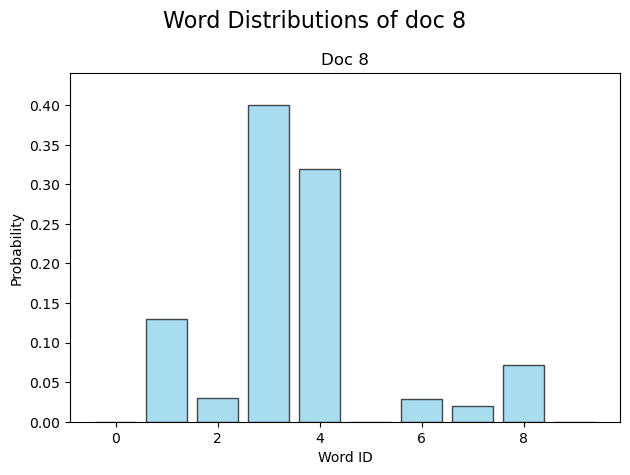

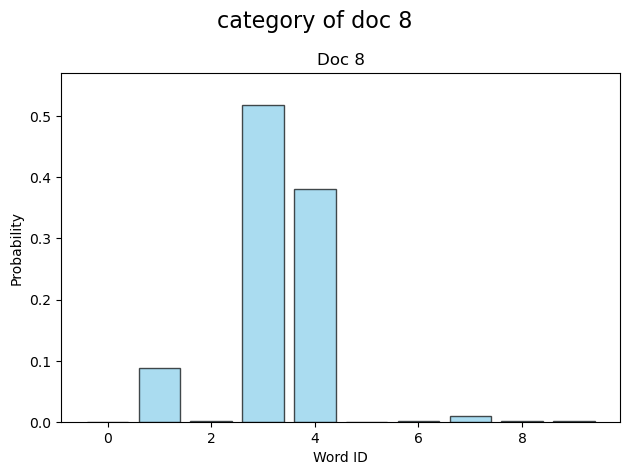

Doc 9 beta: [1.1754944e-38 1.0615167e-01 1.1754944e-38 4.6381873e-01 6.9276899e-01
 1.1754944e-38 1.6735931e-01 3.2567075e-01 9.9999988e-01 1.0000000e+00]
Doc 9 weights: [1.1754944e-38 1.0615167e-01 1.0507136e-38 4.1458359e-01 3.3201972e-01
 1.7308558e-39 2.4642818e-02 3.9927937e-02 8.2674220e-02 9.8555359e-09]


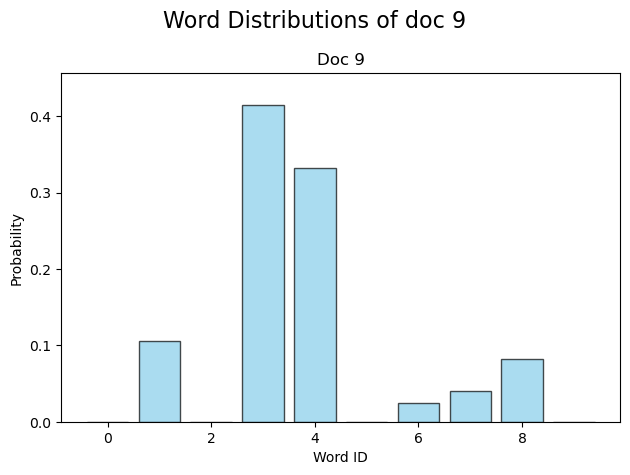

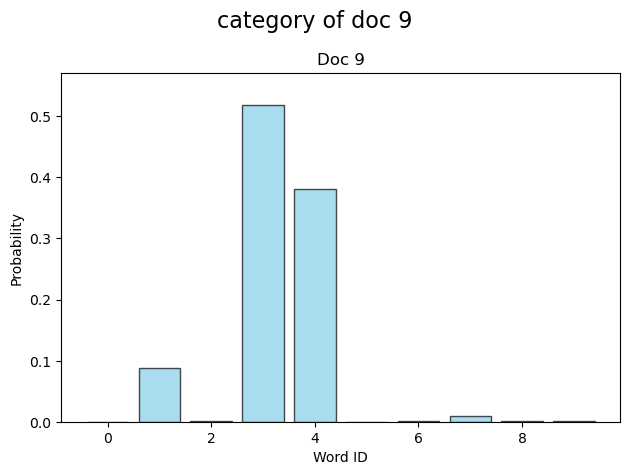

Doc 10 beta: [1.1754944e-38 5.8900528e-02 2.2309044e-02 4.8003975e-01 6.3914883e-01
 1.1754944e-38 4.3168244e-01 3.6955482e-01 9.9999988e-01 1.0000000e+00]
Doc 10 weights: [1.1754944e-38 5.8900528e-02 2.0995030e-02 4.4168669e-01 3.0578014e-01
 2.0293450e-39 7.4524626e-02 3.6258124e-02 6.1854847e-02 7.3736732e-09]


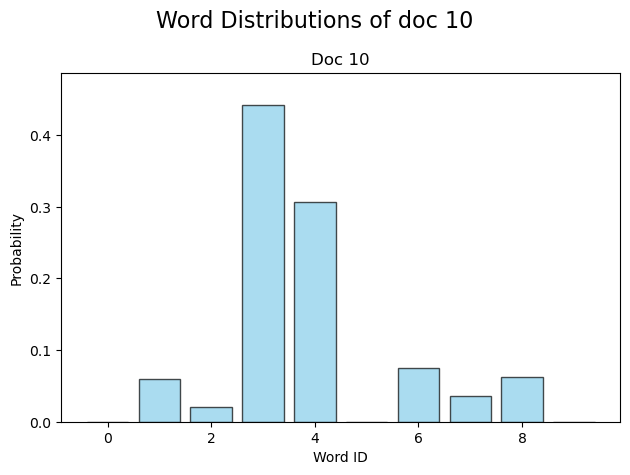

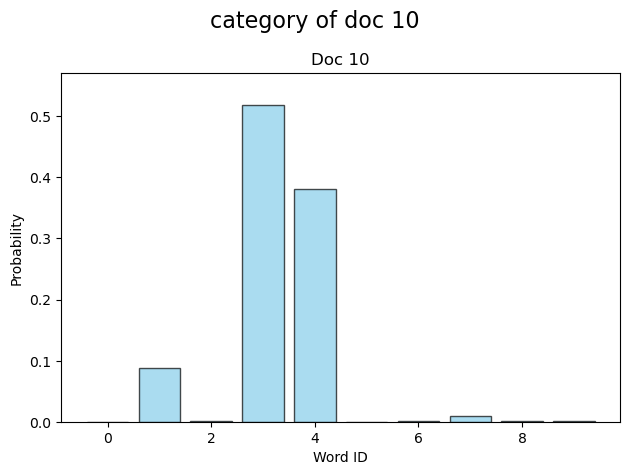

Doc 11 beta: [1.1754944e-38 9.1144629e-02 7.4172434e-03 5.2693290e-01 5.9195852e-01
 1.1754944e-38 5.0171781e-01 1.8376963e-01 9.9999988e-01 1.0000000e+00]
Doc 11 weights: [1.1754944e-38 9.1144629e-02 6.7412015e-03 4.7535363e-01 2.5262454e-01
 2.0469593e-39 8.7367132e-02 1.5945483e-02 7.0823371e-02 8.4428047e-09]


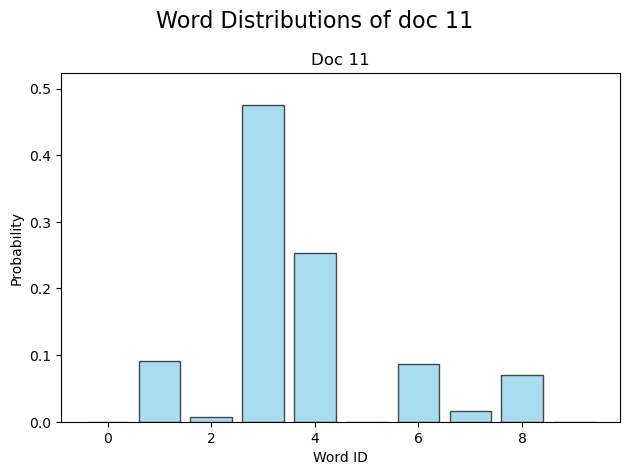

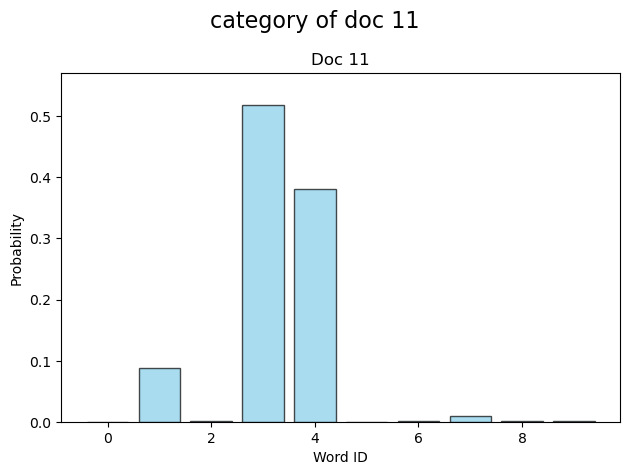

Doc 12 beta: [1.1754944e-38 7.3449440e-02 8.8764969e-03 5.0911182e-01 5.9282100e-01
 1.1754944e-38 2.7185476e-01 3.1168026e-01 9.9999988e-01 1.0000000e+00]
Doc 12 weights: [1.1754944e-38 7.3449440e-02 8.2245236e-03 4.6753064e-01 2.6724097e-01
 2.1576717e-39 4.9900141e-02 4.1657396e-02 9.1996863e-02 1.0966882e-08]


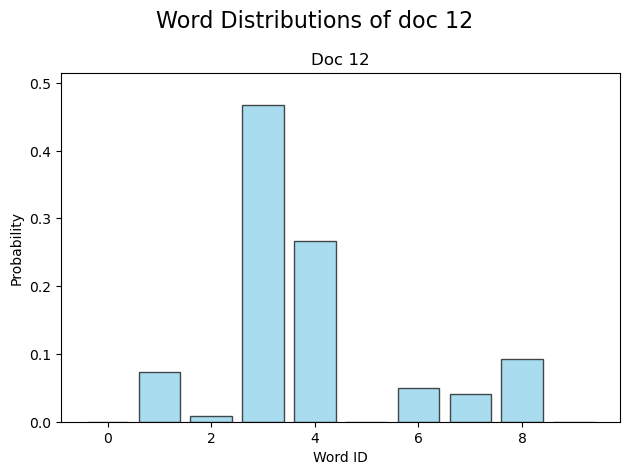

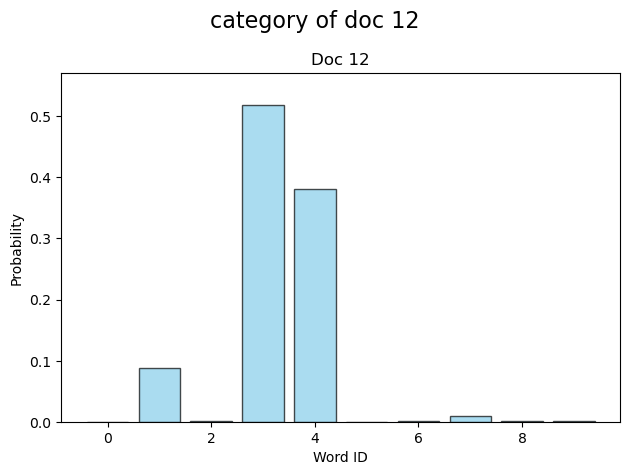

Doc 13 beta: [1.1754944e-38 6.0204763e-02 1.1763600e-02 5.2246797e-01 6.4883637e-01
 1.1754944e-38 4.3677157e-01 3.7762117e-01 8.4906226e-01 1.0000000e+00]
Doc 13 weights: [1.1754944e-38 6.0204763e-02 1.1055375e-02 4.8523685e-01 2.8776091e-01
 1.8307404e-39 6.8023741e-02 3.3124324e-02 4.6353769e-02 8.2403058e-03]


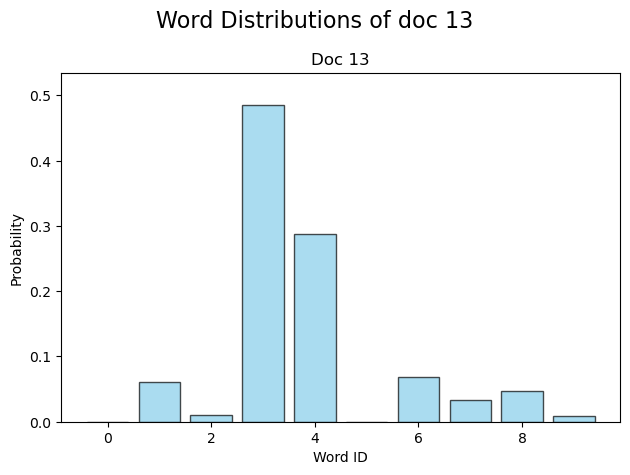

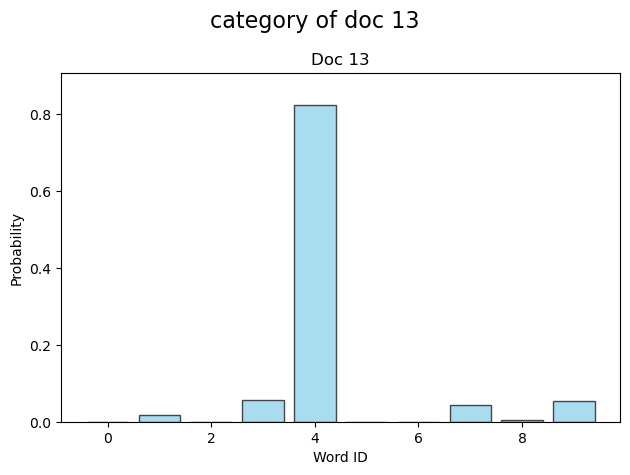

Doc 14 beta: [1.1754944e-38 3.7420150e-02 2.7659157e-02 5.2625805e-01 5.2087760e-01
 1.1754944e-38 6.2198460e-01 3.4138477e-01 9.9999988e-01 1.0000000e+00]
Doc 14 weights: [1.1754944e-38 3.7420150e-02 2.6624147e-02 4.9255422e-01 2.3095790e-01
 2.4972624e-39 1.3213664e-01 2.7415568e-02 5.2891370e-02 6.3051435e-09]


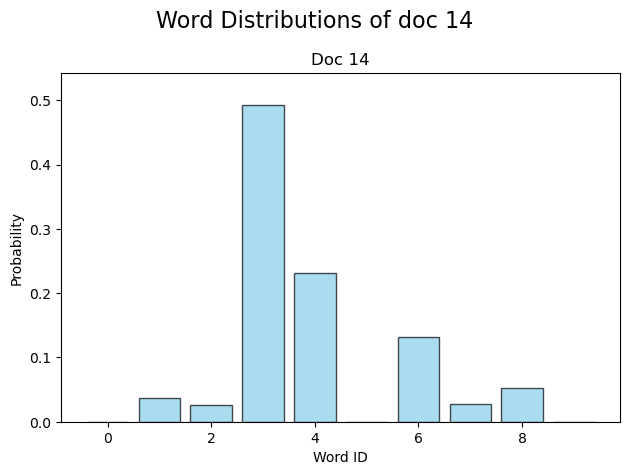

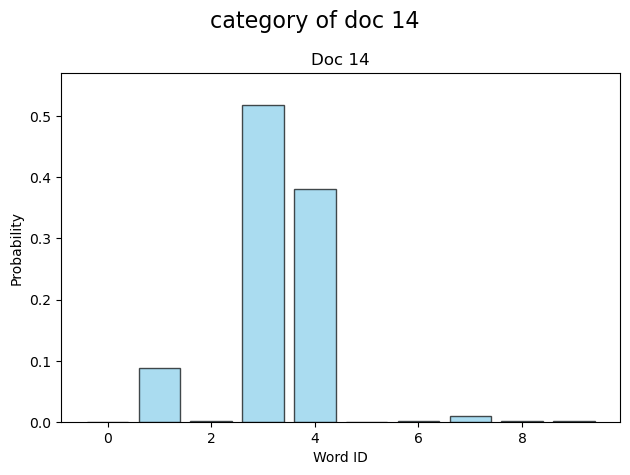

Doc 15 beta: [1.1754944e-38 8.6544536e-02 2.6504328e-02 5.0883061e-01 7.5321448e-01
 1.1754944e-38 3.4803274e-01 3.9657244e-01 9.9999988e-01 1.0000000e+00]
Doc 15 weights: [1.1754944e-38 8.6544536e-02 2.4210524e-02 4.5247507e-01 3.2898143e-01
 1.2670471e-39 3.7513923e-02 2.7868958e-02 4.2405605e-02 5.0551425e-09]


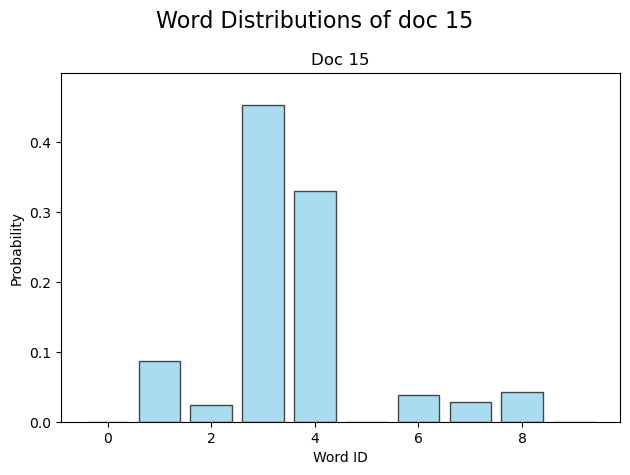

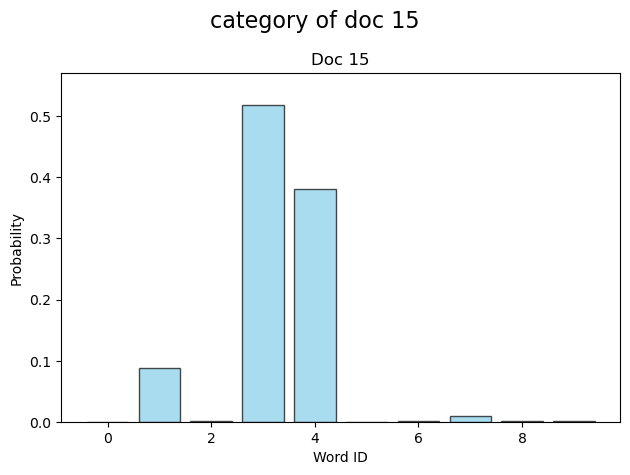

Doc 16 beta: [1.1754944e-38 9.4203316e-02 1.5637102e-02 5.1759934e-01 6.5299839e-01
 1.1754944e-38 3.7848899e-01 1.6632123e-01 9.9999988e-01 1.0000000e+00]
Doc 16 weights: [1.1754944e-38 9.4203316e-02 1.4164035e-02 4.6150848e-01 2.8087041e-01
 1.7544705e-39 5.6490913e-02 1.5428434e-02 7.7334426e-02 9.2189829e-09]


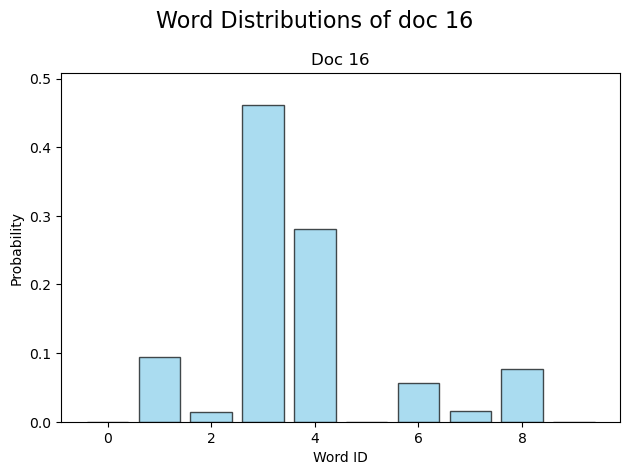

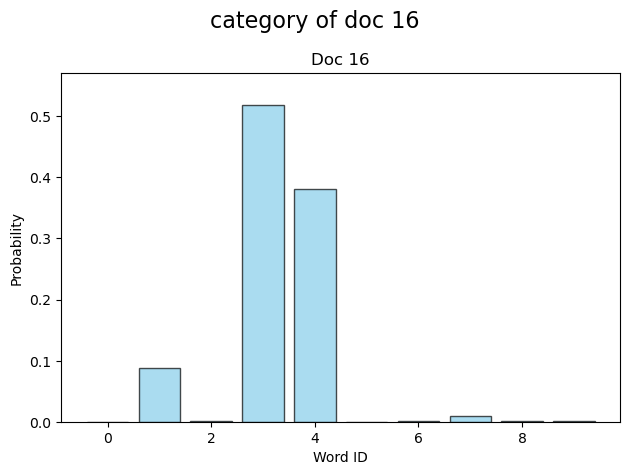

Doc 17 beta: [1.1754944e-38 3.8811773e-02 1.2554235e-02 4.8123351e-01 6.3762891e-01
 1.1754944e-38 3.2362562e-01 4.9029744e-01 7.5184333e-01 1.0000000e+00]
Doc 17 weights: [1.1754944e-38 3.8811773e-02 1.2066983e-02 4.5674893e-01 3.1395084e-01
 2.0973346e-39 5.7741769e-02 5.9168961e-02 4.6246462e-02 1.5264307e-02]


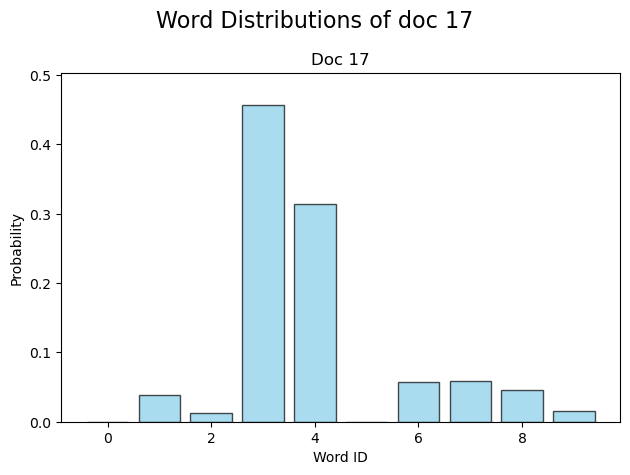

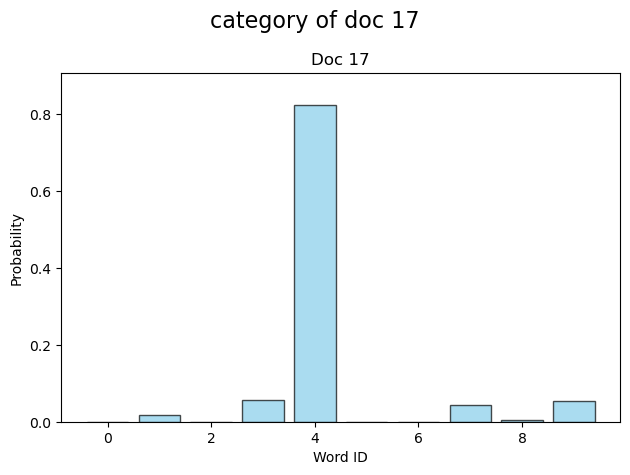

Doc 18 beta: [1.1754944e-38 1.0451210e-01 8.9479964e-03 5.4722416e-01 7.4458891e-01
 1.1754944e-38 5.4210019e-01 3.0576137e-01 9.9999988e-01 1.0000000e+00]
Doc 18 weights: [1.1754944e-38 1.0451210e-01 8.0128228e-03 4.8564783e-01 2.9919615e-01
 1.2064227e-39 5.5636369e-02 1.4369189e-02 3.2625593e-02 3.8892742e-09]


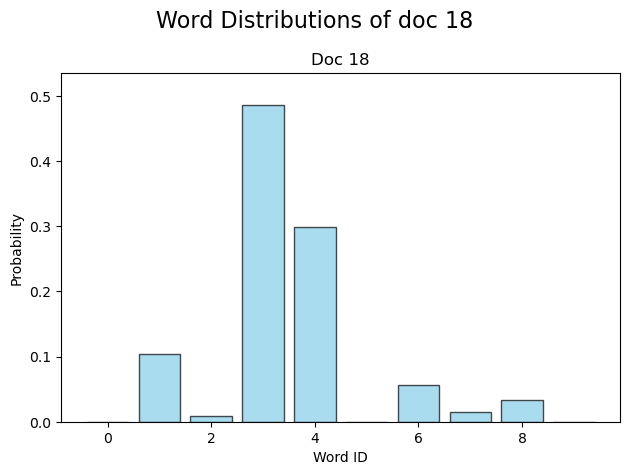

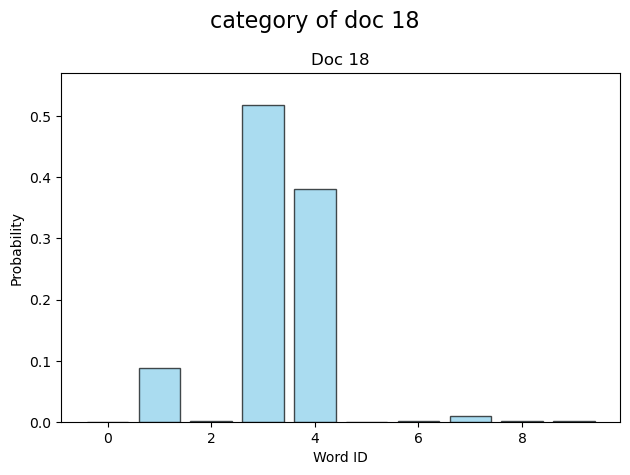

Doc 19 beta: [1.1754944e-38 9.7523540e-02 7.9127029e-03 4.8918930e-01 6.6298056e-01
 1.1754944e-38 4.0086192e-01 3.6279580e-01 9.9999988e-01 1.0000000e+00]
Doc 19 weights: [1.1754944e-38 9.7523540e-02 7.1410276e-03 4.3798852e-01 3.0321214e-01
 1.8118453e-39 6.1786775e-02 3.3503477e-02 5.8844544e-02 7.0148172e-09]


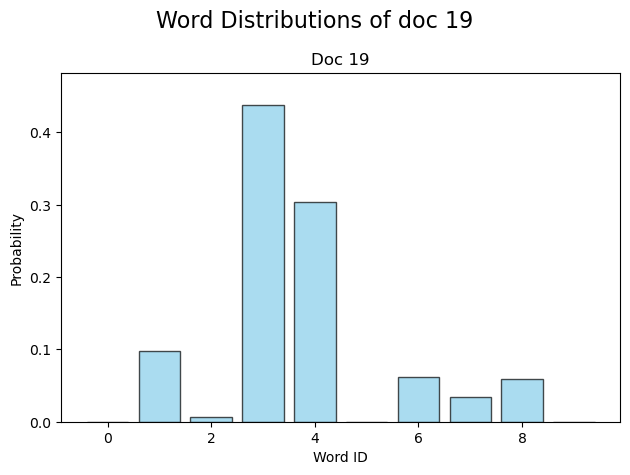

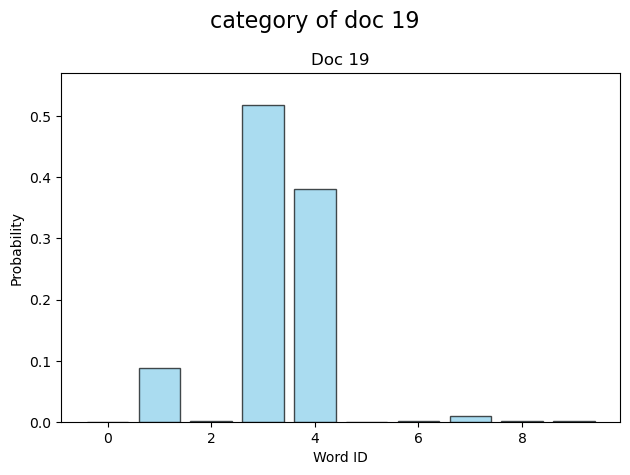

Doc 20 beta: [1.1754944e-38 2.6784204e-02 6.1469276e-02 5.1866546e-02 7.6436198e-01
 1.1754944e-38 6.9543517e-01 9.9999988e-01 1.1754944e-38 1.0000000e+00]
Doc 20 weights: [1.1754944e-38 2.6784204e-02 5.9822872e-02 4.7374539e-02 6.6195154e-01
 2.3987946e-39 1.4191528e-01 6.2151585e-02 0.0000000e+00 7.4090472e-09]


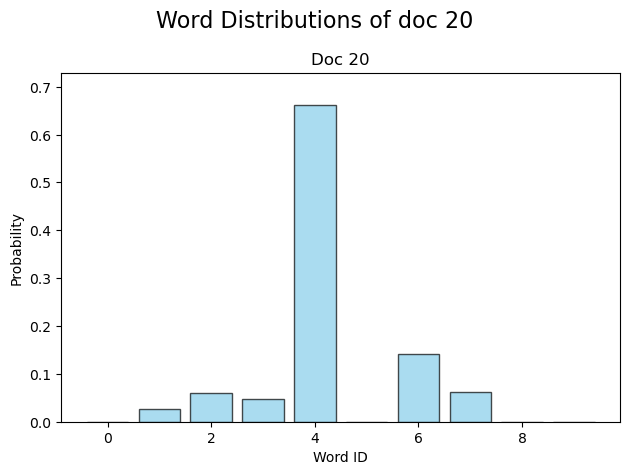

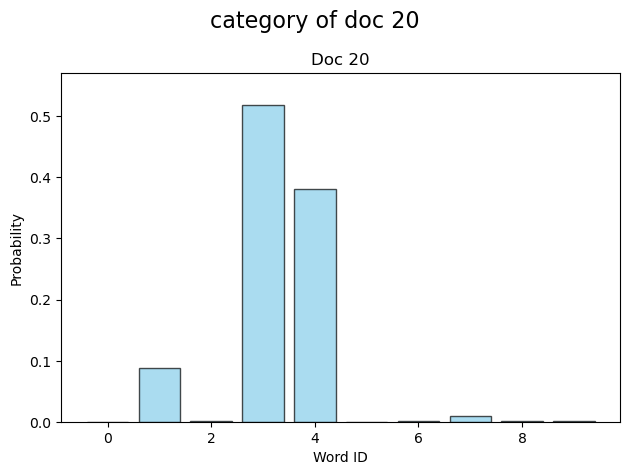

Doc 21 beta: [1.1754944e-38 5.3138281e-03 9.2730135e-02 1.0148459e-01 7.2699457e-01
 1.1754944e-38 6.7077285e-01 7.8881329e-01 9.9999988e-01 1.0000000e+00]
Doc 21 weights: [1.1754944e-38 5.3138281e-03 9.2237383e-02 9.1584645e-02 5.8949381e-01
 2.6021958e-39 1.4848919e-01 5.7489593e-02 1.5391521e-02 1.8348125e-09]


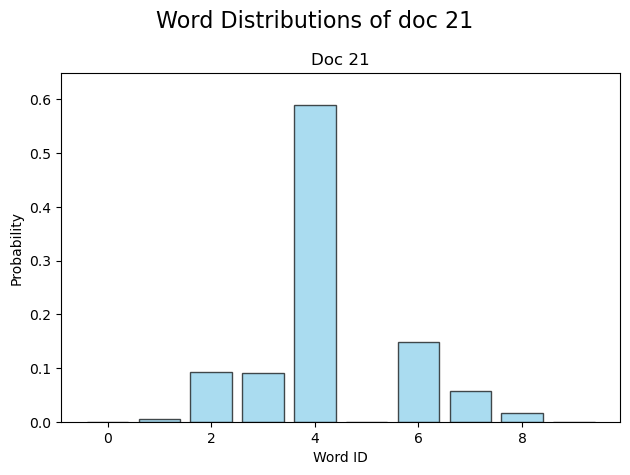

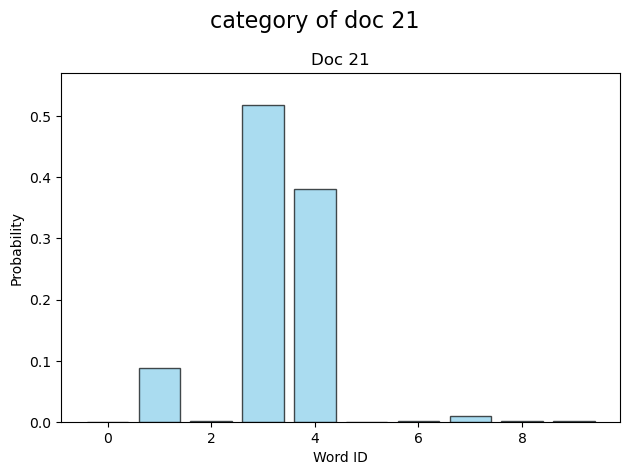

Doc 22 beta: [1.1754944e-38 2.5230788e-02 6.4070240e-02 6.3531958e-02 8.0230397e-01
 1.1754944e-38 4.0261692e-01 9.6281517e-01 9.9999988e-01 1.0000000e+00]
Doc 22 weights: [1.1754944e-38 2.5230788e-02 6.2453698e-02 5.7961192e-02 6.8545192e-01
 1.9854395e-39 6.8002991e-02 9.7147547e-02 3.7519301e-03 4.4726498e-10]


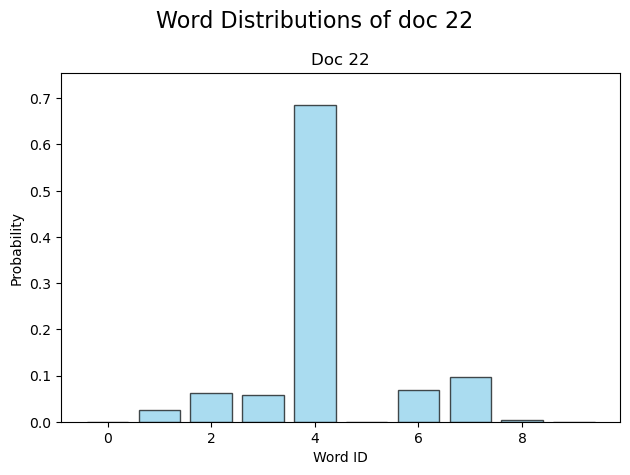

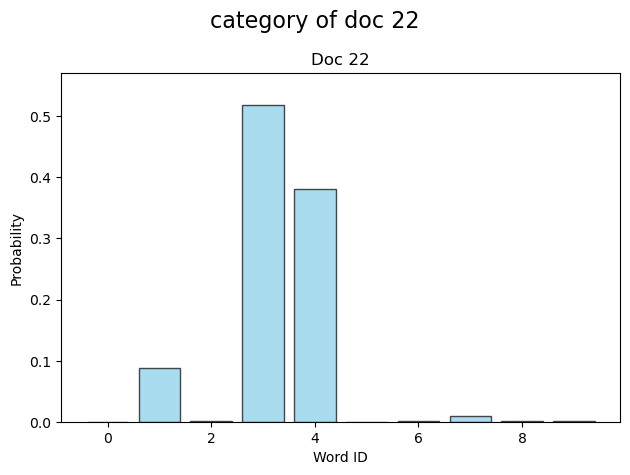

Doc 23 beta: [1.1754944e-38 1.2587409e-02 4.8970368e-02 1.5069550e-01 7.9474694e-01
 1.1754944e-38 8.8297844e-01 9.9999988e-01 1.1754944e-38 1.0000000e+00]
Doc 23 weights: [1.1754944e-38 1.2587409e-02 4.8353955e-02 1.4151192e-01 6.3384783e-01
 1.9242715e-39 1.4454260e-01 1.9156300e-02 0.0000000e+00 2.2836091e-09]


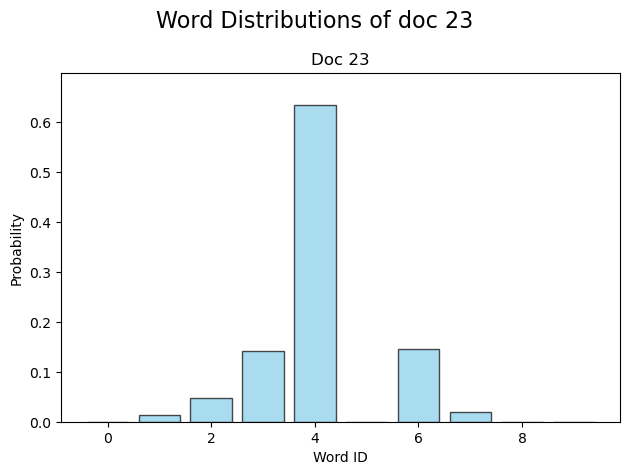

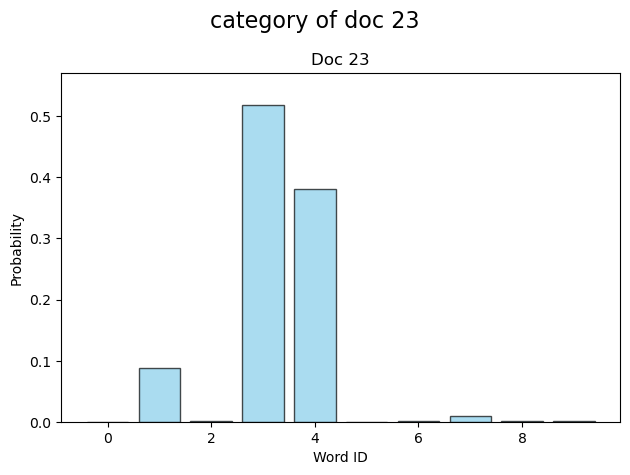

Doc 24 beta: [1.1754944e-38 1.1754944e-38 3.8560808e-02 8.4309012e-02 7.3565233e-01
 1.1754944e-38 5.2996838e-01 9.7722840e-01 9.9999988e-01 1.0000000e+00]
Doc 24 weights: [1.17549435e-38 1.17549435e-38 3.85608077e-02 8.10579881e-02
 6.47654474e-01 2.73568913e-39 1.23337805e-01 1.06897958e-01
 2.49096006e-03 2.96945607e-10]


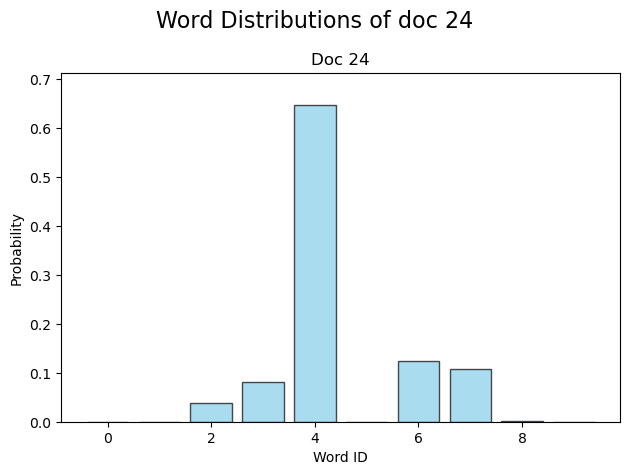

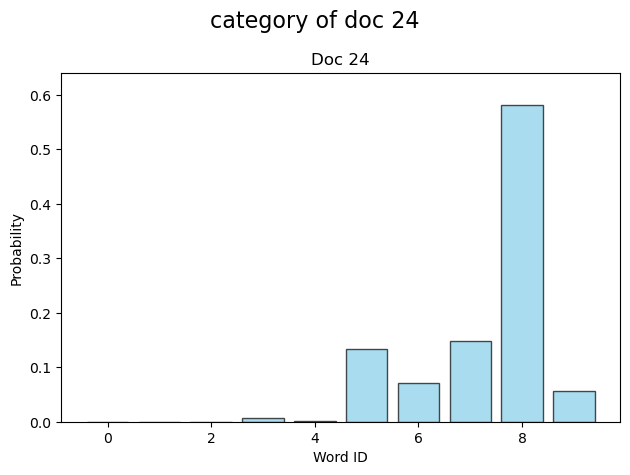

Doc 25 beta: [1.1754944e-38 5.4744817e-04 6.9012292e-02 8.8976726e-02 8.0198312e-01
 1.1754944e-38 3.6622083e-01 9.1252476e-01 9.9999988e-01 1.0000000e+00]
Doc 25 weights: [1.1754944e-38 5.4744817e-04 6.8974510e-02 8.2790889e-02 6.7983079e-01
 1.9731417e-39 6.1472498e-02 9.7077914e-02 9.3059530e-03 1.1093562e-09]


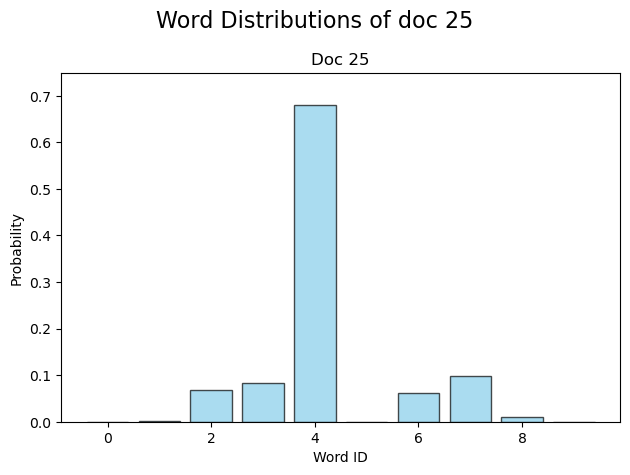

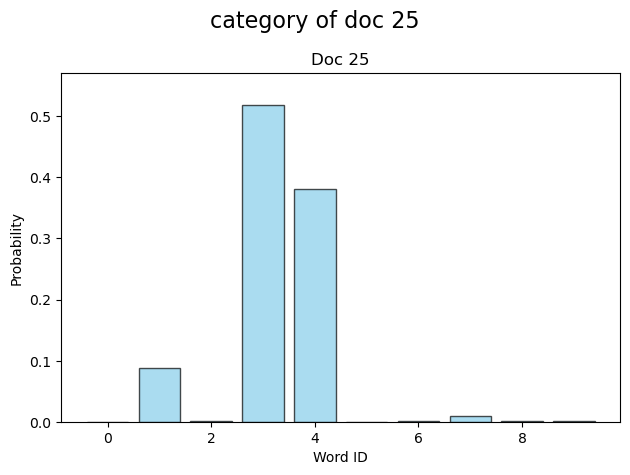

Doc 26 beta: [1.1754944e-38 1.1754944e-38 9.1785103e-02 7.3964410e-02 7.9482436e-01
 1.1754944e-38 3.4302986e-01 8.6473227e-01 9.9999988e-01 1.0000000e+00]
Doc 26 weights: [1.1754944e-38 1.1754944e-38 9.1785103e-02 6.7175582e-02 6.6847855e-01
 2.0284426e-39 5.9193499e-02 9.8032348e-02 1.5334933e-02 1.8280667e-09]


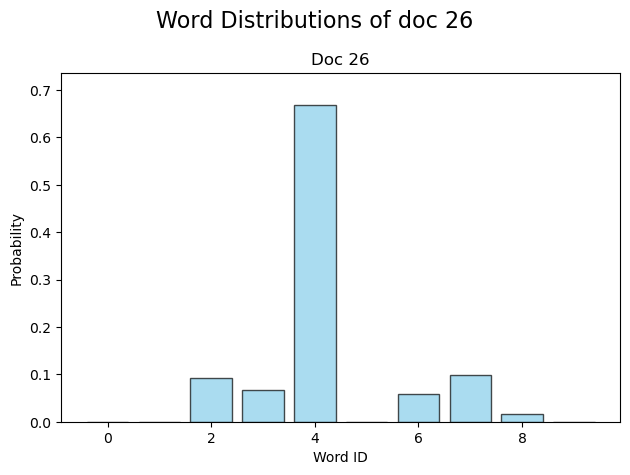

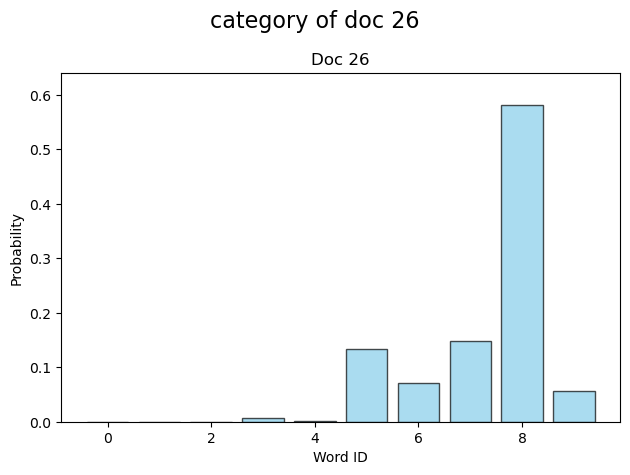

Doc 27 beta: [1.1754944e-38 1.0184876e-02 8.1624456e-02 3.9219879e-02 7.6188463e-01
 1.1754944e-38 4.7190794e-01 9.7430474e-01 9.9999988e-01 1.0000000e+00]
Doc 27 weights: [1.17549435e-38 1.01848757e-02 8.07931200e-02 3.56517322e-02
 6.65407419e-01 2.44459180e-39 9.81393382e-02 1.07001595e-01
 2.82194465e-03 3.36402045e-10]


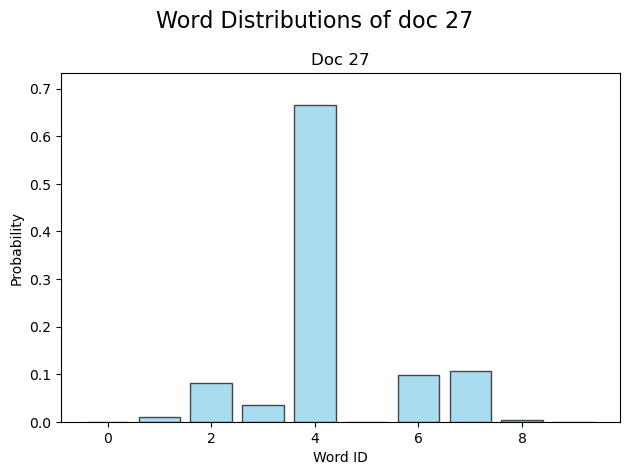

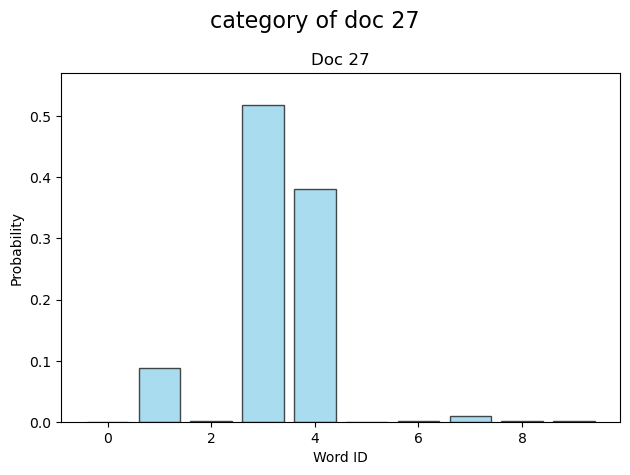

Doc 28 beta: [1.1754944e-38 7.3435917e-03 1.0201301e-01 5.2186467e-02 7.8263146e-01
 1.1754944e-38 4.3864688e-01 9.7075695e-01 9.9999988e-01 1.0000000e+00]
Doc 28 weights: [1.17549435e-38 7.34359166e-03 1.01263866e-01 4.65186313e-02
 6.61224961e-01 2.15878436e-39 8.05570707e-02 1.00077219e-01
 3.01472261e-03 3.59382996e-10]


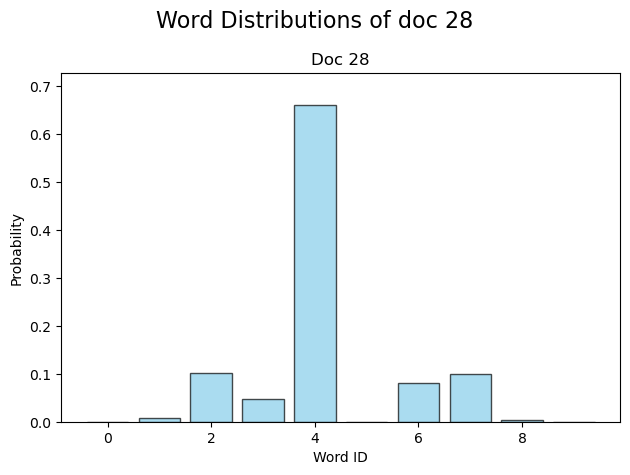

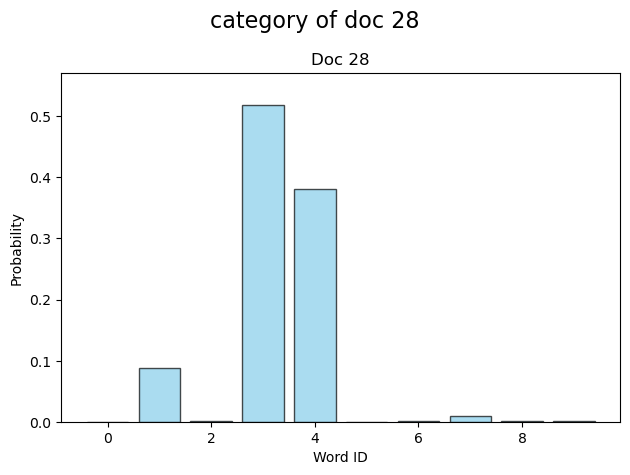

Doc 29 beta: [1.1754944e-38 7.6800711e-03 3.9687652e-02 7.3122762e-02 8.3090240e-01
 1.1754944e-38 5.4942691e-01 7.0510823e-01 9.9999988e-01 1.0000000e+00]
Doc 29 weights: [1.1754944e-38 7.6800711e-03 3.9382849e-02 6.9681391e-02 7.3389935e-01
 1.7556770e-39 8.2060449e-02 4.7450956e-02 1.9845033e-02 2.3657125e-09]


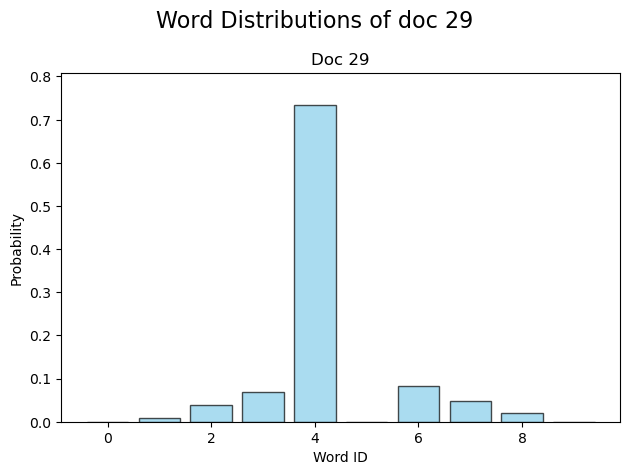

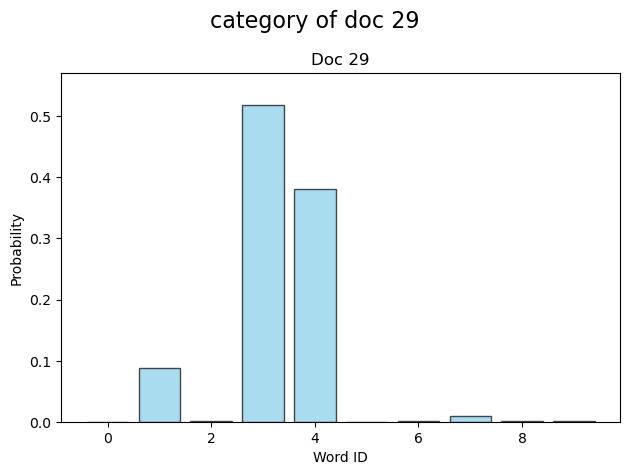

Doc 30 beta: [1.1754944e-38 2.2547506e-02 6.6025659e-02 9.0043850e-02 7.8488034e-01
 1.1754944e-38 4.6563351e-01 9.1504830e-01 9.9999988e-01 1.0000000e+00]
Doc 30 weights: [1.1754944e-38 2.2547506e-02 6.4536944e-02 8.2202427e-02 6.5201038e-01
 2.1006403e-39 8.3209969e-02 8.7380469e-02 8.1122695e-03 9.6705799e-10]


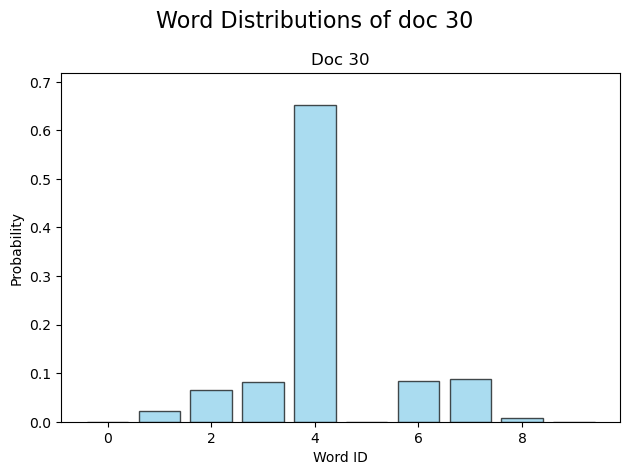

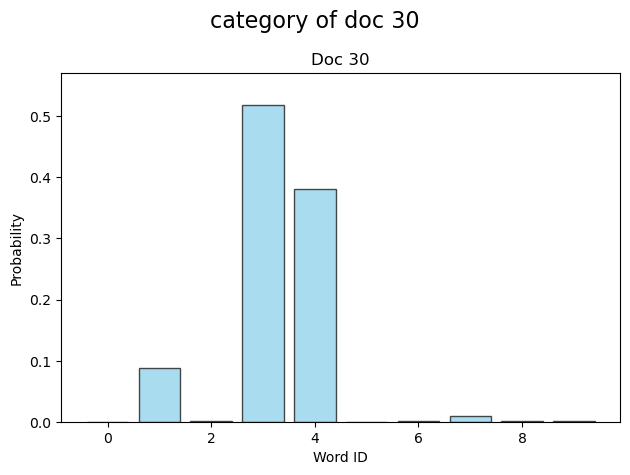

Doc 31 beta: [1.1754944e-38 3.6615892e-03 1.8719289e-02 8.5522354e-02 8.2487965e-01
 1.1754944e-38 7.8706586e-01 8.2913178e-01 9.9999988e-01 1.0000000e+00]
Doc 31 weights: [1.1754944e-38 3.6615892e-03 1.8650748e-02 8.3614148e-02 7.3750299e-01
 1.8404766e-39 1.2323127e-01 2.7642585e-02 5.6966082e-03 6.7908867e-10]


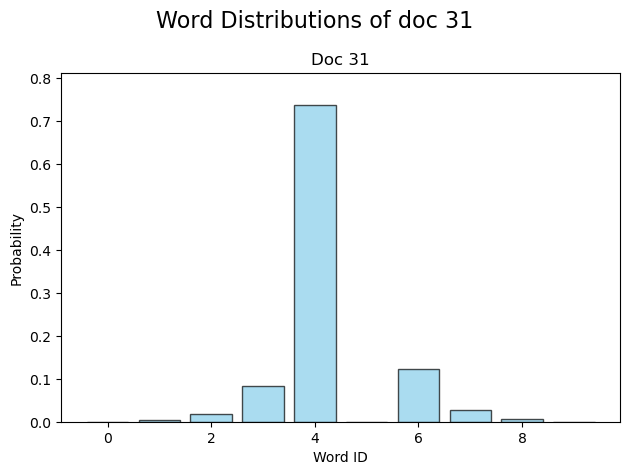

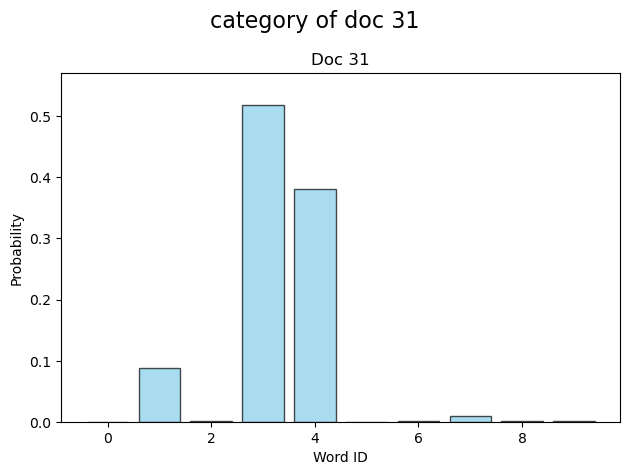

Doc 32 beta: [1.1754944e-38 1.0411060e-02 4.2846538e-02 3.5735063e-02 8.4824401e-01
 1.1754944e-38 5.6867272e-01 9.7305036e-01 9.9999988e-01 1.0000000e+00]
Doc 32 weights: [1.1754944e-38 1.0411060e-02 4.2400461e-02 3.3847839e-02 7.7473569e-01
 1.6292925e-39 7.8820825e-02 5.8172915e-02 1.6111593e-03 1.9206518e-10]


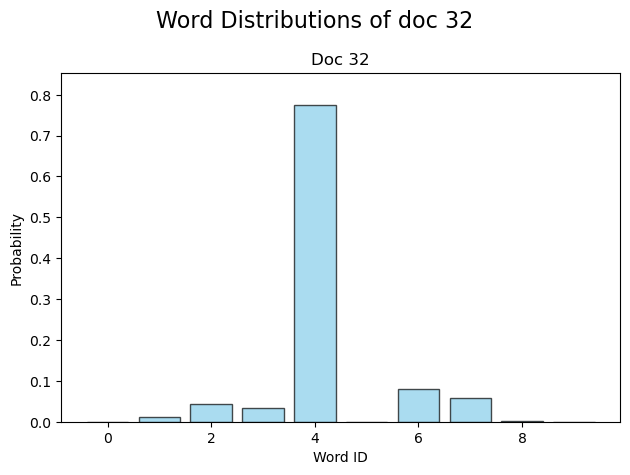

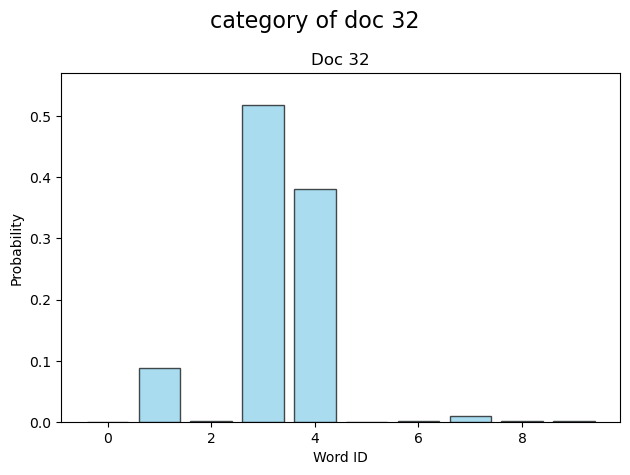

Doc 33 beta: [1.1754944e-38 1.0391933e-02 5.8967240e-02 7.4223615e-02 8.2186860e-01
 1.1754944e-38 4.4855431e-01 8.8645887e-01 9.9999988e-01 1.0000000e+00]
Doc 33 weights: [1.1754944e-38 1.0391933e-02 5.8354456e-02 6.9121011e-02 7.0855969e-01
 1.8052410e-39 6.8885781e-02 7.5071640e-02 9.6154697e-03 1.1462534e-09]


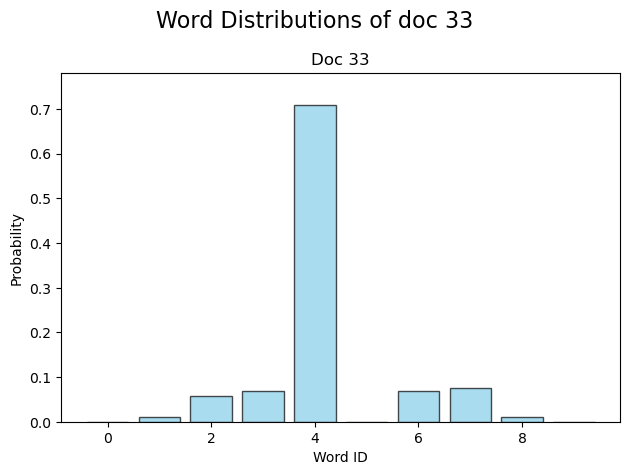

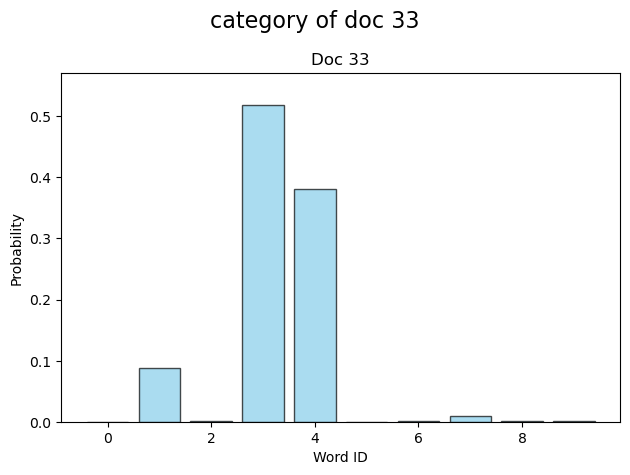

Doc 34 beta: [1.1754944e-38 9.8511130e-03 4.8202597e-02 8.6698025e-02 8.1884682e-01
 1.1754944e-38 6.3245326e-01 9.2121494e-01 9.9999988e-01 1.0000000e+00]
Doc 34 weights: [1.1754944e-38 9.8511130e-03 4.7727749e-02 8.1706055e-02 7.0479381e-01
 1.8328451e-39 9.8612919e-02 5.2793317e-02 4.5150421e-03 5.3823501e-10]


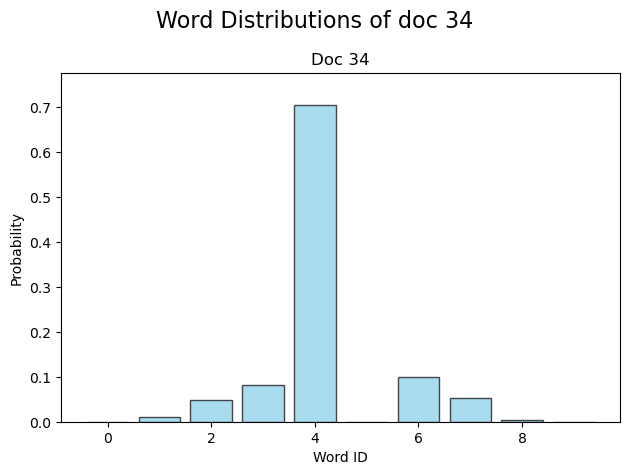

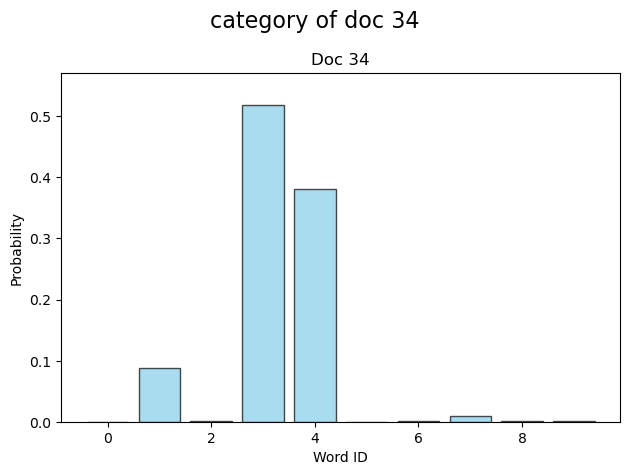

Doc 35 beta: [1.1754944e-38 2.6684836e-02 8.7094329e-02 7.2756380e-02 7.7761698e-01
 1.1754944e-38 5.6285560e-01 8.4870070e-01 9.9999988e-01 1.0000000e+00]
Doc 35 weights: [1.1754944e-38 2.6684836e-02 8.4770232e-02 6.4647317e-02 6.4067680e-01
 2.1537509e-39 1.0312688e-01 6.7975804e-02 1.2118159e-02 1.4445973e-09]


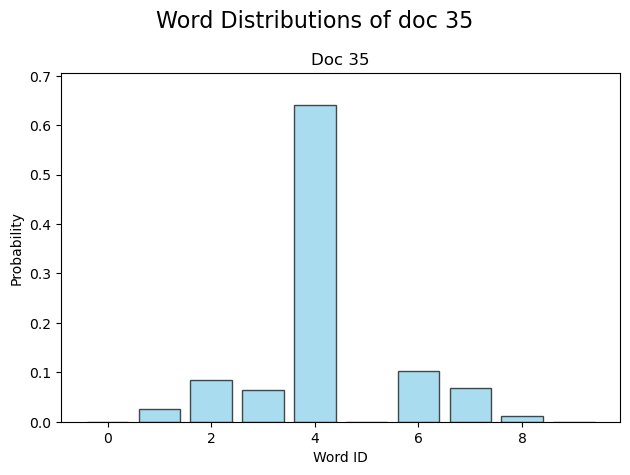

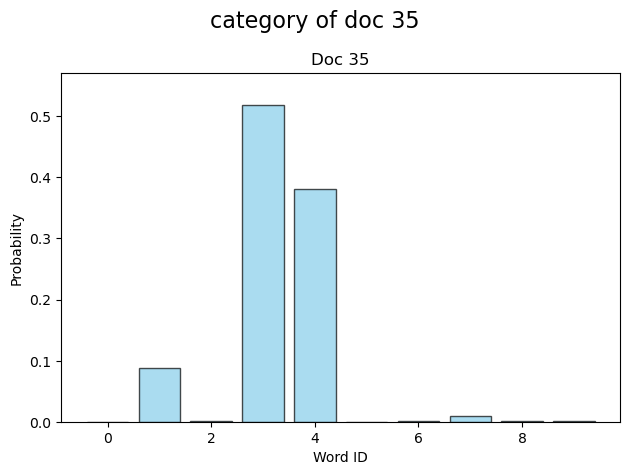

Doc 36 beta: [1.1754944e-38 5.5828202e-03 2.6572416e-02 6.9420114e-02 8.3832335e-01
 1.1754944e-38 7.6018333e-01 9.9999988e-01 1.1754944e-38 1.0000000e+00]
Doc 36 weights: [1.1754944e-38 5.5828202e-03 2.6424067e-02 6.7198195e-02 7.5515747e-01
 1.7119607e-39 1.1071121e-01 3.4926299e-02 0.0000000e+00 4.1635397e-09]


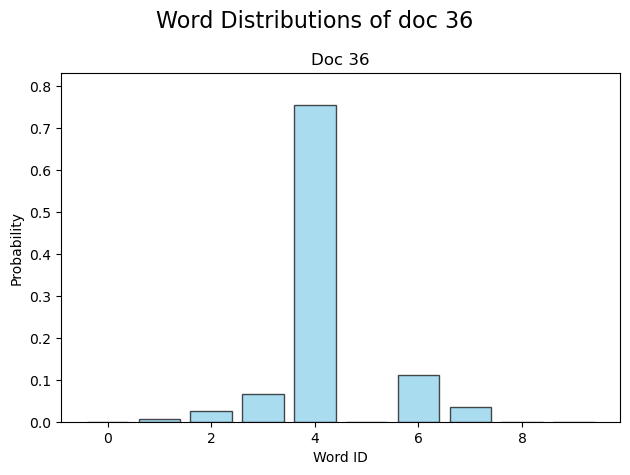

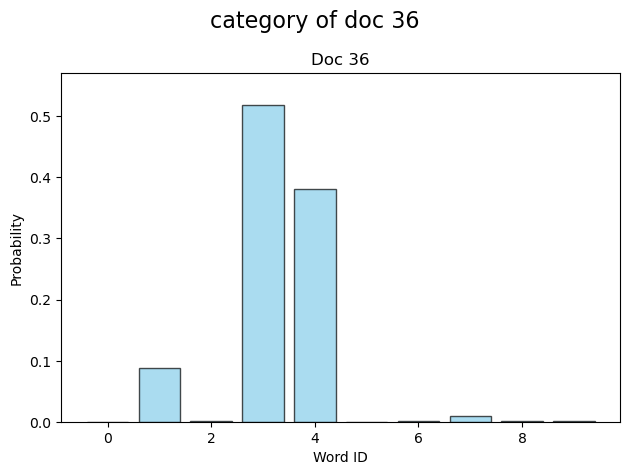

Doc 37 beta: [1.1754944e-38 1.1754944e-38 6.2845968e-02 2.9934110e-02 7.7866054e-01
 1.1754944e-38 5.6228018e-01 9.2478633e-01 9.9999988e-01 1.0000000e+00]
Doc 37 weights: [1.17549435e-38 1.17549435e-38 6.28459677e-02 2.80528720e-02
 7.07881212e-01 2.36533015e-39 1.13142006e-01 8.14533010e-02
 6.62466651e-03 7.89721899e-10]


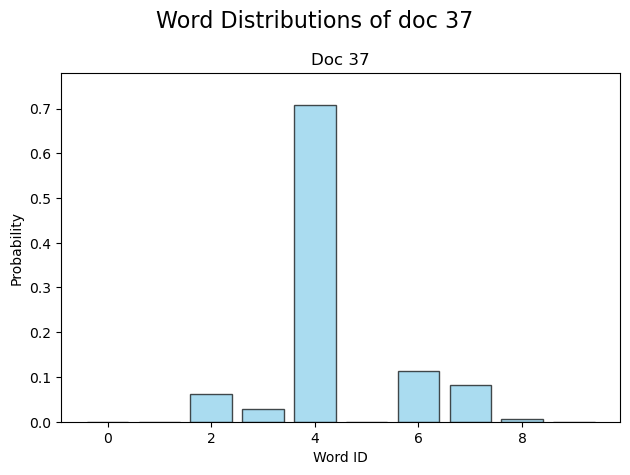

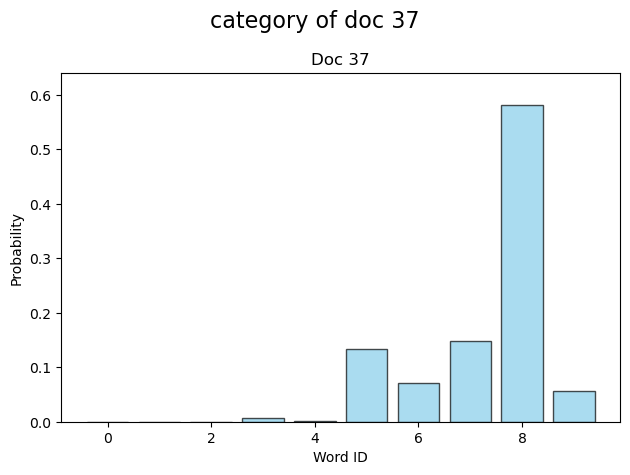

Doc 38 beta: [1.1754944e-38 8.5384035e-03 5.7340659e-02 4.4616140e-02 8.1744951e-01
 1.1754944e-38 6.0651094e-01 9.7817135e-01 9.9999988e-01 1.0000000e+00]
Doc 38 weights: [1.1754944e-38 8.5384035e-03 5.6851059e-02 4.1698713e-02 7.2991025e-01
 1.9160739e-39 9.8862179e-02 6.2739223e-02 1.4000743e-03 1.6690188e-10]


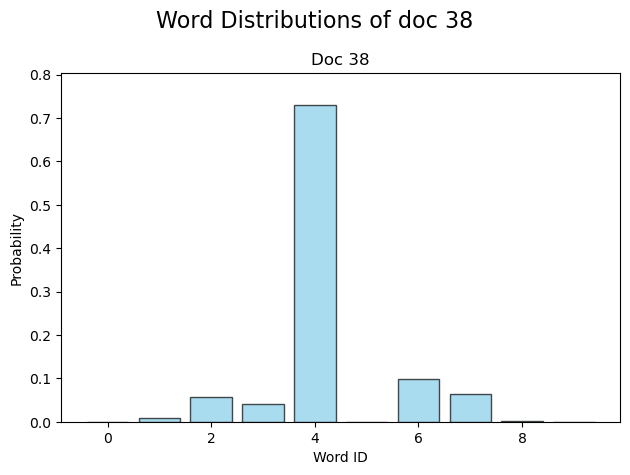

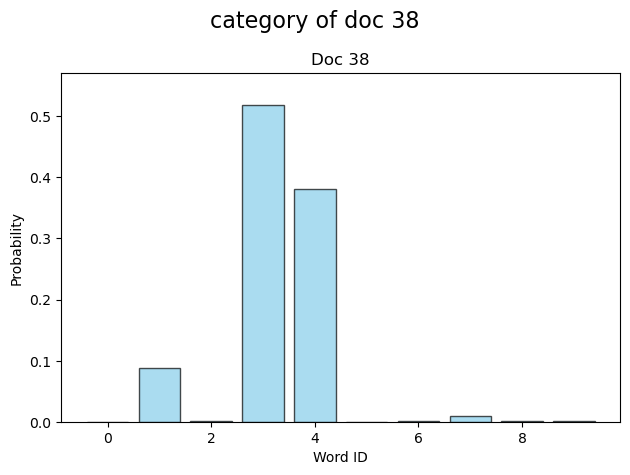

Doc 39 beta: [1.1754944e-38 2.7344437e-02 1.0566510e-01 8.1987955e-02 7.9052305e-01
 1.1754944e-38 5.2972674e-01 9.6165162e-01 9.9999988e-01 1.0000000e+00]
Doc 39 weights: [1.17549435e-38 2.73444373e-02 1.02775745e-01 7.13196620e-02
 6.31280184e-01 1.96636646e-39 8.86126533e-02 7.56505132e-02
 3.01676197e-03 3.59626107e-10]


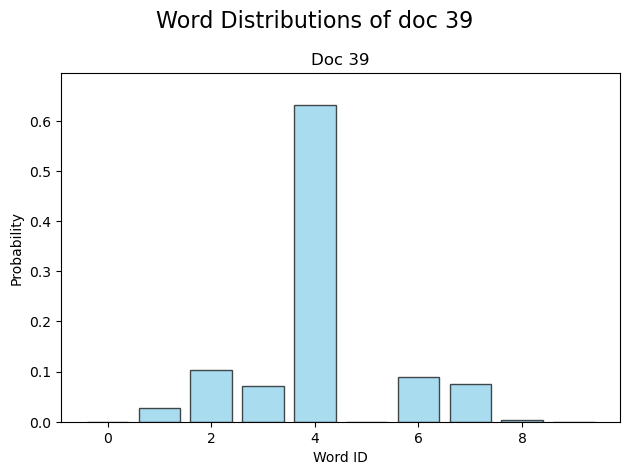

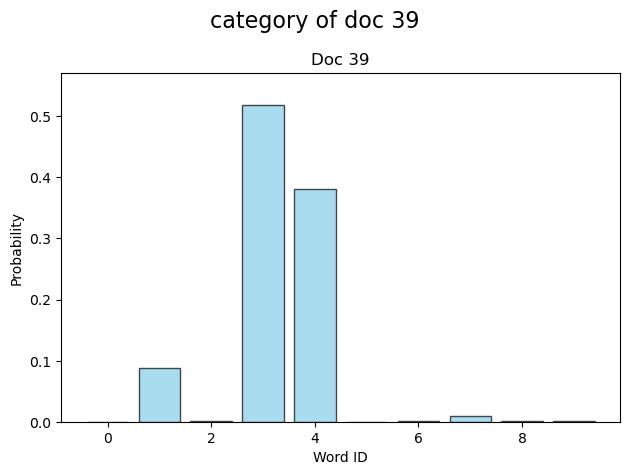

Doc 40 beta: [1.1754944e-38 4.9579495e-01 2.8486261e-01 2.5907686e-01 6.5360761e-01
 1.1754944e-38 4.8805401e-01 5.2164942e-01 4.1174176e-01 1.0000000e+00]
Doc 40 weights: [1.1754944e-38 4.9579495e-01 1.4362916e-01 9.3416862e-02 1.7461717e-01
 1.0878238e-39 4.5165420e-02 2.4713887e-02 9.3311146e-03 1.3331427e-02]


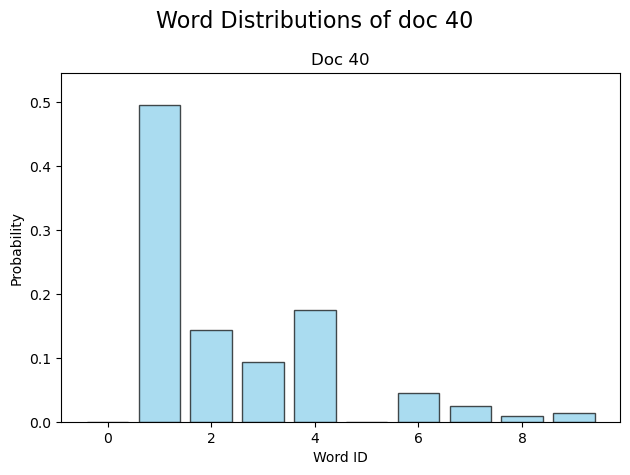

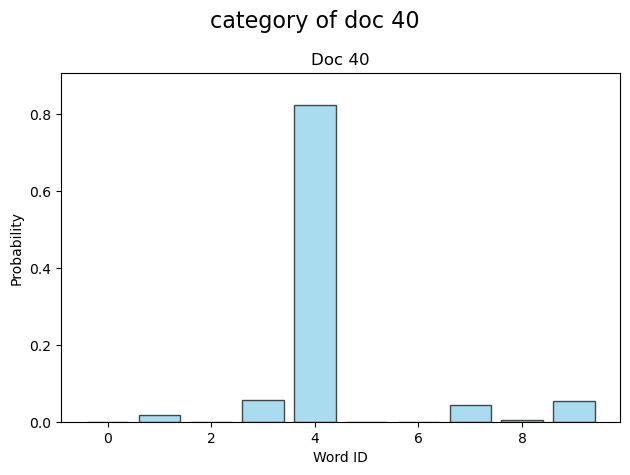

Doc 41 beta: [1.1754944e-38 5.1706487e-01 2.3690872e-01 2.2609843e-01 7.2869813e-01
 1.1754944e-38 5.9150970e-01 7.1914798e-01 3.3880329e-01 1.0000000e+00]
Doc 41 weights: [1.1754944e-38 5.1706487e-01 1.1441154e-01 8.3322600e-02 2.0782542e-01
 9.0954500e-40 4.5768395e-02 2.2730229e-02 3.0075354e-03 5.8694012e-03]


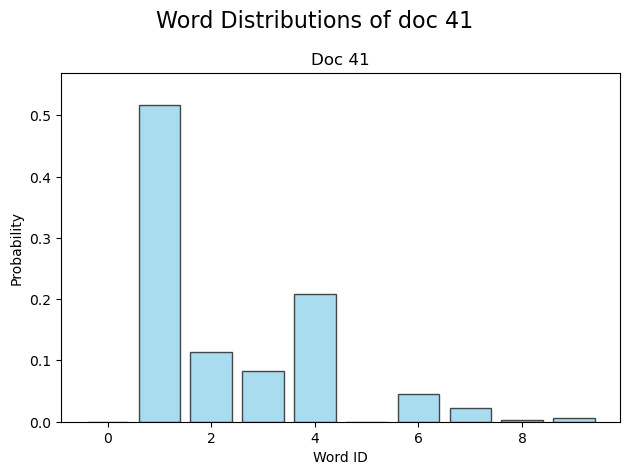

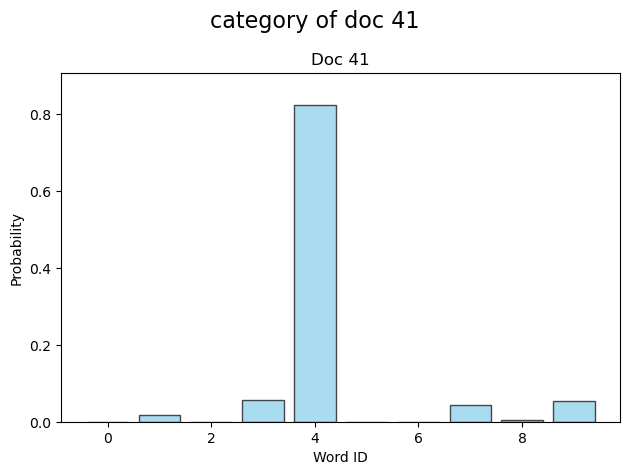

Doc 42 beta: [1.1754944e-38 4.3317667e-01 3.8749063e-01 3.2840315e-01 5.5311751e-01
 1.1754944e-38 1.9140449e-01 3.2367241e-01 6.5238845e-01 1.0000000e+00]
Doc 42 weights: [1.17549435e-38 4.33176666e-01 2.19638735e-01 1.14016525e-01
 1.28969371e-01 1.22484976e-39 1.99441072e-02 2.72709038e-02
 3.71755324e-02 1.98082048e-02]


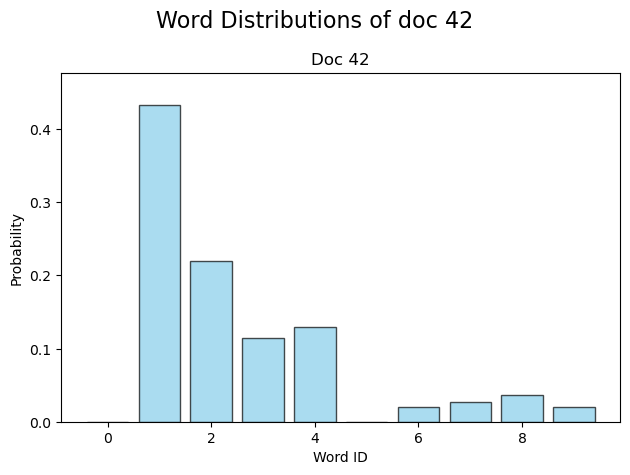

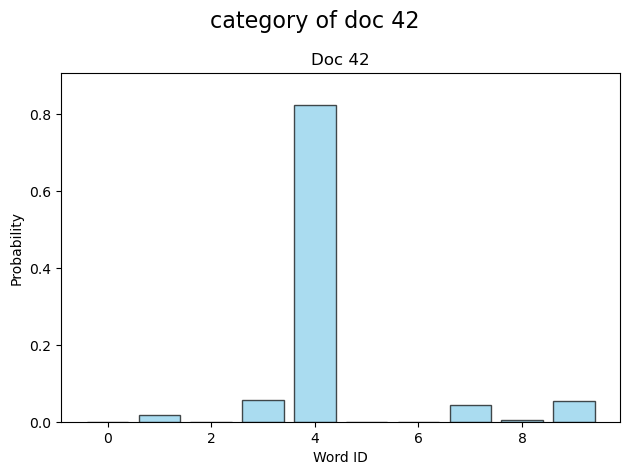

Doc 43 beta: [1.1754944e-38 5.0430775e-01 2.7772641e-01 2.2945812e-01 5.4363453e-01
 1.1754944e-38 3.5822725e-01 3.7512895e-01 5.9373790e-01 1.0000000e+00]
Doc 43 weights: [1.1754944e-38 5.0430775e-01 1.3766684e-01 8.2151845e-02 1.4997442e-01
 1.4799379e-39 4.5100518e-02 3.0309917e-02 2.9977081e-02 2.0511663e-02]


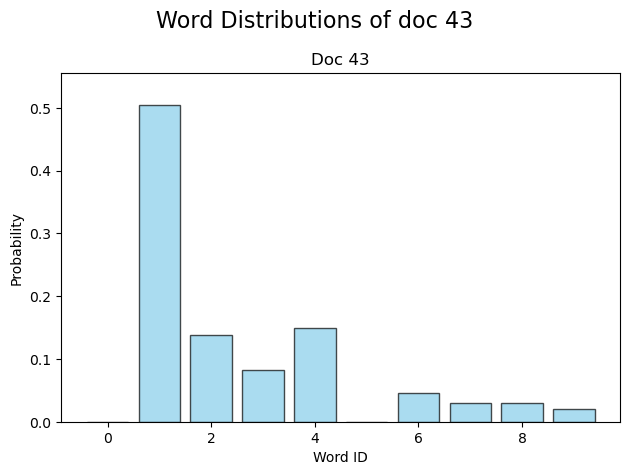

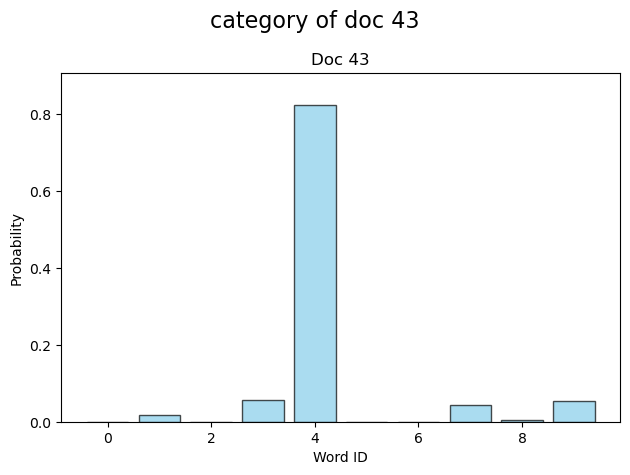

Doc 44 beta: [1.1754944e-38 4.9076840e-01 2.7501130e-01 4.3174481e-01 7.9396939e-01
 1.1754944e-38 5.9008753e-01 2.5138378e-01 3.8612208e-01 1.0000000e+00]
Doc 44 weights: [1.1754944e-38 4.9076840e-01 1.4004444e-01 1.5939462e-01 1.6656882e-01
 5.0809120e-40 2.5505751e-02 4.4539985e-03 5.1214942e-03 8.1424303e-03]


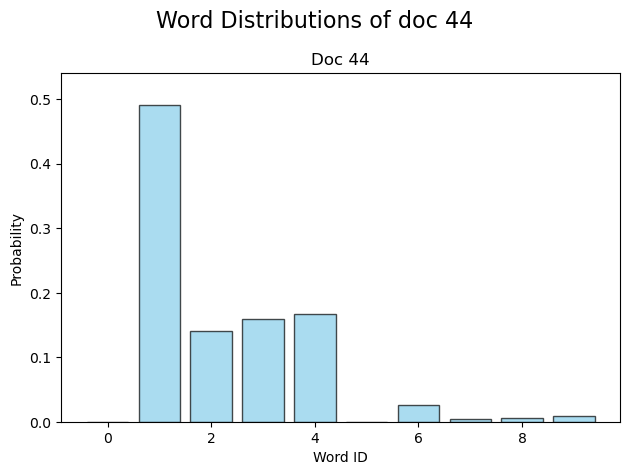

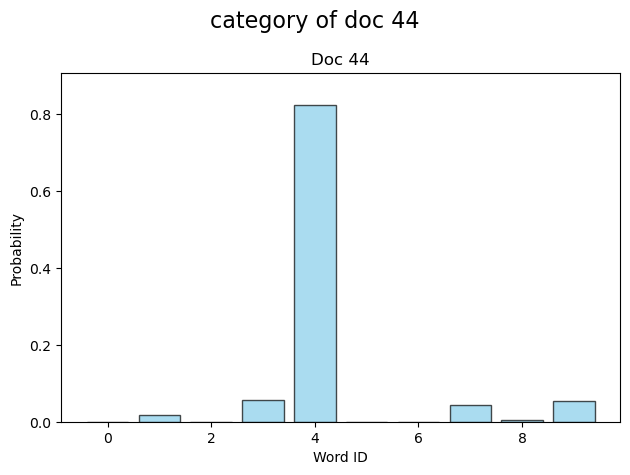

Doc 45 beta: [1.1754944e-38 5.3345823e-01 2.4069291e-01 2.3649703e-01 5.8911675e-01
 1.1754944e-38 2.2423244e-01 2.4890998e-01 2.2037470e-01 1.0000000e+00]
Doc 45 weights: [1.17549435e-38 5.33458233e-01 1.12293296e-01 8.37787092e-02
 1.59338266e-01 1.30634368e-39 2.49192845e-02 2.14590784e-02
 1.42699517e-02 5.04831783e-02]


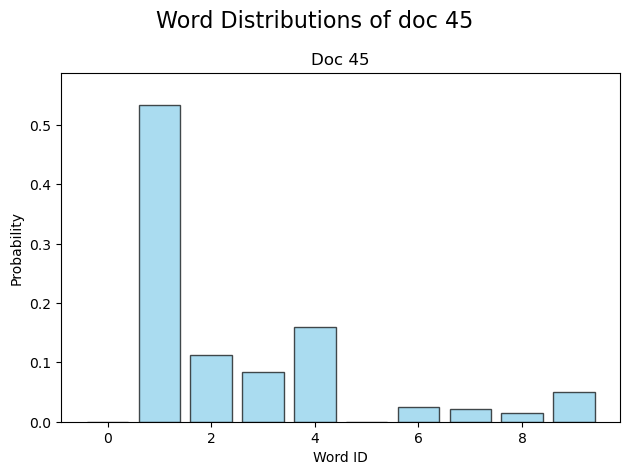

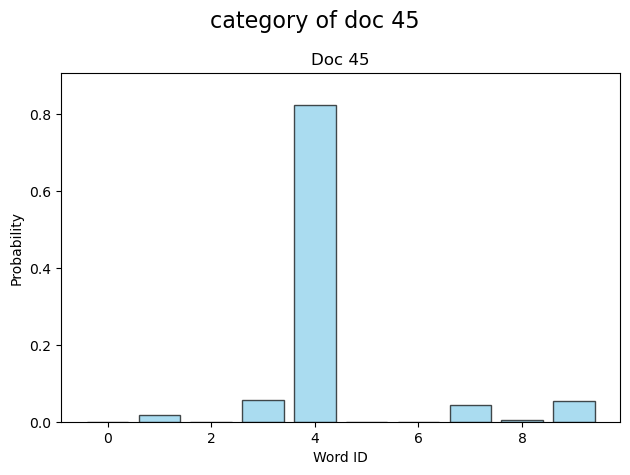

Doc 46 beta: [1.1754944e-38 5.0314254e-01 2.9756382e-01 4.1610840e-01 5.0311470e-01
 1.1754944e-38 3.2217842e-01 6.5902829e-01 6.9668317e-01 1.0000000e+00]
Doc 46 weights: [1.1754944e-38 5.0314254e-01 1.4784680e-01 1.4522627e-01 1.0252693e-01
 1.1902755e-39 3.2622974e-02 4.5232080e-02 1.6304074e-02 7.0983488e-03]


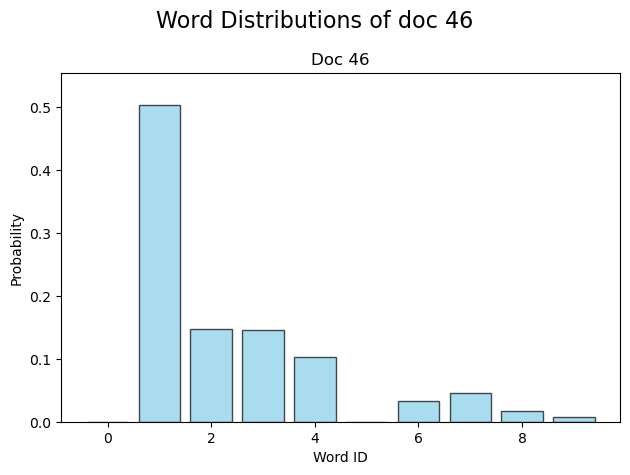

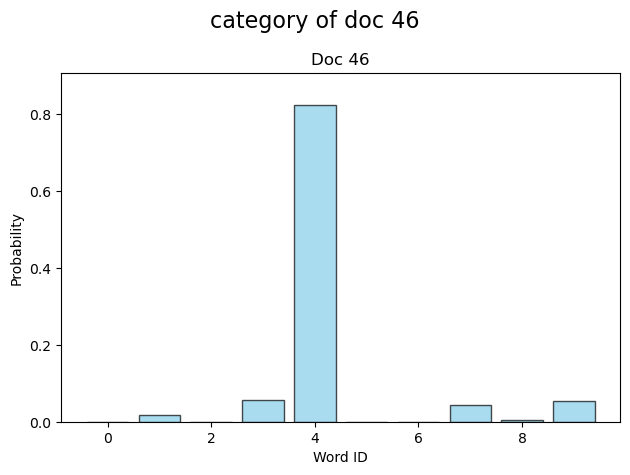

Doc 47 beta: [1.1754944e-38 4.7452629e-01 3.4516883e-01 2.1169867e-01 7.7801943e-01
 1.1754944e-38 3.4356213e-01 2.6600924e-01 6.7261279e-01 1.0000000e+00]
Doc 47 weights: [1.1754944e-38 4.7452629e-01 1.8137714e-01 7.2844788e-02 2.1103917e-01
 7.0779585e-40 2.0686779e-02 1.0514242e-02 1.9513581e-02 9.4980309e-03]


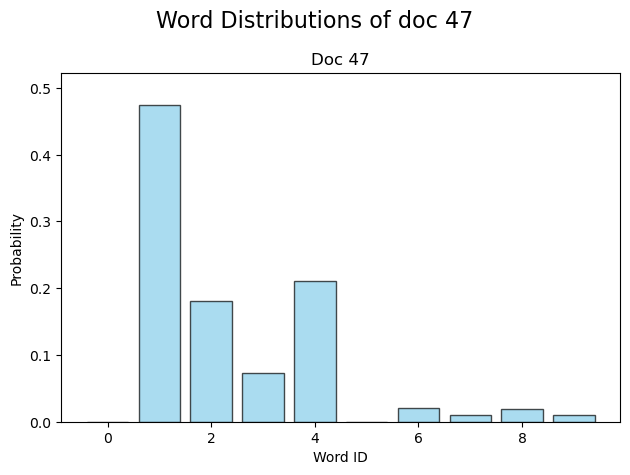

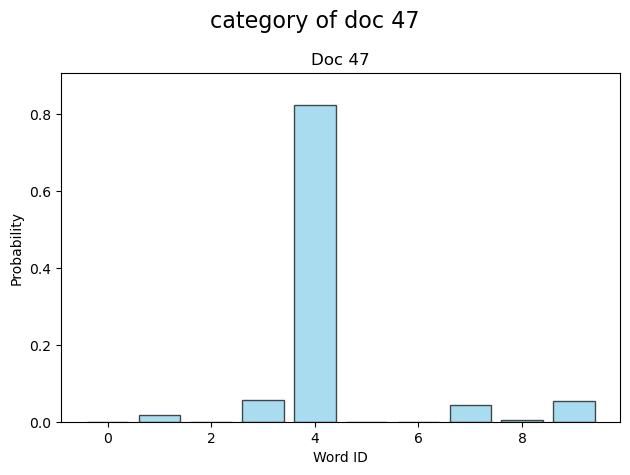

Doc 48 beta: [1.1754944e-38 4.9431637e-01 3.5712522e-01 2.8406060e-01 6.2714541e-01
 1.1754944e-38 3.0959859e-01 5.7229197e-01 8.8616902e-01 1.0000000e+00]
Doc 48 weights: [1.1754944e-38 4.9431637e-01 1.8059239e-01 9.2345618e-02 1.4596537e-01
 1.0200976e-39 2.6867053e-02 3.4287859e-02 2.2708409e-02 2.9169610e-03]


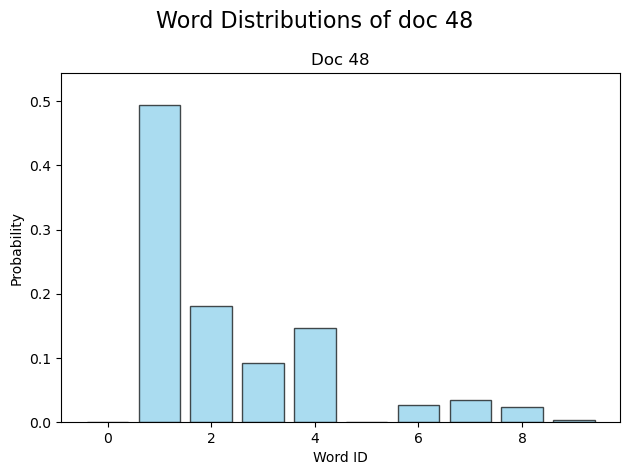

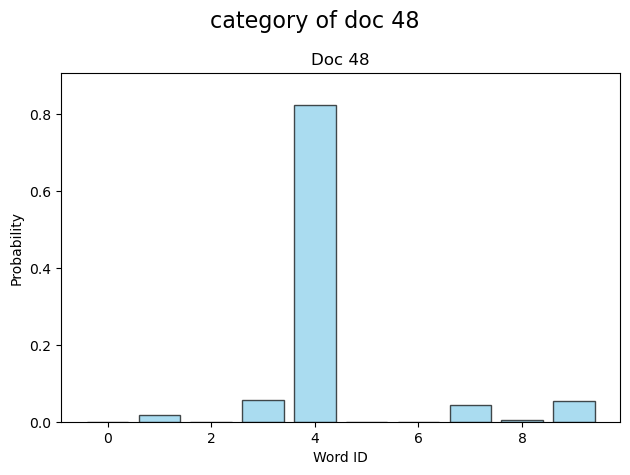

Doc 49 beta: [1.1754944e-38 3.8421223e-01 2.5120574e-01 3.4934381e-01 7.4258739e-01
 1.1754944e-38 6.1666417e-01 1.1754944e-38 5.1742280e-01 1.0000000e+00]
Doc 49 weights: [1.1754944e-38 3.8421223e-01 1.5468942e-01 1.6108184e-01 2.2278847e-01
 9.0781159e-40 4.7623761e-02 3.4799706e-40 1.5317924e-02 1.4286347e-02]


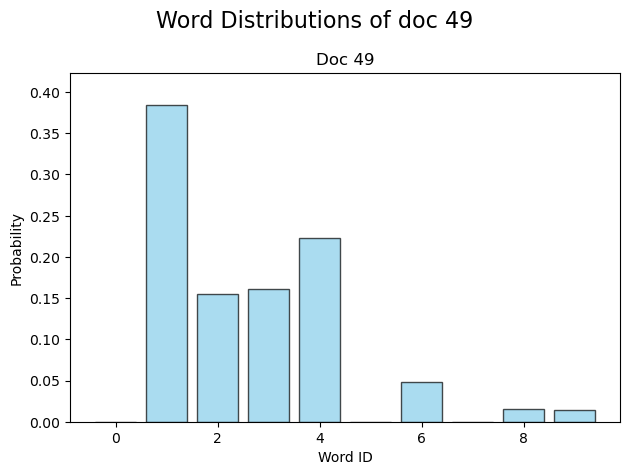

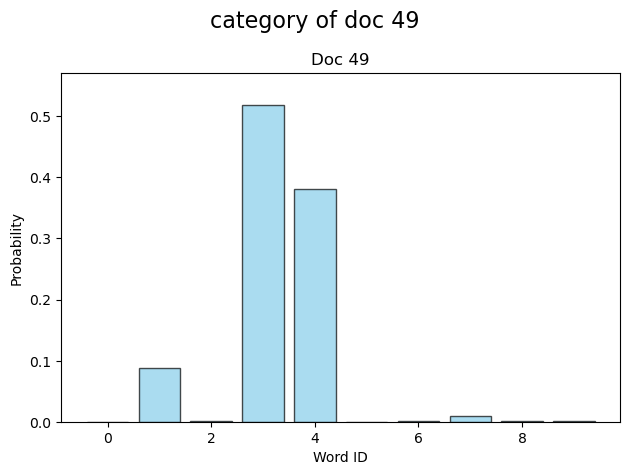

Doc 50 beta: [1.1754944e-38 4.9151713e-01 3.5342512e-01 3.3577976e-01 7.5821239e-01
 1.1754944e-38 5.8271825e-01 1.7919593e-01 1.6853264e-01 1.0000000e+00]
Doc 50 weights: [1.1754944e-38 4.9151713e-01 1.7971061e-01 1.1039507e-01 1.6557628e-01
 6.2067152e-40 3.0768044e-02 3.9481968e-03 3.0478542e-03 1.5036799e-02]


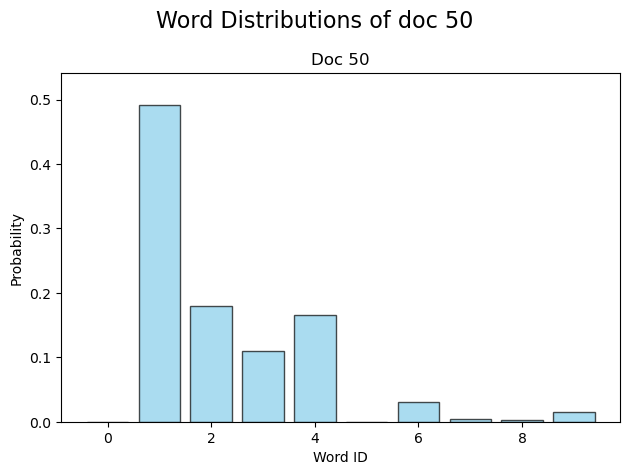

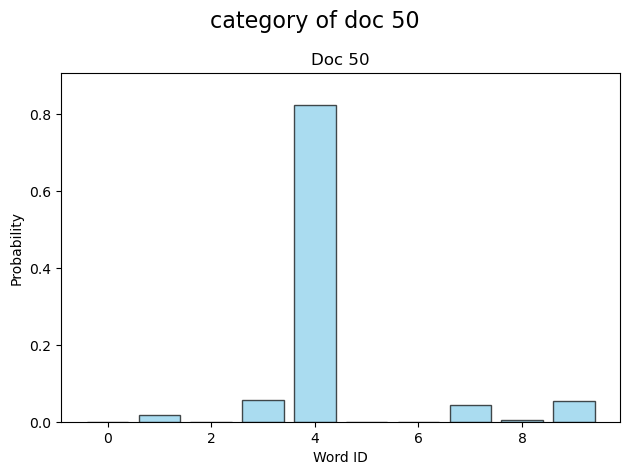

Doc 51 beta: [1.1754944e-38 4.7790167e-01 2.9003850e-01 3.4859550e-01 7.7225345e-01
 1.1754944e-38 2.6474479e-01 2.8601405e-01 3.3299944e-01 1.0000000e+00]
Doc 51 weights: [1.17549435e-38 4.77901667e-01 1.51428610e-01 1.29213795e-01
 1.86465174e-01 6.46413376e-40 1.45585155e-02 1.15641886e-02
 9.61304456e-03 1.92550048e-02]


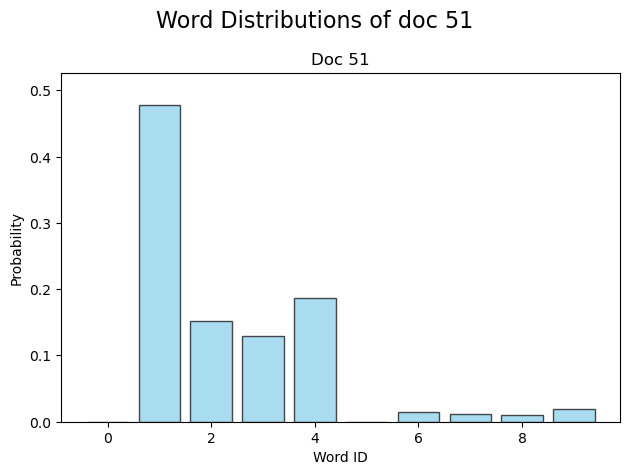

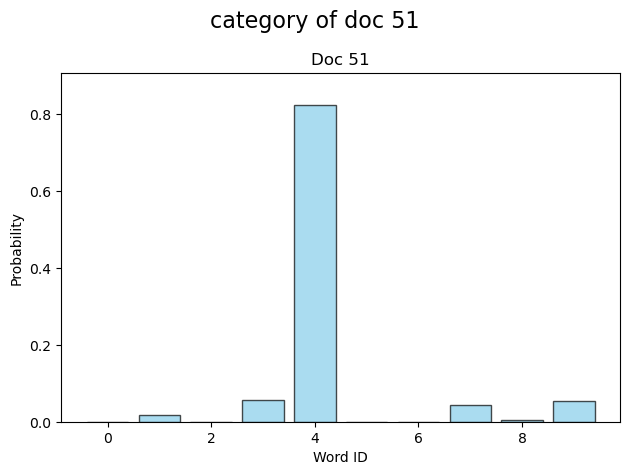

Doc 52 beta: [1.1754944e-38 5.7009935e-01 3.0511123e-01 2.6649755e-01 4.6889612e-01
 1.1754944e-38 5.0690830e-01 1.7026459e-01 1.3801643e-01 1.0000000e+00]
Doc 52 weights: [1.1754944e-38 5.7009935e-01 1.3116752e-01 7.9611652e-02 1.0274521e-01
 1.3679966e-39 5.8992095e-02 9.7704921e-03 6.5714698e-03 4.1042205e-02]


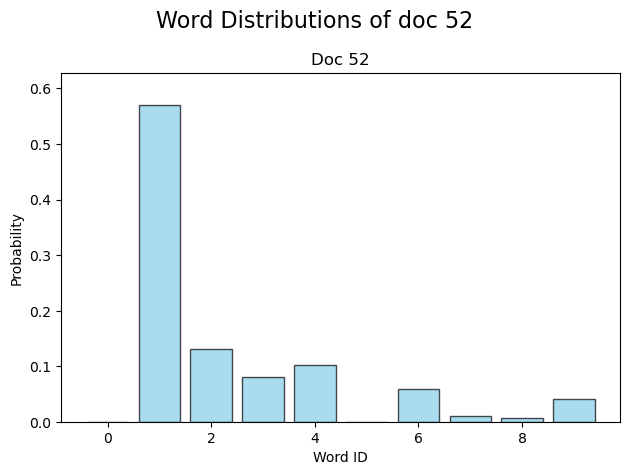

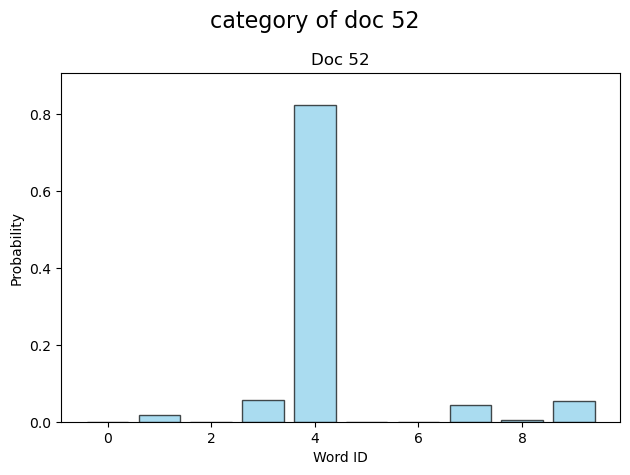

Doc 53 beta: [1.1754944e-38 6.1919957e-01 3.1220704e-01 2.4413598e-01 6.2024504e-01
 1.1754944e-38 2.7985790e-01 7.3643416e-01 5.6616747e-01 1.0000000e+00]
Doc 53 weights: [1.1754944e-38 6.1919957e-01 1.1888857e-01 6.3942105e-02 1.2278975e-01
 8.8373588e-40 2.1039713e-02 3.9870750e-02 8.0789430e-03 6.1905854e-03]


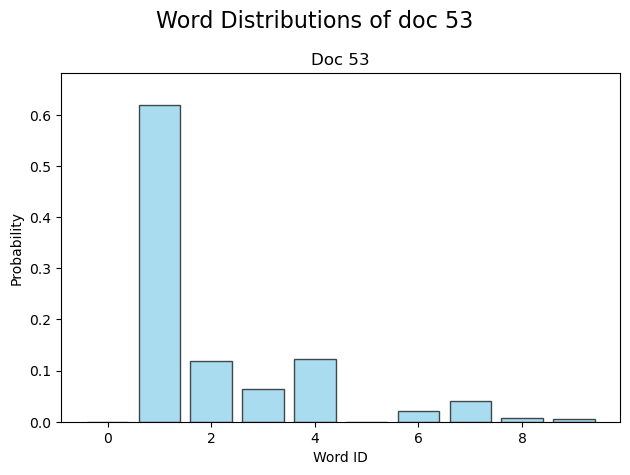

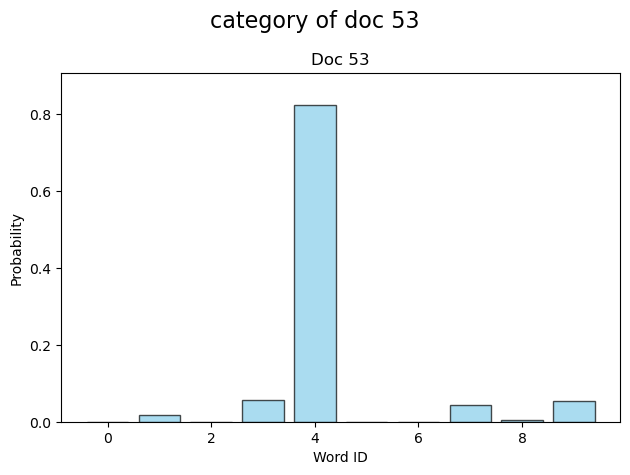

Doc 54 beta: [1.1754944e-38 5.5889851e-01 2.1411586e-01 3.1444490e-01 6.7528594e-01
 1.1754944e-38 3.9541095e-01 2.8850913e-01 6.8953711e-01 1.0000000e+00]
Doc 54 weights: [1.1754944e-38 5.5889851e-01 9.4446823e-02 1.0900379e-01 1.6048229e-01
 9.0711234e-40 3.0513303e-02 1.3460474e-02 2.2889052e-02 1.0305756e-02]


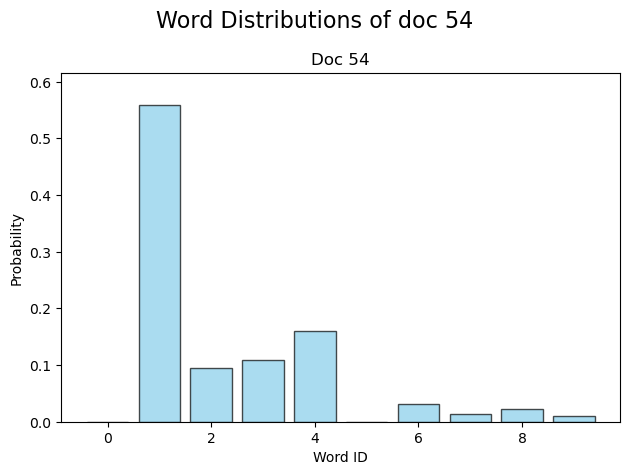

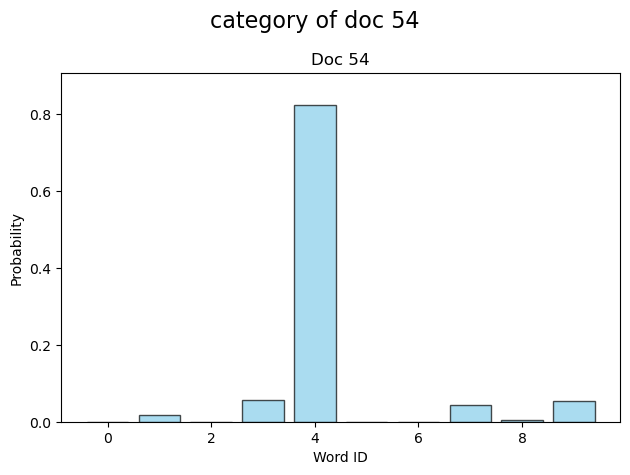

Doc 55 beta: [1.1754944e-38 5.2732307e-01 3.5963872e-01 2.5982305e-01 8.7437510e-01
 1.1754944e-38 1.1464962e-01 5.0330102e-01 2.2931466e-01 1.0000000e+00]
Doc 55 weights: [1.1754944e-38 5.2732307e-01 1.6999292e-01 7.8644283e-02 1.9589475e-01
 3.3084236e-40 3.2268099e-03 1.2541333e-02 2.8381867e-03 9.5386356e-03]


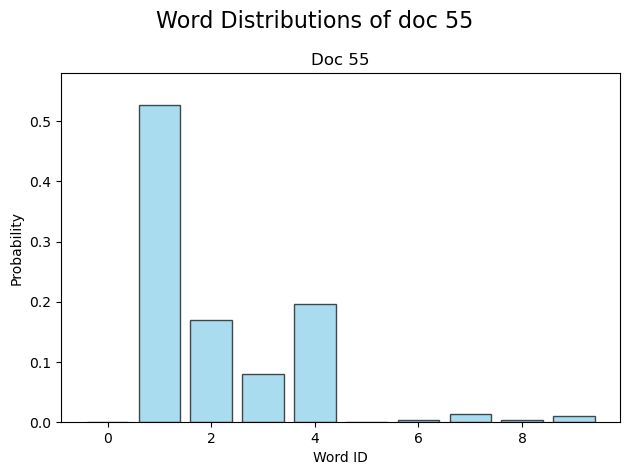

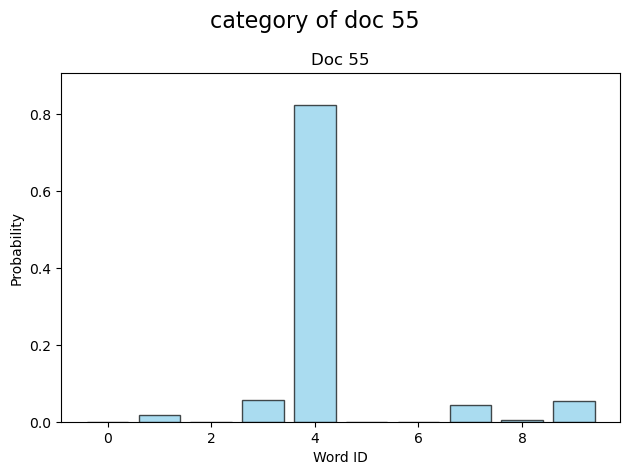

Doc 56 beta: [1.1754944e-38 6.0491490e-01 2.7321386e-01 3.1638148e-01 6.6509944e-01
 1.1754944e-38 2.0406450e-01 6.9975859e-01 9.9996769e-01 1.0000000e+00]
Doc 56 weights: [1.1754944e-38 6.0491490e-01 1.0794272e-01 9.0846531e-02 1.3055626e-01
 7.7276566e-40 1.3415116e-02 3.6614496e-02 1.5709465e-02 5.0752192e-07]


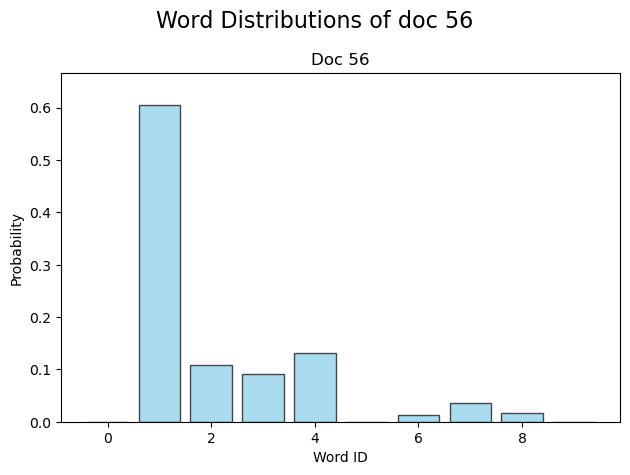

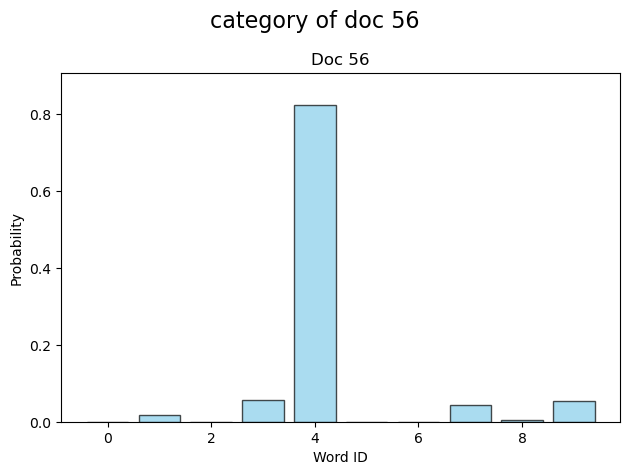

Doc 57 beta: [1.17549435e-38 5.72369158e-01 4.26258236e-01 2.41560802e-01
 7.03469872e-01 1.17549435e-38 2.17890412e-01 1.12609394e-01
 1.15748204e-01 1.00000000e+00]
Doc 57 weights: [1.1754944e-38 5.7236916e-01 1.8228117e-01 5.9266869e-02 1.3090366e-01
 6.4862743e-40 1.2023010e-02 4.8597883e-03 4.4327360e-03 3.3863630e-02]


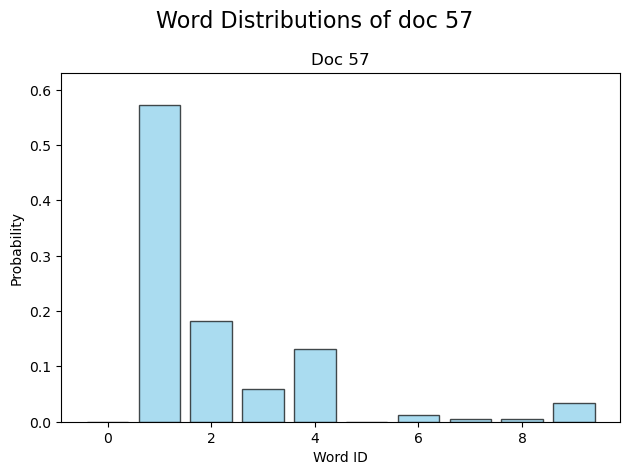

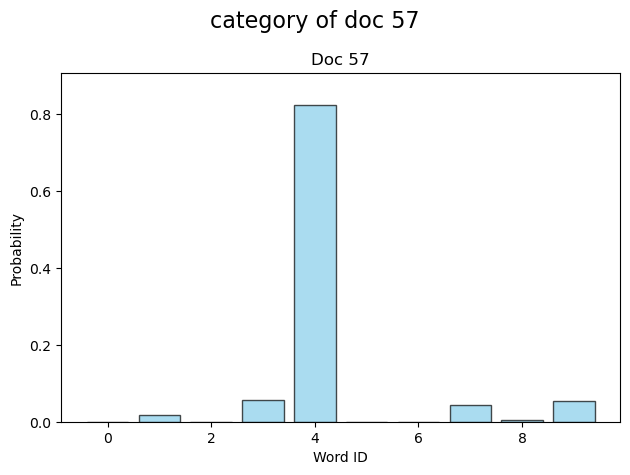

Doc 58 beta: [1.1754944e-38 6.1373758e-01 2.6405710e-01 3.0893299e-01 8.1633866e-01
 1.1754944e-38 4.6621779e-01 1.4677027e-01 1.9970369e-01 1.0000000e+00]
Doc 58 weights: [1.17549435e-38 6.13737583e-01 1.01995334e-01 8.78194869e-02
 1.60367772e-01 4.24116993e-40 1.68210585e-02 2.82661524e-03
 3.28156282e-03 1.31505961e-02]


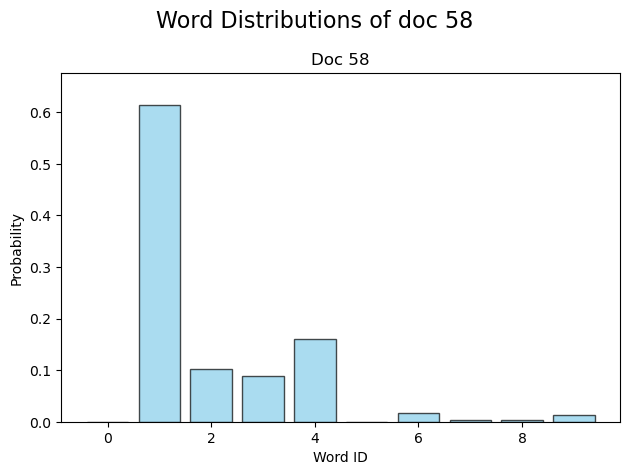

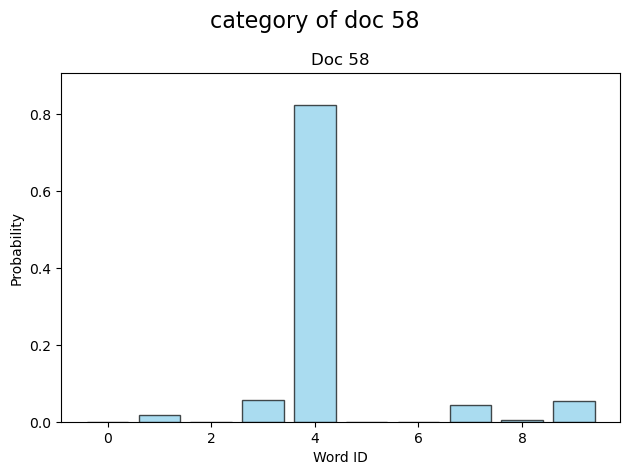

Doc 59 beta: [1.1754944e-38 3.4312510e-01 2.4726494e-01 3.1711805e-01 6.9091988e-01
 1.1754944e-38 3.2146968e-02 5.2806634e-01 6.3864684e-01 1.0000000e+00]
Doc 59 weights: [1.1754944e-38 3.4312510e-01 1.6242214e-01 1.5679990e-01 2.3329107e-01
 1.2267667e-39 3.3549150e-03 5.3338330e-02 3.0443365e-02 1.7225178e-02]


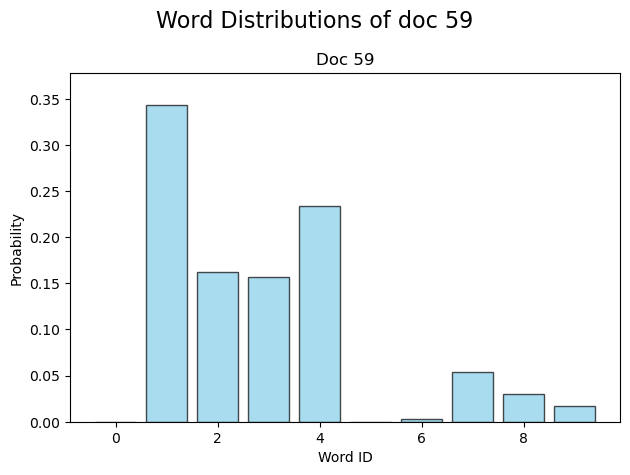

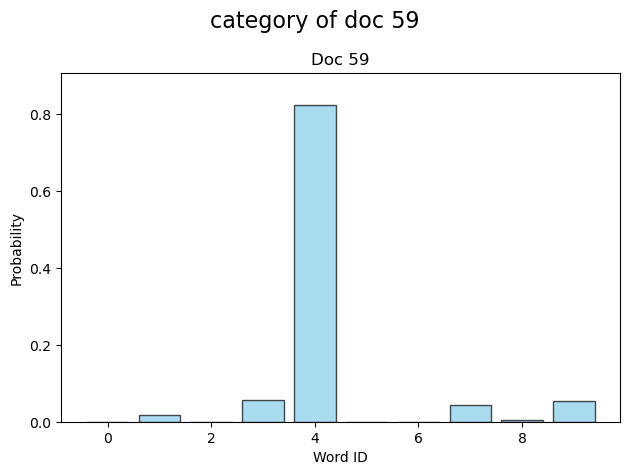

Doc 60 beta: [4.4925776e-03 1.1754944e-38 1.7670743e-03 4.9769256e-02 1.9481517e-02
 9.3773231e-02 1.3065620e-01 1.8772252e-01 9.6911073e-01 1.0000000e+00]
Doc 60 weights: [4.49257763e-03 1.17021342e-38 1.75913563e-03 4.94581126e-02
 1.83962043e-02 8.68240595e-02 1.09629676e-01 1.36932343e-01
 5.74205697e-01 1.83021370e-02]


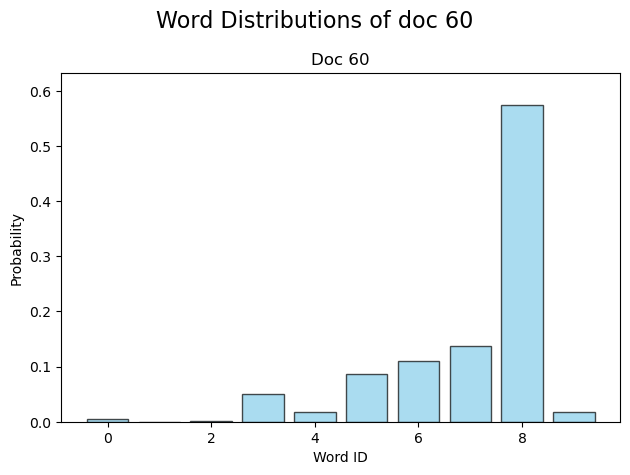

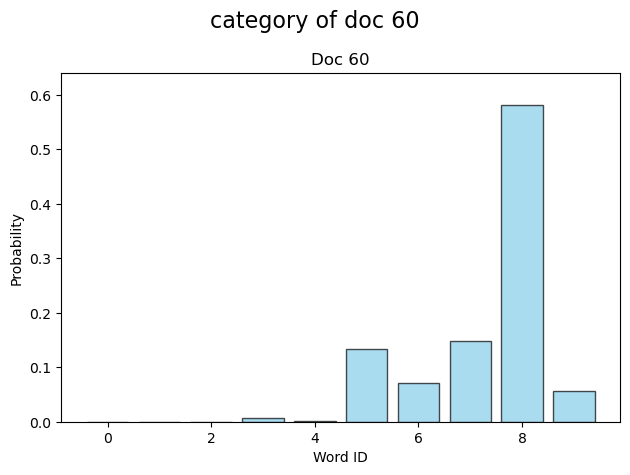

Doc 61 beta: [4.4879273e-02 1.1754944e-38 1.0866388e-02 3.2045092e-02 5.3281072e-03
 1.6204119e-01 1.4456818e-01 3.3421293e-01 9.4212598e-01 1.0000000e+00]
Doc 61 weights: [4.48792726e-02 1.12273911e-38 1.03787128e-02 3.02743446e-02
 4.87238169e-03 1.47391900e-01 1.10190354e-01 2.17911169e-01
 4.08978641e-01 2.51232199e-02]


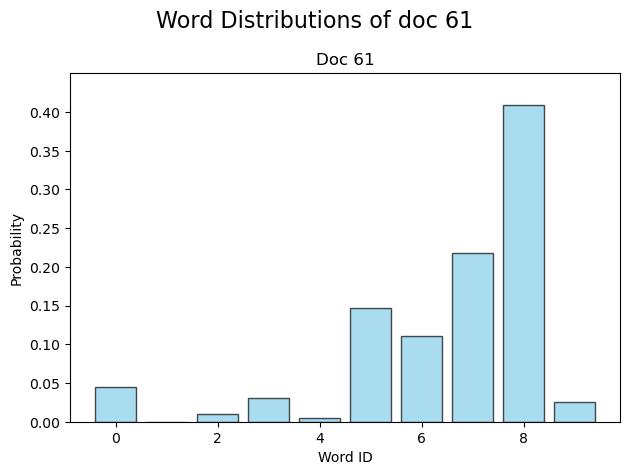

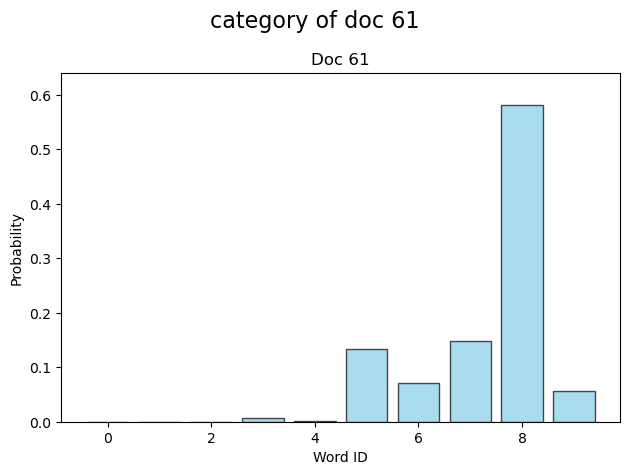

Doc 62 beta: [1.0620482e-02 1.1754944e-38 2.8646351e-03 3.0369187e-02 1.0634866e-02
 1.3680114e-01 9.8188467e-02 2.1447322e-01 9.7578317e-01 1.0000000e+00]
Doc 62 weights: [1.0620482e-02 1.1630100e-38 2.8342113e-03 2.9960578e-02 1.0173149e-02
 1.2947018e-01 8.0214225e-02 1.5800825e-01 5.6470418e-01 1.4014738e-02]


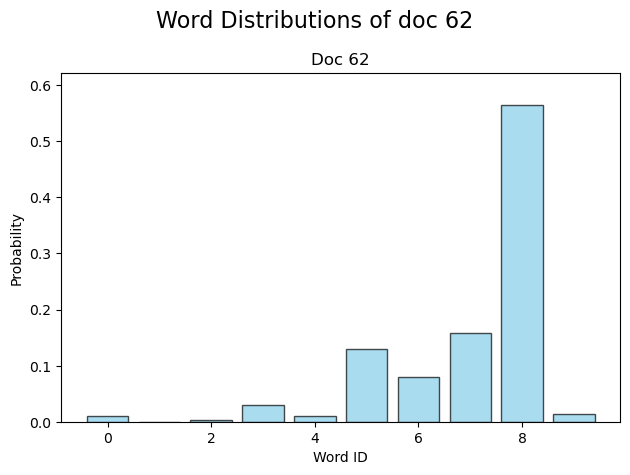

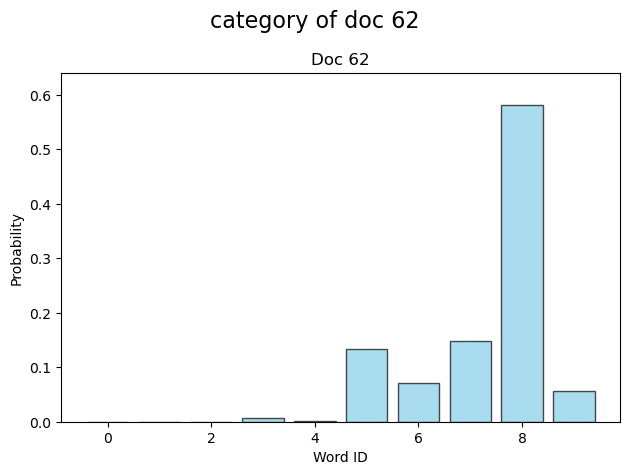

Doc 63 beta: [2.6372306e-02 1.1754944e-38 2.5309571e-03 2.0019641e-02 2.5118954e-02
 1.6172066e-01 8.5052699e-02 2.2165385e-01 9.8372161e-01 1.0000000e+00]
Doc 63 weights: [2.6372306e-02 1.1444938e-38 2.4642099e-03 1.9442344e-02 2.3906240e-02
 1.5004684e-01 6.6151276e-02 1.5773259e-01 5.4486787e-01 9.0163406e-03]


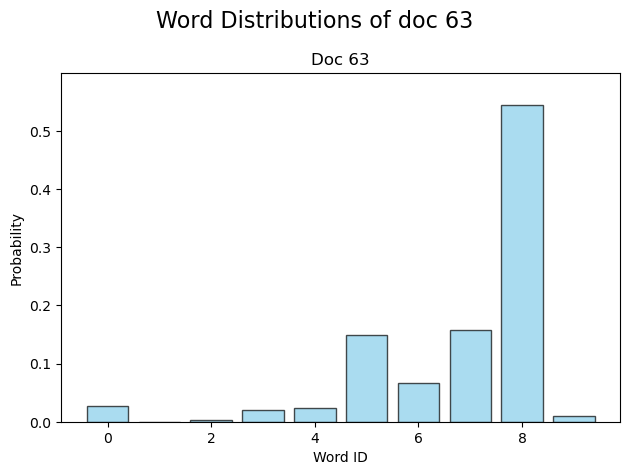

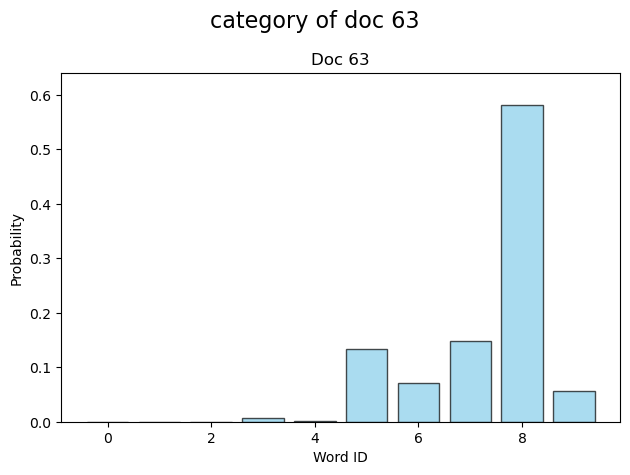

Doc 64 beta: [1.49606001e-02 1.17549435e-38 1.41413510e-03 2.25652307e-02
 7.19587924e-03 1.31570071e-01 1.05153725e-01 2.69316524e-01
 9.88266170e-01 1.00000000e+00]
Doc 64 weights: [1.4960600e-02 1.1579083e-38 1.3929788e-03 2.2196209e-02 6.9184797e-03
 1.2558781e-01 8.7166540e-02 1.9977289e-01 5.3564465e-01 6.3597881e-03]


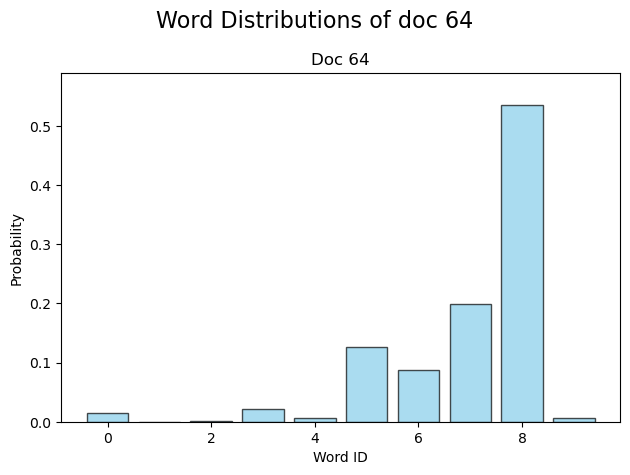

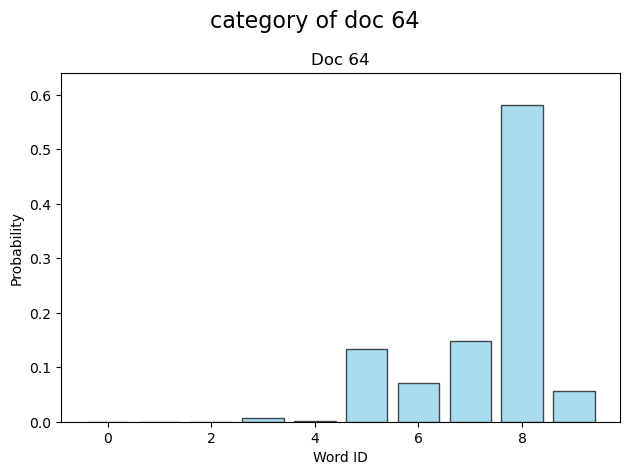

Doc 65 beta: [1.9727204e-02 1.1754944e-38 2.1933032e-02 1.8234095e-02 1.4019101e-02
 1.8154776e-01 6.9882147e-02 2.2701564e-01 9.7362375e-01 1.0000000e+00]
Doc 65 weights: [1.9727204e-02 1.1523051e-38 2.1500355e-02 1.7482348e-02 1.3196041e-02
 1.6849340e-01 5.3082529e-02 1.6039068e-01 5.3172272e-01 1.4404794e-02]


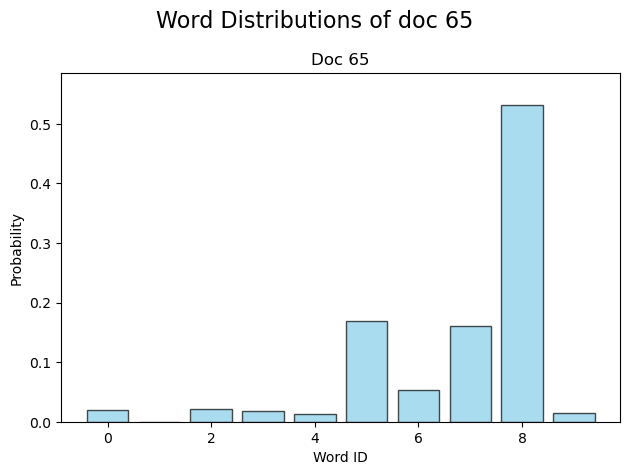

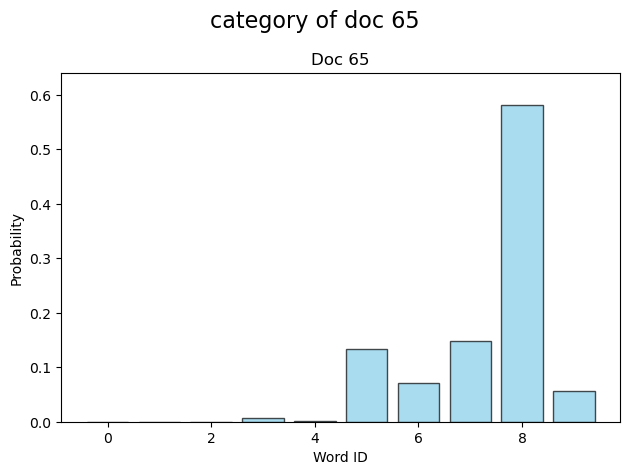

Doc 66 beta: [6.4929165e-03 1.1754944e-38 4.1300203e-03 3.2918800e-02 2.5820000e-02
 1.7296575e-01 8.4160745e-02 1.8013020e-01 9.8179209e-01 1.0000000e+00]
Doc 66 weights: [6.4929165e-03 1.1678620e-38 4.1032042e-03 3.2569990e-02 2.4705451e-02
 1.6122629e-01 6.4879693e-02 1.2717596e-01 5.6830686e-01 1.0539583e-02]


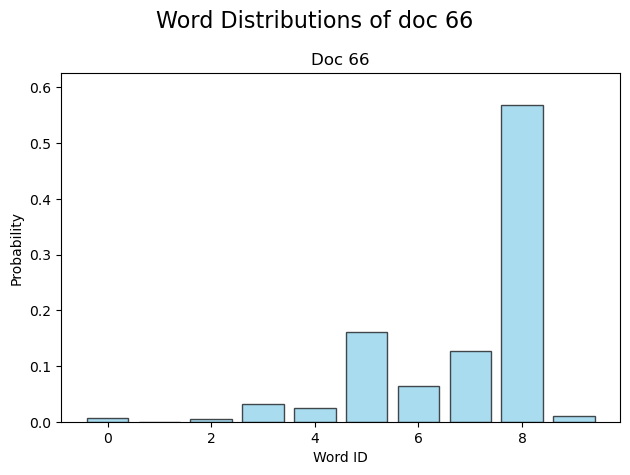

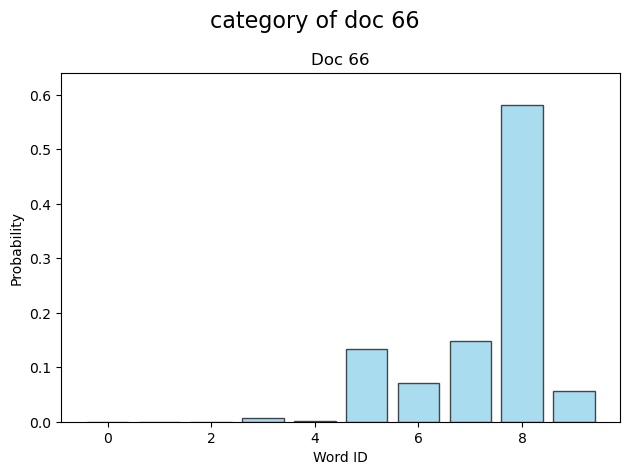

Doc 67 beta: [2.3573784e-02 1.1754944e-38 2.1455195e-03 3.1669497e-02 5.2758805e-02
 1.4705977e-01 1.4551549e-01 2.3929618e-01 8.8516045e-01 1.0000000e+00]
Doc 67 weights: [2.3573784e-02 1.1477835e-38 2.0949414e-03 3.0856583e-02 4.9776599e-02
 1.3142703e-01 1.1092224e-01 1.5586528e-01 4.3858239e-01 5.6901101e-02]


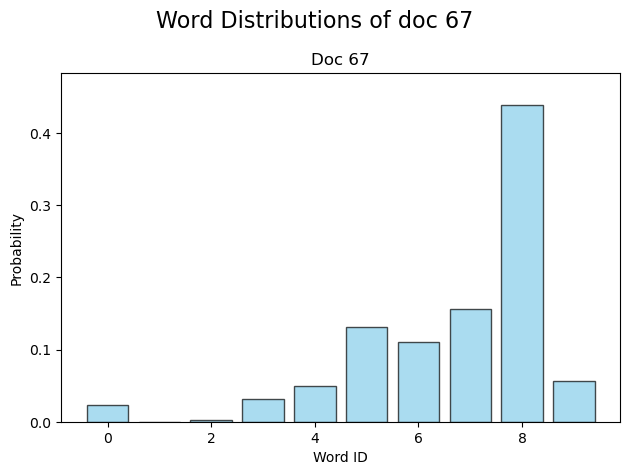

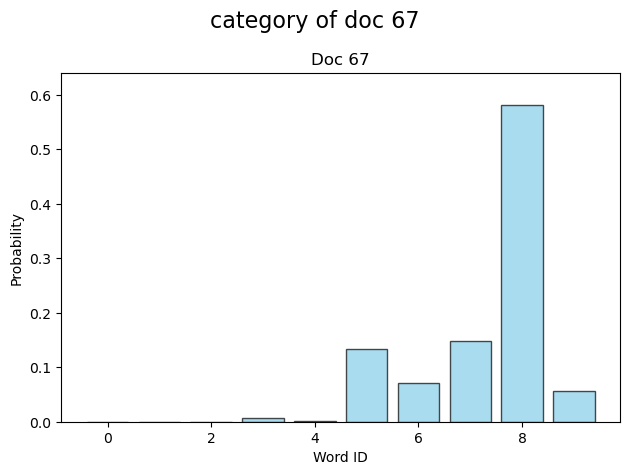

Doc 68 beta: [1.12603176e-02 1.17549435e-38 1.17549435e-38 1.79614574e-02
 1.36318775e-02 1.31800801e-01 5.17385565e-02 1.92264140e-01
 9.46994960e-01 1.00000000e+00]
Doc 68 weights: [1.1260318e-02 1.1622580e-38 1.1622580e-38 1.7759206e-02 1.3236287e-02
 1.2623145e-01 4.3021269e-02 1.5159863e-01 6.0313433e-01 3.3758532e-02]


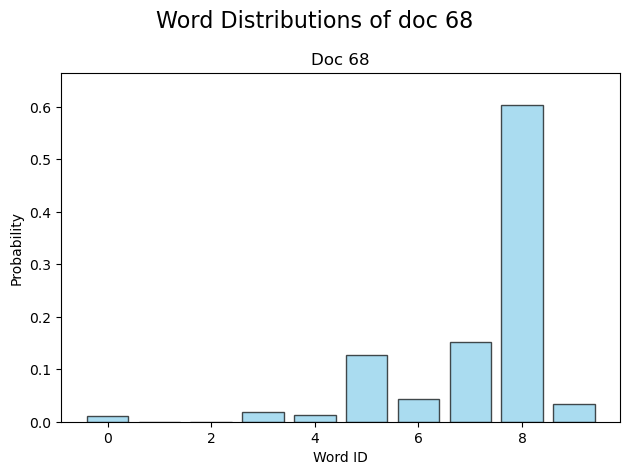

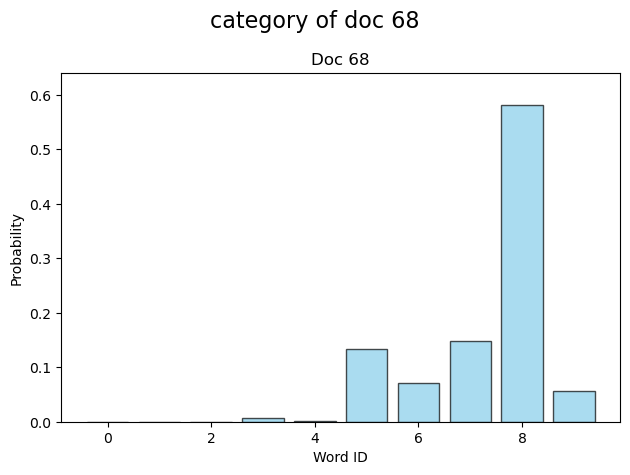

Doc 69 beta: [1.0492595e-02 1.1754944e-38 2.3355782e-03 2.0658979e-02 1.4992092e-02
 1.1839996e-01 7.8838423e-02 2.5588781e-01 9.0310329e-01 1.0000000e+00]
Doc 69 weights: [1.0492595e-02 1.1631604e-38 2.3110718e-03 2.0394469e-02 1.4494383e-02
 1.1275317e-01 6.6189140e-02 1.9789472e-01 5.1970923e-01 5.5761192e-02]


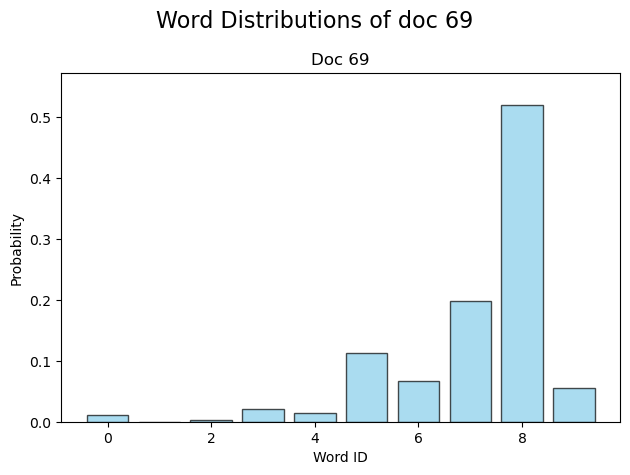

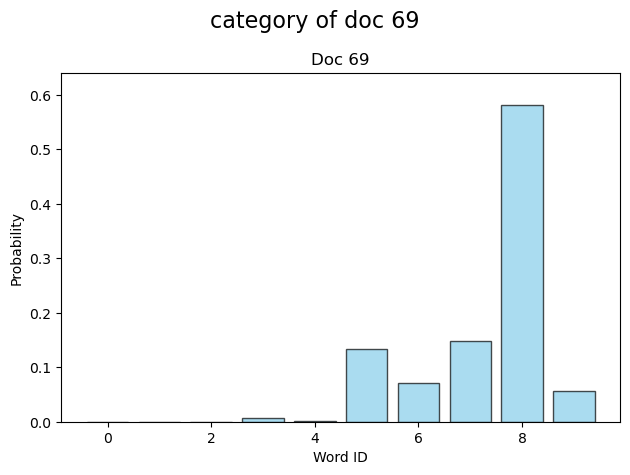

Doc 70 beta: [2.9142490e-03 1.1754944e-38 6.9264681e-03 3.7583105e-02 1.9176245e-02
 1.6964249e-01 9.3526088e-02 2.1434024e-01 9.3667138e-01 1.0000000e+00]
Doc 70 weights: [2.9142490e-03 1.1720687e-38 6.9062826e-03 3.7214018e-02 1.8274298e-02
 1.5856333e-01 7.2588190e-02 1.5079685e-01 5.1773834e-01 3.5004441e-02]


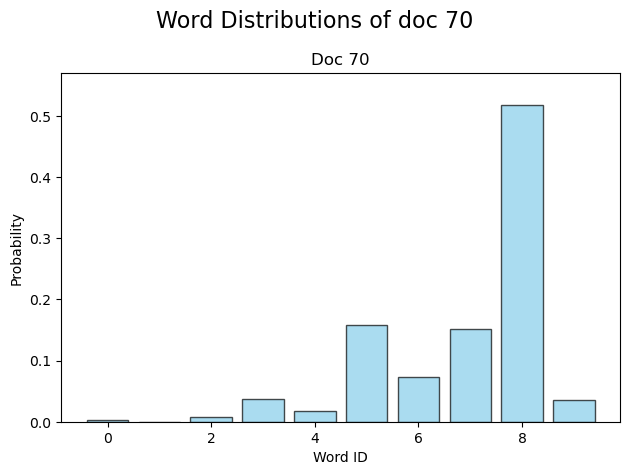

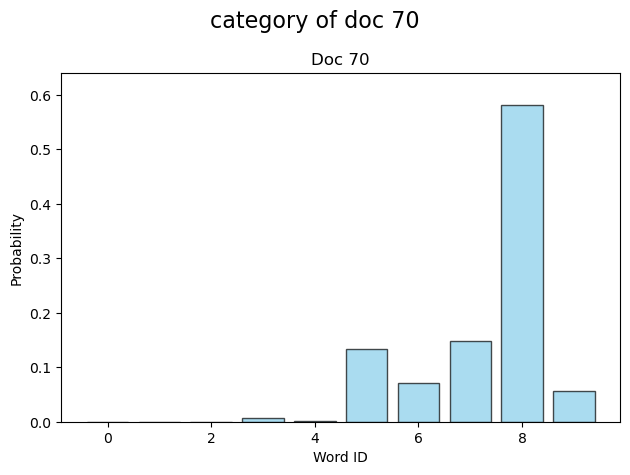

Doc 71 beta: [1.1754944e-38 1.1754944e-38 2.0489653e-03 2.9630531e-02 4.7063371e-03
 2.2065483e-01 8.6406350e-02 2.3627764e-01 9.8601449e-01 1.0000000e+00]
Doc 71 weights: [1.1754944e-38 1.1754944e-38 2.0489653e-03 2.9569818e-02 4.5575285e-03
 2.1267237e-01 6.4904250e-02 1.6214485e-01 5.1677245e-01 7.3298397e-03]


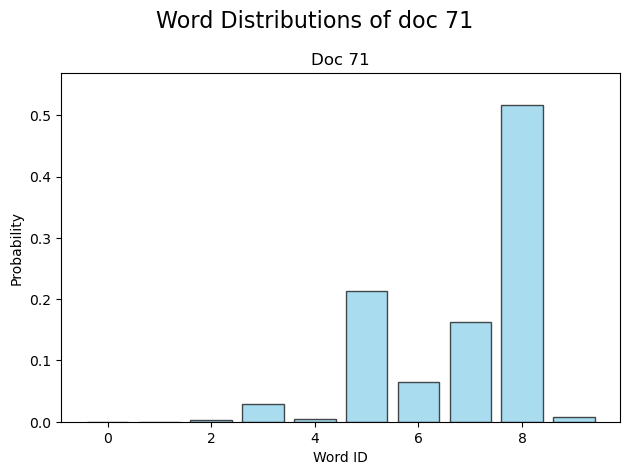

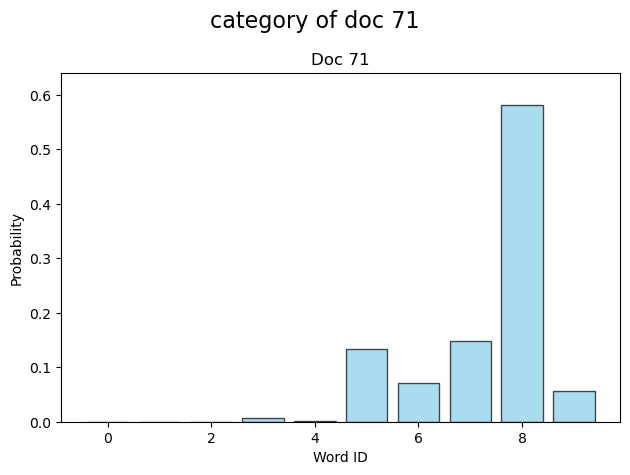

Doc 72 beta: [2.2073142e-02 1.1754944e-38 1.1754944e-38 3.6168527e-02 1.3093311e-02
 1.2904443e-01 3.6369186e-02 2.1298020e-01 9.6964771e-01 1.0000000e+00]
Doc 72 weights: [2.20731422e-02 1.14954749e-38 1.14954749e-38 3.53701748e-02
 1.23411883e-02 1.20039135e-01 2.94654574e-02 1.66275963e-01
 5.95785439e-01 1.86495110e-02]


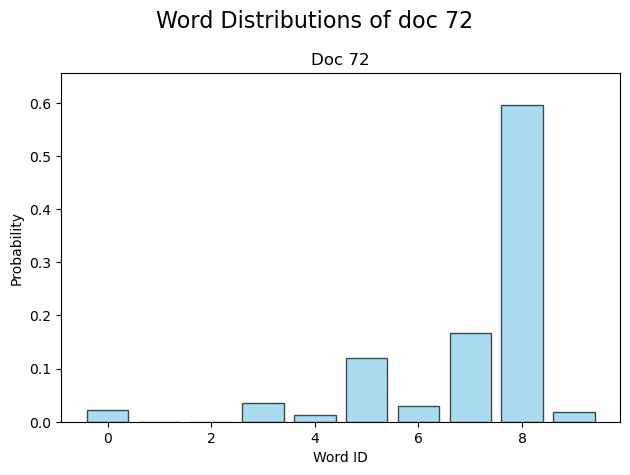

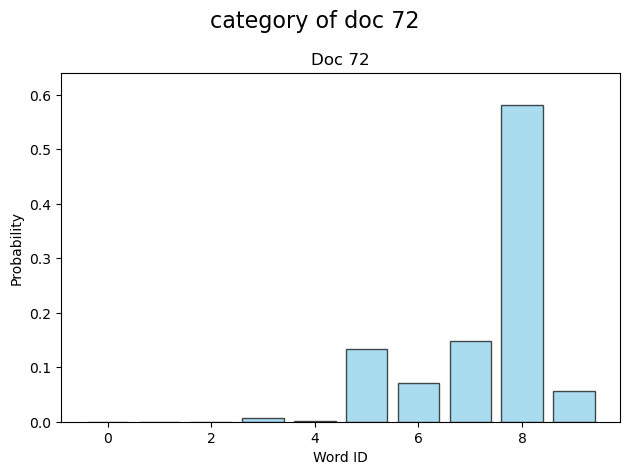

Doc 73 beta: [1.3889610e-03 1.1754944e-38 9.8542618e-03 5.1578127e-02 1.2112852e-02
 1.7377533e-01 2.9447200e-02 2.0567951e-01 9.5344132e-01 1.0000000e+00]
Doc 73 weights: [1.3889610e-03 1.1738616e-38 9.8405741e-03 5.0998930e-02 1.1359088e-02
 1.6098763e-01 2.2539617e-02 1.5279627e-01 5.6261522e-01 2.7473763e-02]


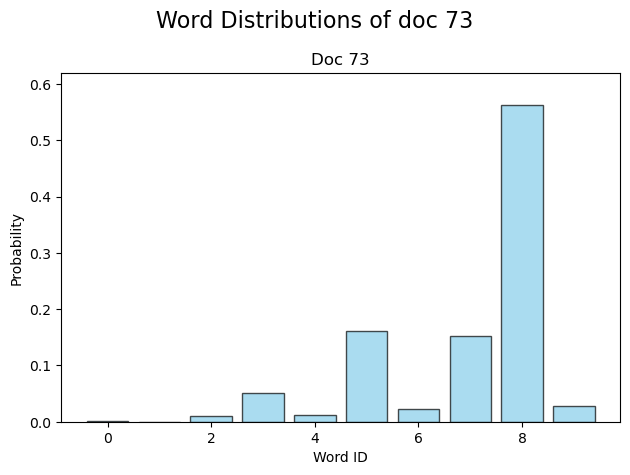

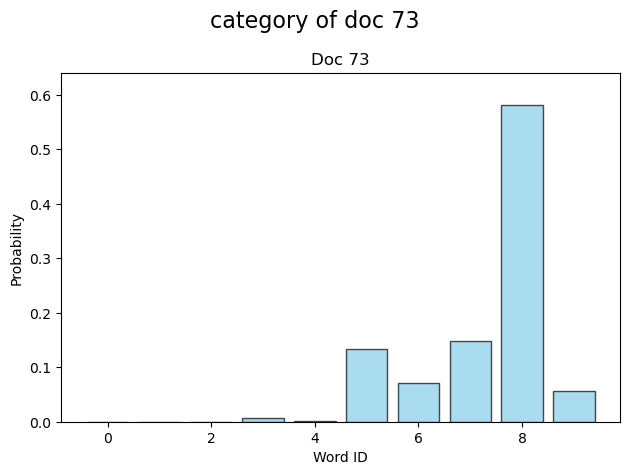

Doc 74 beta: [2.0798014e-03 1.1754944e-38 1.9288579e-02 5.1000360e-02 6.1302977e-03
 1.3538171e-01 7.5016119e-02 1.8573153e-01 9.3202227e-01 1.0000000e+00]
Doc 74 weights: [2.0798014e-03 1.1730496e-38 1.9248463e-02 4.9912609e-02 5.6935698e-03
 1.2496620e-01 5.9870314e-02 1.3711239e-01 5.6025404e-01 4.0862538e-02]


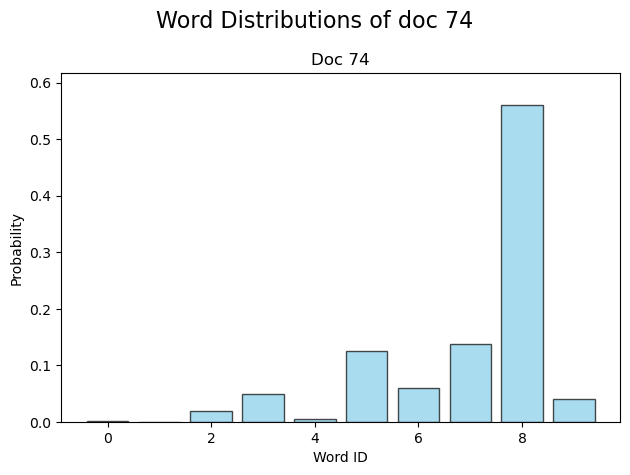

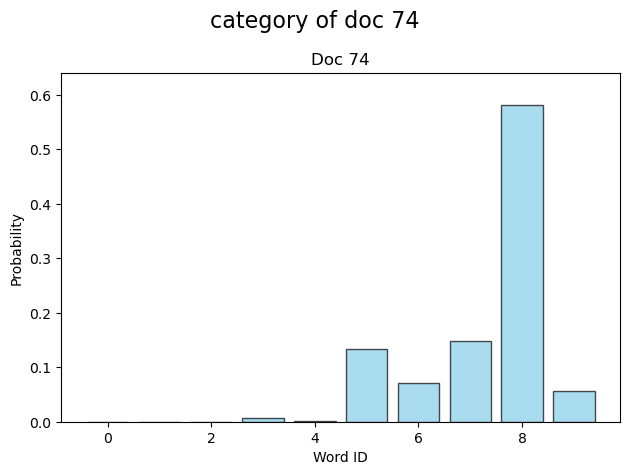

Doc 75 beta: [1.5035624e-02 1.1754944e-38 1.1754944e-38 1.2482115e-02 3.1001745e-03
 1.5003878e-01 1.6574515e-02 1.2874846e-01 9.1420412e-01 1.0000000e+00]
Doc 75 weights: [1.5035624e-02 1.1578201e-38 1.1578201e-38 1.2294439e-02 3.0154465e-03
 1.4548577e-01 1.3660197e-02 1.0435173e-01 6.4557147e-01 6.0585342e-02]


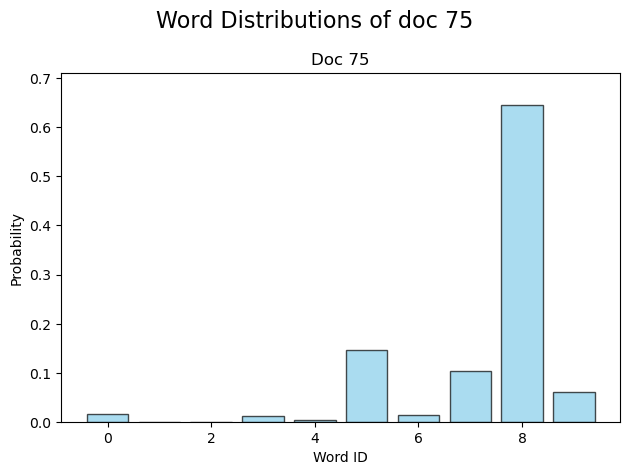

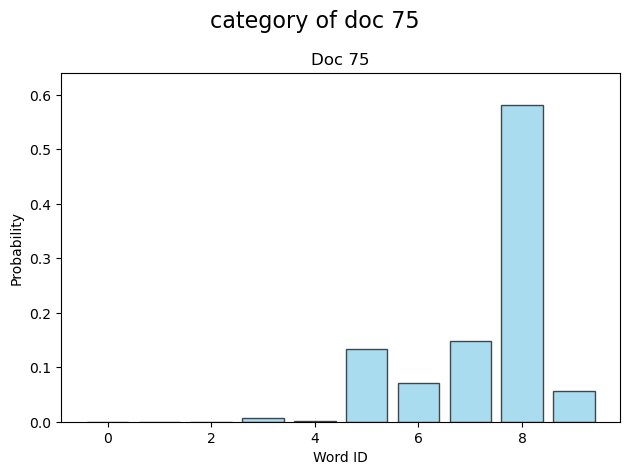

Doc 76 beta: [7.9972688e-03 1.1754944e-38 1.3434412e-03 3.9814532e-02 3.3950051e-03
 1.6163597e-01 7.3091693e-02 2.0164461e-01 9.8533672e-01 1.0000000e+00]
Doc 76 weights: [7.9972688e-03 1.1660936e-38 1.3326973e-03 3.9443064e-02 3.2294204e-03
 1.5323049e-01 5.8090862e-02 1.4854677e-01 5.7950544e-01 8.6239045e-03]


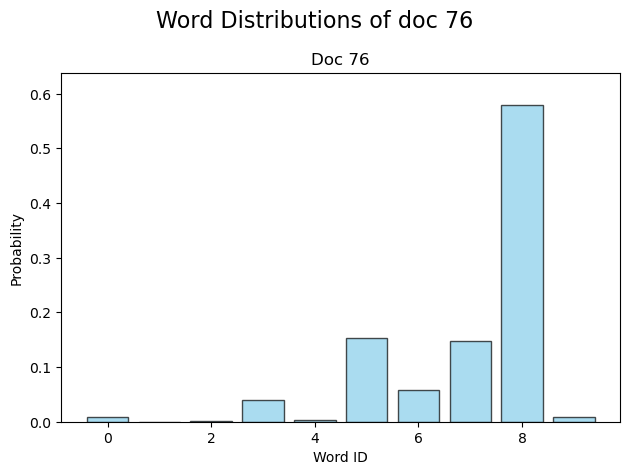

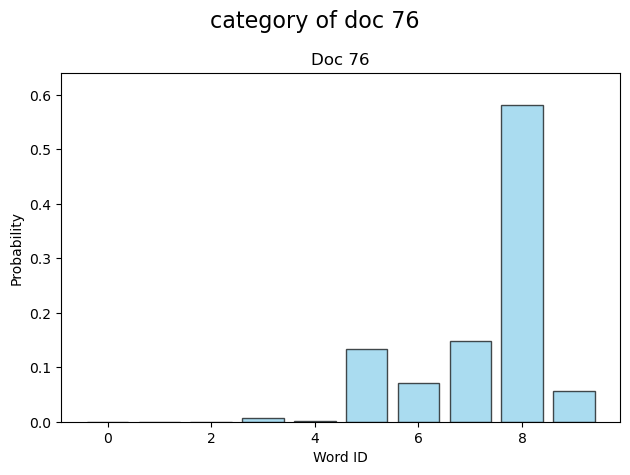

Doc 77 beta: [3.1324822e-02 1.1754944e-38 8.1384080e-03 2.6972519e-02 1.0490491e-02
 1.6823971e-01 1.1890577e-01 1.8493220e-01 9.4172549e-01 1.0000000e+00]
Doc 77 weights: [3.1324822e-02 1.1386722e-38 7.8834742e-03 2.5914973e-02 9.8073157e-03
 1.5563342e-01 9.1490388e-02 1.2537399e-01 5.2037084e-01 3.2200839e-02]


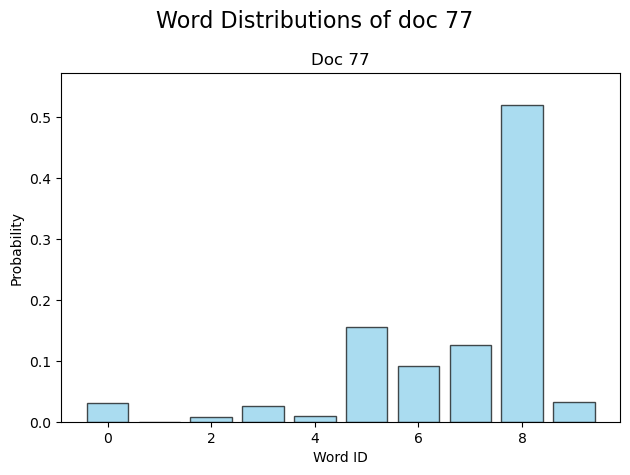

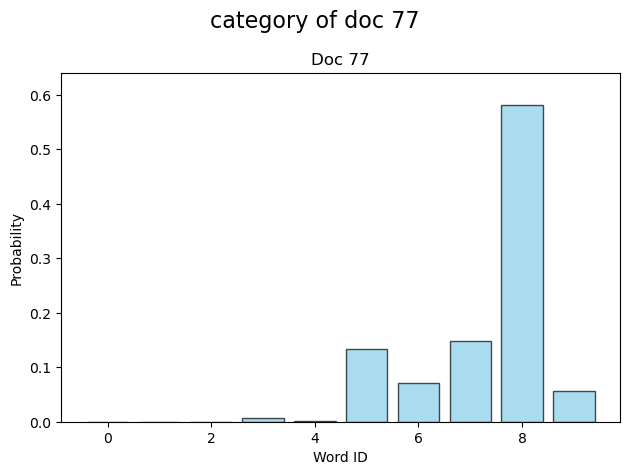

Doc 78 beta: [1.1227762e-02 1.1754944e-38 1.1754944e-38 5.5130951e-02 4.0677838e-02
 1.2375917e-01 1.1469793e-02 1.6523476e-01 9.6533048e-01 1.0000000e+00]
Doc 78 weights: [1.12277623e-02 1.16229608e-38 1.16229608e-38 5.45119531e-02
 3.80036868e-02 1.10919975e-01 9.00764763e-03 1.28276527e-01
 6.25584781e-01 2.24676672e-02]


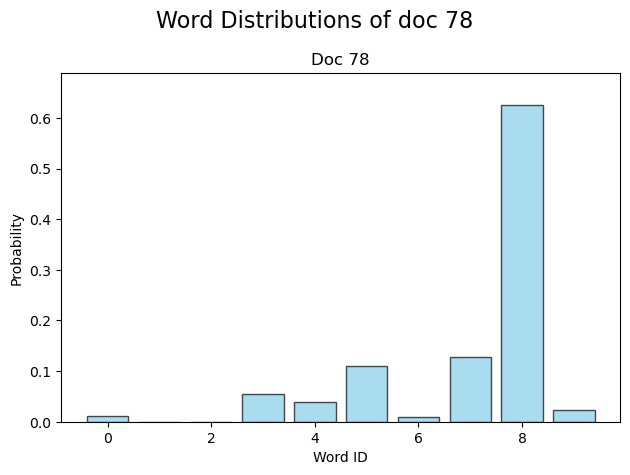

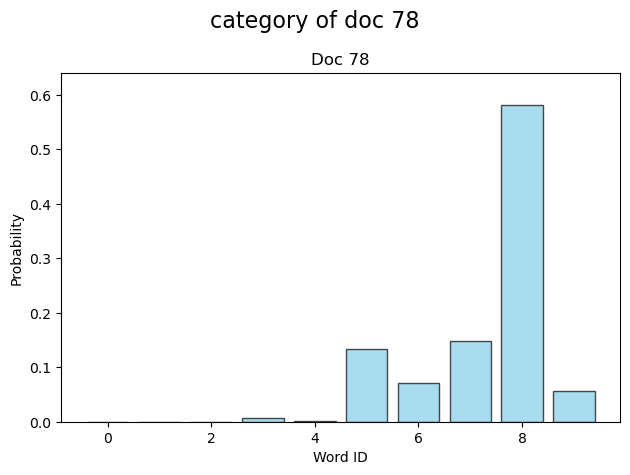

Doc 79 beta: [1.1754944e-38 1.1754944e-38 1.5593489e-03 3.7539631e-02 1.5979271e-02
 1.3438383e-01 7.0023380e-02 2.2225423e-01 9.7936785e-01 1.0000000e+00]
Doc 79 weights: [1.1754944e-38 1.1754944e-38 1.5593489e-03 3.7481092e-02 1.5355433e-02
 1.2707390e-01 5.7316251e-02 1.6918303e-01 5.7981604e-01 1.2214870e-02]


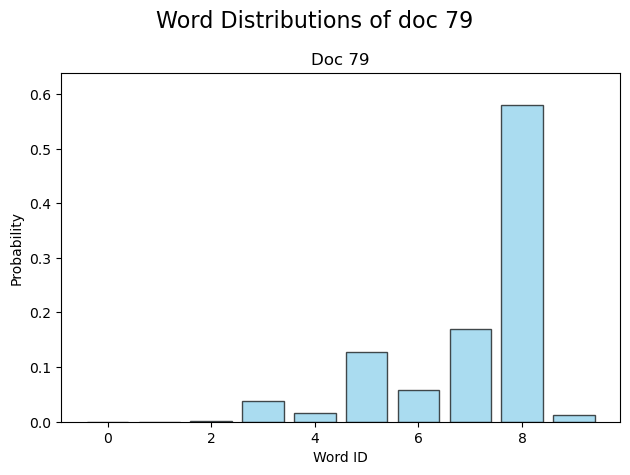

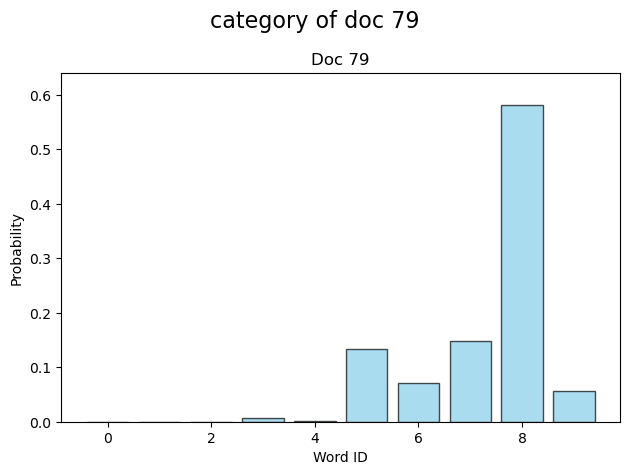

Doc 80 beta: [2.5486739e-03 1.1754944e-38 1.1754944e-38 3.4638934e-02 1.1754944e-38
 1.7307227e-03 4.1597929e-02 8.8071764e-02 9.9999988e-01 1.0000000e+00]
Doc 80 weights: [2.5486739e-03 1.1724984e-38 1.1724984e-38 3.4550648e-02 1.1318843e-38
 1.6665140e-03 3.9985348e-02 8.1136003e-02 8.4011269e-01 1.0014925e-07]


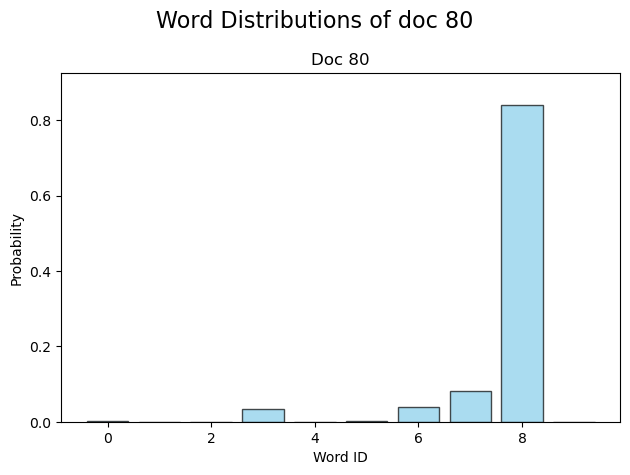

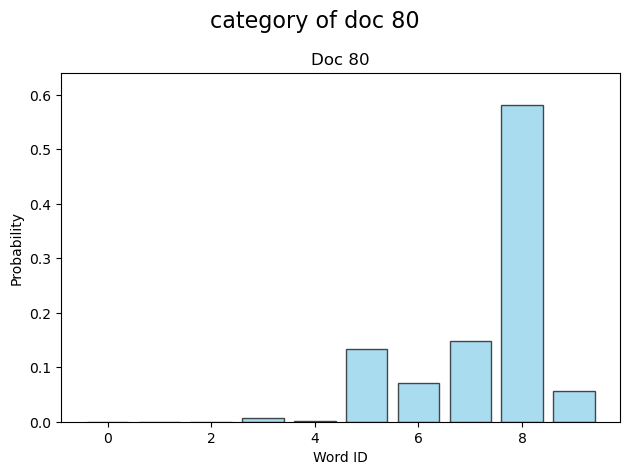

Doc 81 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.8073666e-02 1.1754944e-38
 6.6663878e-04 7.6474331e-02 7.5950570e-02 9.9999988e-01 1.0000000e+00]
Doc 81 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.8073666e-02 1.1072291e-38
 6.2792463e-04 7.1985170e-02 6.6024840e-02 8.0328834e-01 9.5759447e-08]


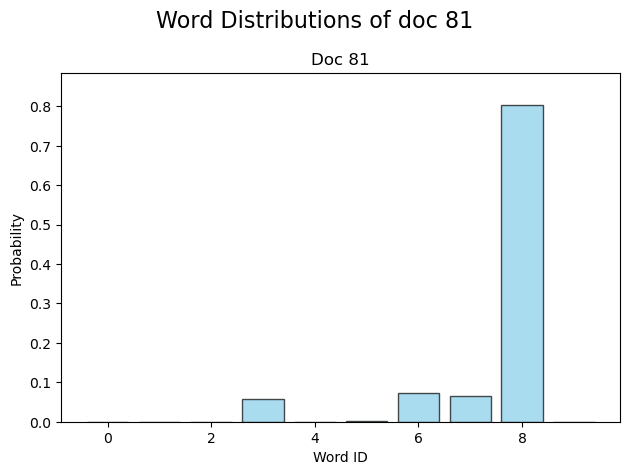

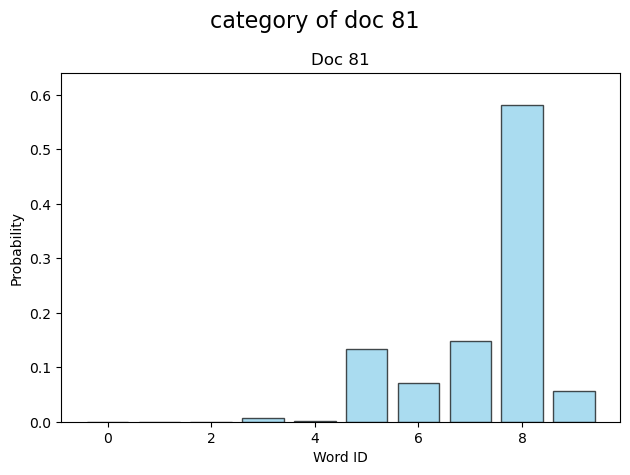

Doc 82 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 9.1784827e-02 1.9766113e-02
 2.1384947e-02 6.4092278e-02 4.3070089e-02 9.9999988e-01 1.0000000e+00]
Doc 82 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 9.1784827e-02 1.7951883e-02
 1.9038234e-02 5.5838797e-02 3.5118759e-02 7.8026736e-01 9.3015132e-08]


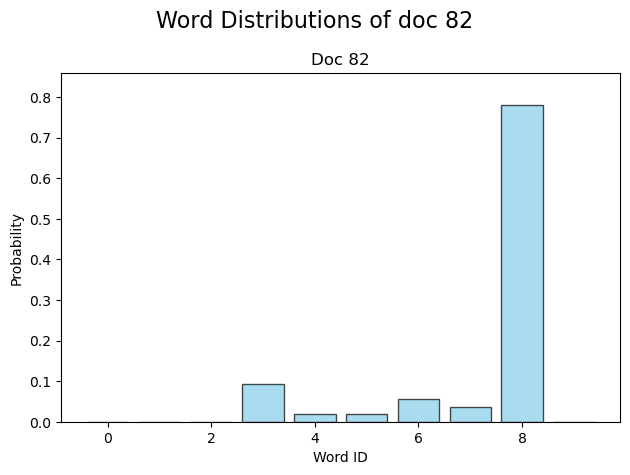

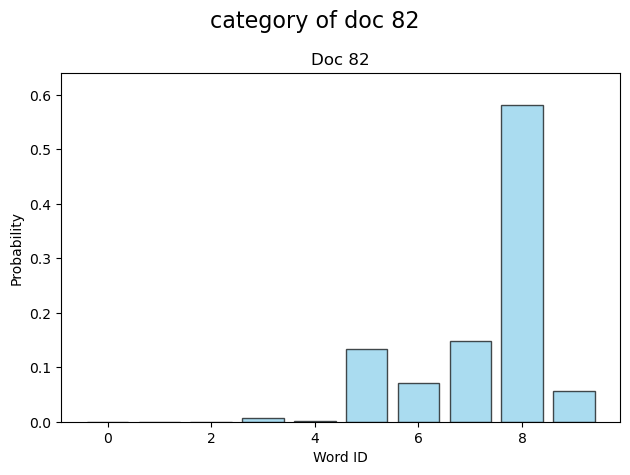

Doc 83 beta: [1.1754944e-38 1.1754944e-38 3.9797407e-03 5.3106673e-02 5.8267037e-03
 1.4783804e-02 2.8066657e-02 1.5124647e-01 9.9999988e-01 1.0000000e+00]
Doc 83 weights: [1.17549435e-38 1.17549435e-38 3.97974066e-03 5.28953224e-02
 5.49530983e-03 1.38617335e-02 2.59270780e-02 1.35795265e-01
 7.62045443e-01 9.08429101e-08]


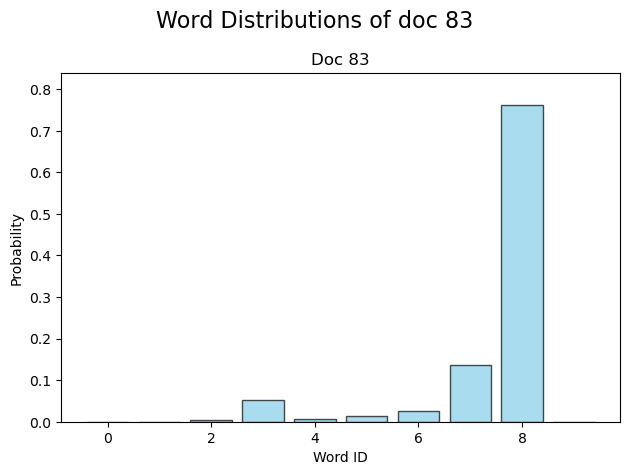

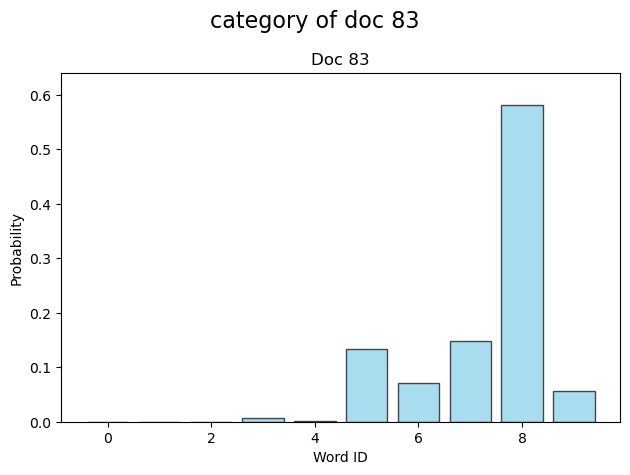

Doc 84 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 7.9995751e-02 1.1754944e-38
 1.7886125e-02 5.6909271e-02 8.8387601e-02 9.9999988e-01 1.0000000e+00]
Doc 84 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 7.9995751e-02 1.0814598e-38
 1.6455311e-02 5.1420312e-02 7.5317606e-02 7.7681088e-01 9.2603088e-08]


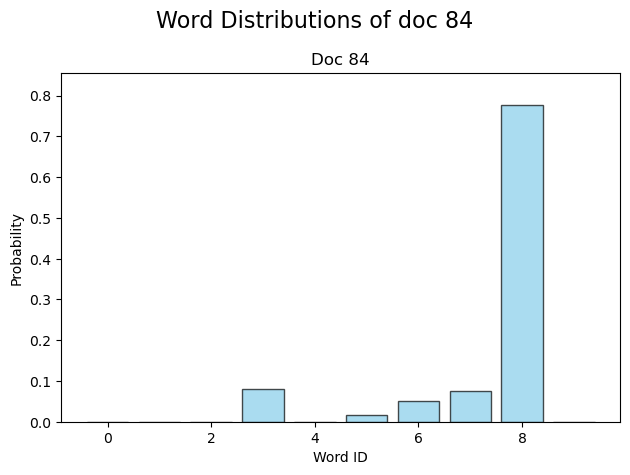

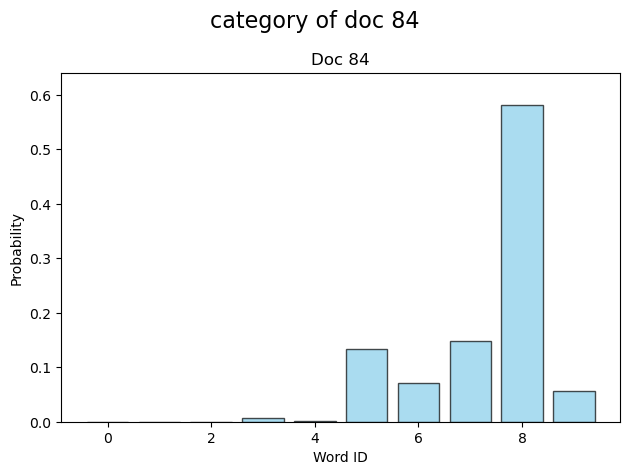

Doc 85 beta: [5.7955184e-03 1.1754944e-38 4.5099081e-03 3.4165379e-02 3.8404381e-03
 1.2347760e-02 5.6467943e-02 8.4643237e-02 9.9999988e-01 1.0000000e+00]
Doc 85 weights: [5.7955184e-03 1.1686818e-38 4.4837706e-03 3.3814184e-02 3.6710997e-03
 1.1757974e-02 5.3106826e-02 7.5109921e-02 8.1226057e-01 9.6829019e-08]


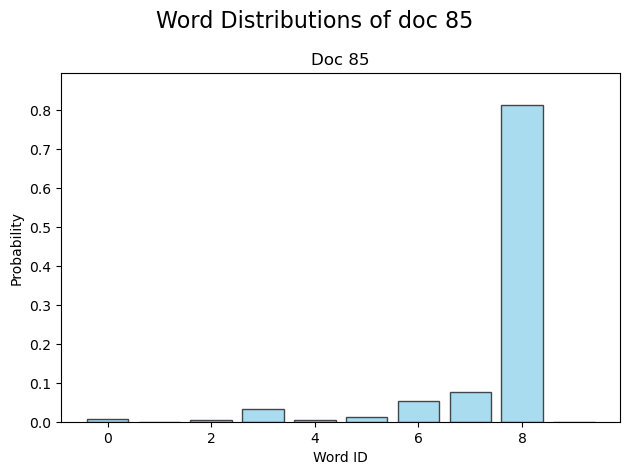

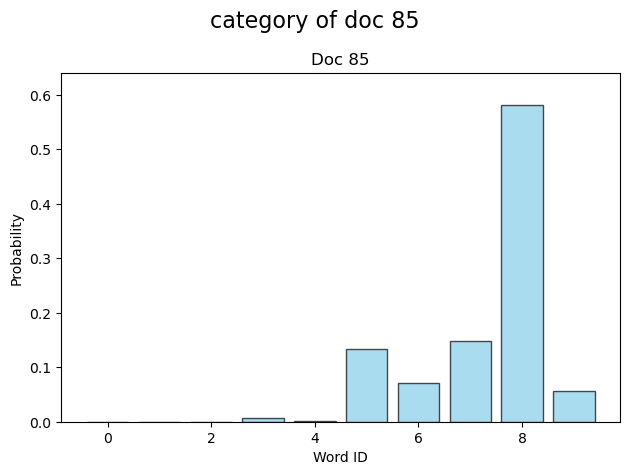

Doc 86 beta: [1.1754944e-38 1.1754944e-38 1.3172129e-02 7.0941277e-02 9.8068314e-03
 7.4721994e-03 2.5325874e-02 1.2600967e-01 9.9999988e-01 1.0000000e+00]
Doc 86 weights: [1.1754944e-38 1.1754944e-38 1.3172129e-02 7.0006825e-02 8.9911092e-03
 6.7834863e-03 2.2819789e-02 1.1066505e-01 7.6756144e-01 9.1500468e-08]


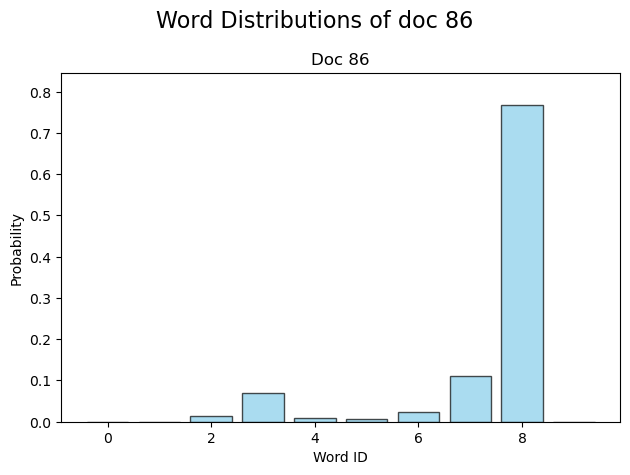

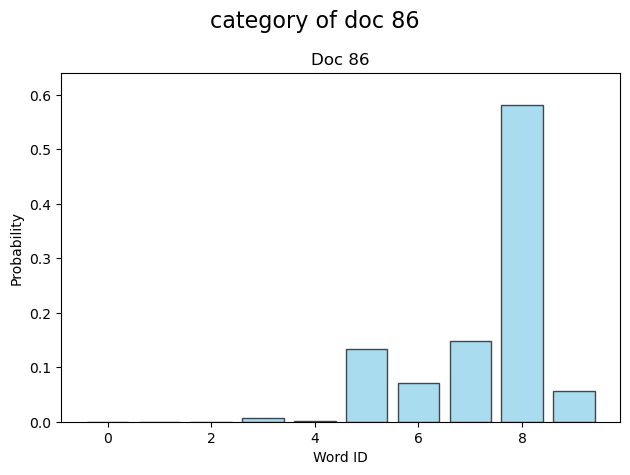

Doc 87 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.7567749e-02 1.1754944e-38
 1.3341323e-03 6.3281439e-02 5.3054295e-02 9.9999988e-01 1.0000000e+00]
Doc 87 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.7567749e-02 1.1078237e-38
 1.2573292e-03 5.9558902e-02 4.6773519e-02 8.3484244e-01 9.9520989e-08]


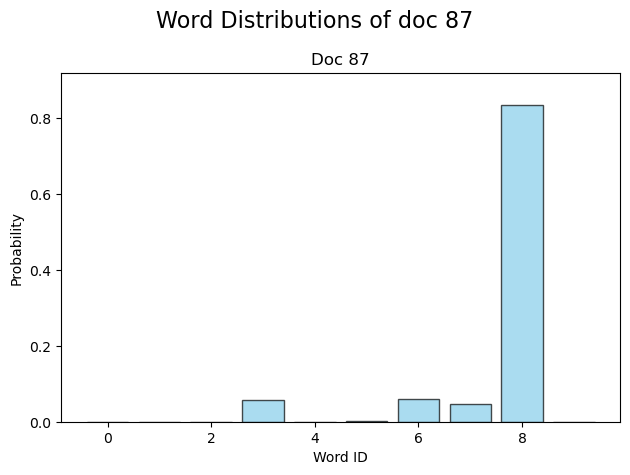

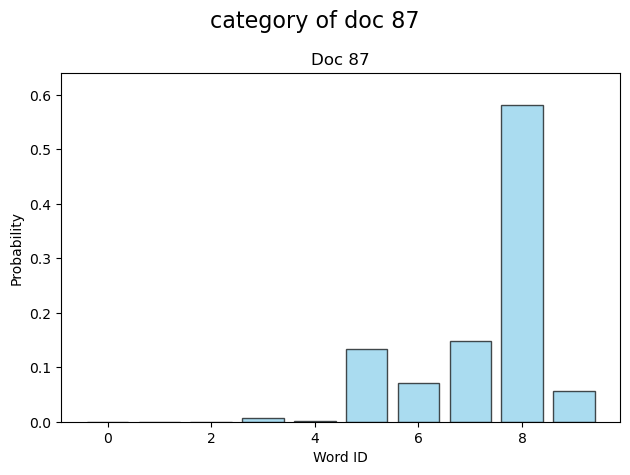

Doc 88 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 1.4313385e-02 1.1754944e-38
 2.5395967e-02 9.6169971e-02 3.8061559e-02 9.9999988e-01 1.0000000e+00]
Doc 88 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 1.4313385e-02 1.1586690e-38
 2.5032464e-02 9.2386082e-02 3.3047635e-02 8.3522034e-01 9.9566037e-08]


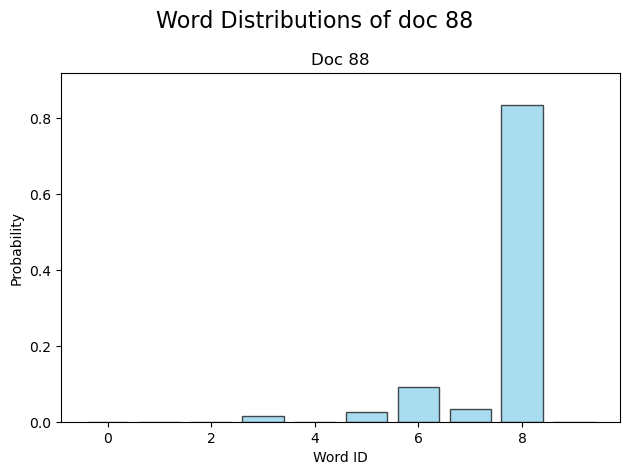

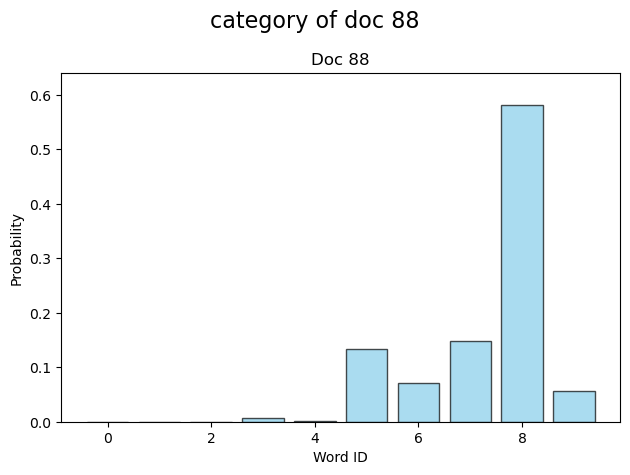

Doc 89 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.3841766e-02 1.1754944e-38
 3.5267603e-04 4.1031405e-02 6.3621186e-02 9.9999988e-01 1.0000000e+00]
Doc 89 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.3841766e-02 1.1122036e-38
 3.3368732e-04 3.8808510e-02 5.7705436e-02 8.4931052e-01 1.0124572e-07]


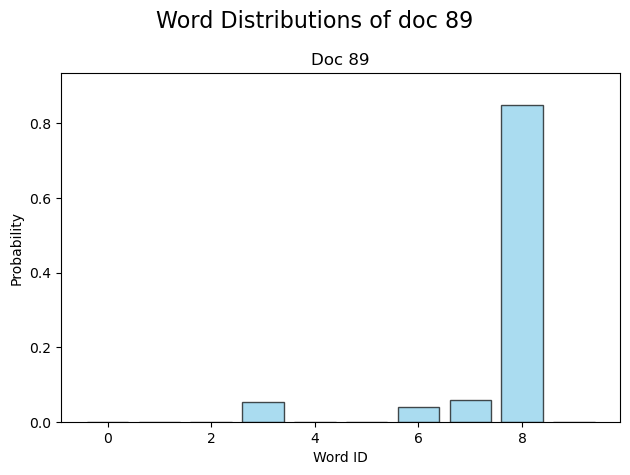

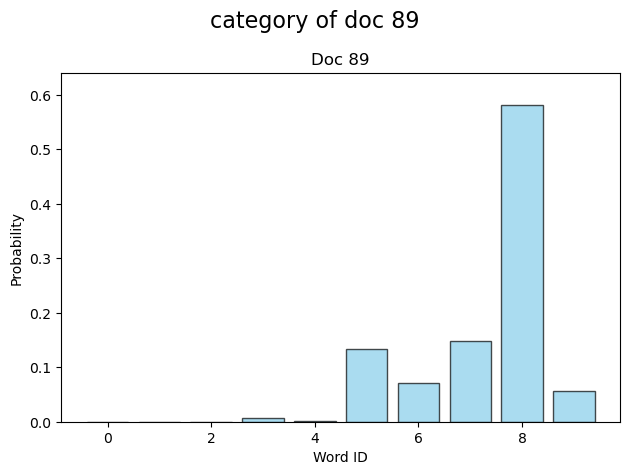

Doc 90 beta: [1.1754944e-38 1.1754944e-38 1.3815885e-02 6.0977489e-02 8.4131531e-04
 1.1754944e-38 8.3669849e-02 5.3515859e-02 9.9999988e-01 1.0000000e+00]
Doc 90 weights: [1.1754944e-38 1.1754944e-38 1.3815885e-02 6.0135029e-02 7.7909930e-04
 1.0876498e-38 7.7417202e-02 4.5373574e-02 8.0247915e-01 9.5662983e-08]


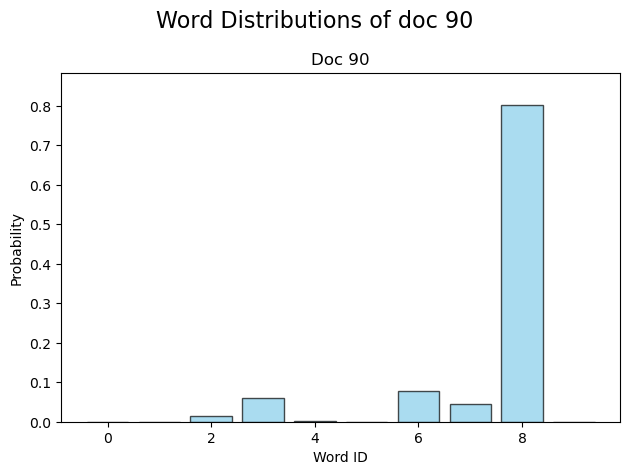

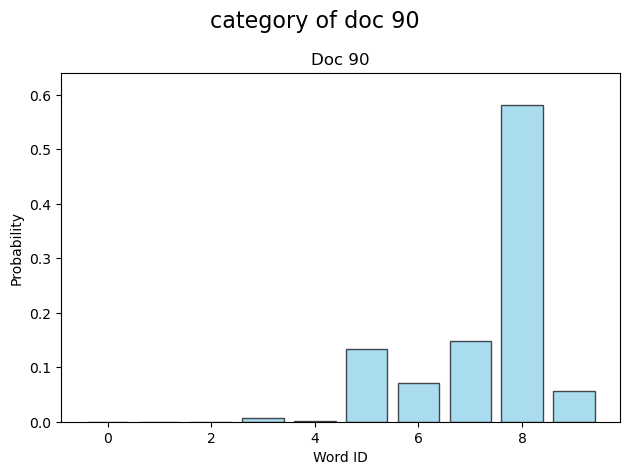

Doc 91 beta: [1.1754944e-38 1.1754944e-38 9.0970716e-04 4.1678604e-02 1.1754944e-38
 4.0464690e-03 6.7760631e-02 3.1885929e-02 9.9999988e-01 1.0000000e+00]
Doc 91 weights: [1.1754944e-38 1.1754944e-38 9.0970716e-04 4.1640688e-02 1.1254767e-38
 3.8742903e-03 6.4614870e-02 2.8345332e-02 8.6061502e-01 1.0259332e-07]


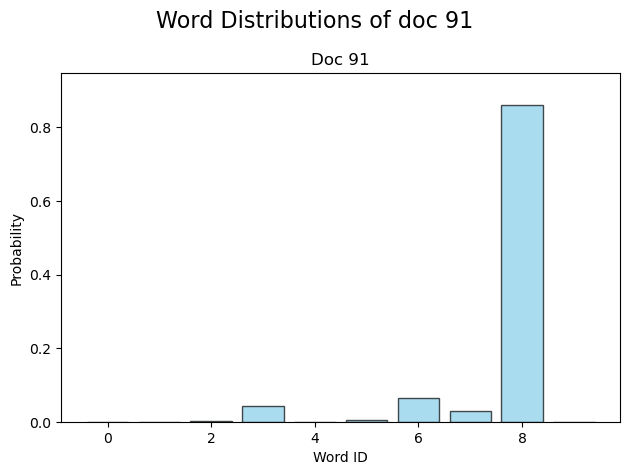

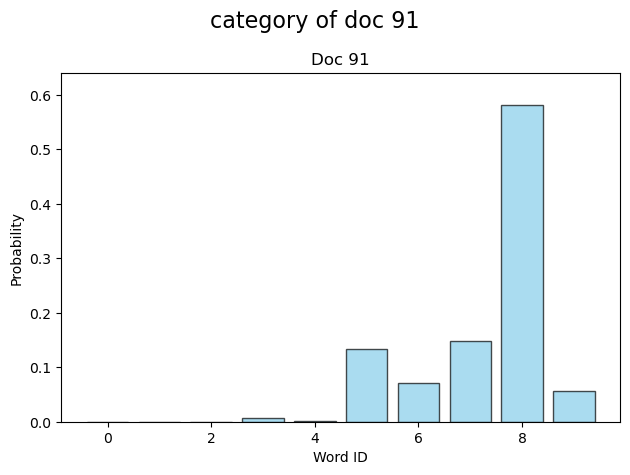

Doc 92 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 2.5370957e-02 1.1754944e-38
 5.6108129e-05 4.3238483e-02 5.3219553e-02 9.9999988e-01 1.0000000e+00]
Doc 92 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 2.5370957e-02 1.1456709e-38
 5.4684613e-05 4.2139117e-02 4.9623787e-02 8.8281137e-01 1.0523933e-07]


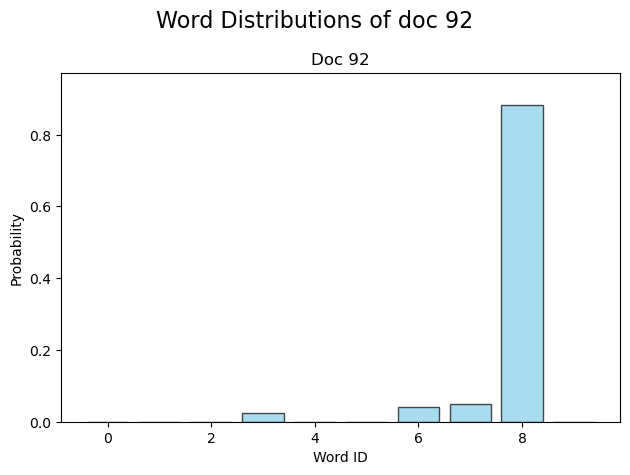

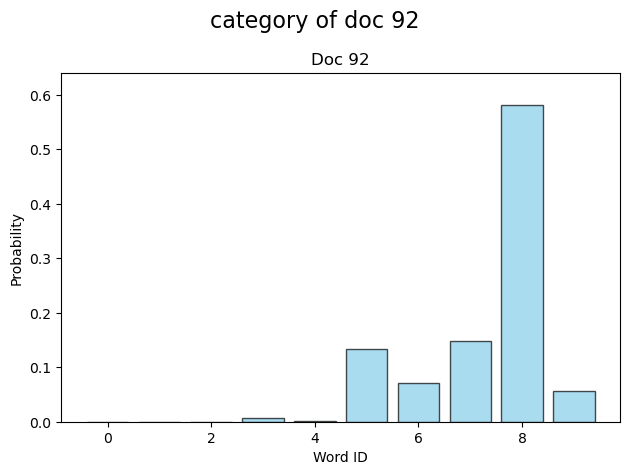

Doc 93 beta: [1.1754944e-38 1.1754944e-38 6.0578494e-04 2.3281677e-02 6.1509423e-03
 3.3565991e-02 4.1978393e-02 4.5474481e-02 9.9999988e-01 1.0000000e+00]
Doc 93 weights: [1.1754944e-38 1.1754944e-38 6.0578494e-04 2.3267573e-02 6.0040988e-03
 3.2563124e-02 3.9357238e-02 4.0845279e-02 8.5735679e-01 1.0220491e-07]


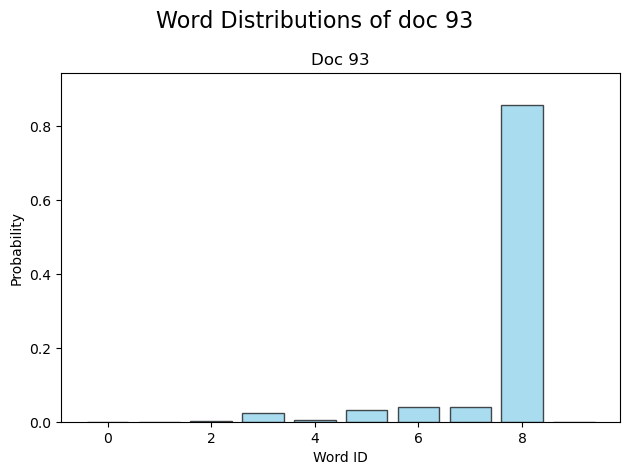

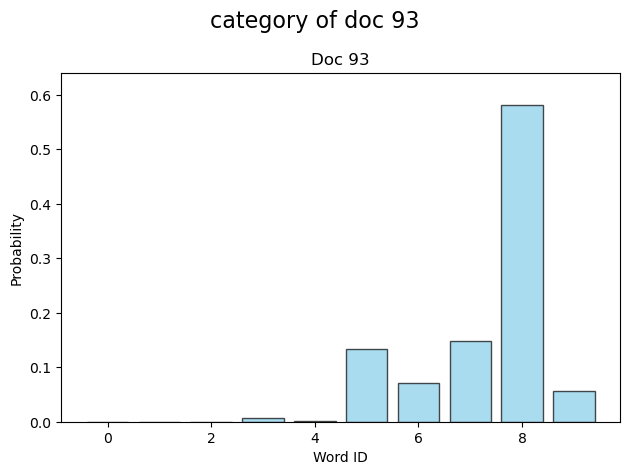

Doc 94 beta: [1.17549435e-38 1.17549435e-38 1.17549435e-38 1.59098990e-02
 1.17549435e-38 2.76785940e-02 7.65514448e-02 1.06617615e-01
 9.99999881e-01 1.00000000e+00]
Doc 94 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 1.5909899e-02 1.1567923e-38
 2.7238229e-02 7.3248394e-02 9.4207689e-02 7.8939563e-01 9.4103306e-08]


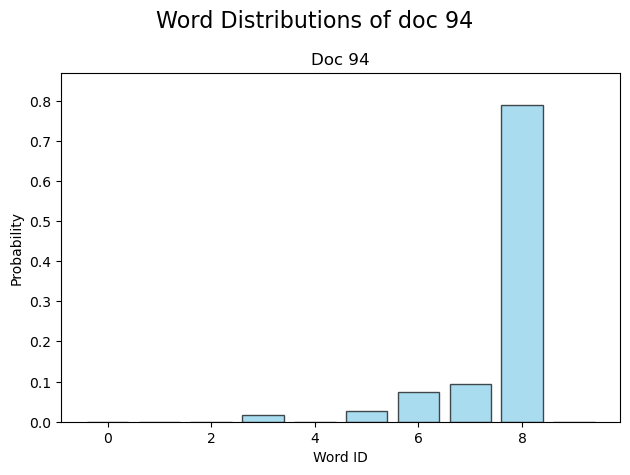

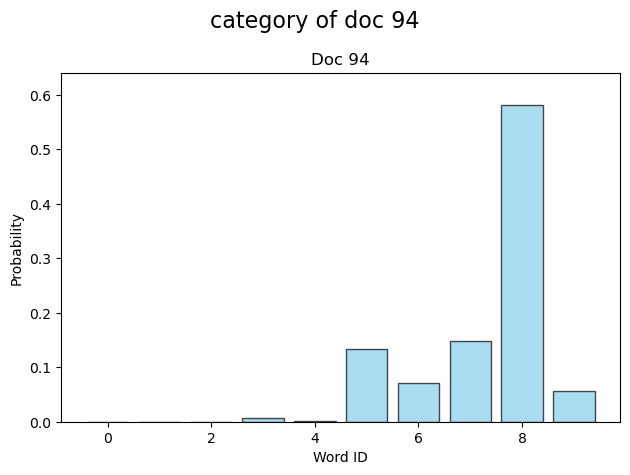

Doc 95 beta: [1.1754944e-38 1.1754944e-38 7.0703164e-04 6.0859058e-02 2.4404912e-03
 2.1018595e-02 9.7053438e-02 7.6682858e-02 9.9999988e-01 1.0000000e+00]
Doc 95 weights: [1.1754944e-38 1.1754944e-38 7.0703164e-04 6.0816027e-02 2.2903448e-03
 1.9677326e-02 8.8950373e-02 6.3459583e-02 7.6409918e-01 9.1087735e-08]


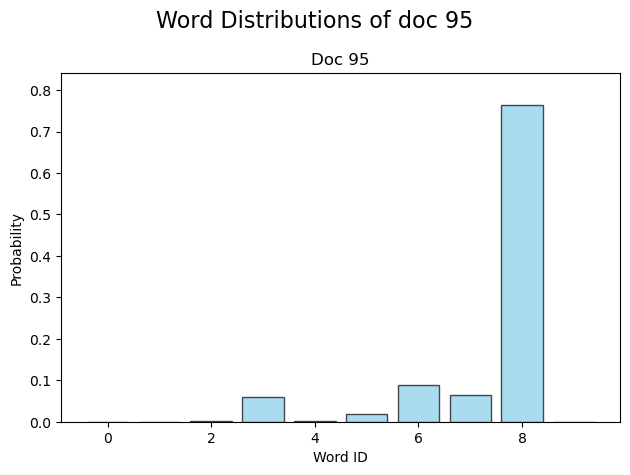

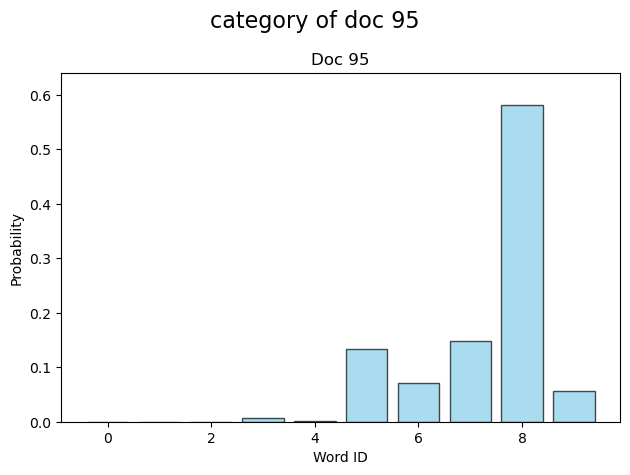

Doc 96 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.8377925e-02 5.7815755e-04
 9.3062269e-03 5.5401601e-02 5.7965849e-02 9.9999988e-01 1.0000000e+00]
Doc 96 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 5.8377925e-02 5.4440589e-04
 8.7578818e-03 5.1652007e-02 5.1048655e-02 8.2961893e-01 9.8898298e-08]


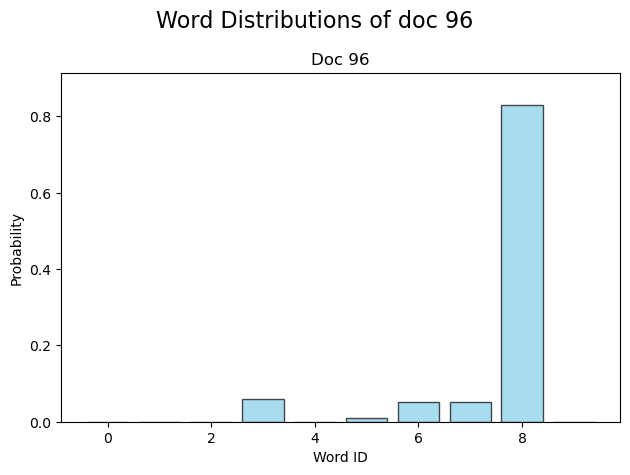

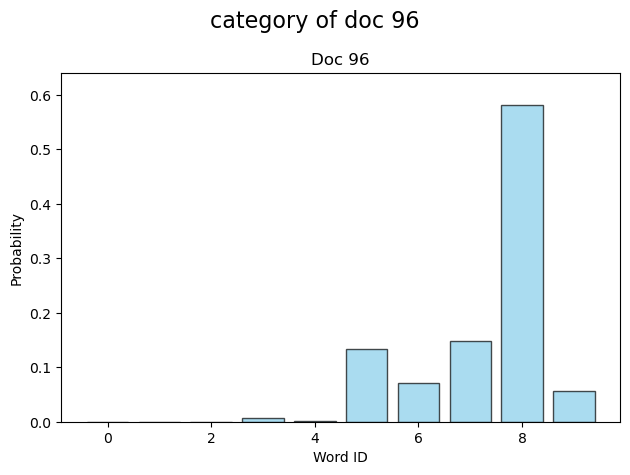

Doc 97 beta: [1.1754944e-38 1.1754944e-38 1.6886096e-04 3.7973657e-02 1.1754944e-38
 8.8528758e-03 4.6155728e-02 9.6488096e-02 9.9999988e-01 1.0000000e+00]
Doc 97 weights: [1.1754944e-38 1.1754944e-38 1.6886096e-04 3.7967246e-02 1.1306657e-38
 8.5152620e-03 4.4002499e-02 8.7741077e-02 8.2160491e-01 9.7942952e-08]


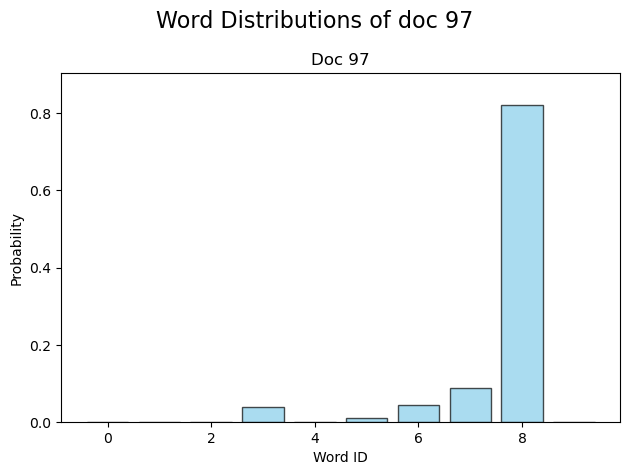

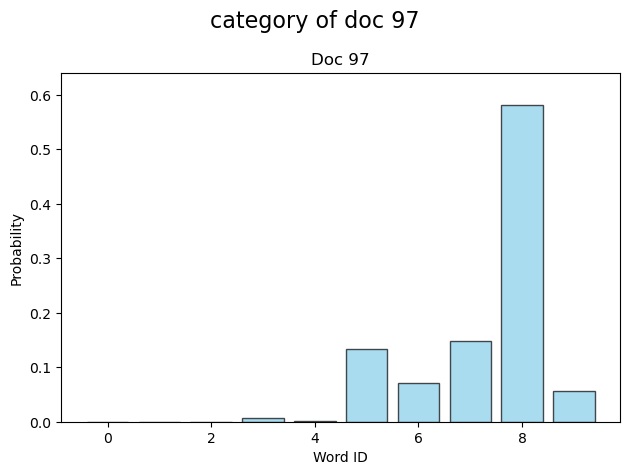

Doc 98 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 6.1815891e-02 5.0766803e-03
 4.0678089e-03 9.2112385e-02 4.1471645e-02 9.9999988e-01 1.0000000e+00]
Doc 98 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 6.1815891e-02 4.7628605e-03
 3.7969791e-03 8.5629903e-02 3.5001833e-02 8.0899233e-01 9.6439415e-08]


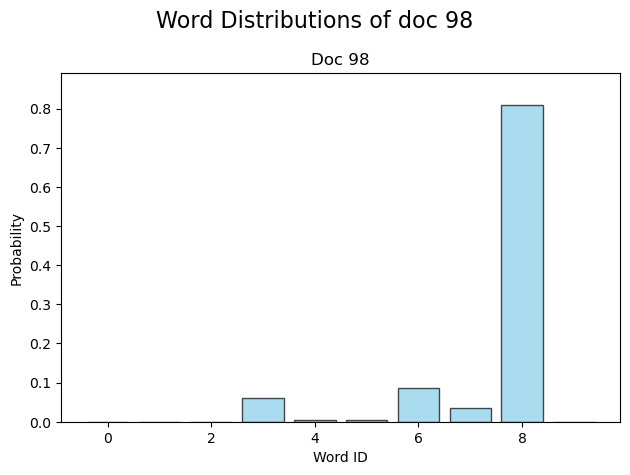

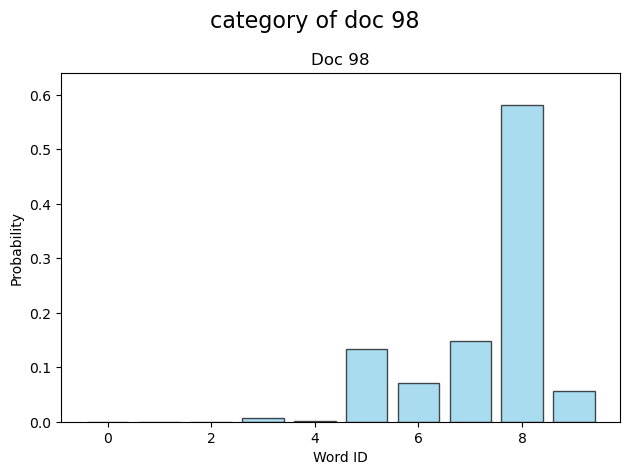

Doc 99 beta: [1.1754944e-38 1.1754944e-38 1.0115560e-02 6.2014833e-02 1.1754944e-38
 2.2242578e-02 2.2436924e-02 9.0407692e-02 9.9999988e-01 1.0000000e+00]
Doc 99 weights: [1.1754944e-38 1.1754944e-38 1.0115560e-02 6.1387517e-02 1.0914429e-38
 2.0652166e-02 2.0369245e-02 8.0234617e-02 8.0724084e-01 9.6230622e-08]


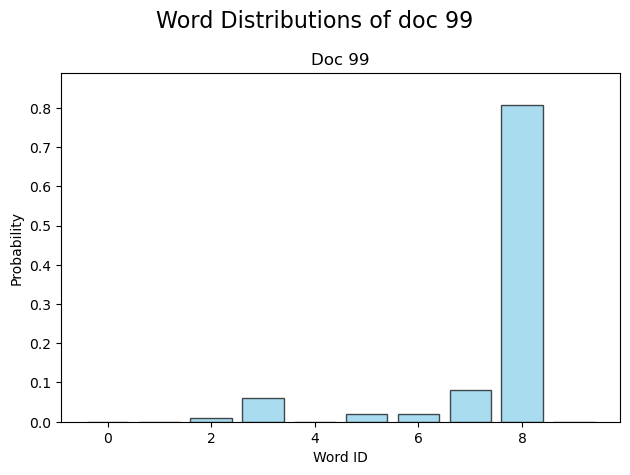

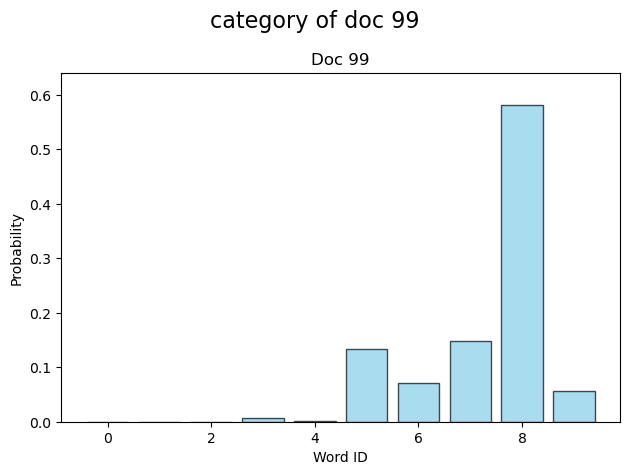

Doc 100 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 6.2004950e-02 1.2683482e-03
 3.3931732e-01 1.1754944e-38 1.5428928e-01 9.8385459e-01 1.0000000e+00]
Doc 100 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 6.2004950e-02 1.1897044e-03
 3.1787428e-01 7.2754996e-39 9.5494427e-02 5.1498556e-01 8.4510986e-03]


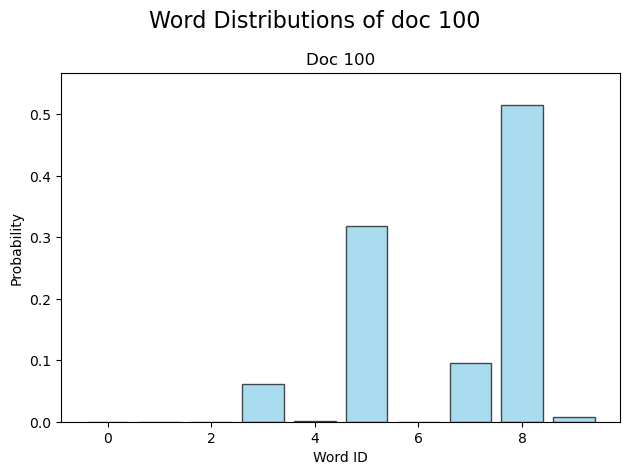

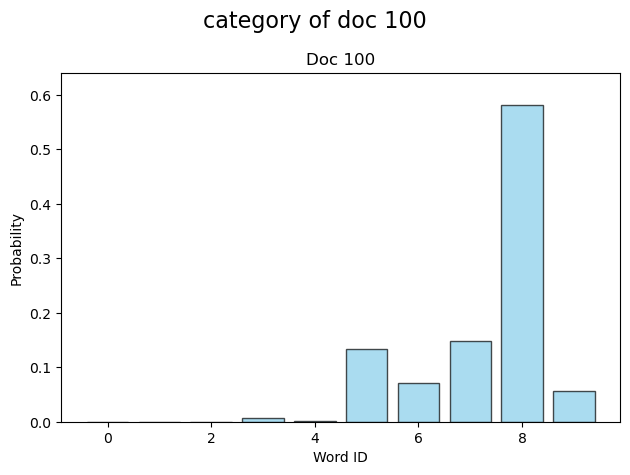

Doc 101 beta: [1.6514434e-02 1.1754944e-38 9.6033644e-03 7.8957193e-02 3.9961687e-03
 2.5707334e-01 1.4855864e-03 1.7799887e-01 9.9898881e-01 1.0000000e+00]
Doc 101 weights: [1.65144335e-02 1.15608174e-38 9.44477040e-03 7.69075304e-02
 3.58509598e-03 2.29707420e-01 9.86192841e-04 1.17987365e-01
 5.44316173e-01 5.50965720e-04]


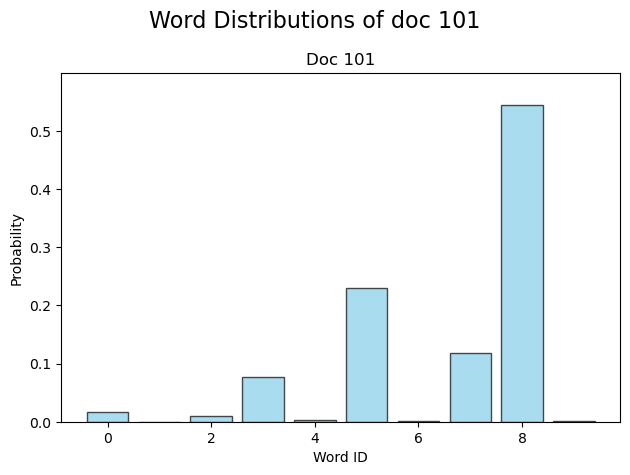

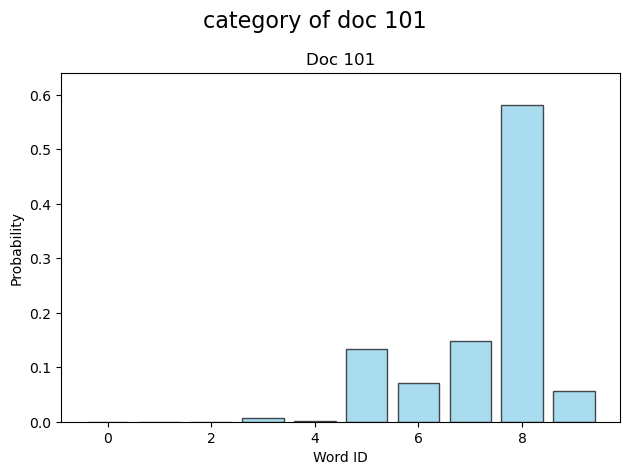

Doc 102 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 3.2355335e-02 1.3706830e-03
 2.5946411e-01 1.9567059e-03 1.7807733e-01 9.9999988e-01 1.0000000e+00]
Doc 102 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 3.2355335e-02 1.3263341e-03
 2.5072494e-01 1.4002059e-03 1.2718160e-01 5.8701152e-01 6.9977233e-08]


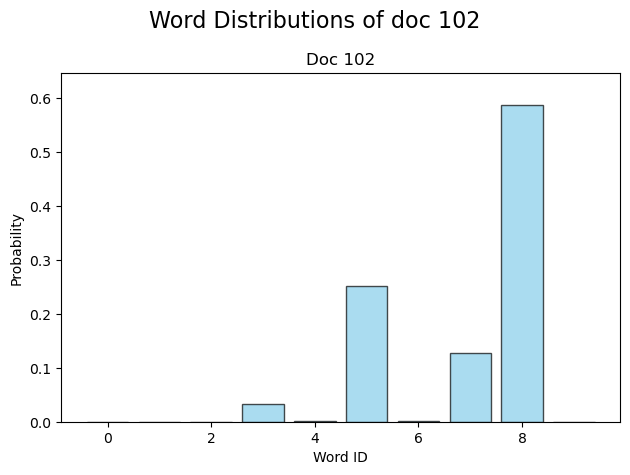

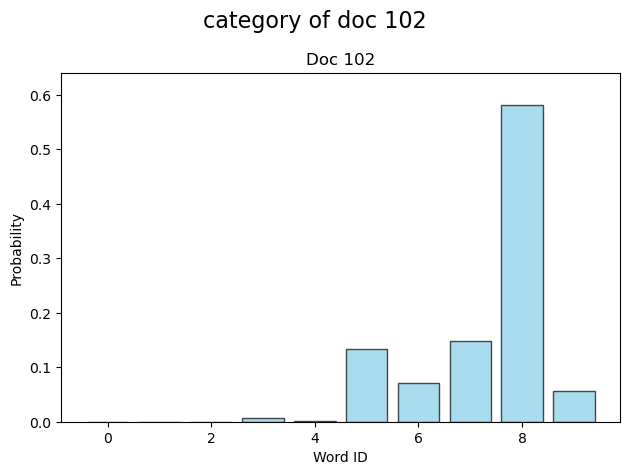

Doc 103 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 9.3233697e-03 9.4143320e-03
 3.0869067e-01 1.8336298e-02 1.6956535e-01 9.9870062e-01 1.0000000e+00]
Doc 103 weights: [1.17549435e-38 1.17549435e-38 1.17549435e-38 9.32336971e-03
 9.32655856e-03 3.02933633e-01 1.24396468e-02 1.12926595e-01
 5.52331626e-01 7.18623109e-04]


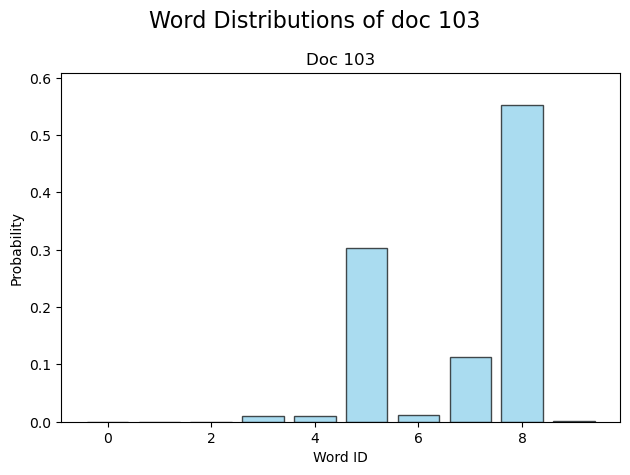

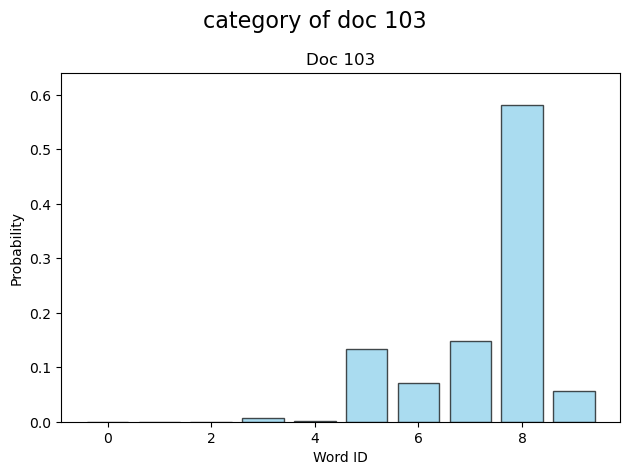

Doc 104 beta: [1.1754944e-38 1.1754944e-38 4.2192987e-04 3.1693034e-02 3.1392109e-03
 2.2356249e-01 3.0460769e-02 1.1176569e-01 9.9999988e-01 1.0000000e+00]
Doc 104 weights: [1.1754944e-38 1.1754944e-38 4.2192987e-04 3.1679660e-02 3.0384371e-03
 2.1570650e-01 2.2819791e-02 8.1179187e-02 6.4515442e-01 7.6908407e-08]


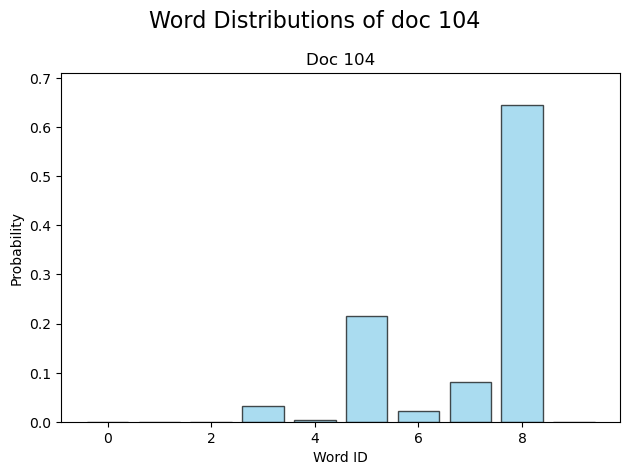

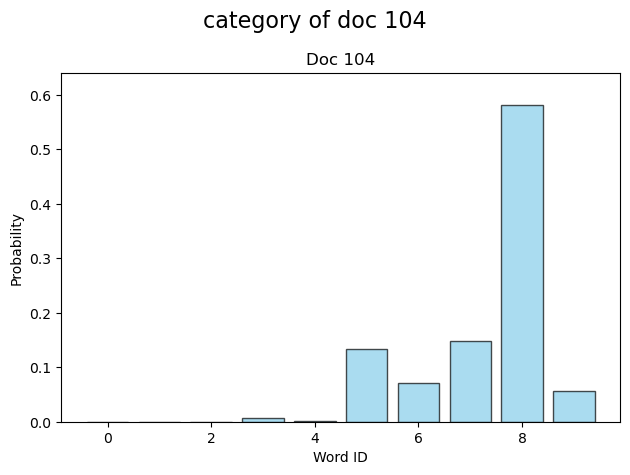

Doc 105 beta: [1.1754944e-38 1.1754944e-38 5.5207293e-03 2.6459854e-02 3.1912541e-03
 3.1341964e-01 1.1754944e-38 1.4920358e-01 9.9999988e-01 1.0000000e+00]
Doc 105 weights: [1.1754944e-38 1.1754944e-38 5.5207293e-03 2.6313778e-02 3.0896622e-03
 3.0247372e-01 7.7888513e-39 9.8862611e-02 5.6373942e-01 6.7202983e-08]


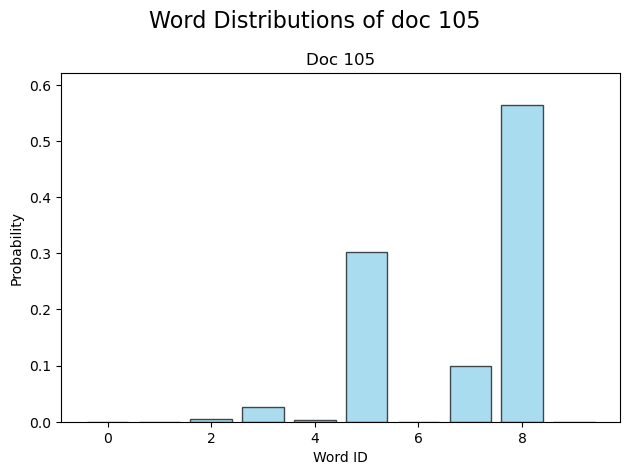

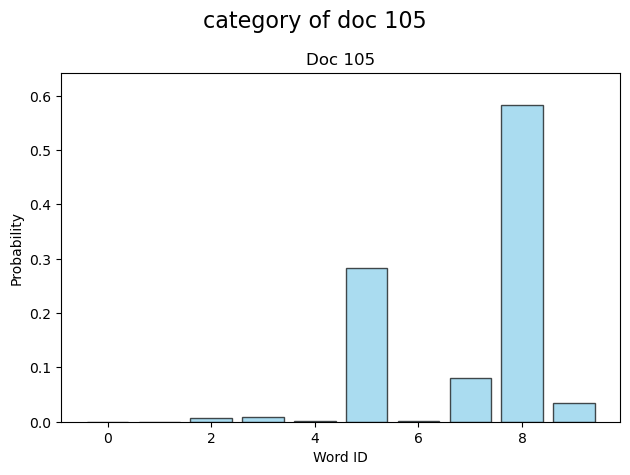

Doc 106 beta: [1.1754944e-38 1.1754944e-38 2.0207681e-03 8.0968710e-03 3.9881221e-03
 2.4258107e-01 1.1754944e-38 1.5247911e-01 9.9448091e-01 1.0000000e+00]
Doc 106 weights: [1.1754944e-38 1.1754944e-38 2.0207681e-03 8.0805086e-03 3.9478373e-03
 2.3917302e-01 8.7783319e-39 1.1386803e-01 6.2941676e-01 3.4930876e-03]


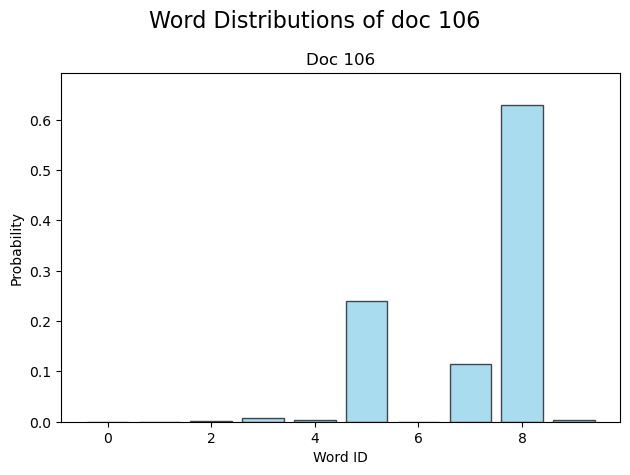

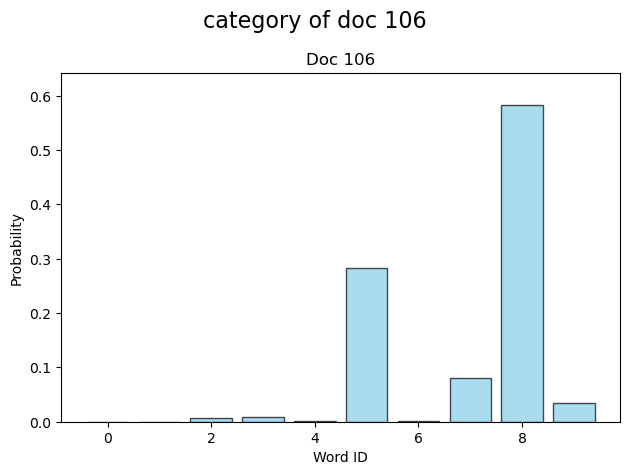

Doc 107 beta: [1.1754944e-38 1.1754944e-38 4.3534790e-03 3.2763317e-02 1.5718708e-02
 3.8306969e-01 6.0326275e-03 1.3970439e-01 9.9999988e-01 1.0000000e+00]
Doc 107 weights: [1.17549435e-38 1.17549435e-38 4.35347902e-03 3.26206833e-02
 1.51375225e-02 3.63107324e-01 3.52776633e-03 8.12036395e-02
 5.00049591e-01 5.96105636e-08]


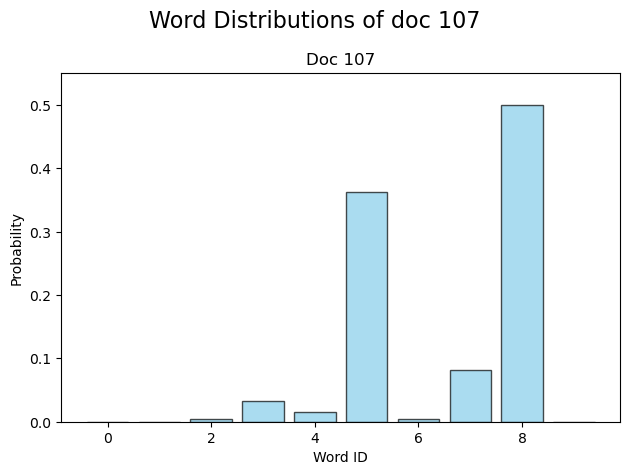

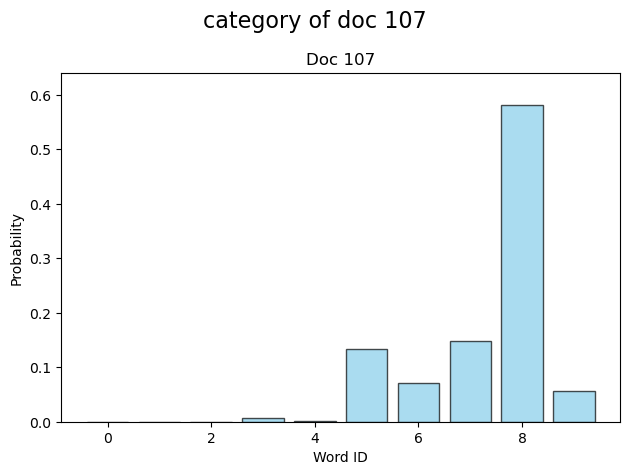

Doc 108 beta: [2.3142938e-03 1.1754944e-38 1.1754944e-38 4.5544803e-02 1.7948945e-03
 4.0069723e-01 5.8187065e-03 2.0154107e-01 9.9999988e-01 1.0000000e+00]
Doc 108 weights: [2.3142938e-03 1.1727739e-38 1.1727739e-38 4.5439400e-02 1.7091816e-03
 3.8087761e-01 3.3146816e-03 1.1414175e-01 4.5220307e-01 5.3906813e-08]


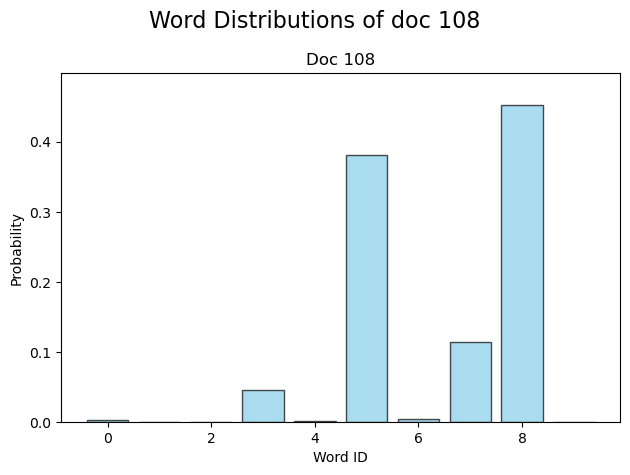

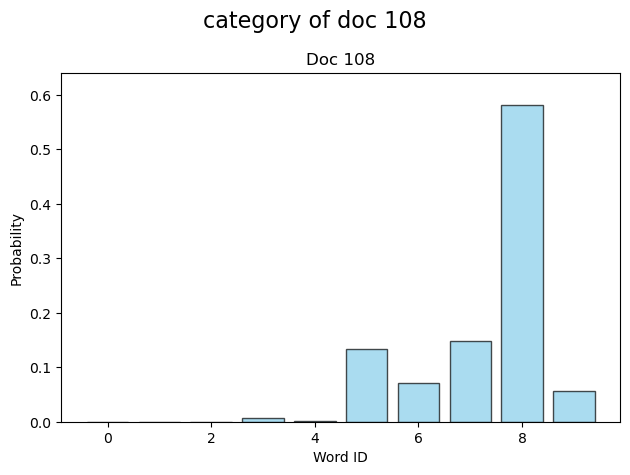

Doc 109 beta: [1.1754944e-38 1.1754944e-38 1.8792840e-03 5.3130977e-02 1.8609201e-03
 2.3343669e-01 1.1754944e-38 1.5924819e-01 9.8182690e-01 1.0000000e+00]
Doc 109 weights: [1.17549435e-38 1.17549435e-38 1.87928404e-03 5.30311279e-02
 1.75873621e-03 2.20208019e-01 8.50026808e-39 1.15155995e-01
 5.96918166e-01 1.10486401e-02]


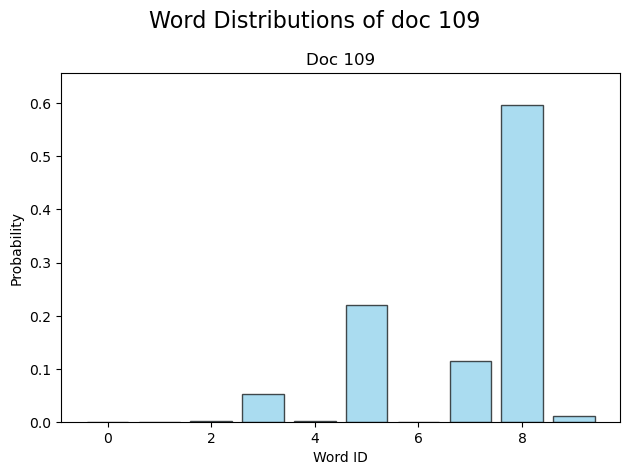

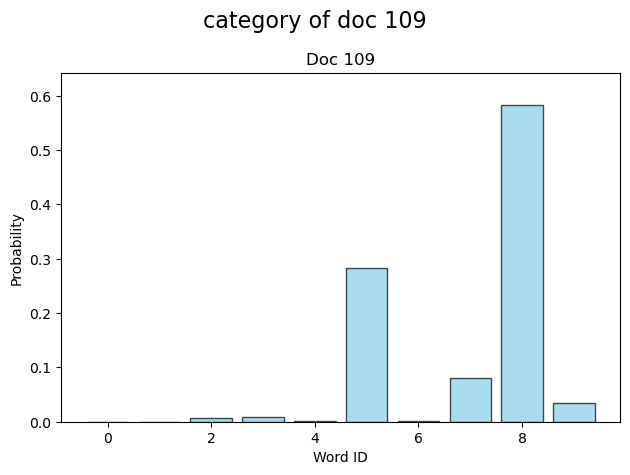

Doc 110 beta: [1.17549435e-38 1.17549435e-38 1.51023315e-02 1.30399540e-02
 1.31540047e-02 2.36852676e-01 1.17549435e-38 1.78292662e-01
 9.99999881e-01 1.00000000e+00]
Doc 110 weights: [1.17549435e-38 1.17549435e-38 1.51023315e-02 1.28430203e-02
 1.27864117e-02 2.27205247e-01 8.60535986e-39 1.30521461e-01
 6.01541519e-01 7.17093442e-08]


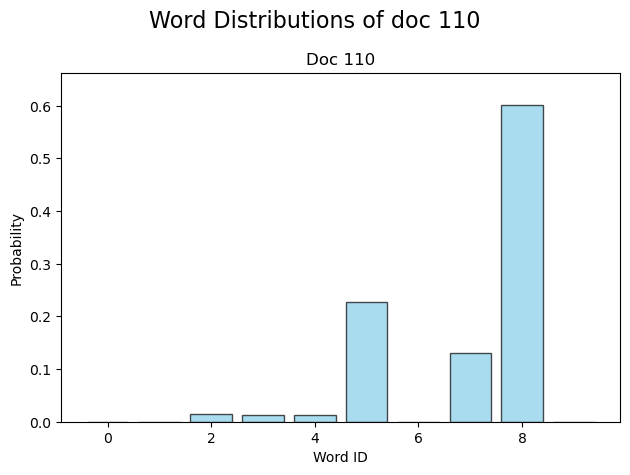

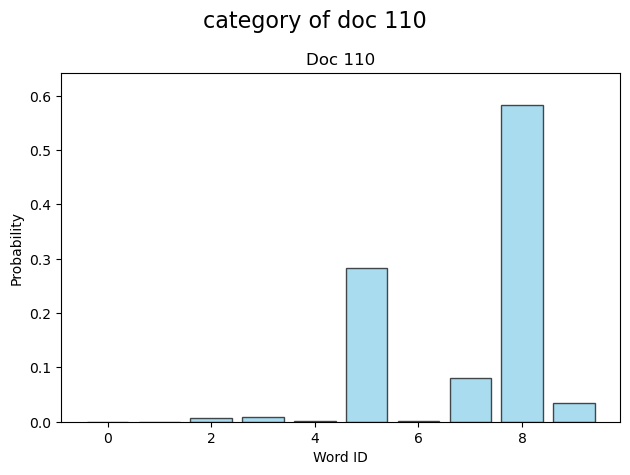

Doc 111 beta: [1.1754944e-38 1.1754944e-38 1.3395363e-03 7.9707131e-02 9.3000829e-03
 2.3159148e-01 4.3716915e-03 1.2957424e-01 9.9999988e-01 1.0000000e+00]
Doc 111 weights: [1.1754944e-38 1.1754944e-38 1.3395363e-03 7.9600357e-02 8.5473349e-03
 2.1086697e-01 3.0586352e-03 9.0259731e-02 6.0632724e-01 7.2279846e-08]


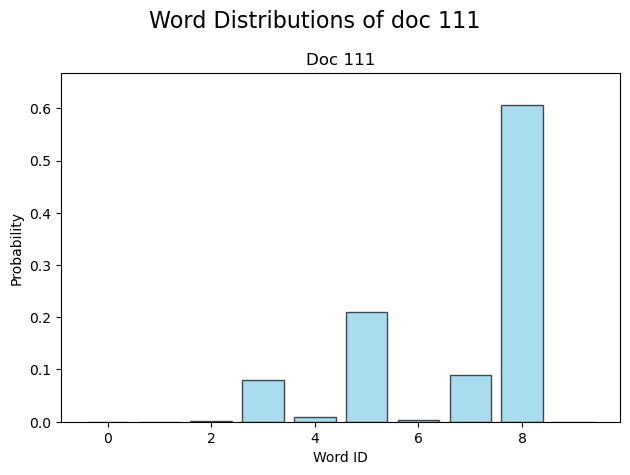

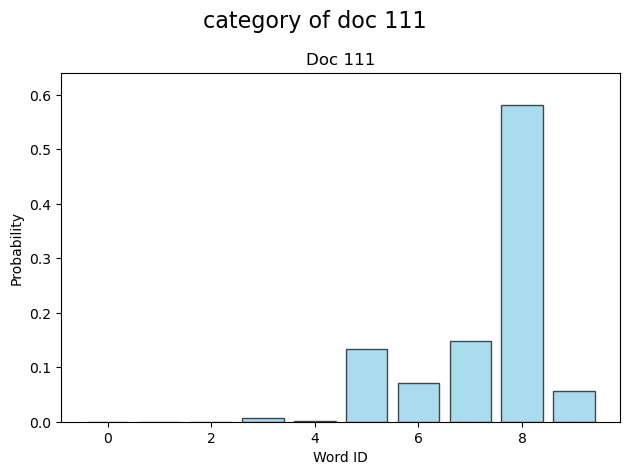

Doc 112 beta: [1.1754944e-38 1.1754944e-38 4.8336764e-03 8.7635415e-03 6.1182812e-04
 2.9592043e-01 1.1754944e-38 2.0652549e-01 9.9505746e-01 1.0000000e+00]
Doc 112 weights: [1.1754944e-38 1.1754944e-38 4.8336764e-03 8.7211812e-03 6.0353486e-04
 2.9173067e-01 8.1592341e-39 1.4335160e-01 5.4803717e-01 2.7221479e-03]


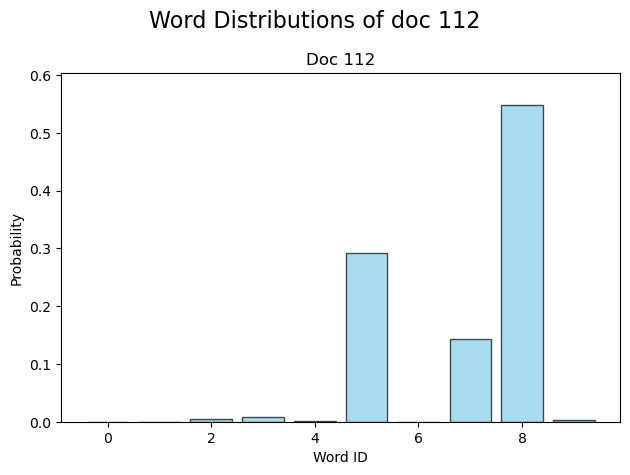

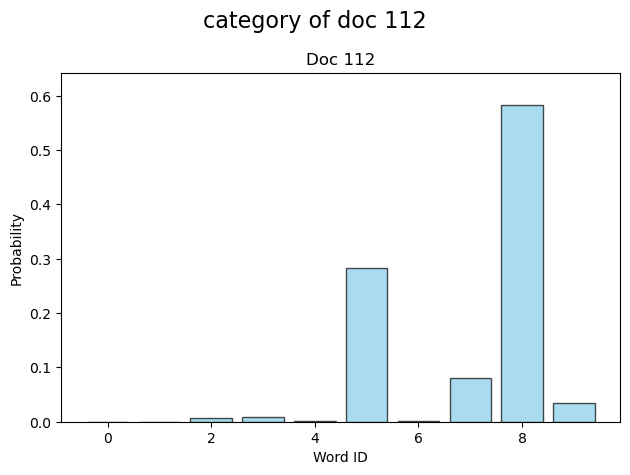

Doc 113 beta: [2.8876171e-03 1.1754944e-38 4.2646732e-03 2.8148631e-02 3.9178017e-03
 2.9201767e-01 1.1754944e-38 1.3939925e-01 9.9999988e-01 1.0000000e+00]
Doc 113 weights: [2.8876171e-03 1.1721000e-38 4.2523583e-03 2.7947651e-02 3.7803354e-03
 2.8066754e-01 7.9988218e-39 9.4856240e-02 5.8560824e-01 6.9809950e-08]


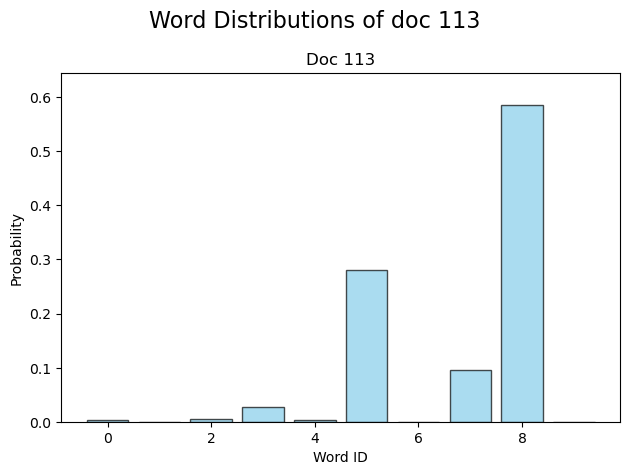

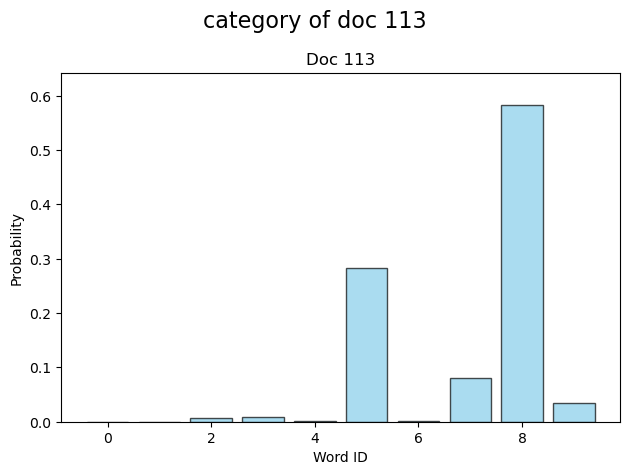

Doc 114 beta: [1.1754944e-38 1.1754944e-38 5.2913008e-03 1.0265341e-02 1.1754944e-38
 3.1362832e-01 2.3473829e-03 1.8576173e-01 9.9999988e-01 1.0000000e+00]
Doc 114 weights: [1.1754944e-38 1.1754944e-38 5.2913008e-03 1.0211024e-02 1.1572714e-38
 3.0876634e-01 1.5862001e-03 1.2523036e-01 5.4891467e-01 6.5435735e-08]


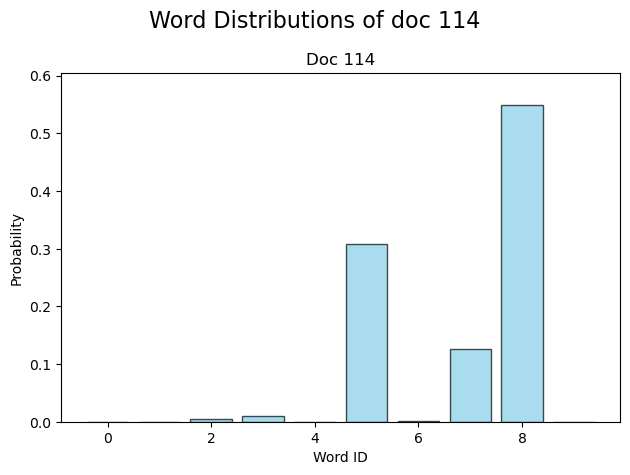

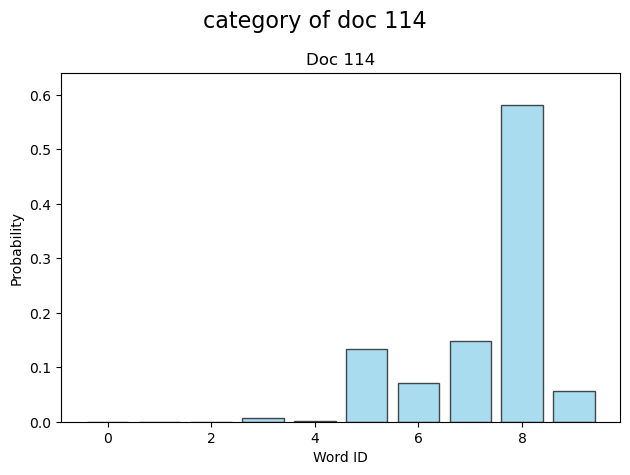

Doc 115 beta: [5.4555708e-03 1.1754944e-38 5.5631809e-03 4.9404602e-02 1.1249498e-02
 3.1788951e-01 1.7667688e-02 1.7865714e-01 9.9999988e-01 1.0000000e+00]
Doc 115 weights: [5.4555708e-03 1.1690814e-38 5.5328305e-03 4.8861723e-02 1.0576215e-02
 2.9550171e-01 1.1202586e-02 1.1128006e-01 5.1158923e-01 6.0986196e-08]


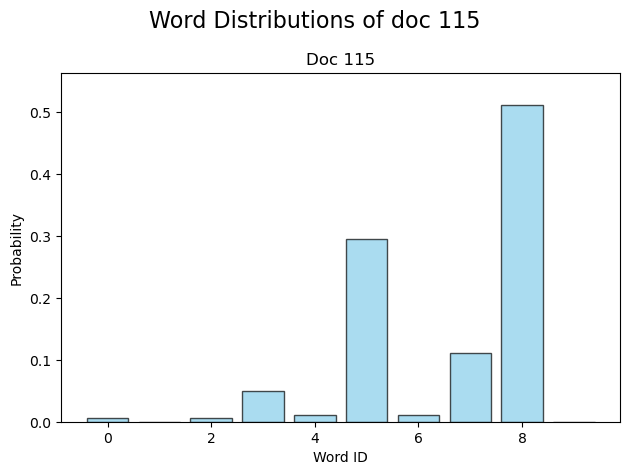

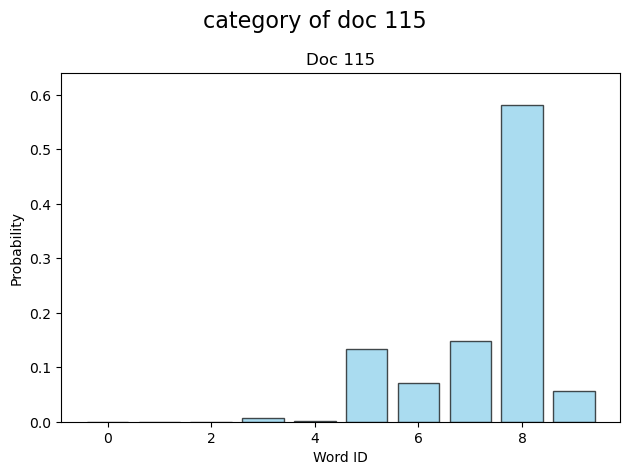

Doc 116 beta: [1.1754944e-38 1.1754944e-38 6.4755655e-03 2.0416977e-02 1.1311183e-02
 3.2069966e-01 1.1754944e-38 1.4300063e-01 9.9999988e-01 1.0000000e+00]
Doc 116 weights: [1.1754944e-38 1.1754944e-38 6.4755655e-03 2.0284764e-02 1.1008492e-02
 3.0858719e-01 7.6835465e-39 9.3471490e-02 5.6017238e-01 6.6777758e-08]


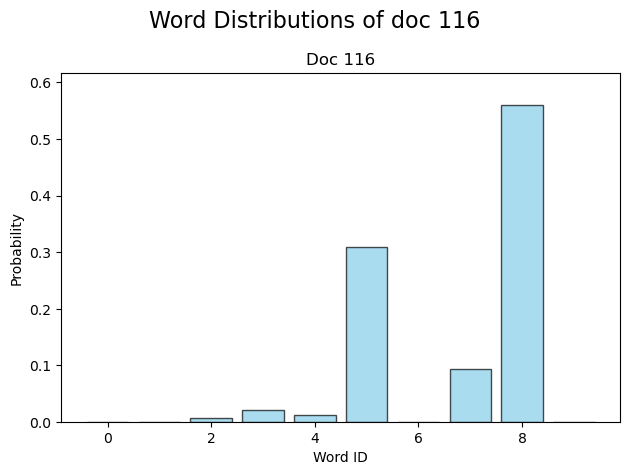

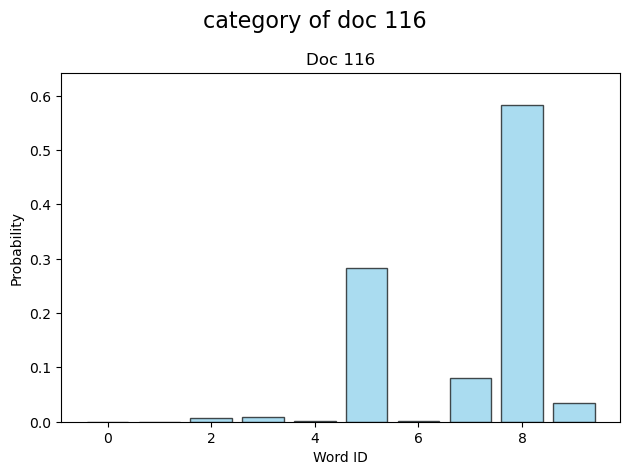

Doc 117 beta: [1.1754944e-38 1.1754944e-38 8.4378840e-03 3.3714008e-02 8.5973749e-03
 3.2258534e-01 7.3890146e-03 7.9564139e-02 9.5585692e-01 1.0000000e+00]
Doc 117 weights: [1.1754944e-38 1.1754944e-38 8.4378840e-03 3.3429533e-02 8.2374252e-03
 3.0642226e-01 4.7546308e-03 5.0819073e-02 5.6194752e-01 2.5951682e-02]


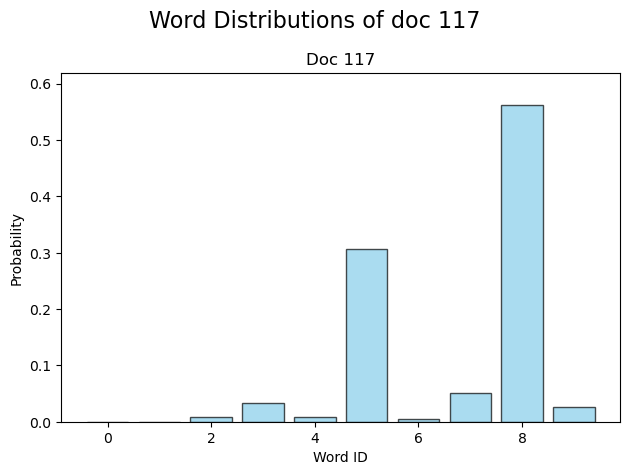

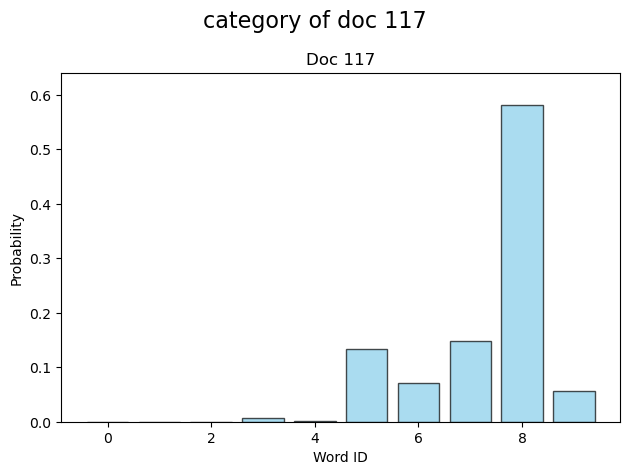

Doc 118 beta: [1.1754944e-38 1.1754944e-38 1.1754944e-38 9.1541313e-02 2.2054277e-03
 3.1388214e-01 1.1596920e-02 1.4408015e-01 9.9891484e-01 1.0000000e+00]
Doc 118 weights: [1.1754944e-38 1.1754944e-38 1.1754944e-38 9.1541313e-02 2.0035401e-03
 2.8452009e-01 7.2125313e-03 8.8569313e-02 5.2558225e-01 5.7096157e-04]


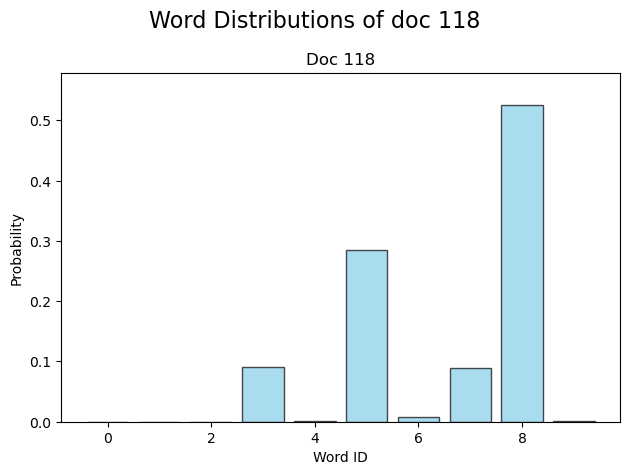

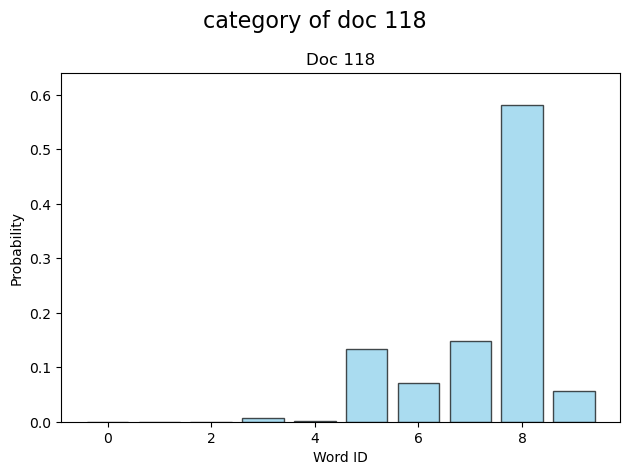

Doc 119 beta: [1.1754944e-38 1.1754944e-38 2.9874695e-03 2.4599263e-02 1.5755046e-02
 3.3733249e-01 1.1754944e-38 6.7576677e-02 9.6647614e-01 1.0000000e+00]
Doc 119 weights: [1.1754944e-38 1.1754944e-38 2.9874695e-03 2.4525775e-02 1.5321574e-02
 3.2288292e-01 7.4559532e-39 4.2862691e-02 5.7159299e-01 1.9826667e-02]


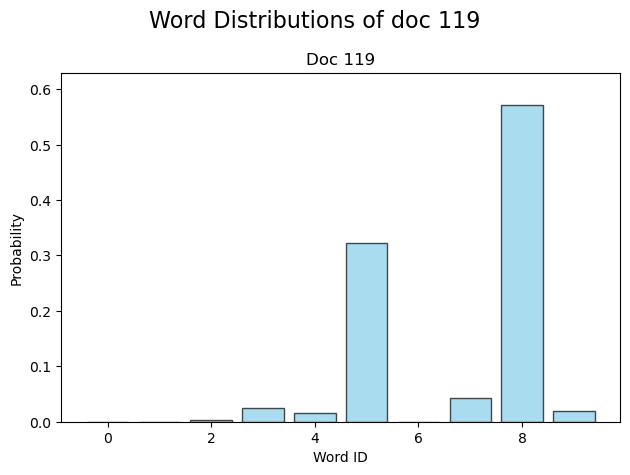

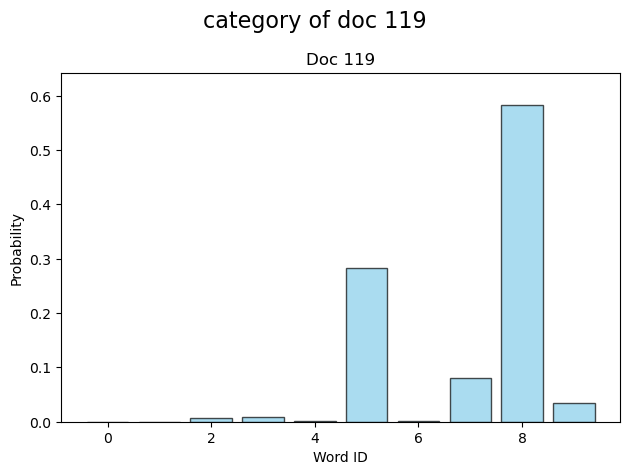

Make Prediction Gibbs Sampling (Iter 0):  50%|█████     | 1/2 [02:31<02:31, 151.15s/it]

Doc 0 beta: [1.1754944e-38 9.3483530e-02 4.6940055e-03 5.1279742e-01 7.4772787e-01
 1.1754944e-38 2.7972573e-01 2.9416862e-01 9.9999988e-01 1.0000000e+00]
Doc 0 weights: [1.1754944e-38 9.3483530e-02 4.2551933e-03 4.6267727e-01 3.2868925e-01
 1.3035621e-39 3.1020131e-02 2.3496624e-02 5.6378052e-02 6.7207884e-09]


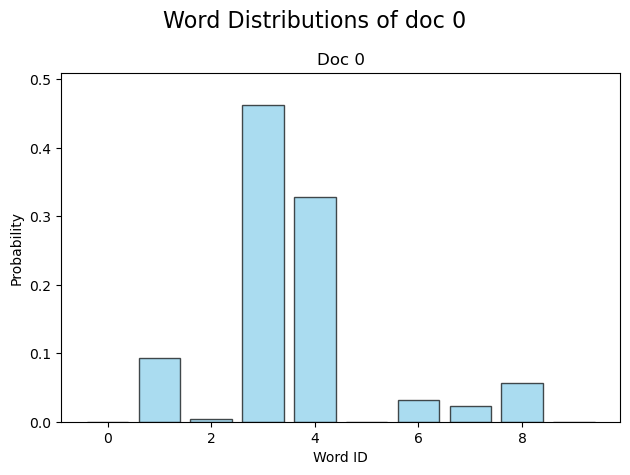

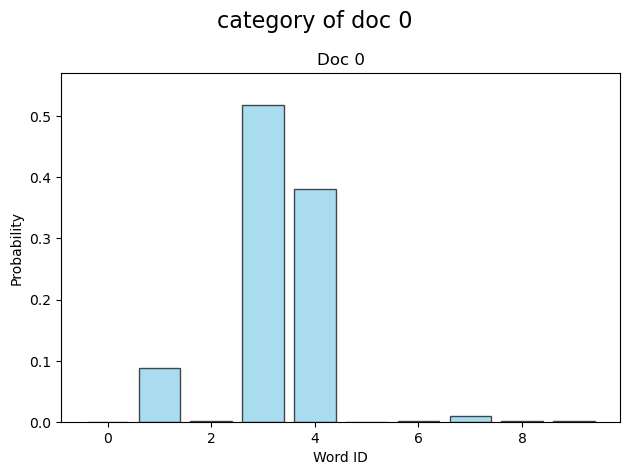

Doc 1 beta: [1.1754944e-38 8.5723631e-02 2.6376449e-02 4.8093638e-01 6.3828236e-01
 1.1754944e-38 2.2750197e-01 4.0419006e-01 9.9999988e-01 1.0000000e+00]
Doc 1 weights: [1.1754944e-38 8.5723631e-02 2.4115363e-02 4.2811084e-01 2.9491848e-01
 1.9646232e-39 3.8022794e-02 5.2184537e-02 7.6924361e-02 9.1700993e-09]


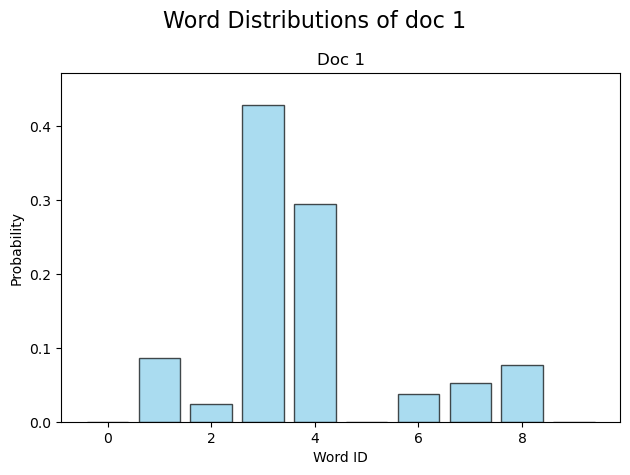

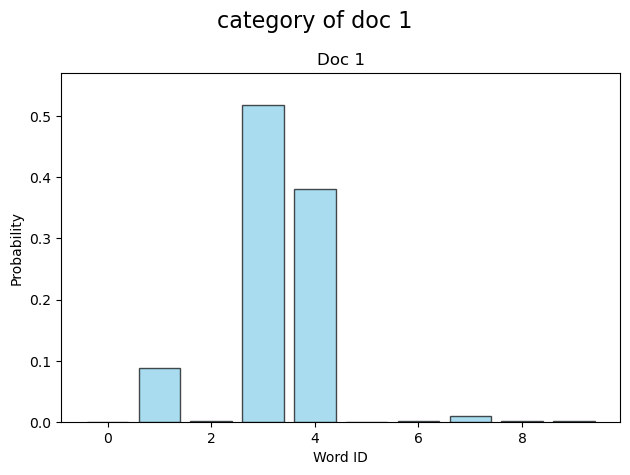

Doc 2 beta: [1.1754944e-38 7.7408493e-02 1.2126407e-02 4.4750053e-01 5.9360957e-01
 1.1754944e-38 2.1230182e-01 2.8990111e-01 9.9999988e-01 1.0000000e+00]
Doc 2 weights: [1.1754944e-38 7.7408493e-02 1.1187720e-02 4.0785369e-01 2.9891217e-01
 2.4055082e-39 4.3445010e-02 4.6730008e-02 1.1446290e-01 1.3645042e-08]


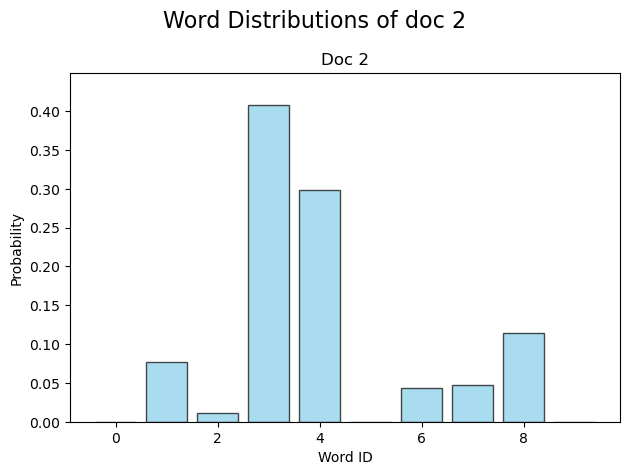

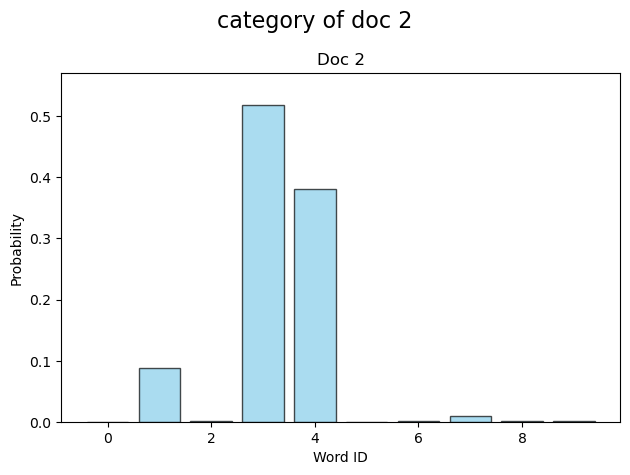

Doc 3 beta: [1.1754944e-38 9.3560986e-02 1.1087151e-02 3.8668814e-01 7.0328099e-01
 1.1754944e-38 1.5591584e-01 1.8260829e-01 9.9999988e-01 1.0000000e+00]
Doc 3 weights: [1.1754944e-38 9.3560986e-02 1.0049826e-02 3.4662303e-01 3.8664007e-01
 1.9175382e-39 2.5433937e-02 2.5143724e-02 1.1254838e-01 1.3416814e-08]


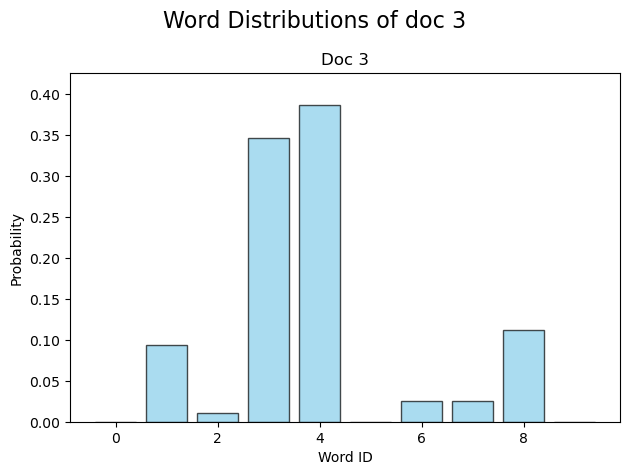

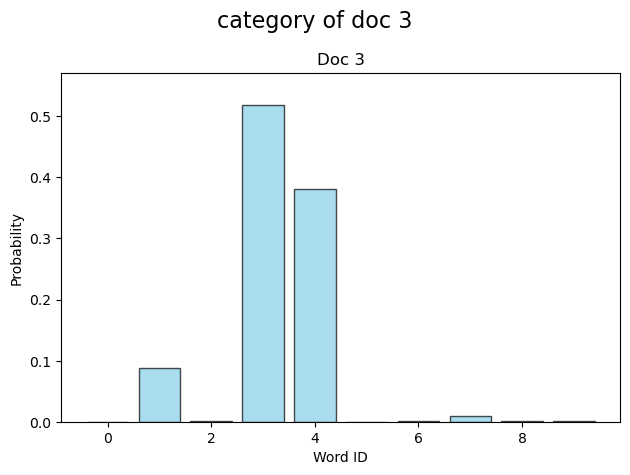

Doc 4 beta: [1.1754944e-38 9.0171479e-02 2.4570522e-03 4.8930633e-01 7.2627497e-01
 1.1754944e-38 2.4635182e-01 5.1959670e-01 8.8556194e-01 1.0000000e+00]
Doc 4 weights: [1.1754944e-38 9.0171479e-02 2.2354962e-03 4.4409102e-01 3.3662993e-01
 1.4913739e-39 3.1255174e-02 4.9682241e-02 4.0678013e-02 5.2566766e-03]


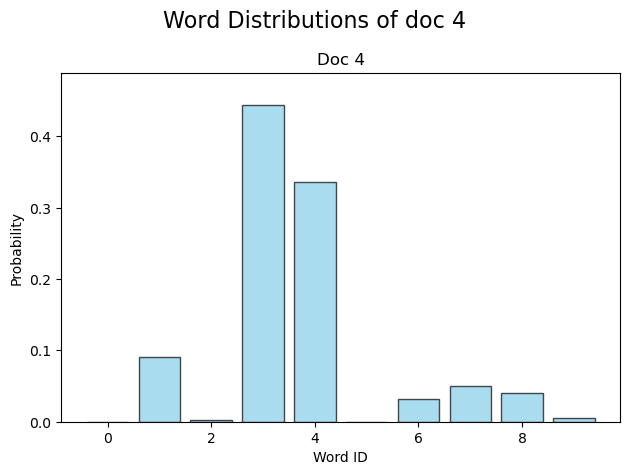

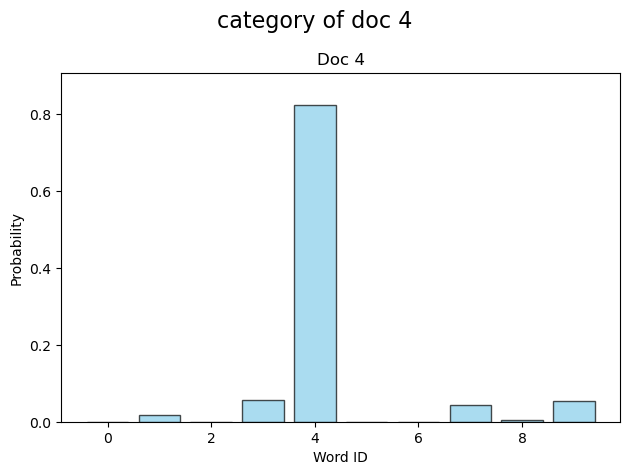

Doc 5 beta: [1.1754944e-38 3.2973938e-02 6.2736413e-03 5.2921802e-01 7.0235407e-01
 1.1754944e-38 2.1792975e-01 3.5296178e-01 8.3674097e-01 1.0000000e+00]
Doc 5 weights: [1.1754944e-38 3.2973938e-02 6.0667745e-03 5.0855696e-01 3.1774661e-01
 1.5828703e-39 2.9345486e-02 3.7170488e-02 5.7015318e-02 1.1124429e-02]


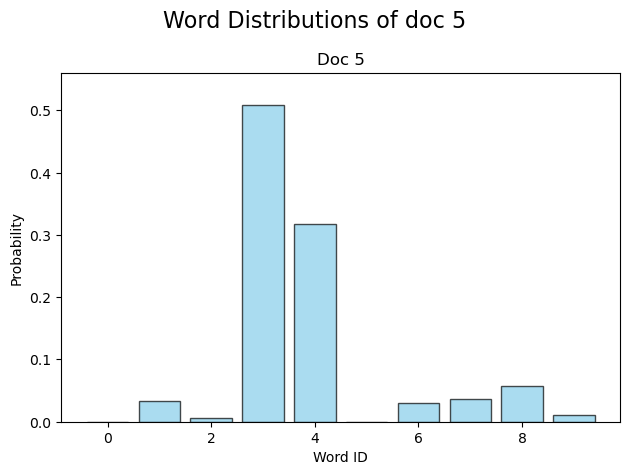

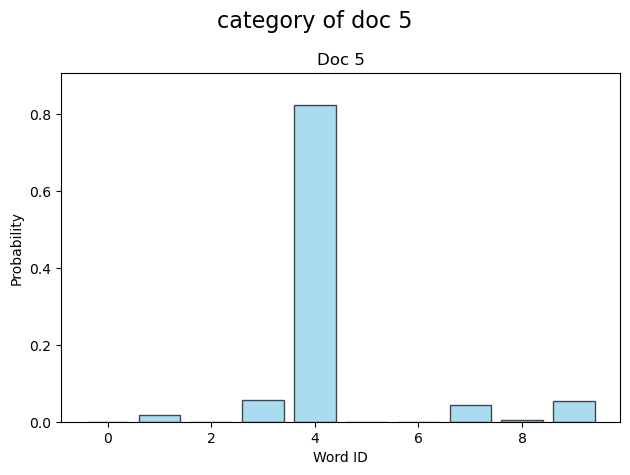

Doc 6 beta: [1.1754944e-38 9.6243858e-02 2.7046703e-02 4.8307455e-01 7.2877282e-01
 1.1754944e-38 4.6405384e-01 4.1828167e-01 9.6240878e-01 1.0000000e+00]
Doc 6 weights: [1.1754944e-38 9.6243858e-02 2.4443625e-02 4.2477348e-01 3.3125570e-01
 1.4491892e-39 5.7210106e-02 2.7637223e-02 3.6991153e-02 1.4448565e-03]


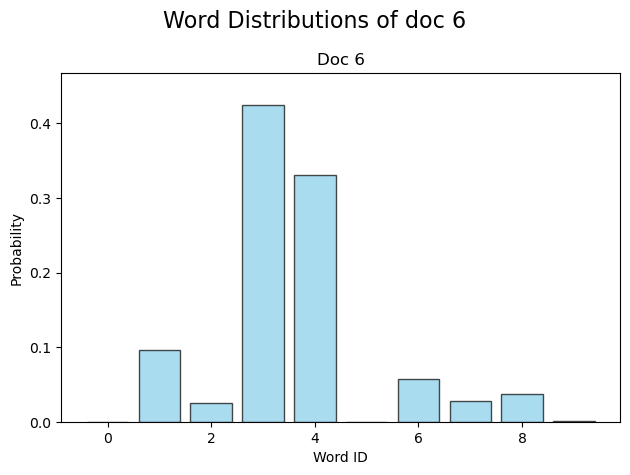

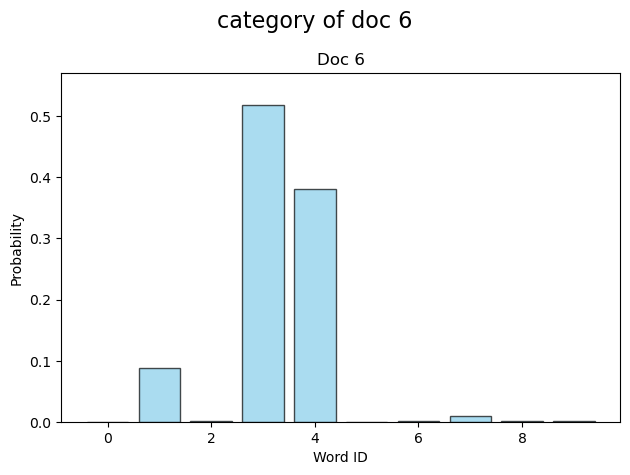

Doc 7 beta: [1.1754944e-38 5.0257307e-02 3.0022381e-02 4.7943452e-01 6.6150290e-01
 1.1754944e-38 2.2537196e-01 3.7549859e-01 9.9999988e-01 1.0000000e+00]
Doc 7 weights: [1.1754944e-38 5.0257307e-02 2.8513536e-02 4.4166905e-01 3.1723040e-01
 1.9081761e-39 3.6584564e-02 4.7217127e-02 7.8528017e-02 9.3612700e-09]


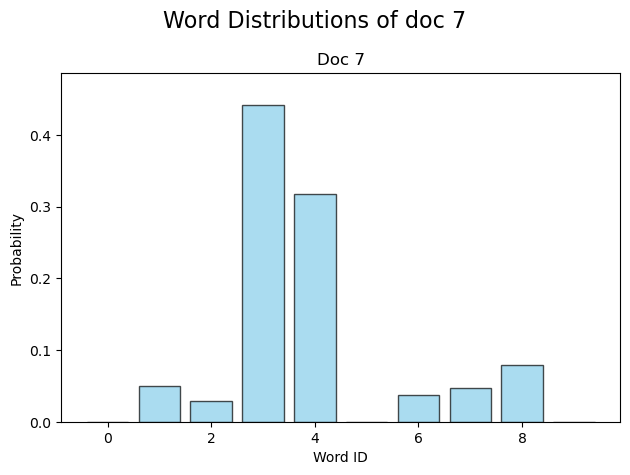

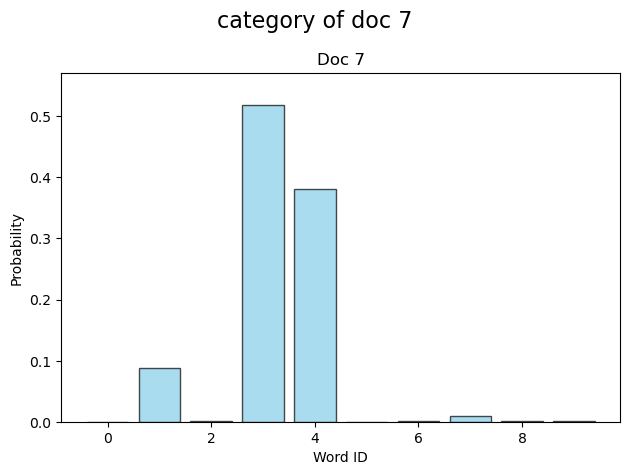

Doc 8 beta: [1.1754944e-38 9.8094024e-02 7.9513807e-03 4.8875439e-01 6.9039017e-01
 1.1754944e-38 6.1999345e-01 6.7219436e-01 9.9999988e-01 1.0000000e+00]
Doc 8 weights: [1.1754944e-38 9.8094024e-02 7.1713976e-03 4.3730545e-01 3.1580457e-01
 1.6647888e-39 8.7806299e-02 3.6176331e-02 1.7641926e-02 2.1030817e-09]


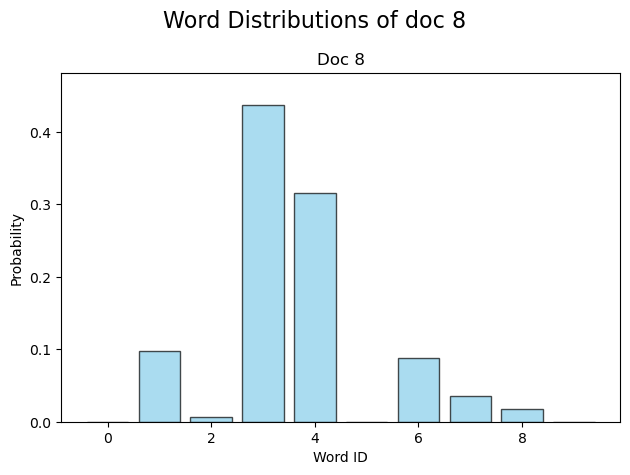

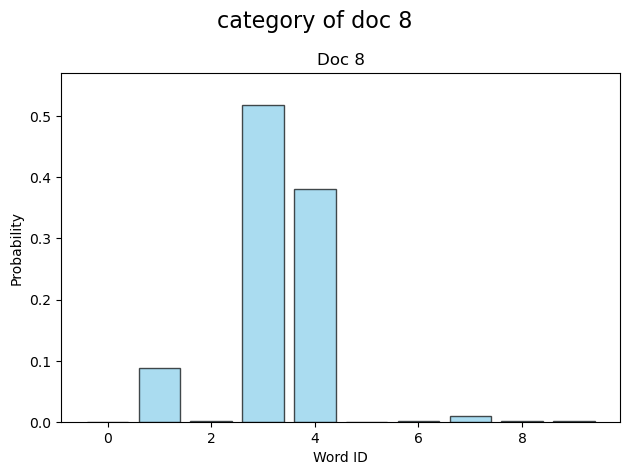

Doc 9 beta: [1.1754944e-38 7.5509027e-02 1.1754944e-38 4.5226955e-01 7.7973229e-01
 1.1754944e-38 1.0377040e-01 3.3246219e-01 9.9999988e-01 1.0000000e+00]
Doc 9 weights: [1.1754944e-38 7.5509027e-02 1.0867339e-38 4.1811913e-01 3.9483449e-01
 1.3111151e-39 1.1574277e-02 3.3233948e-02 6.6729136e-02 7.9547338e-09]


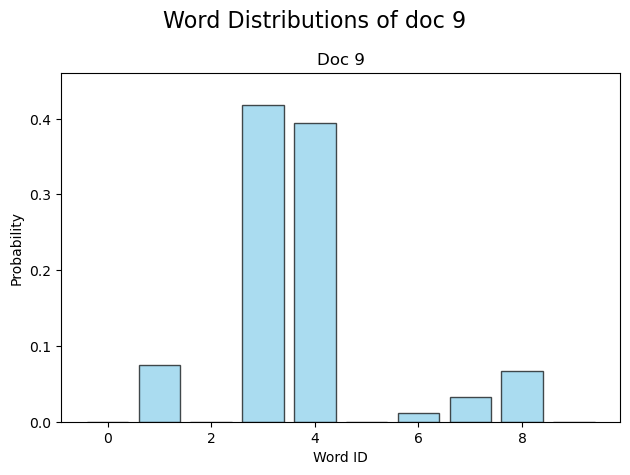

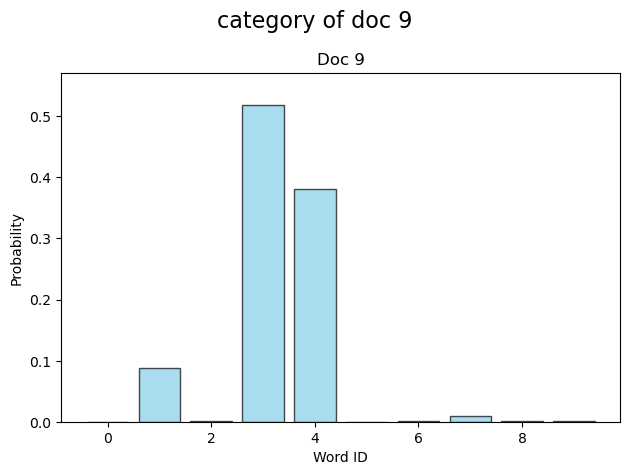

Doc 10 beta: [1.17549435e-38 1.24793746e-01 2.04785094e-02 4.40327168e-01
 6.51189446e-01 1.17549435e-38 3.82837743e-01 4.08563972e-01
 9.99999881e-01 1.00000000e+00]
Doc 10 weights: [1.17549435e-38 1.24793746e-01 1.79229192e-02 3.77485156e-01
 3.12439531e-01 1.96729132e-39 6.40712231e-02 4.21995334e-02
 6.10879175e-02 7.28224814e-09]


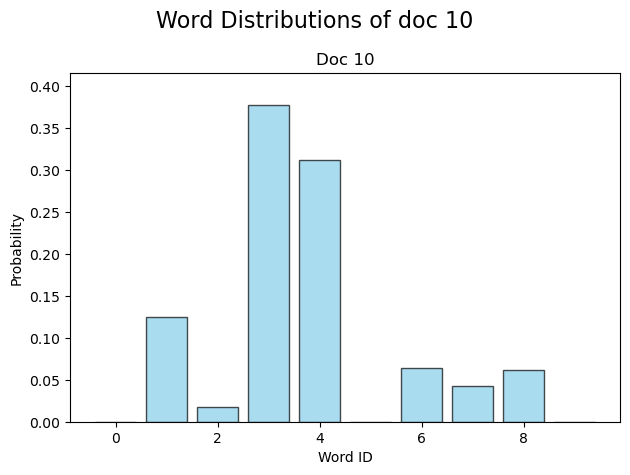

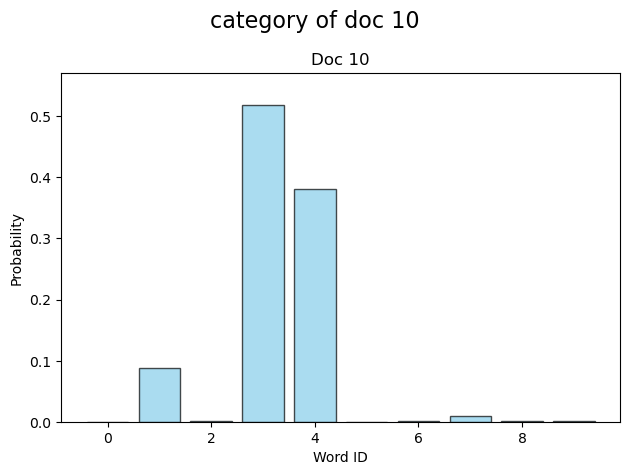

Doc 11 beta: [1.1754944e-38 7.9608381e-02 8.8917970e-04 4.5431349e-01 5.9360087e-01
 1.1754944e-38 5.4989576e-01 2.5073344e-01 9.9999988e-01 1.0000000e+00]
Doc 11 weights: [1.1754944e-38 7.9608381e-02 8.1839354e-04 4.1777453e-01 2.9786813e-01
 2.3971929e-39 1.1214055e-01 2.3014823e-02 6.8775177e-02 8.1986409e-09]


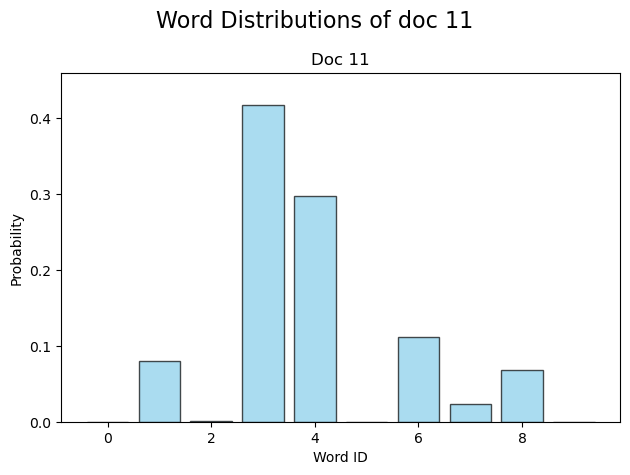

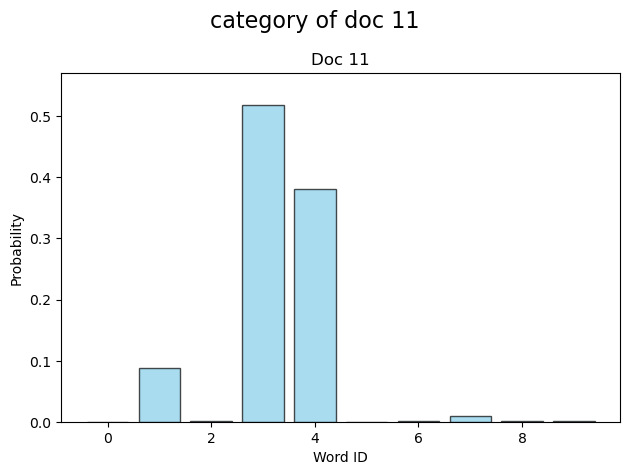

Doc 12 beta: [1.1754944e-38 9.4076529e-02 8.6752893e-03 5.2270389e-01 5.6774843e-01
 1.1754944e-38 4.4841352e-01 4.1241011e-01 9.9999988e-01 1.0000000e+00]
Doc 12 weights: [1.1754944e-38 9.4076529e-02 7.8591481e-03 4.6942174e-01 2.4336118e-01
 2.1779737e-39 8.3082713e-02 4.2147797e-02 6.0050942e-02 7.1586310e-09]


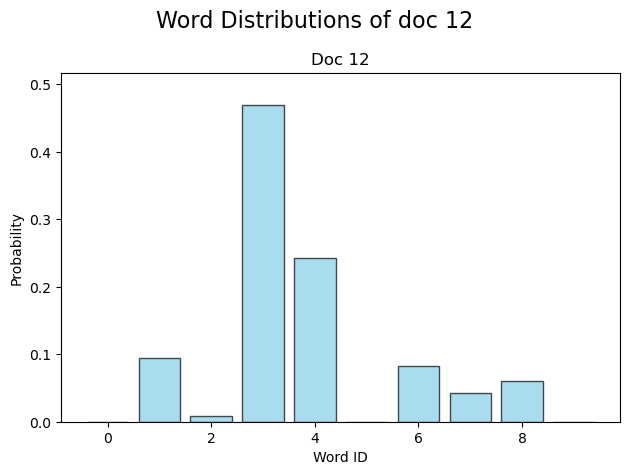

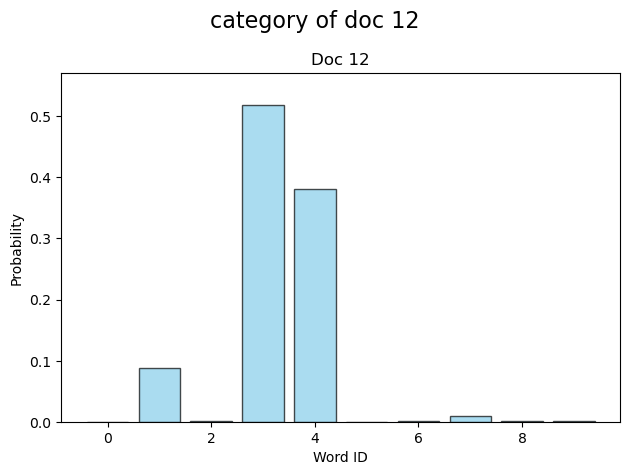

Doc 13 beta: [1.1754944e-38 1.0104708e-01 4.5526151e-02 4.5820832e-01 6.7195481e-01
 1.1754944e-38 4.4932339e-01 4.2166910e-01 9.5277268e-01 1.0000000e+00]
Doc 13 weights: [1.1754944e-38 1.0104708e-01 4.0925864e-02 3.9315513e-01 3.1237292e-01
 1.7926167e-39 6.8521366e-02 3.5410769e-02 4.6273168e-02 2.2936824e-03]


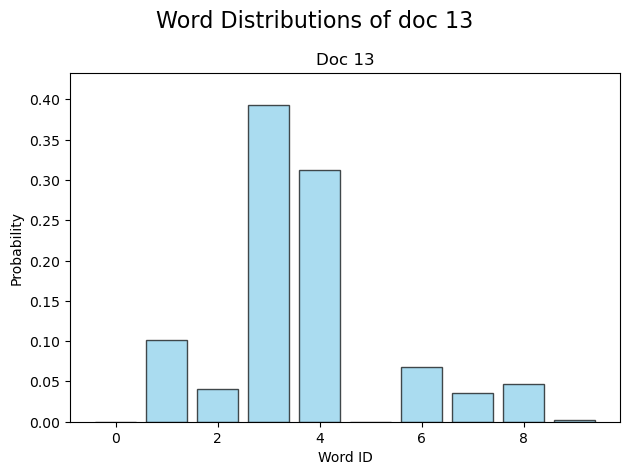

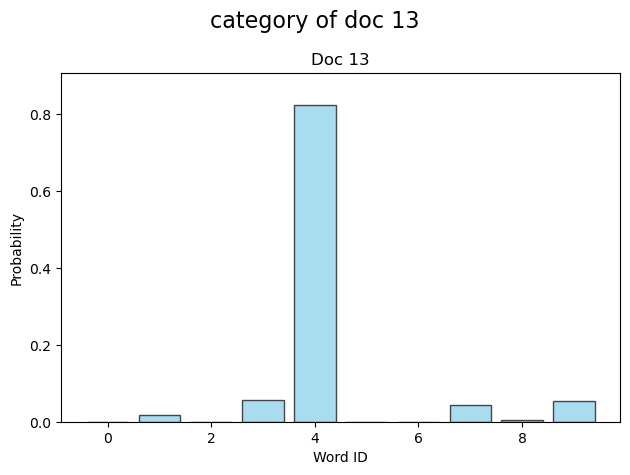

Doc 14 beta: [1.1754944e-38 5.6107476e-02 1.1190898e-02 5.7031345e-01 6.4375669e-01
 1.1754944e-38 5.0399816e-01 2.2981957e-01 9.9999988e-01 1.0000000e+00]
Doc 14 weights: [1.1754944e-38 5.6107476e-02 1.0563005e-02 5.3229040e-01 2.5817165e-01
 1.6794002e-39 7.2004966e-02 1.6285602e-02 5.4576948e-02 6.5060801e-09]


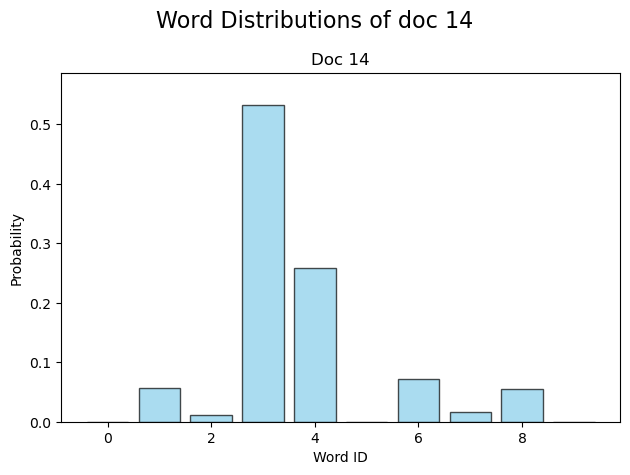

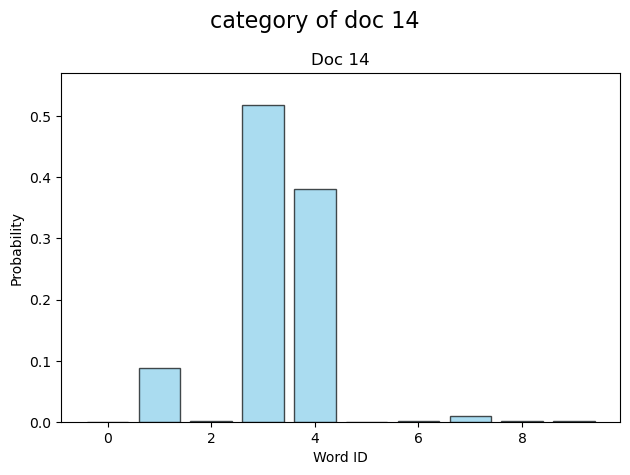

Doc 15 beta: [1.1754944e-38 6.4566076e-02 4.1703496e-02 4.8799077e-01 7.2611493e-01
 1.1754944e-38 5.0075150e-01 1.3913445e-01 9.9999988e-01 1.0000000e+00]
Doc 15 weights: [1.1754944e-38 6.4566076e-02 3.9010864e-02 4.3744618e-01 3.3326998e-01
 1.4776776e-39 6.2947929e-02 8.7319389e-03 5.4027051e-02 6.4405272e-09]


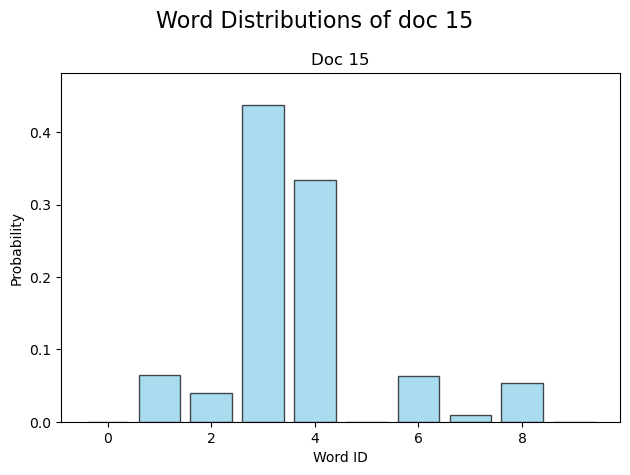

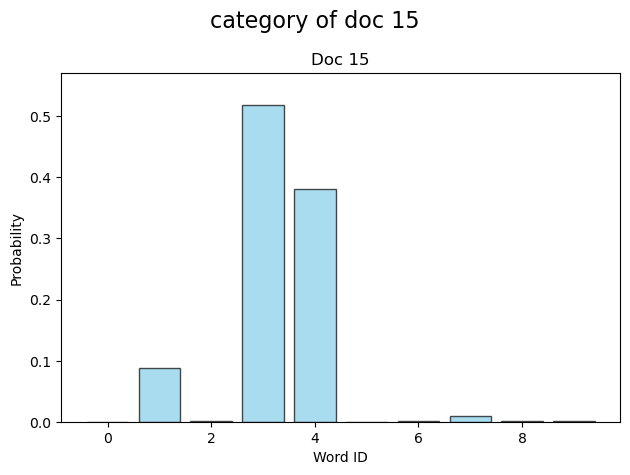

Doc 16 beta: [1.1754944e-38 4.7419526e-02 3.2789018e-02 4.8588437e-01 5.0435799e-01
 1.1754944e-38 4.1135332e-01 2.6537979e-01 9.9999988e-01 1.0000000e+00]
Doc 16 weights: [1.1754944e-38 4.7419526e-02 3.1234177e-02 4.4766778e-01 2.3890355e-01
 2.7597662e-39 9.6575469e-02 3.6675356e-02 1.0152414e-01 1.2102622e-08]


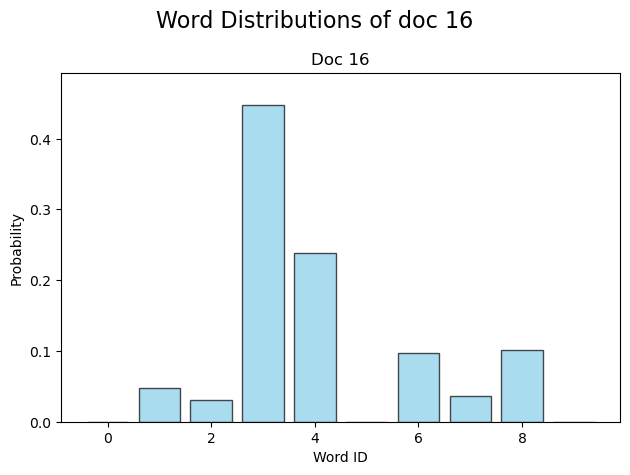

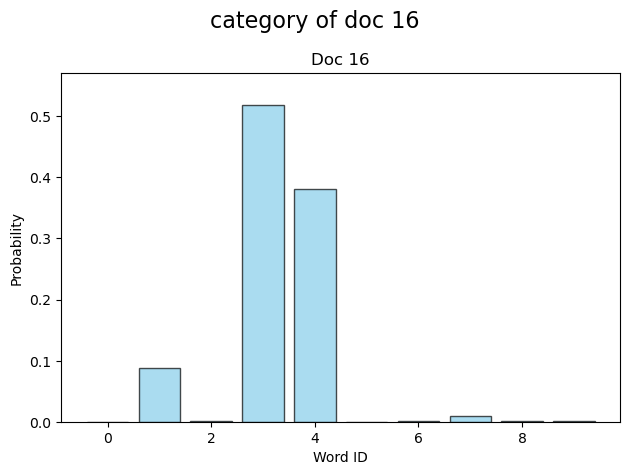

Doc 17 beta: [1.1754944e-38 4.3623984e-02 2.1372413e-02 4.2756489e-01 6.3242680e-01
 1.1754944e-38 3.4036475e-01 5.4029822e-01 6.8732190e-01 1.0000000e+00]
Doc 17 weights: [1.1754944e-38 4.3623984e-02 2.0440064e-02 4.0017334e-01 3.3883062e-01
 2.3149240e-39 6.7028701e-02 7.0186511e-02 4.1044641e-02 1.8672125e-02]


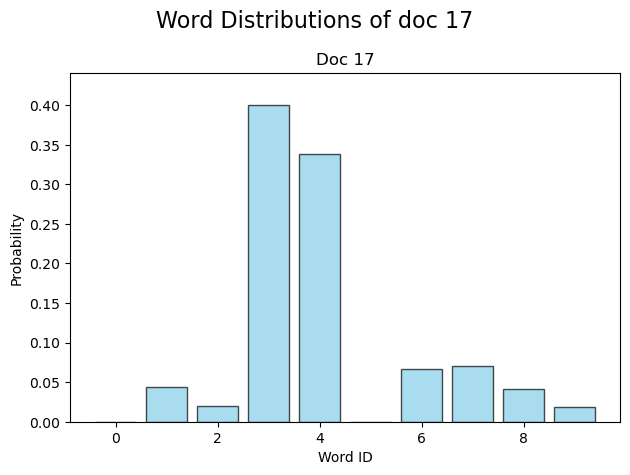

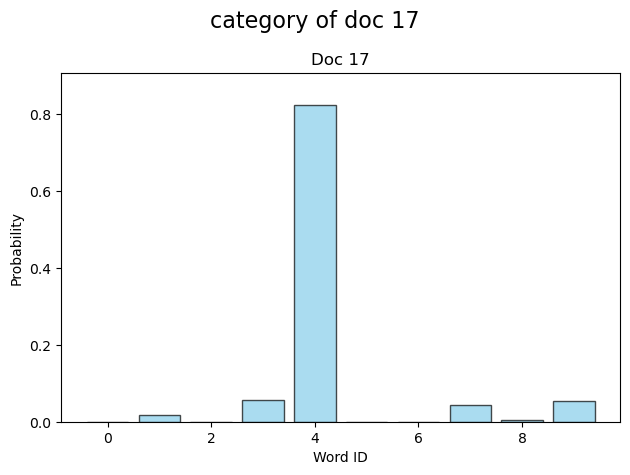

Doc 18 beta: [1.1754944e-38 8.9867912e-02 7.0097242e-03 4.9063888e-01 6.6773564e-01
 1.1754944e-38 3.3910075e-01 8.4638596e-02 9.9999988e-01 1.0000000e+00]
Doc 18 weights: [1.1754944e-38 8.9867912e-02 6.3797752e-03 4.4341603e-01 3.0738297e-01
 1.7979584e-39 5.1866598e-02 8.5558416e-03 9.2530914e-02 1.1030545e-08]


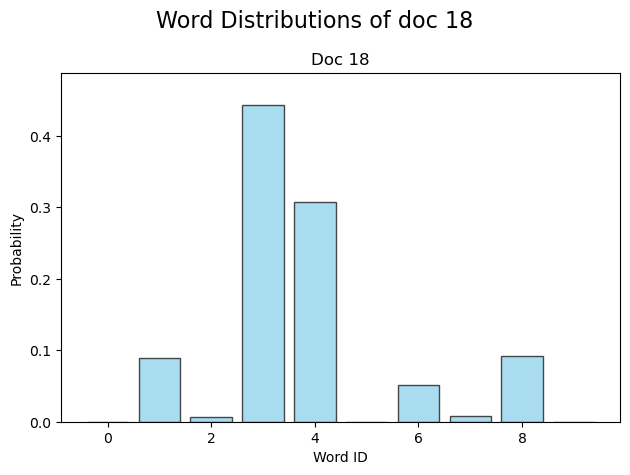

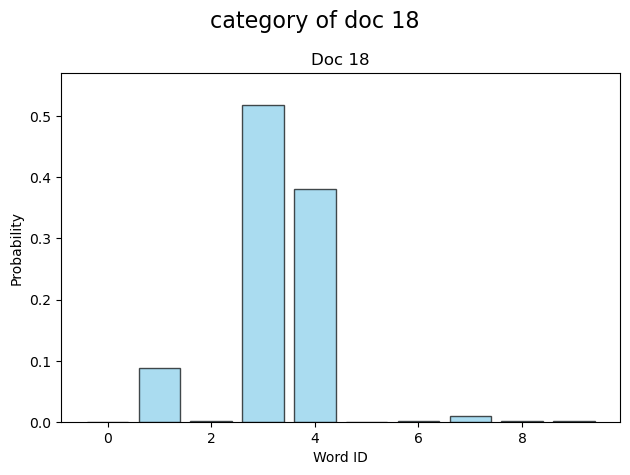

Doc 19 beta: [1.1754944e-38 7.3437527e-02 2.6647387e-02 5.0679725e-01 6.1339426e-01
 1.1754944e-38 3.0672660e-01 1.9060920e-01 9.9999988e-01 1.0000000e+00]
Doc 19 weights: [1.1754944e-38 7.3437527e-02 2.4690470e-02 4.5706627e-01 2.7284130e-01
 2.0214319e-39 5.2746076e-02 2.2724124e-02 9.6494257e-02 1.1503014e-08]


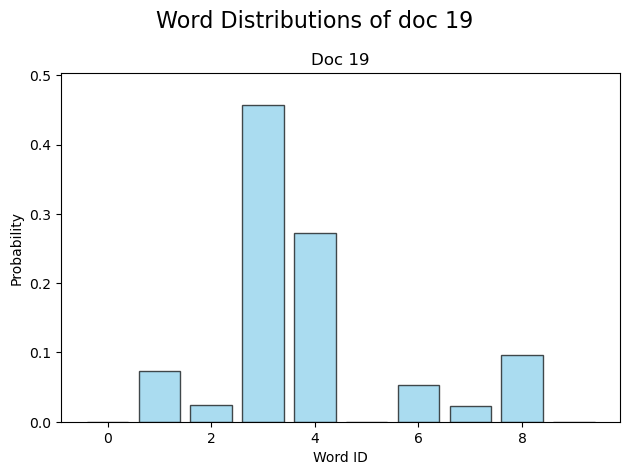

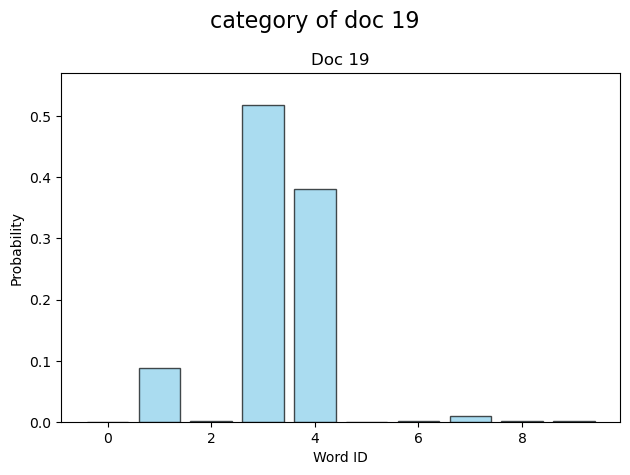

Doc 20 beta: [1.1754944e-38 1.9486416e-02 6.9463134e-02 9.2344172e-02 7.2340268e-01
 1.1754944e-38 5.5486596e-01 9.9999988e-01 1.1754944e-38 1.0000000e+00]
Doc 20 weights: [1.17549435e-38 1.94864161e-02 6.81095421e-02 8.42551887e-02
 5.99085093e-01 2.69263143e-39 1.27099678e-01 1.01964056e-01
 0.00000000e+00 1.21550645e-08]


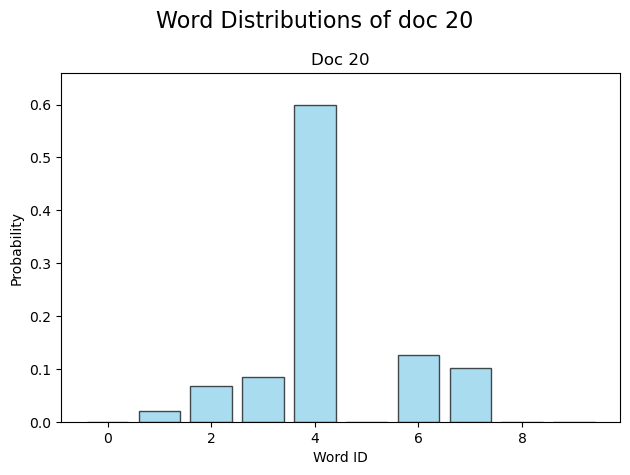

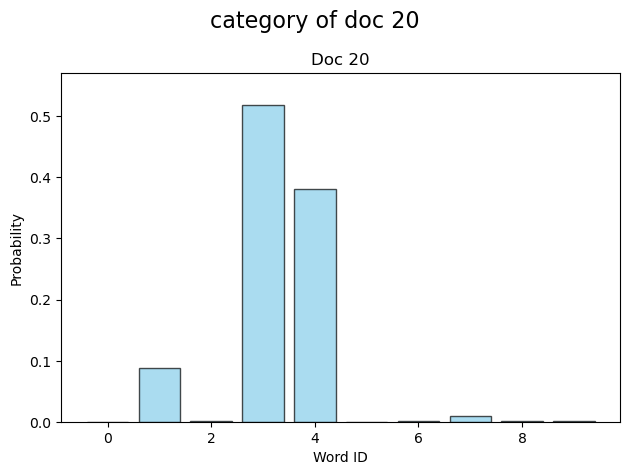

Doc 21 beta: [1.1754944e-38 4.8978743e-03 5.2236758e-02 8.7806642e-02 7.4436700e-01
 1.1754944e-38 4.6766439e-01 9.3233812e-01 9.9999988e-01 1.0000000e+00]
Doc 21 weights: [1.1754944e-38 4.8978743e-03 5.1980909e-02 8.2812302e-02 6.4038557e-01
 2.5851869e-39 1.0285031e-01 1.0915165e-01 7.9213809e-03 9.4430230e-10]


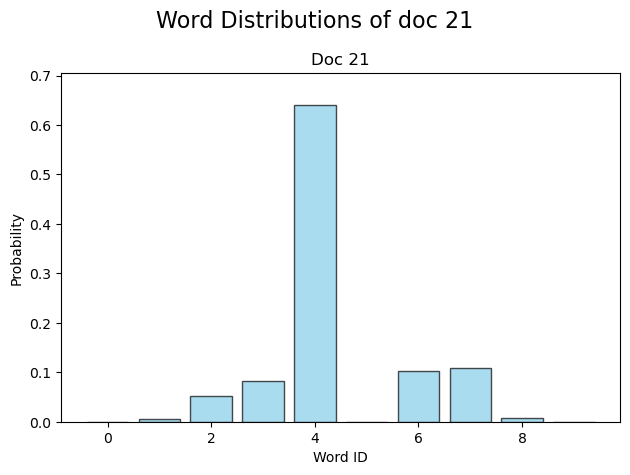

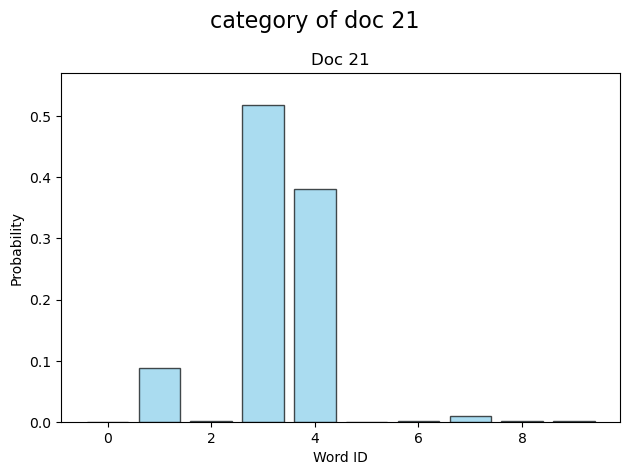

Doc 22 beta: [1.1754944e-38 1.8604478e-02 6.1408523e-02 7.1386084e-02 7.9626173e-01
 1.1754944e-38 4.3071410e-01 9.6298051e-01 9.9999988e-01 1.0000000e+00]
Doc 22 weights: [1.1754944e-38 1.8604478e-02 6.0266051e-02 6.5755829e-02 6.8110132e-01
 2.0485610e-39 7.5061560e-02 9.5538057e-02 3.6727325e-03 4.3782389e-10]


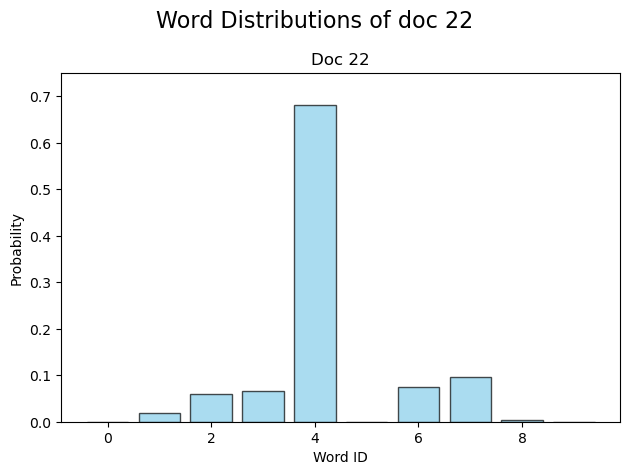

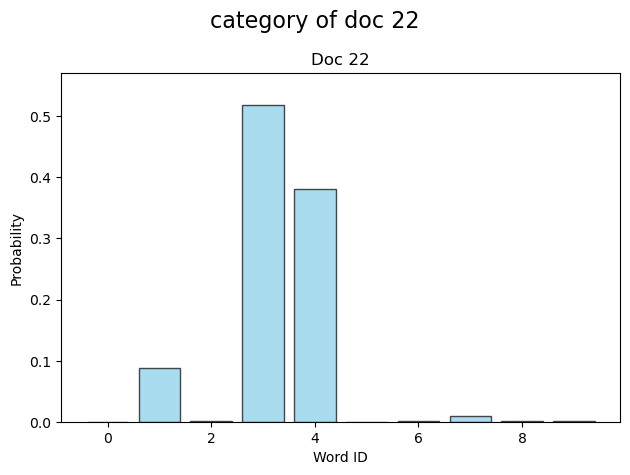

Doc 23 beta: [1.17549435e-38 1.32476008e-02 5.10302112e-02 1.18783005e-01
 7.95006096e-01 1.17549435e-38 7.59488046e-01 9.99999881e-01
 1.17549435e-38 1.00000000e+00]
Doc 23 weights: [1.1754944e-38 1.3247601e-02 5.0354183e-02 1.1122819e-01 6.5601522e-01
 1.9884061e-39 1.2847106e-01 4.0683754e-02 0.0000000e+00 4.8498818e-09]


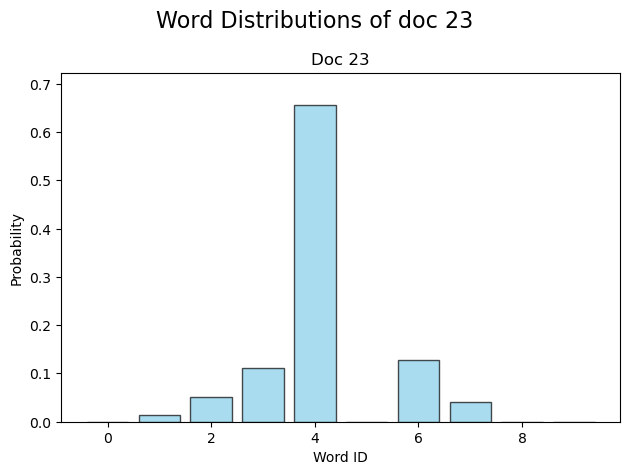

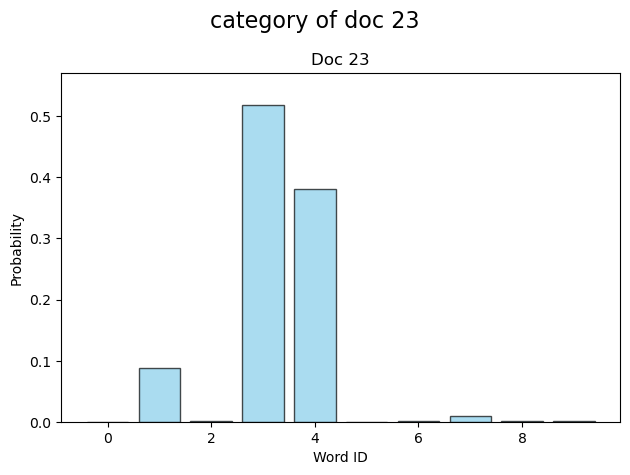

Doc 24 beta: [1.1754944e-38 1.1754944e-38 5.2846547e-02 7.2391801e-02 7.2248197e-01
 1.1754944e-38 6.0393059e-01 9.8090279e-01 9.9999988e-01 1.0000000e+00]
Doc 24 weights: [1.1754944e-38 1.1754944e-38 5.2846547e-02 6.8566144e-02 6.3476348e-01
 2.8661346e-39 1.4725266e-01 9.4726913e-02 1.8442393e-03 2.1985049e-10]


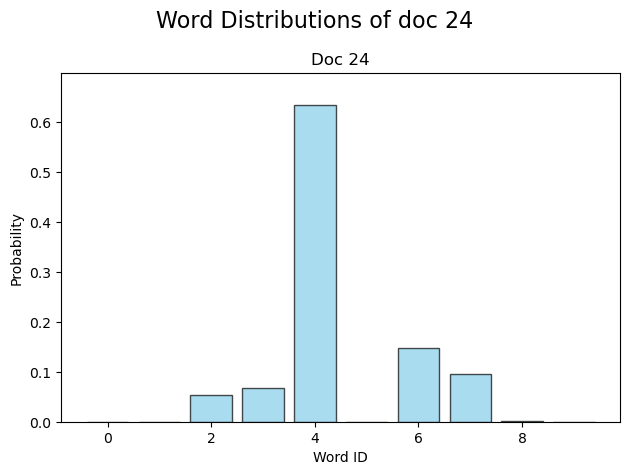

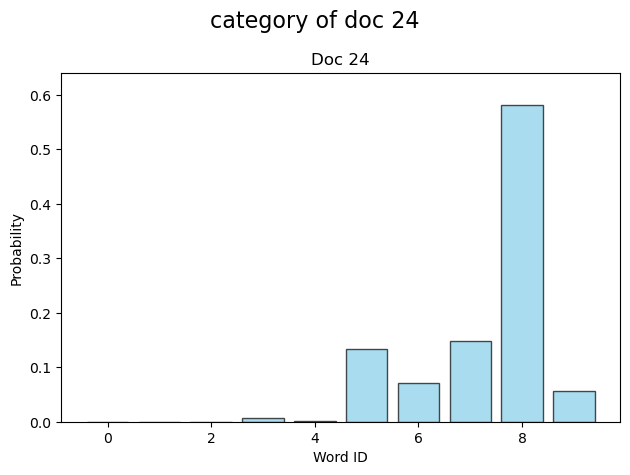

Doc 25 beta: [1.1754944e-38 3.4240170e-03 4.3654270e-02 4.6019301e-02 8.2242608e-01
 1.1754944e-38 5.0283277e-01 9.6292967e-01 9.9999988e-01 1.0000000e+00]
Doc 25 weights: [1.1754944e-38 3.4240170e-03 4.3504797e-02 4.3859672e-02 7.4775934e-01
 1.8978626e-39 8.1183486e-02 7.7293187e-02 2.9755898e-03 3.5471800e-10]


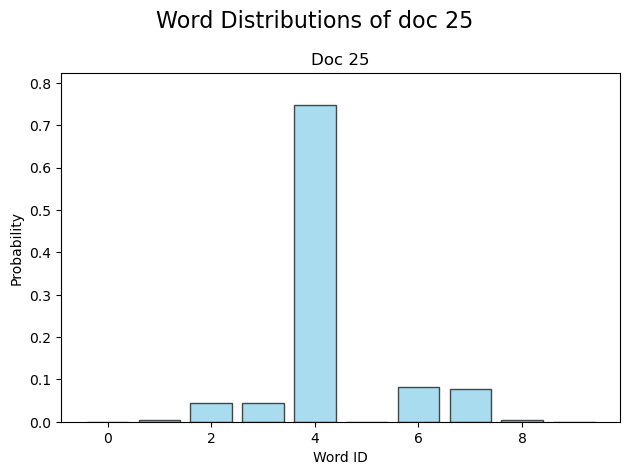

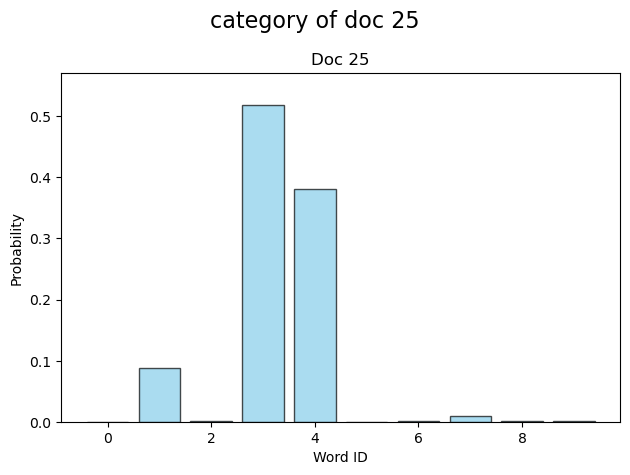

Doc 26 beta: [1.1754944e-38 1.1754944e-38 8.7010927e-02 6.9138460e-02 6.8187982e-01
 1.1754944e-38 6.0027778e-01 8.4758604e-01 9.9999988e-01 1.0000000e+00]
Doc 26 weights: [1.1754944e-38 1.1754944e-38 8.7010927e-02 6.3122660e-02 5.7950675e-01
 3.1780622e-39 1.6229090e-01 9.1597572e-02 1.6471187e-02 1.9635187e-09]


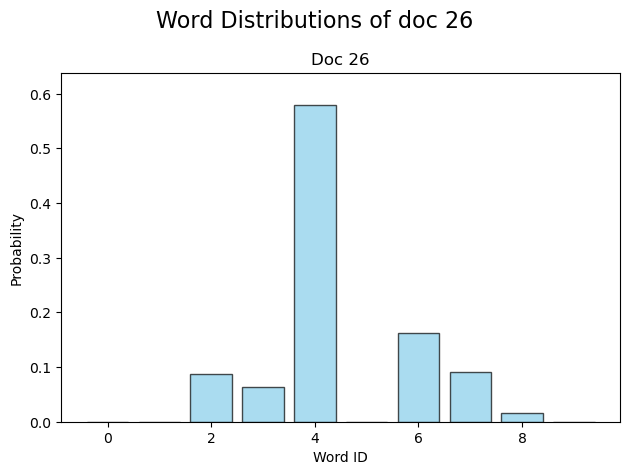

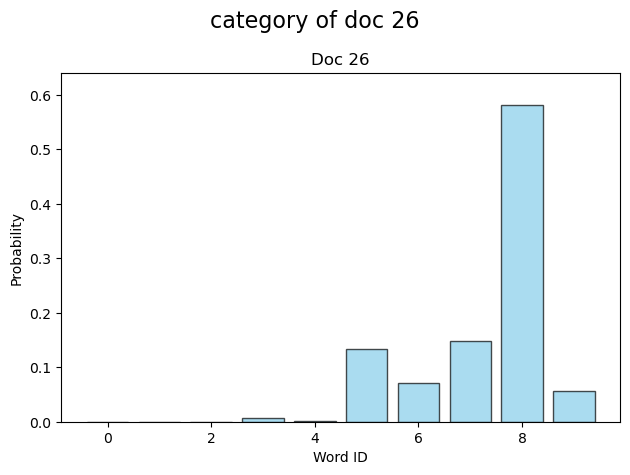

Doc 27 beta: [1.1754944e-38 6.1164442e-03 6.4156771e-02 4.2326208e-02 7.7920705e-01
 1.1754944e-38 5.9507424e-01 9.8705900e-01 9.9999988e-01 1.0000000e+00]
Doc 27 weights: [1.1754944e-38 6.1164442e-03 6.3764356e-02 3.9368421e-02 6.9407928e-01
 2.3118622e-39 1.1703414e-01 7.8606762e-02 1.0305870e-03 1.2285556e-10]


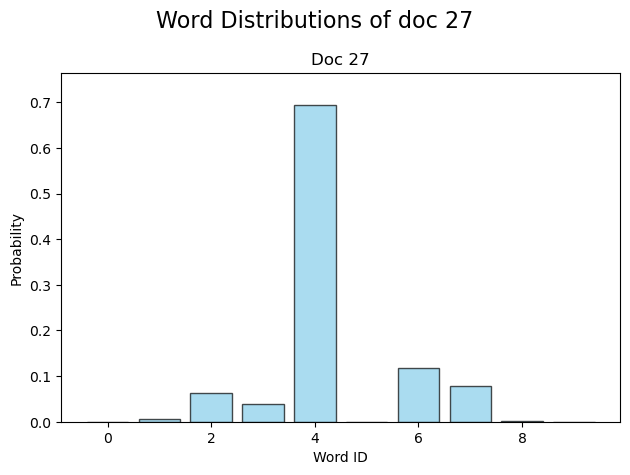

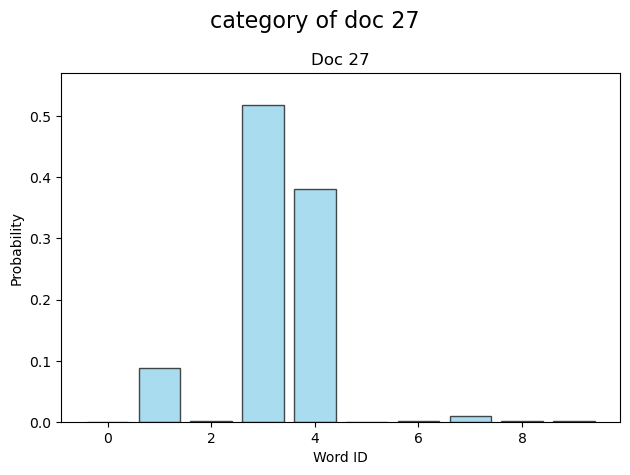

Doc 28 beta: [1.1754944e-38 9.0898937e-03 9.0555608e-02 8.2385950e-02 7.7718747e-01
 1.1754944e-38 3.4909853e-01 8.8025028e-01 9.9999988e-01 1.0000000e+00]
Doc 28 weights: [1.17549435e-38 9.08989366e-03 8.97324681e-02 7.42443725e-02
 6.42682195e-01 2.16586092e-39 6.43217862e-02 1.05567805e-01
 1.43614998e-02 1.71202441e-09]


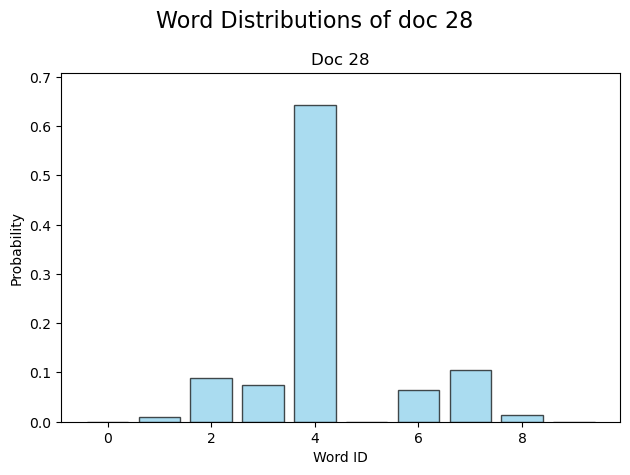

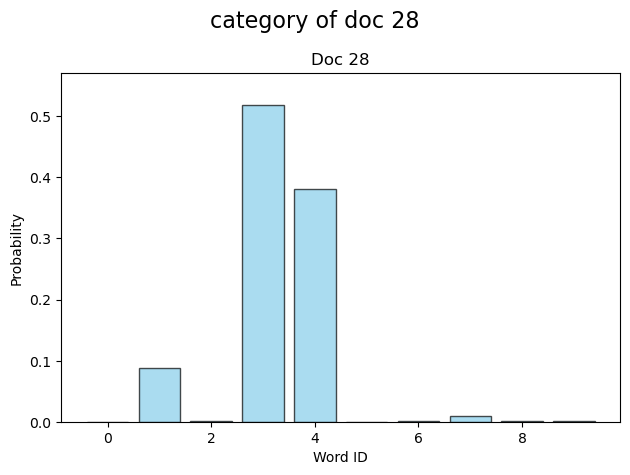

Doc 29 beta: [1.1754944e-38 1.1751686e-02 2.9016320e-02 6.5360501e-02 7.8076154e-01
 1.1754944e-38 7.4103200e-01 9.8695230e-01 9.9999988e-01 1.0000000e+00]
Doc 29 weights: [1.1754944e-38 1.1751686e-02 2.8675329e-02 6.2718168e-02 7.0022976e-01
 2.3113171e-39 1.4570546e-01 5.0255217e-02 6.6438335e-04 7.9200674e-11]


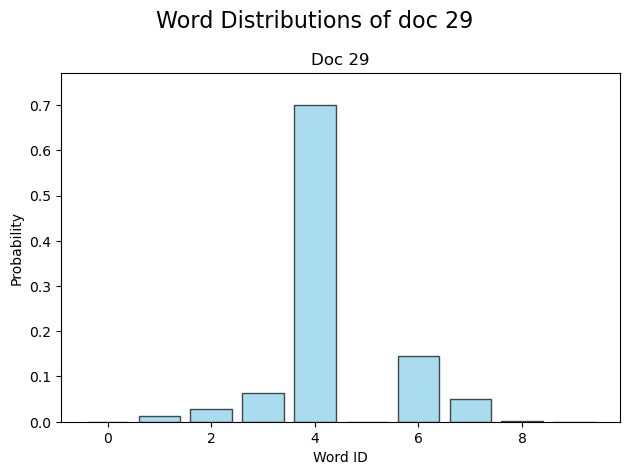

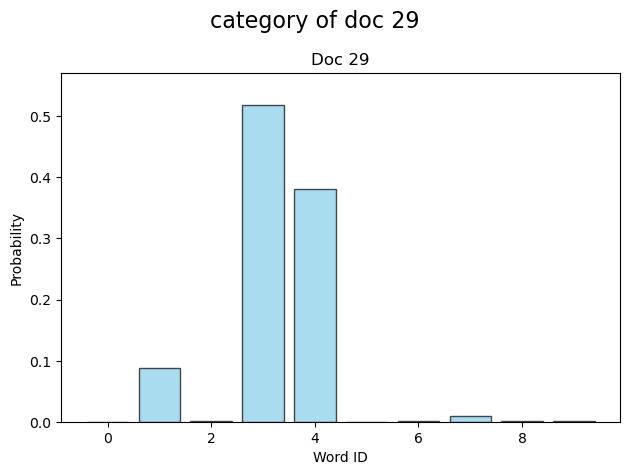

Doc 30 beta: [1.1754944e-38 2.0562515e-02 8.5192196e-02 5.1133174e-02 7.8665757e-01
 1.1754944e-38 4.9326825e-01 8.7414289e-01 9.9999988e-01 1.0000000e+00]
Doc 30 weights: [1.1754944e-38 2.0562515e-02 8.3440430e-02 4.5815174e-02 6.6880202e-01
 2.1321106e-39 8.9468934e-02 8.0343291e-02 1.1567644e-02 1.3789707e-09]


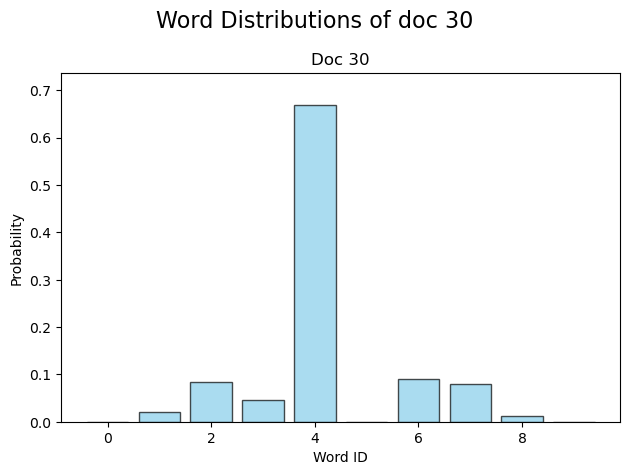

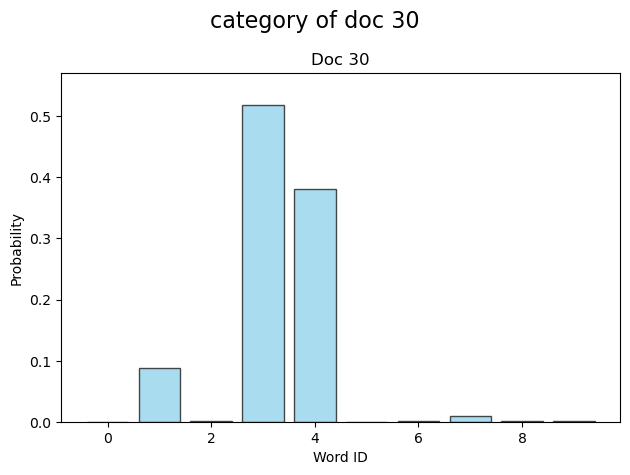

Doc 31 beta: [1.1754944e-38 3.5187323e-03 5.6020837e-02 5.7064958e-02 7.9069543e-01
 1.1754944e-38 7.3603553e-01 9.8044658e-01 9.9999988e-01 1.0000000e+00]
Doc 31 weights: [1.1754944e-38 3.5187323e-03 5.5823714e-02 5.3678580e-02 7.0133018e-01
 2.1822897e-39 1.3664407e-01 4.8046462e-02 9.5820893e-04 1.1422742e-10]


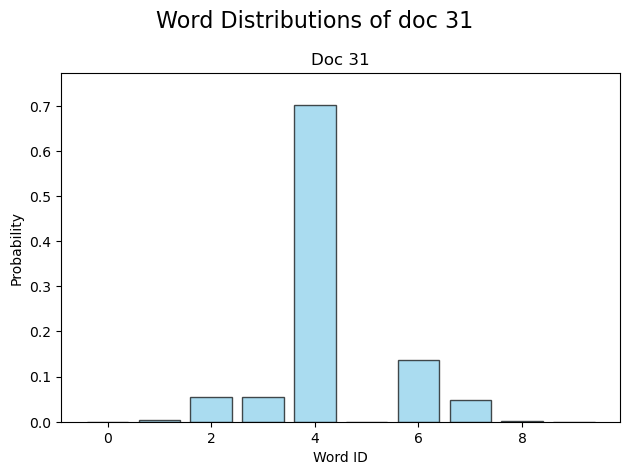

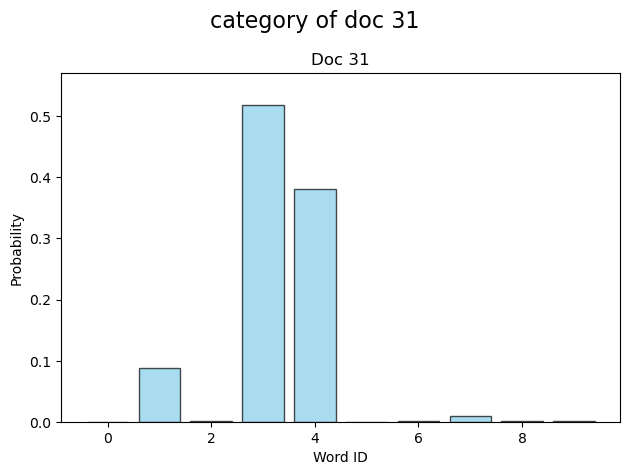

Doc 32 beta: [1.1754944e-38 4.0768016e-02 3.9198302e-02 7.7647939e-02 7.6125568e-01
 1.1754944e-38 8.1552839e-01 9.9949384e-01 9.9999988e-01 1.0000000e+00]
Doc 32 weights: [1.1754944e-38 4.0768016e-02 3.7600264e-02 7.1562804e-02 6.4711982e-01
 2.3856560e-39 1.6551079e-01 3.7419401e-02 1.8949893e-05 2.2590035e-12]


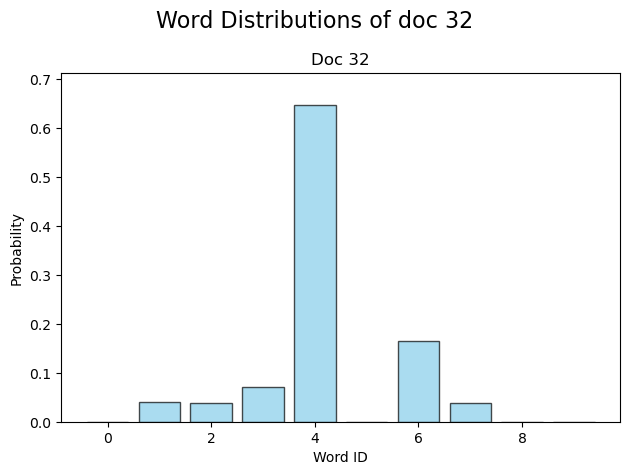

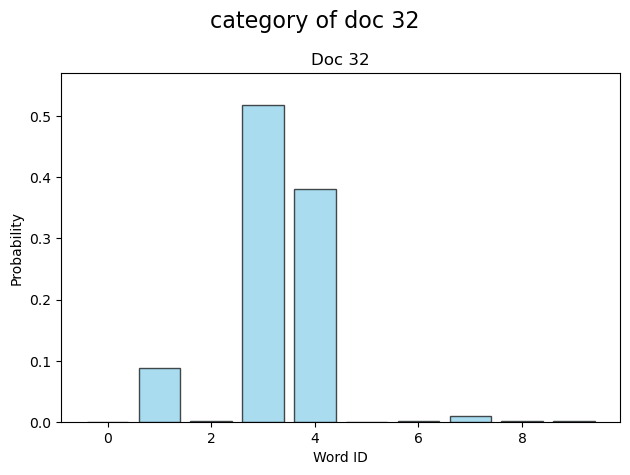

Doc 33 beta: [1.1754944e-38 1.7964458e-02 7.9353906e-02 8.5800976e-02 7.6673520e-01
 1.1754944e-38 5.6201625e-01 9.0949231e-01 9.9999988e-01 1.0000000e+00]
Doc 33 weights: [1.1754944e-38 1.7964458e-02 7.7928357e-02 7.7573277e-02 6.3373262e-01
 2.2663677e-39 1.0835744e-01 7.6801002e-02 7.6428135e-03 9.1109448e-10]


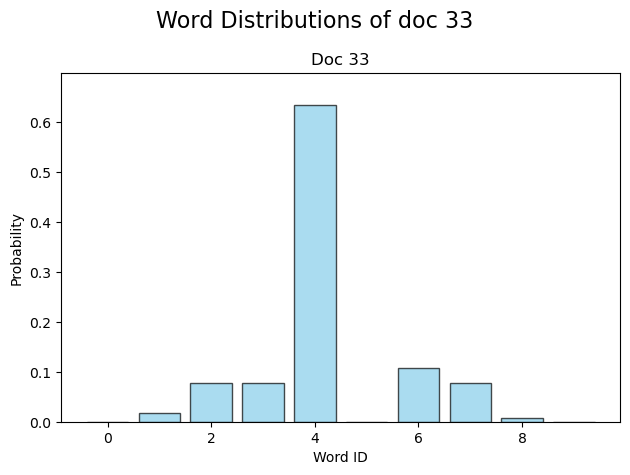

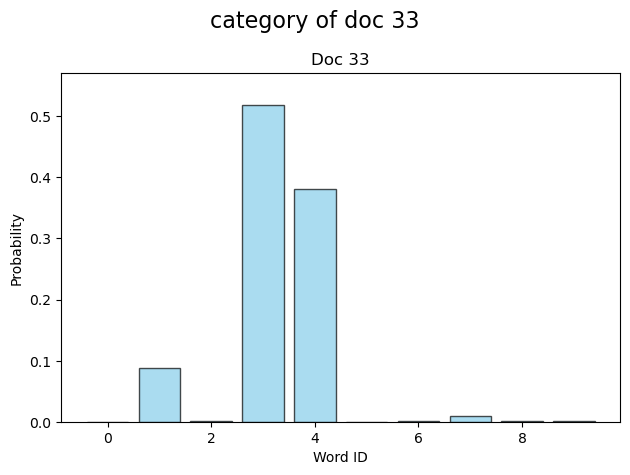

Doc 34 beta: [1.1754944e-38 1.0652364e-02 7.5891584e-02 9.1040105e-02 8.2411975e-01
 1.1754944e-38 6.7464054e-01 9.7899801e-01 9.9999988e-01 1.0000000e+00]
Doc 34 weights: [1.1754944e-38 1.0652364e-02 7.5083159e-02 8.3234727e-02 6.8486792e-01
 1.7181222e-39 9.8606609e-02 4.6556342e-02 9.9875173e-04 1.1906050e-10]


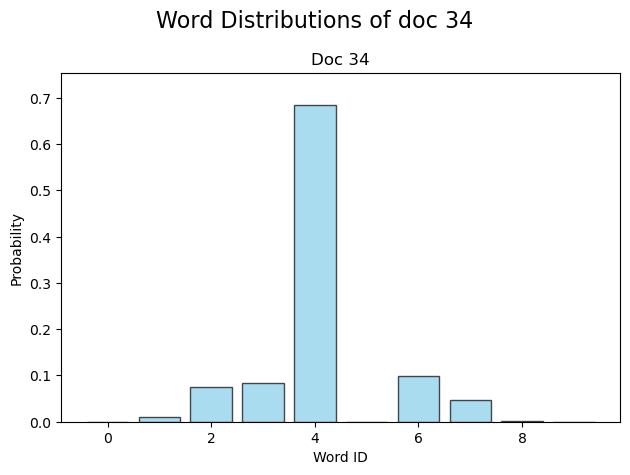

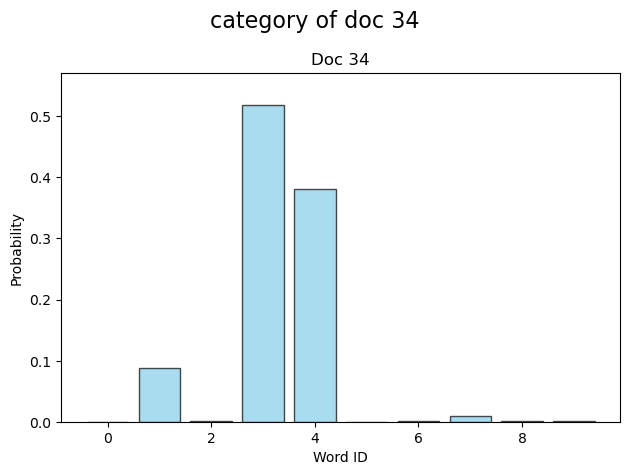

Doc 35 beta: [1.1754944e-38 1.0357931e-02 9.5388852e-02 3.0292876e-02 8.3135706e-01
 1.1754944e-38 7.1592212e-01 9.8431998e-01 9.9999988e-01 1.0000000e+00]
Doc 35 weights: [1.17549435e-38 1.03579313e-02 9.44008231e-02 2.71194316e-02
 7.21719265e-01 1.72095426e-39 1.04812875e-01 4.09376211e-02
 6.52127841e-04 7.77397036e-11]


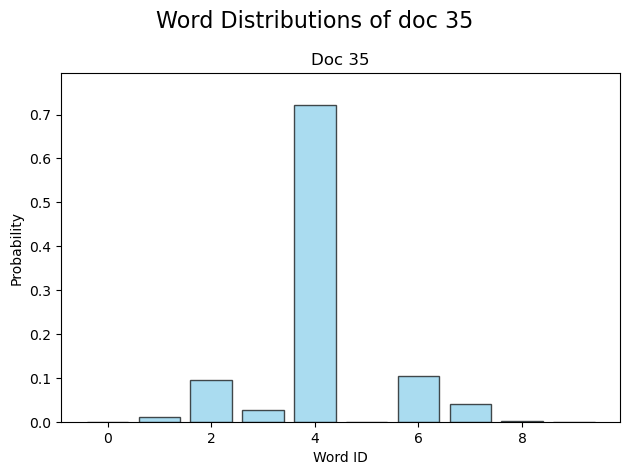

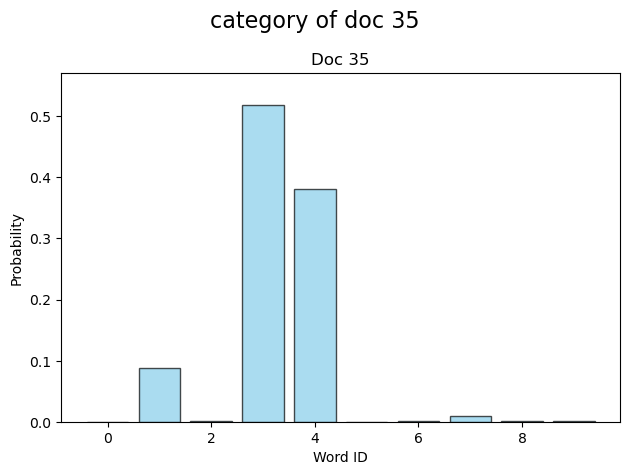

Doc 36 beta: [1.1754944e-38 3.1060904e-02 2.0795582e-02 4.1986592e-02 8.3267957e-01
 1.1754944e-38 7.5247067e-01 9.9999988e-01 1.1754944e-38 1.0000000e+00]
Doc 36 weights: [1.1754944e-38 3.1060904e-02 2.0149652e-02 3.9836433e-02 7.5686657e-01
 1.7877668e-39 1.1444056e-01 3.7645843e-02 0.0000000e+00 4.4877346e-09]


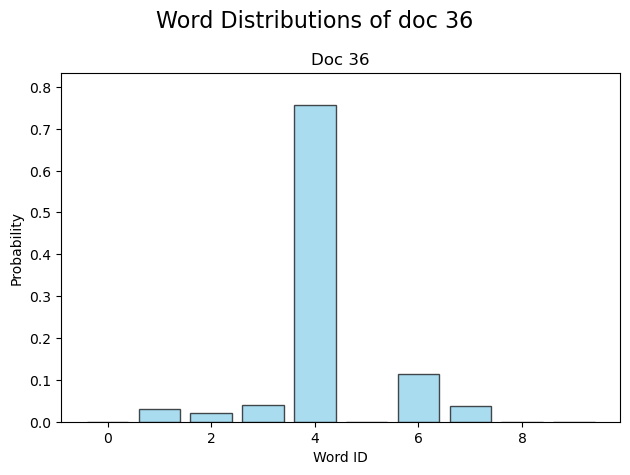

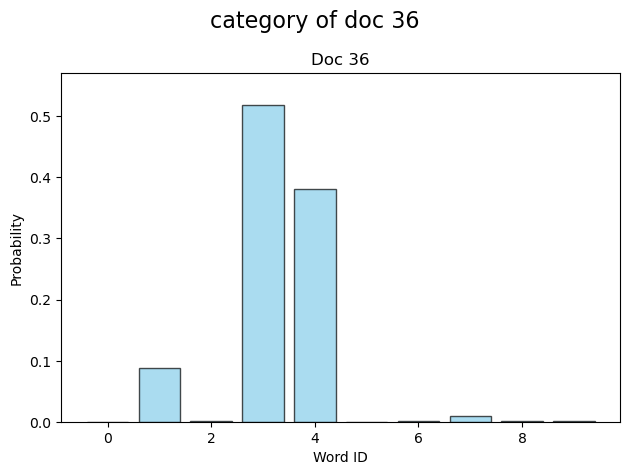

Doc 37 beta: [1.1754944e-38 1.1754944e-38 3.6541950e-02 8.1718720e-02 7.5920665e-01
 1.1754944e-38 6.5059870e-01 8.5773808e-01 9.9999988e-01 1.0000000e+00]
Doc 37 weights: [1.1754944e-38 1.1754944e-38 3.6541950e-02 7.8732558e-02 6.7168945e-01
 2.5042269e-39 1.3860095e-01 6.3845783e-02 1.0589273e-02 1.2623398e-09]


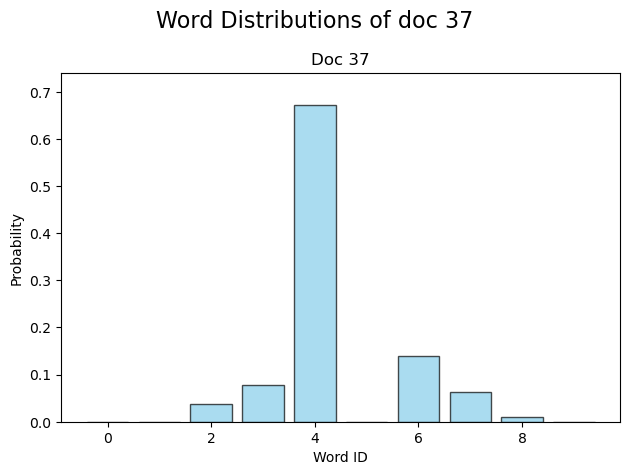

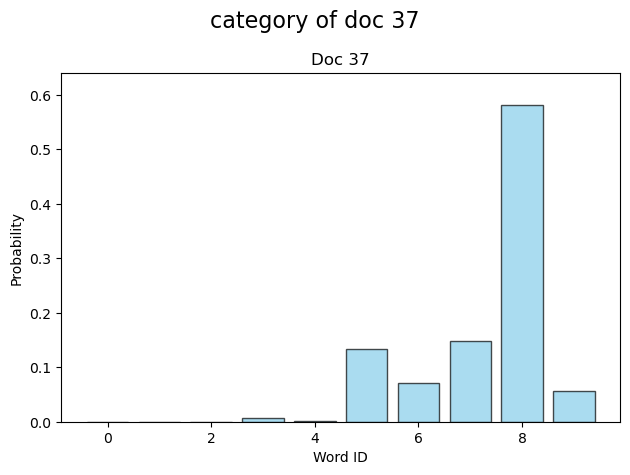

Doc 38 beta: [1.1754944e-38 8.6796042e-03 2.1943260e-02 9.0064786e-02 8.2245082e-01
 1.1754944e-38 7.1615189e-01 9.9657035e-01 9.9999988e-01 1.0000000e+00]
Doc 38 weights: [1.1754944e-38 8.6796042e-03 2.1752801e-02 8.7323897e-02 7.2560203e-01
 1.8413132e-39 1.1217921e-01 4.4309944e-02 1.5249063e-04 1.8178301e-11]


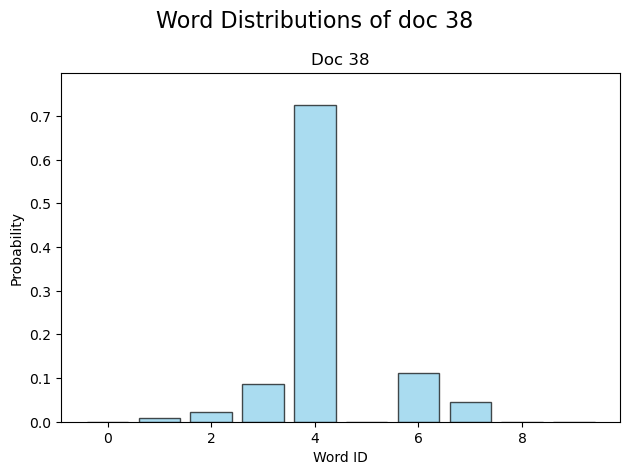

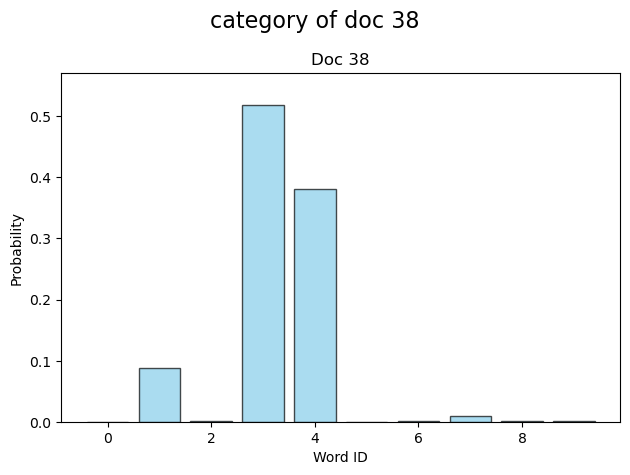

Doc 39 beta: [1.1754944e-38 2.5074381e-02 9.0917997e-02 5.7578444e-02 7.5906080e-01
 1.1754944e-38 5.2412039e-01 9.7779465e-01 9.9999988e-01 1.0000000e+00]
Doc 39 weights: [1.17549435e-38 2.50743814e-02 8.86382833e-02 5.10310456e-02
 6.34010315e-01 2.36563563e-39 1.05477124e-01 9.36422721e-02
 2.12658104e-03 2.53508242e-10]


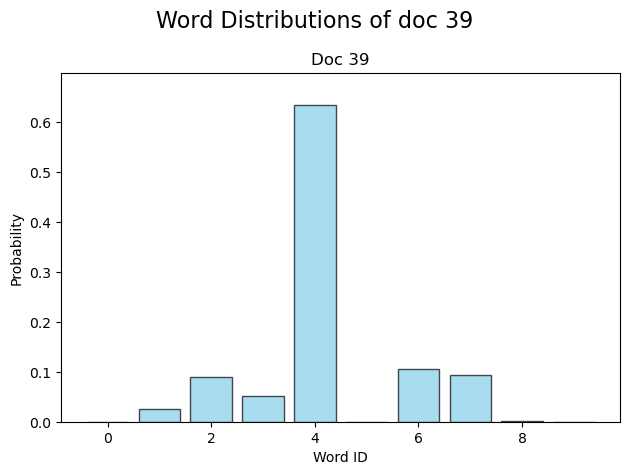

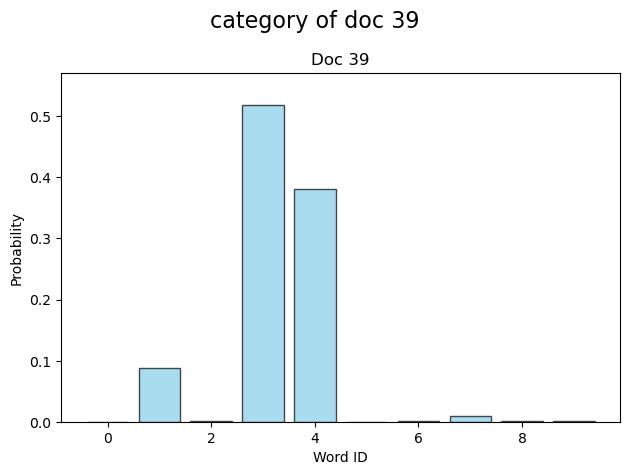

Doc 40 beta: [1.1754944e-38 5.2148992e-01 2.8322196e-01 3.1865877e-01 6.4021546e-01
 1.1754944e-38 1.2544940e-01 5.5644900e-01 4.8217174e-01 1.0000000e+00]
Doc 40 weights: [1.17549435e-38 5.21489918e-01 1.35524556e-01 1.09295338e-01
 1.49612054e-01 9.88333004e-40 1.05475485e-02 4.09160070e-02
 1.57258175e-02 1.68887377e-02]


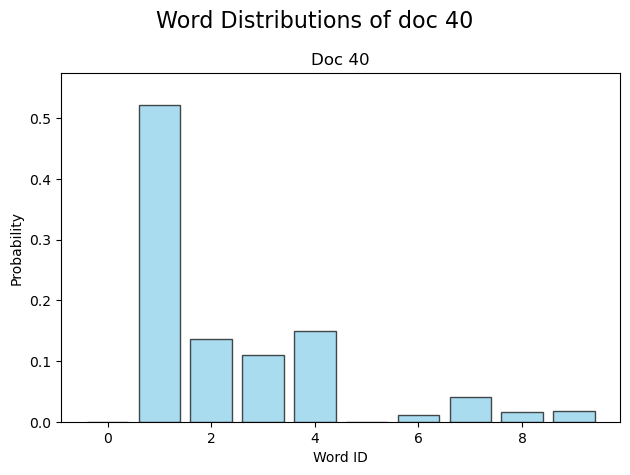

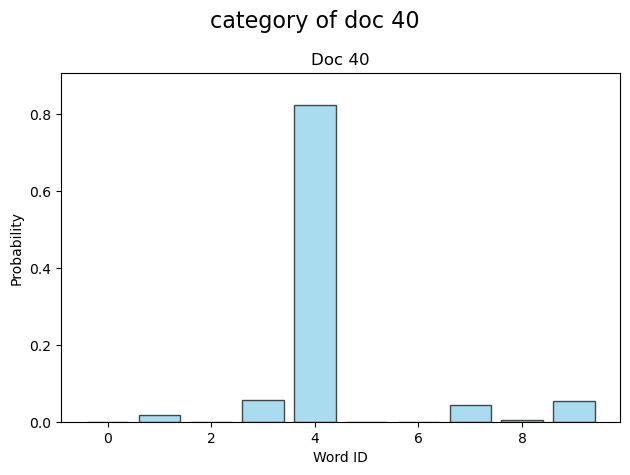

Doc 41 beta: [1.1754944e-38 4.4912598e-01 2.0575808e-01 1.9435838e-01 7.0115125e-01
 1.1754944e-38 3.1273314e-01 3.6810601e-01 5.5417126e-01 1.0000000e+00]
Doc 41 weights: [1.1754944e-38 4.4912598e-01 1.1334678e-01 8.5037082e-02 2.4714892e-01
 1.2382798e-39 3.2943696e-02 2.6649969e-02 2.5351990e-02 2.0395581e-02]


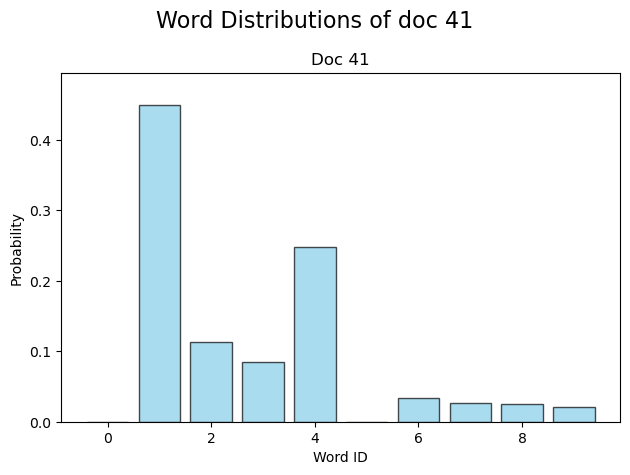

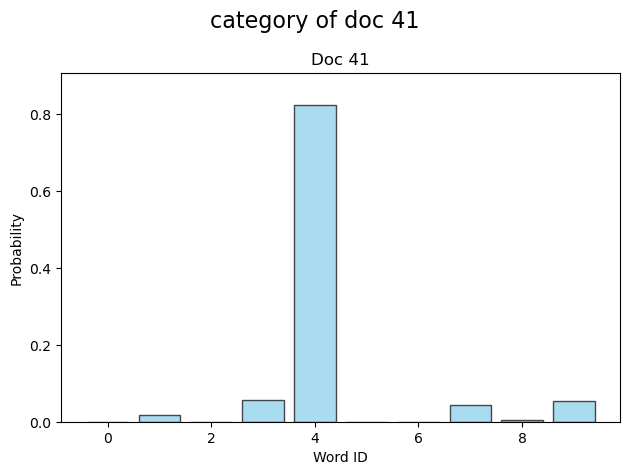

Doc 42 beta: [1.1754944e-38 3.8496545e-01 3.4277382e-01 3.7666133e-01 5.6827813e-01
 1.1754944e-38 2.7885962e-01 3.4465712e-01 6.7700356e-01 1.0000000e+00]
Doc 42 weights: [1.1754944e-38 3.8496545e-01 2.1081775e-01 1.5225285e-01 1.4318563e-01
 1.2786834e-39 3.0333895e-02 2.7036449e-02 3.4803420e-02 1.6604610e-02]


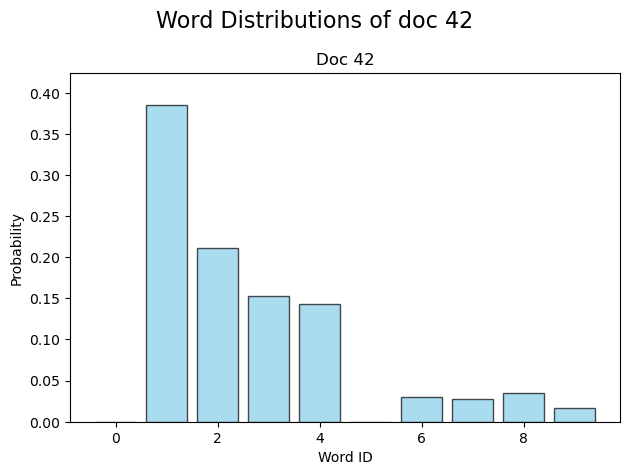

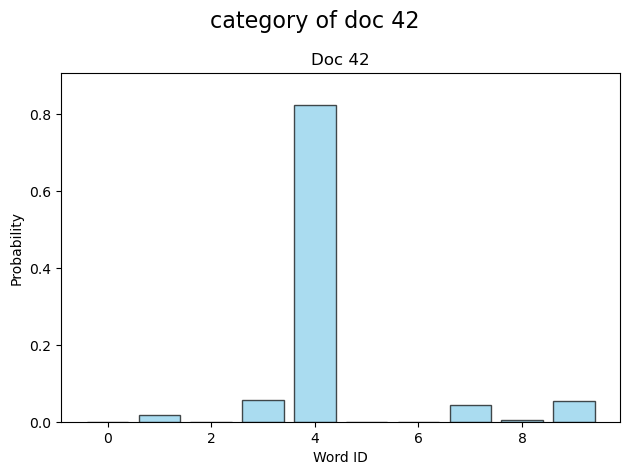

Doc 43 beta: [1.1754944e-38 5.2518606e-01 2.7091879e-01 2.9913297e-01 4.9858779e-01
 1.1754944e-38 3.3759940e-01 4.9470273e-01 7.7571839e-01 1.0000000e+00]
Doc 43 weights: [1.17549435e-38 5.25186062e-01 1.28636017e-01 1.03553236e-01
 1.20969720e-01 1.43004750e-39 4.10706513e-02 3.98652926e-02
 3.15865166e-02 9.13253427e-03]


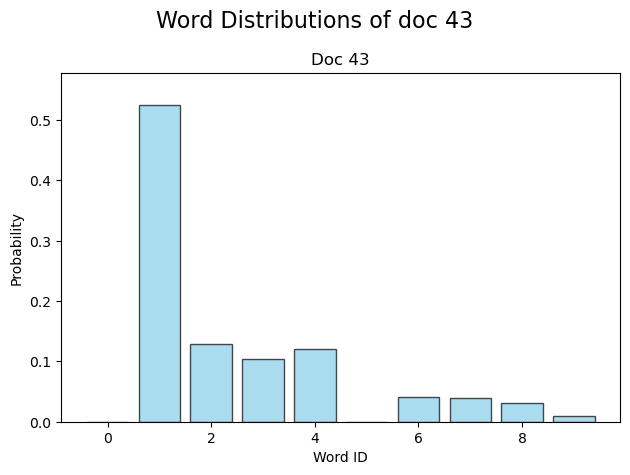

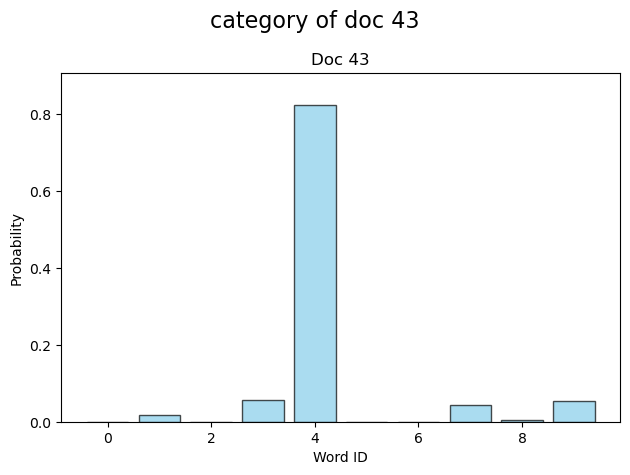

Doc 44 beta: [1.1754944e-38 5.2736276e-01 2.7356288e-01 3.6791080e-01 7.0854467e-01
 1.1754944e-38 1.7441945e-01 2.9966497e-01 3.8599044e-01 1.0000000e+00]
Doc 44 weights: [1.1754944e-38 5.2736276e-01 1.2929600e-01 1.2631895e-01 1.5376998e-01
 7.4352756e-40 1.1032431e-02 1.5648466e-02 1.4116212e-02 2.2455191e-02]


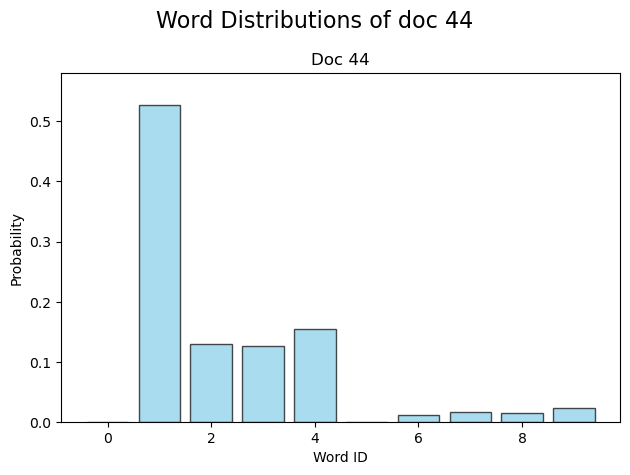

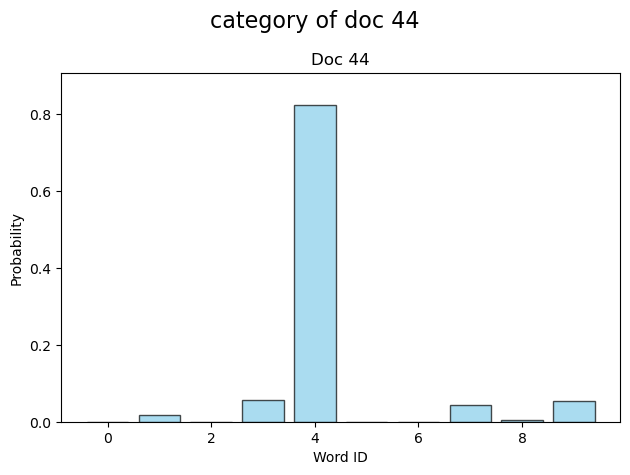

Doc 45 beta: [1.1754944e-38 5.5453914e-01 2.6517716e-01 2.0834038e-01 5.0969636e-01
 1.1754944e-38 1.9471735e-01 3.3017370e-01 2.3313491e-01 1.0000000e+00]
Doc 45 weights: [1.1754944e-38 5.5453914e-01 1.1812604e-01 6.8197057e-02 1.3208157e-01
 1.4935375e-39 2.4740042e-02 3.3782098e-02 1.5977677e-02 5.2556362e-02]


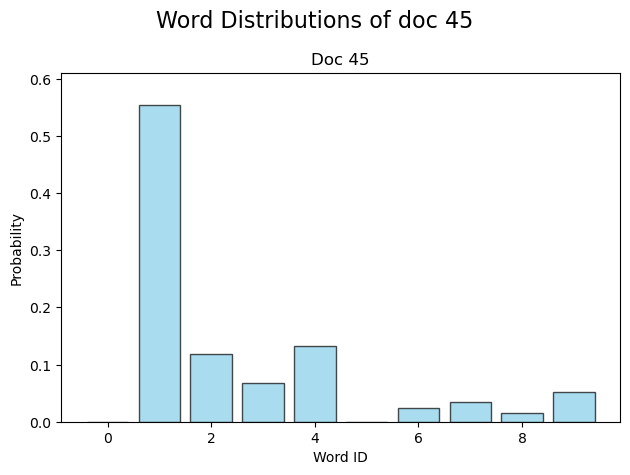

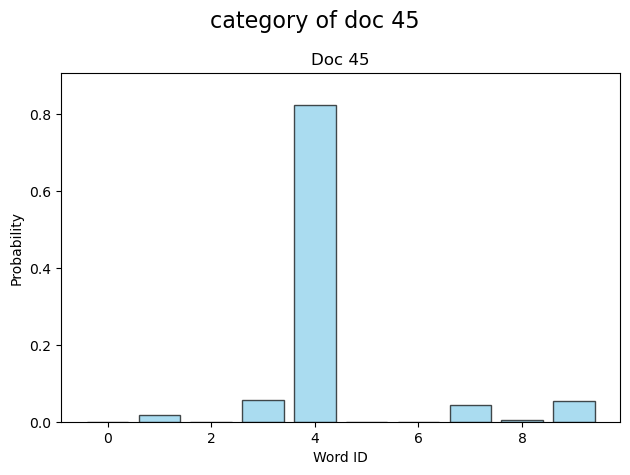

Doc 46 beta: [1.1754944e-38 5.7578057e-01 3.5577500e-01 3.0671790e-01 4.9614549e-01
 1.1754944e-38 4.6298191e-01 5.4541975e-01 5.9031057e-01 1.0000000e+00]
Doc 46 weights: [1.1754944e-38 5.7578057e-01 1.5092666e-01 8.3823778e-02 9.4004177e-02
 1.1221836e-39 4.4198476e-02 2.7961666e-02 1.3756986e-02 9.5476722e-03]


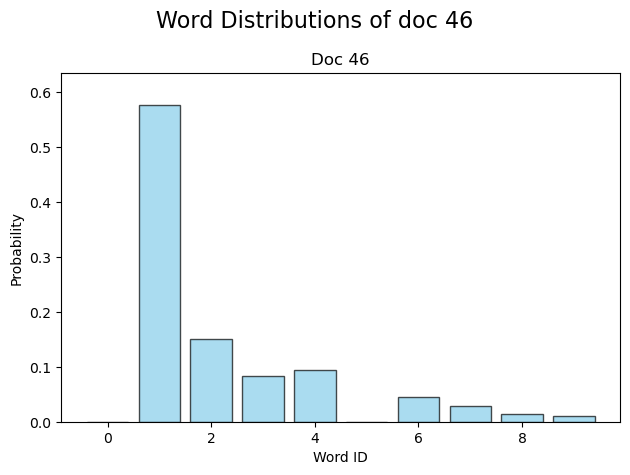

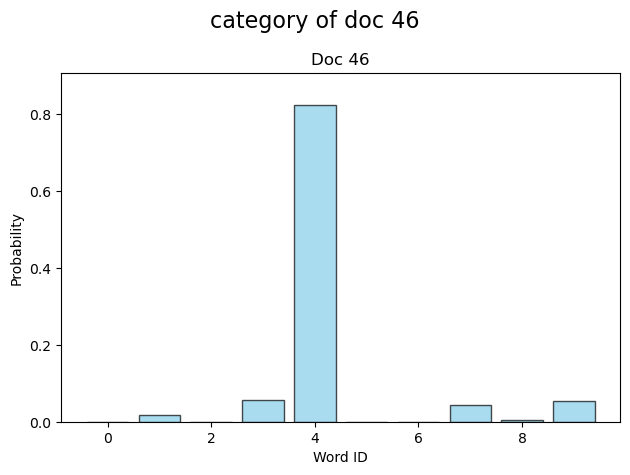

Doc 47 beta: [1.17549435e-38 4.94184762e-01 3.08588028e-01 3.20671290e-01
 6.14503384e-01 1.17549435e-38 1.58700109e-01 1.10017076e-01
 7.31615007e-01 1.00000000e+00]
Doc 47 weights: [1.17549435e-38 4.94184762e-01 1.56088531e-01 1.12147324e-01
 1.45993352e-01 1.07658958e-39 1.45347165e-02 8.47696234e-03
 5.01700416e-02 1.84043329e-02]


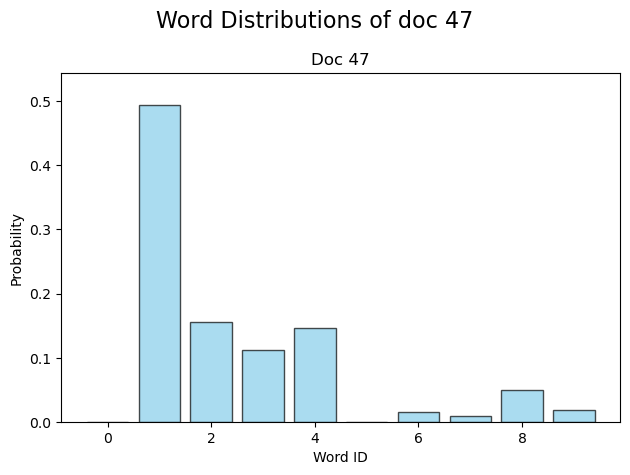

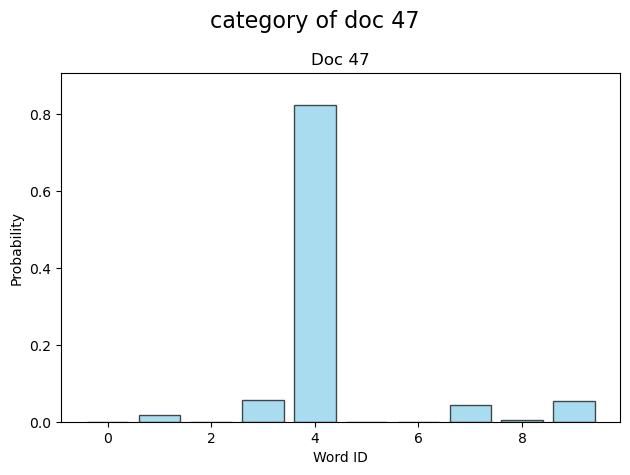

Doc 48 beta: [1.1754944e-38 5.0176632e-01 3.3819377e-01 2.3147693e-01 5.0032330e-01
 1.1754944e-38 5.6019497e-01 5.0777054e-01 6.6139150e-01 1.0000000e+00]
Doc 48 weights: [1.1754944e-38 5.0176632e-01 1.6849953e-01 7.6325849e-02 1.2678608e-01
 1.4884368e-39 7.0933133e-02 2.8277280e-02 1.8129939e-02 9.2818728e-03]


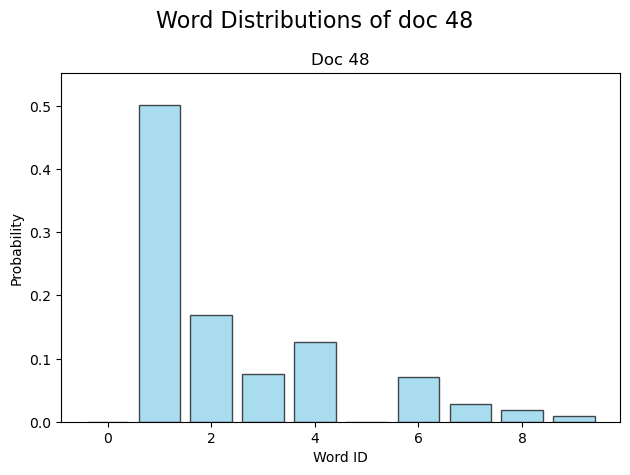

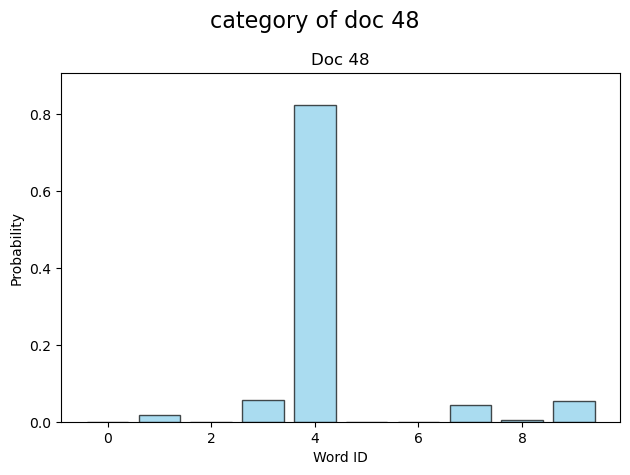

Make Prediction Gibbs Sampling (Iter 0):  50%|█████     | 1/2 [03:35<03:35, 215.86s/it]


KeyboardInterrupt: 

In [100]:
post_return = infer(jax.random.PRNGKey(0), model_return1[2], dataset, struct_upbd, vocab_size, num_iters=1, gt=data)
data_summary([post_return], data, struct_upbd)

In [ ]:
# dataset = (data["x"], data["y"], data["base_labels"])
# vocab_size = data["x"].shape[-1]
# hdmm2 = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, known_base=True, known_super=False, gen_mixture=data["word_dists"], device="cpu")
# model_return2 = gibbs_sampler(jax.random.PRNGKey(0), hdmm2, struct_upbd, vocab_size, num_iters=52, gt=data, known_base=True, known_super=False, gen_ground_truth=True)
# data_summary(model_return2, data, struct_upbd)

In [ ]:
# dataset = (data["x"], data["y"])
# vocab_size = data["x"].shape[-1]
# hdmm3 = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, known_base=False, known_super=False, gen_mixture=data["word_dists"], device="cpu")
# model_return3 = gibbs_sampler(jax.random.PRNGKey(0), hdmm3, struct_upbd, vocab_size, num_iters=52, gt=data, known_base=False, known_super=False, gen_ground_truth=True)
# data_summary(model_return3, data, struct_upbd)

In [ ]:
# dataset = (data["x"], data["y"])
# vocab_size = data["x"].shape[-1]
# hdmm4 = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, known_base=False, known_super=False, gen_mixture=None, device="cpu")
# model_return4 = gibbs_sampler(jax.random.PRNGKey(0), hdmm4, struct_upbd, vocab_size, num_iters=82, gt=data, known_base=False, known_super=False, gen_ground_truth=False)
# data_summary(model_return4, data, struct_upbd)